In [1]:
import pandas as pd
import pickle
import json
from matplotlib import pyplot as plt
import numpy as np
import os
import itertools
import seaborn as sns
import warnings
#from sklearn.metrics import RocCurveDisplay
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=DeprecationWarning)

import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300

import warnings
warnings.filterwarnings("ignore")

# DEFINE DATASET NAMES + FUNCTIONS

In [2]:
parameters_for_analysis={'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},
            
                        'tb21_22_2984_pats_22_vars_relapse':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE'}, 

                        'tb21_22_2984_pats_22_vars_relapse_without_dr_reg':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE'},

                         
                         'tb21_22_2984_pats_22_vars_raw_pred_prob_norm_loss':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'raw_pred_prob_norm'},
                         
                        'tb21_22_2984_pats_22_vars_llm_pred_prob_norm_loss':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'llm_pred_prob_norm'},



                         'tb21_22_2984_pats_22_vars_result_at_end_of_treatment_mb_only':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},

                         'tb21_22_2984_pats_22_vars_result_at_end_of_treatment_without_mb':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},

                         'tb21_22_2984_pats_22_vars_relapse_mb_only':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE'},

                         'tb21_22_2984_pats_22_vars_relapse_without_mb':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE'},

                         'tb21_1405_pats_40_vars_result_at_end_of_treatment':{
                            'fn':'tb21_1405_pats_40_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},
                         
                         'tb21_1405_pats_40_vars_relapse':{
                            'fn':'tb21_1405_pats_40_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE'},

                         'tb22_1499_pats_31_vars_result_at_end_of_treatment':{
                             'fn':'tb22_1499_pats_31_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},
                         
                         'tb22_1499_pats_31_vars_relapse':{
                             'fn':'tb22_1499_pats_31_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE'},


                          'tb21_22_2984_pats_22_vars_relapse_without_dr_reg':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE'},

                         

                         'tb21_22_2984_pats_22_vars_result_at_end_of_treatment_weight_norm':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},
            
                        'tb21_22_2984_pats_22_vars_relapse_weight_norm':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE'}, 
                        

                         'tb21_22_2984_pats_22_vars_relapse_1_year':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE',
                             'bins':[0,365][:],
                             'labels':[1]}, 

                         'tb21_22_2984_pats_22_vars_relapse_half_years':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE',
                             'bins':[0,182,365,np.inf],
                             'labels':[1,2,3]}, 
                         
                         
                         'tb21_22_2840_pats_23_vars_result_at_end_of_treatment':{
                            'fn':'tb21_22_2840_pats_23_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},

                         'tb21_22_2840_pats_23_vars_relapse':{
                            'fn':'tb21_22_2840_pats_23_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE'},
        

                         'tb21_22_2798_pats_24_vars_result_at_end_of_treatment':{
                            'fn':'tb21_22_2798_pats_24_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},   

                          'tb21_22_2798_pats_24_vars_relapse':{
                            'fn':'tb21_22_2798_pats_24_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE'}, 
                         
                         }

def return_study_names(data_param_key):
    
    if 'tb21_22' in data_param_key:
        study_names='REMoxTB + OFLOTUB'


    
    elif 'tb21_' in data_param_key and 'tb21_22' not in data_param_key:
        study_names='REMoxTB'
    
    elif 'tb22_' in data_param_key and 'tb21_22' not in data_param_key:
        study_names='OFLOTUB'
    
    elif data_param_key=='TB-1021':
        study_names='REMoxTB'
        
    elif data_param_key=='TB-1022':
        study_names='OFLOTUB'

    elif 'TB-' not in data_param_key or 'tb_' not in data_param_key:
        study_names=data_param_key
            
    return study_names

# ROC-AUC ACROSS TIME: LR & XGBOOST

## Across studies

['tb21_22_2984_pats_22_vars_relapse_without_dr_reg']

tb21_22_2984_pats_22_vars_relapse_without_dr_reg
 tb21_22_2984_pats_22_vars_relapse_without_dr_reg_Common_vars____last_visits_concatenated

train_ds_type Raw common vars. - last visits concatenated
 tb21_22_2984_pats_22_vars_relapse_without_dr_reg_LLM_embeddings_____Common_vars____last_visit_in_period


train_ds_type Embedded  common vars. - last visit in period 

 tb21_22_2984_pats_22_vars_relapse_without_dr_reg_LLM_embeddings_____Common_vars____all_visits_in_period


train_ds_type Embedded  common vars. - all visits in period 

 tb21_22_2984_pats_22_vars_relapse_without_dr_reg_LLM_embeddings_____All_vars____all_visits_in_period


train_ds_type Embedded  all vars. - all visits in period 

 tb21_22_2984_pats_22_vars_relapse_without_dr_reg_Common_vars____last_visit_in_period

train_ds_type Raw common vars. - last visit in period


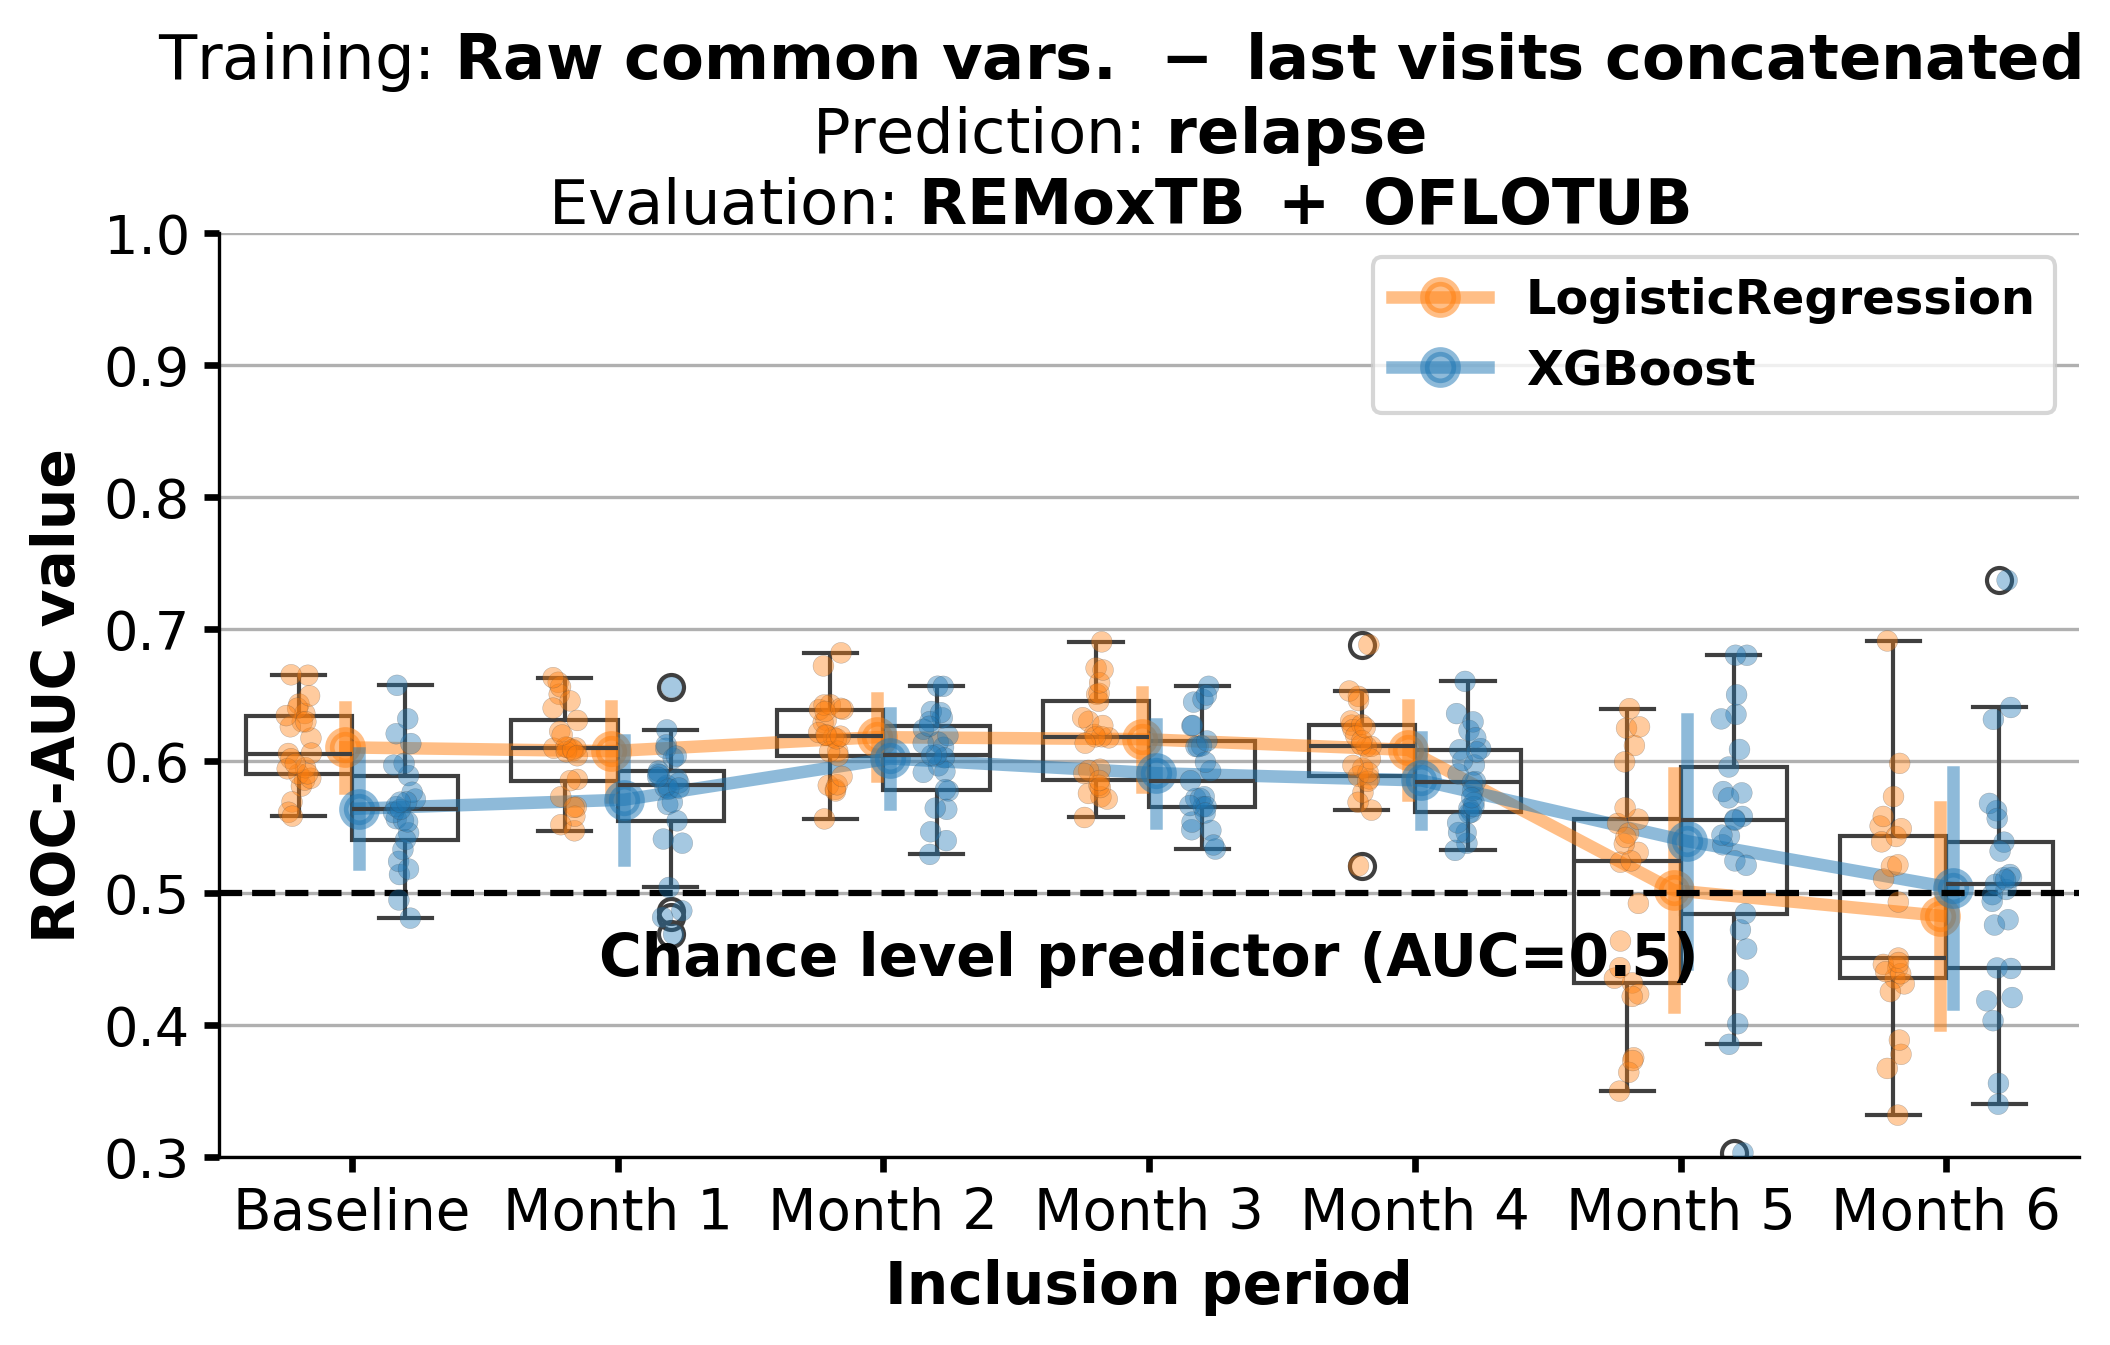

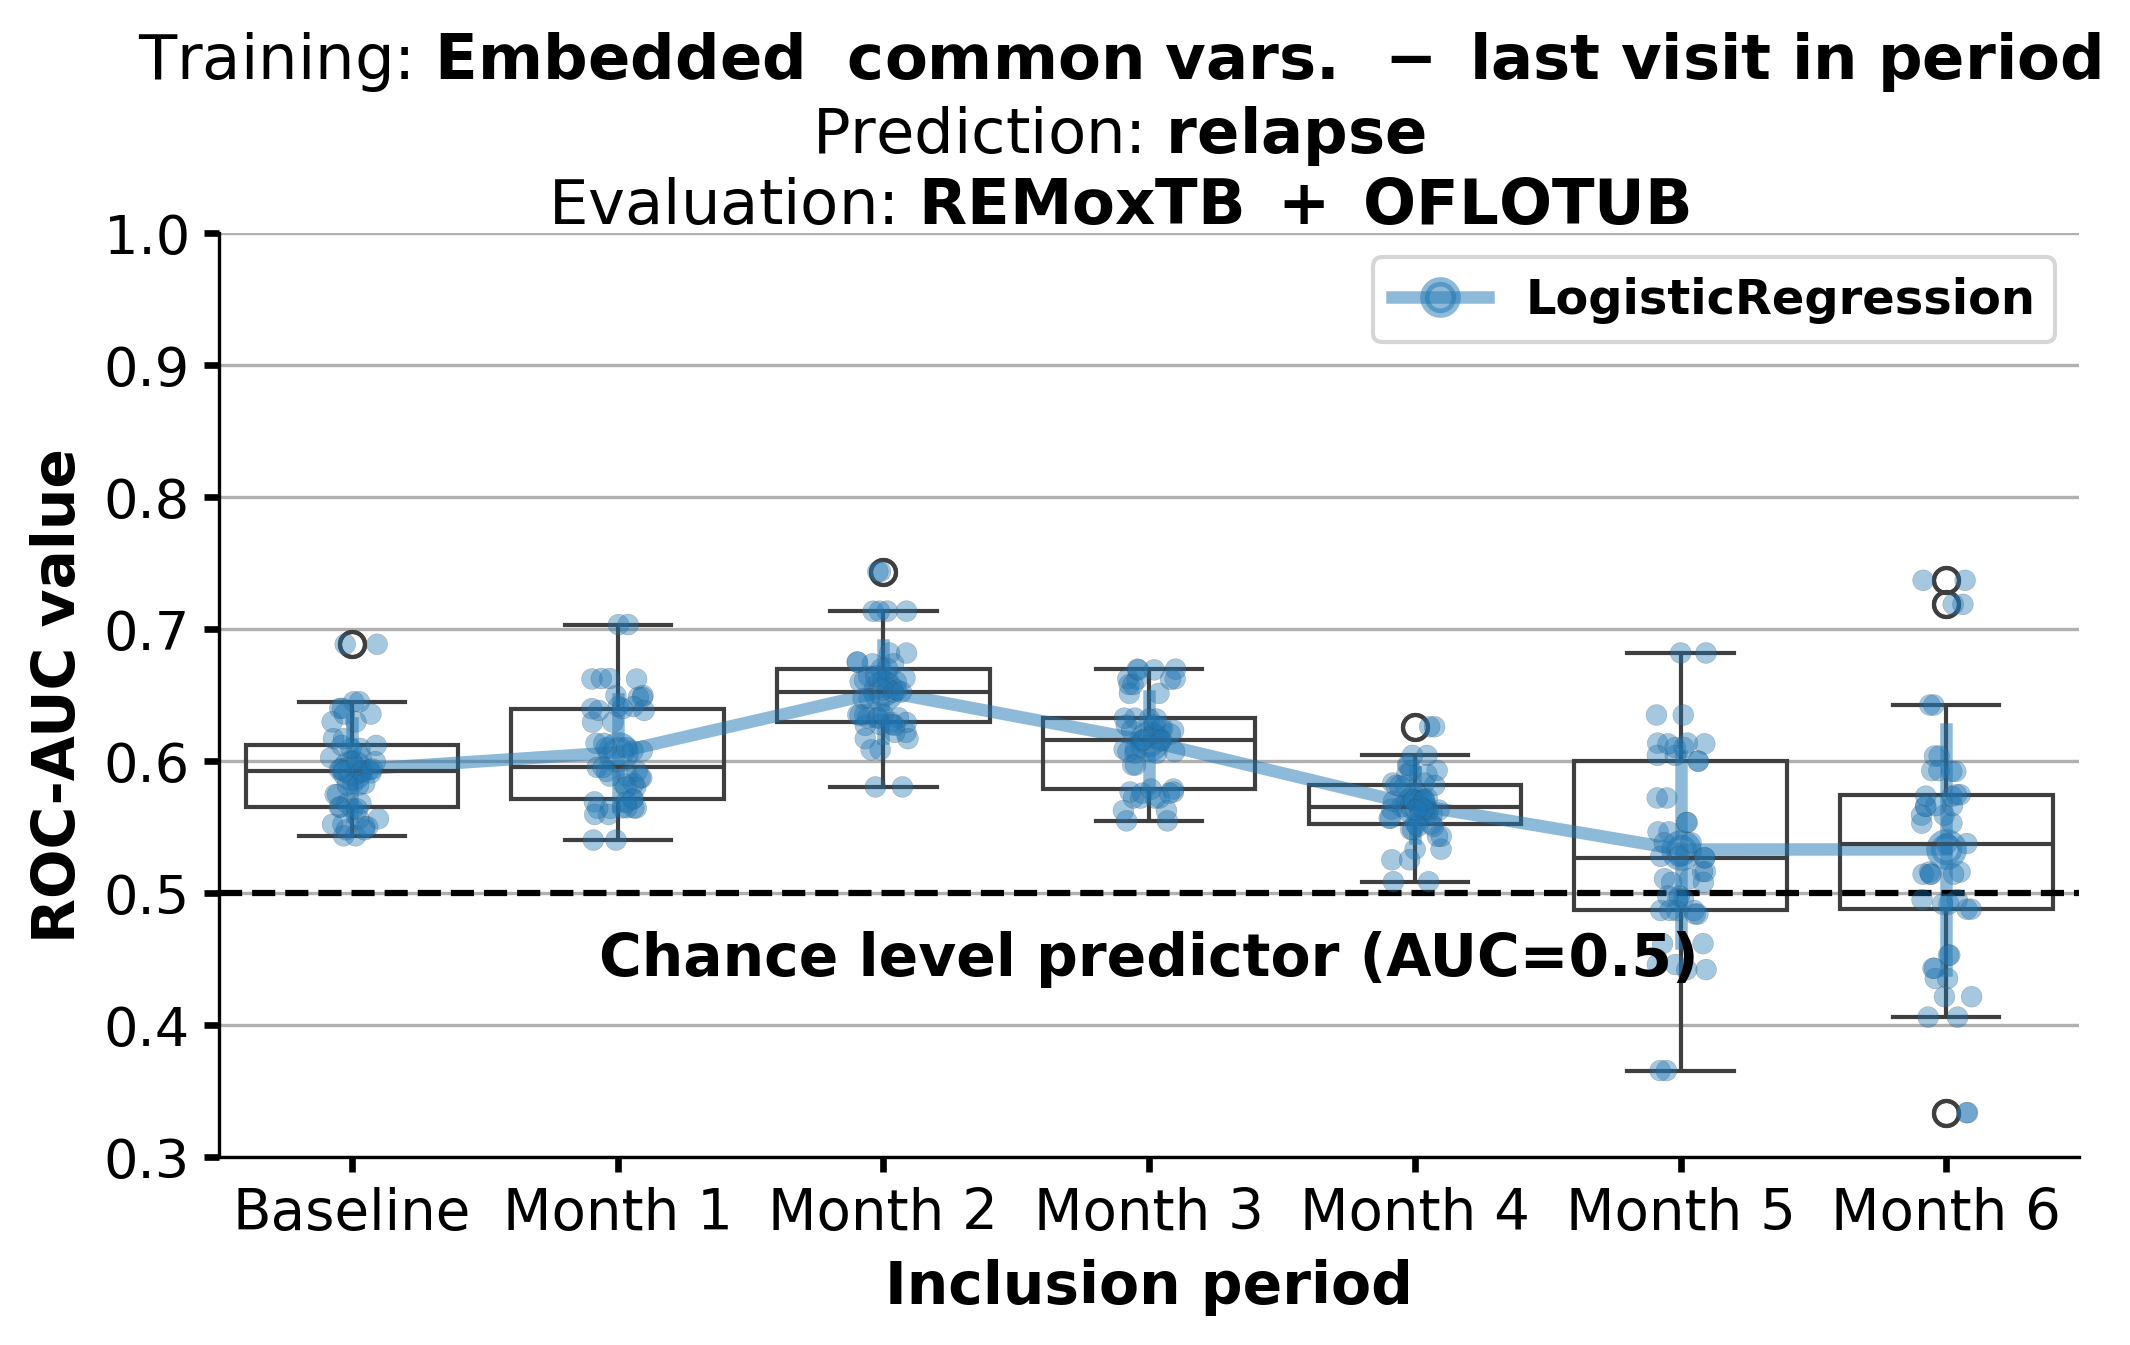

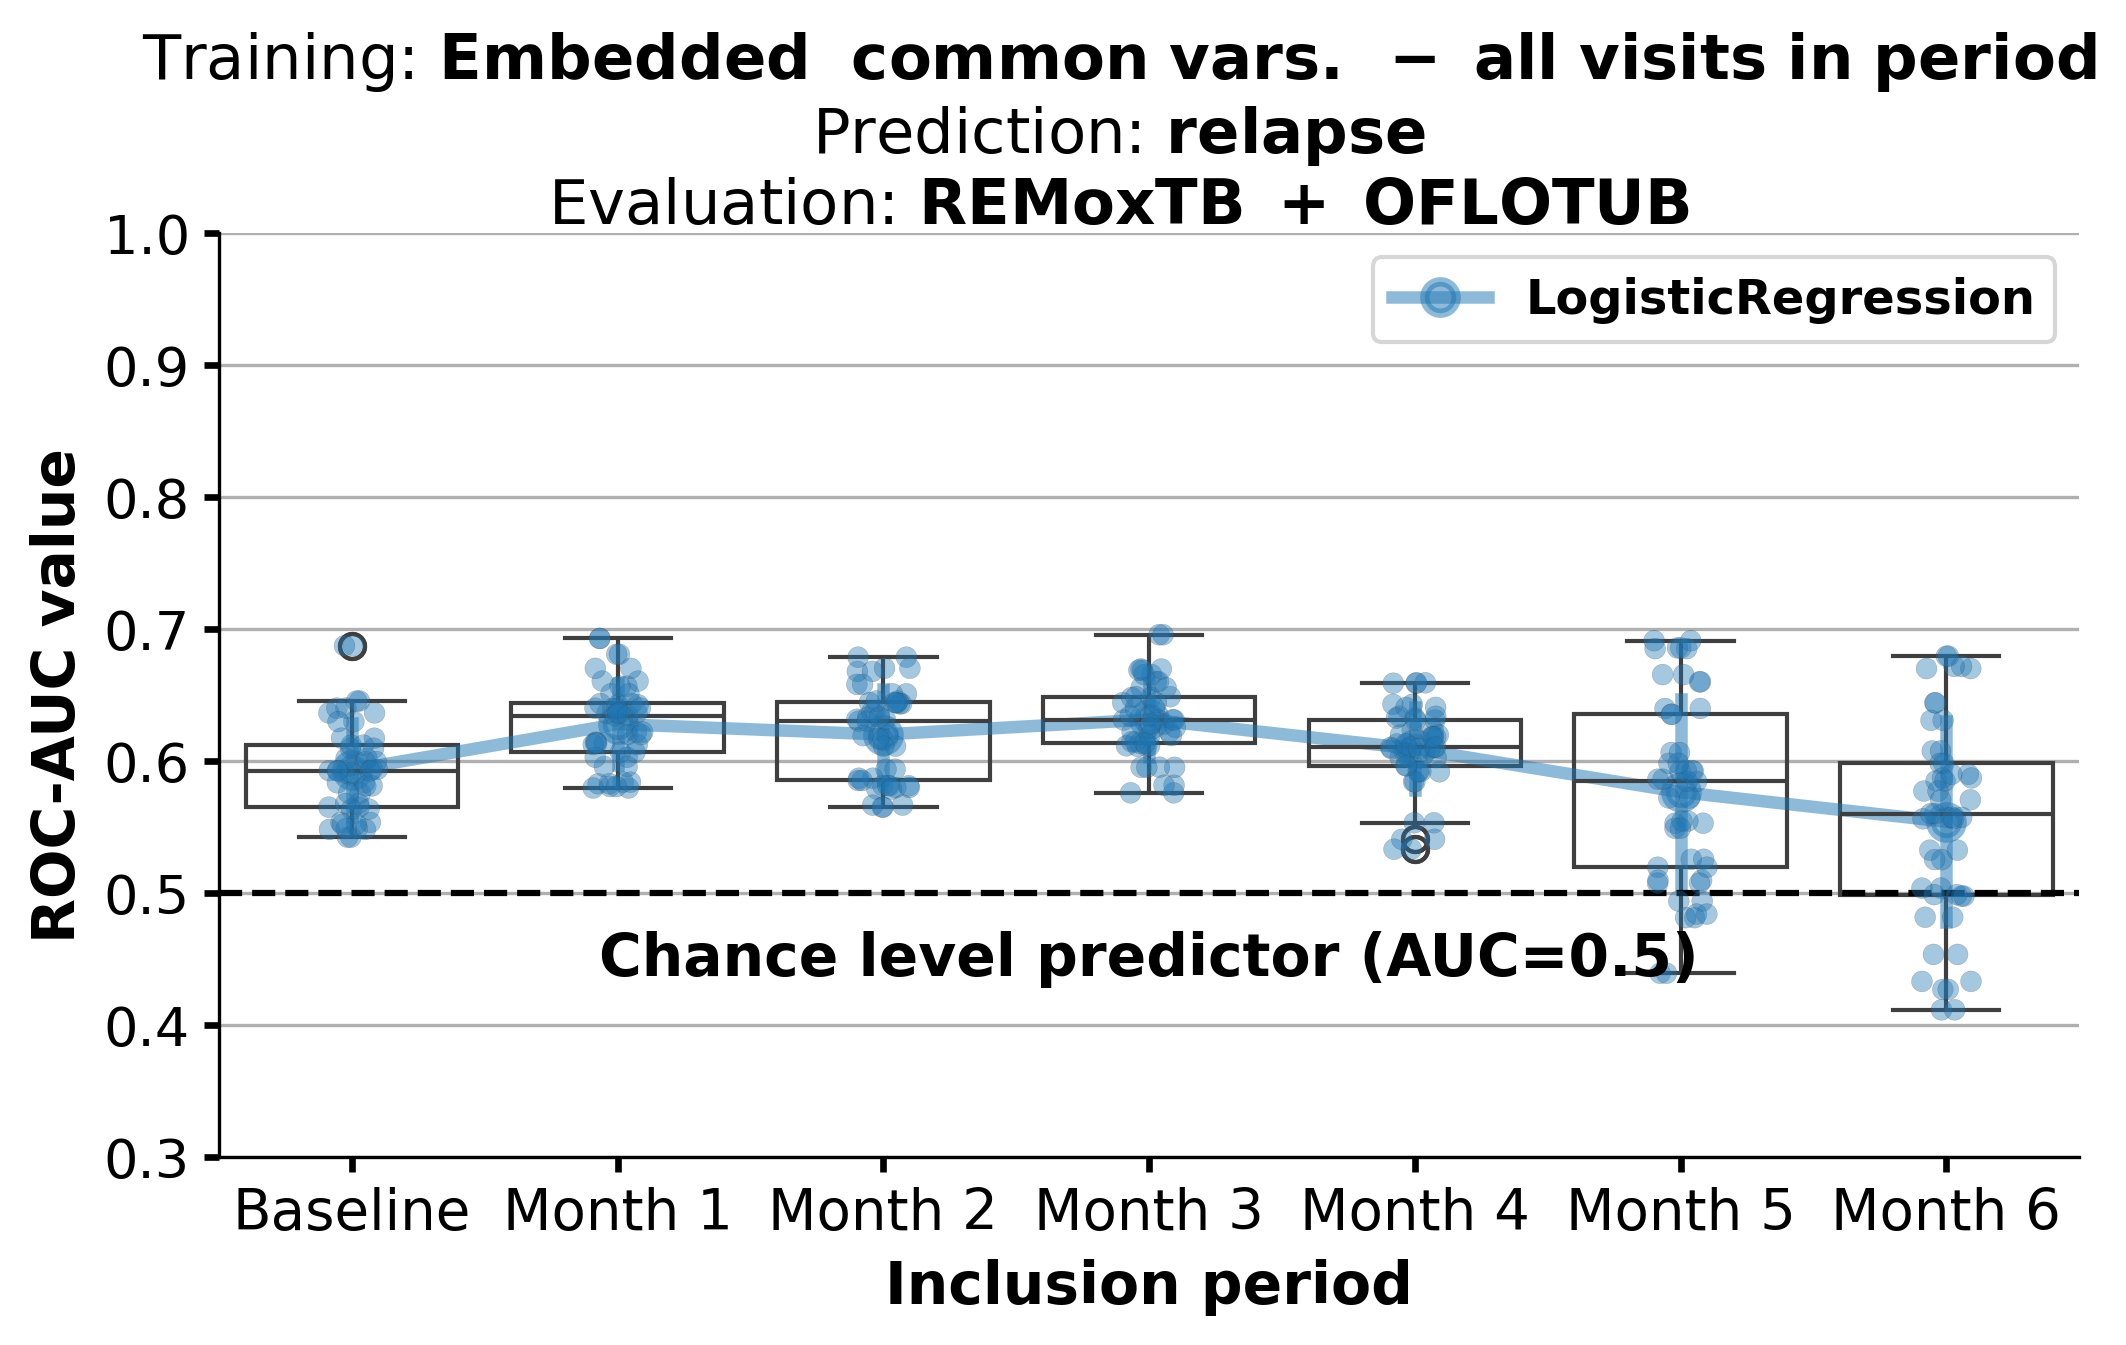

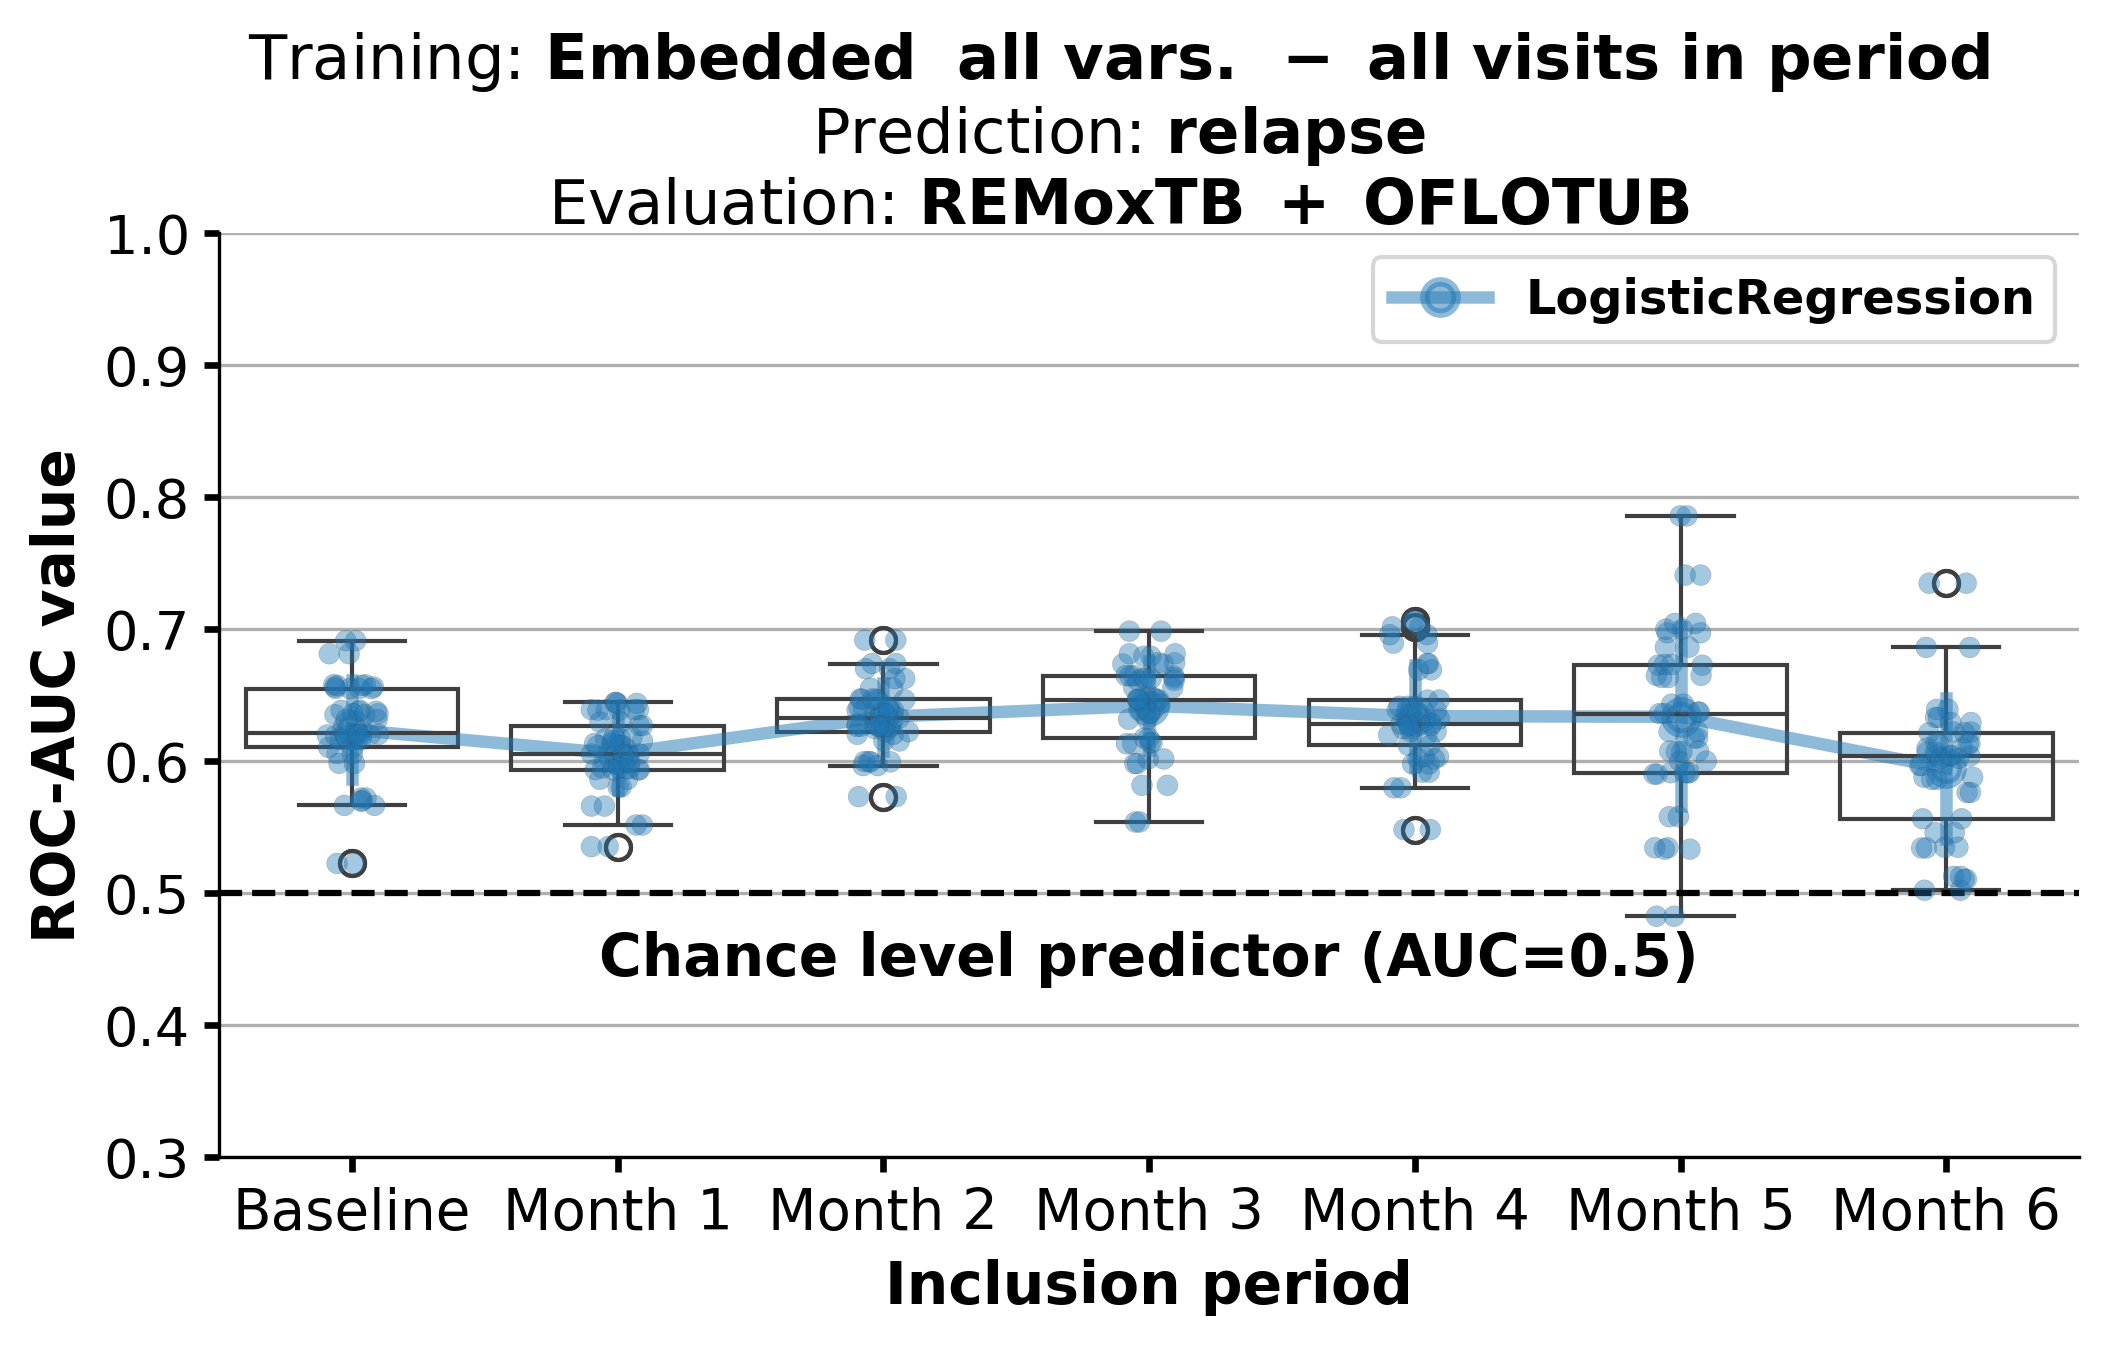

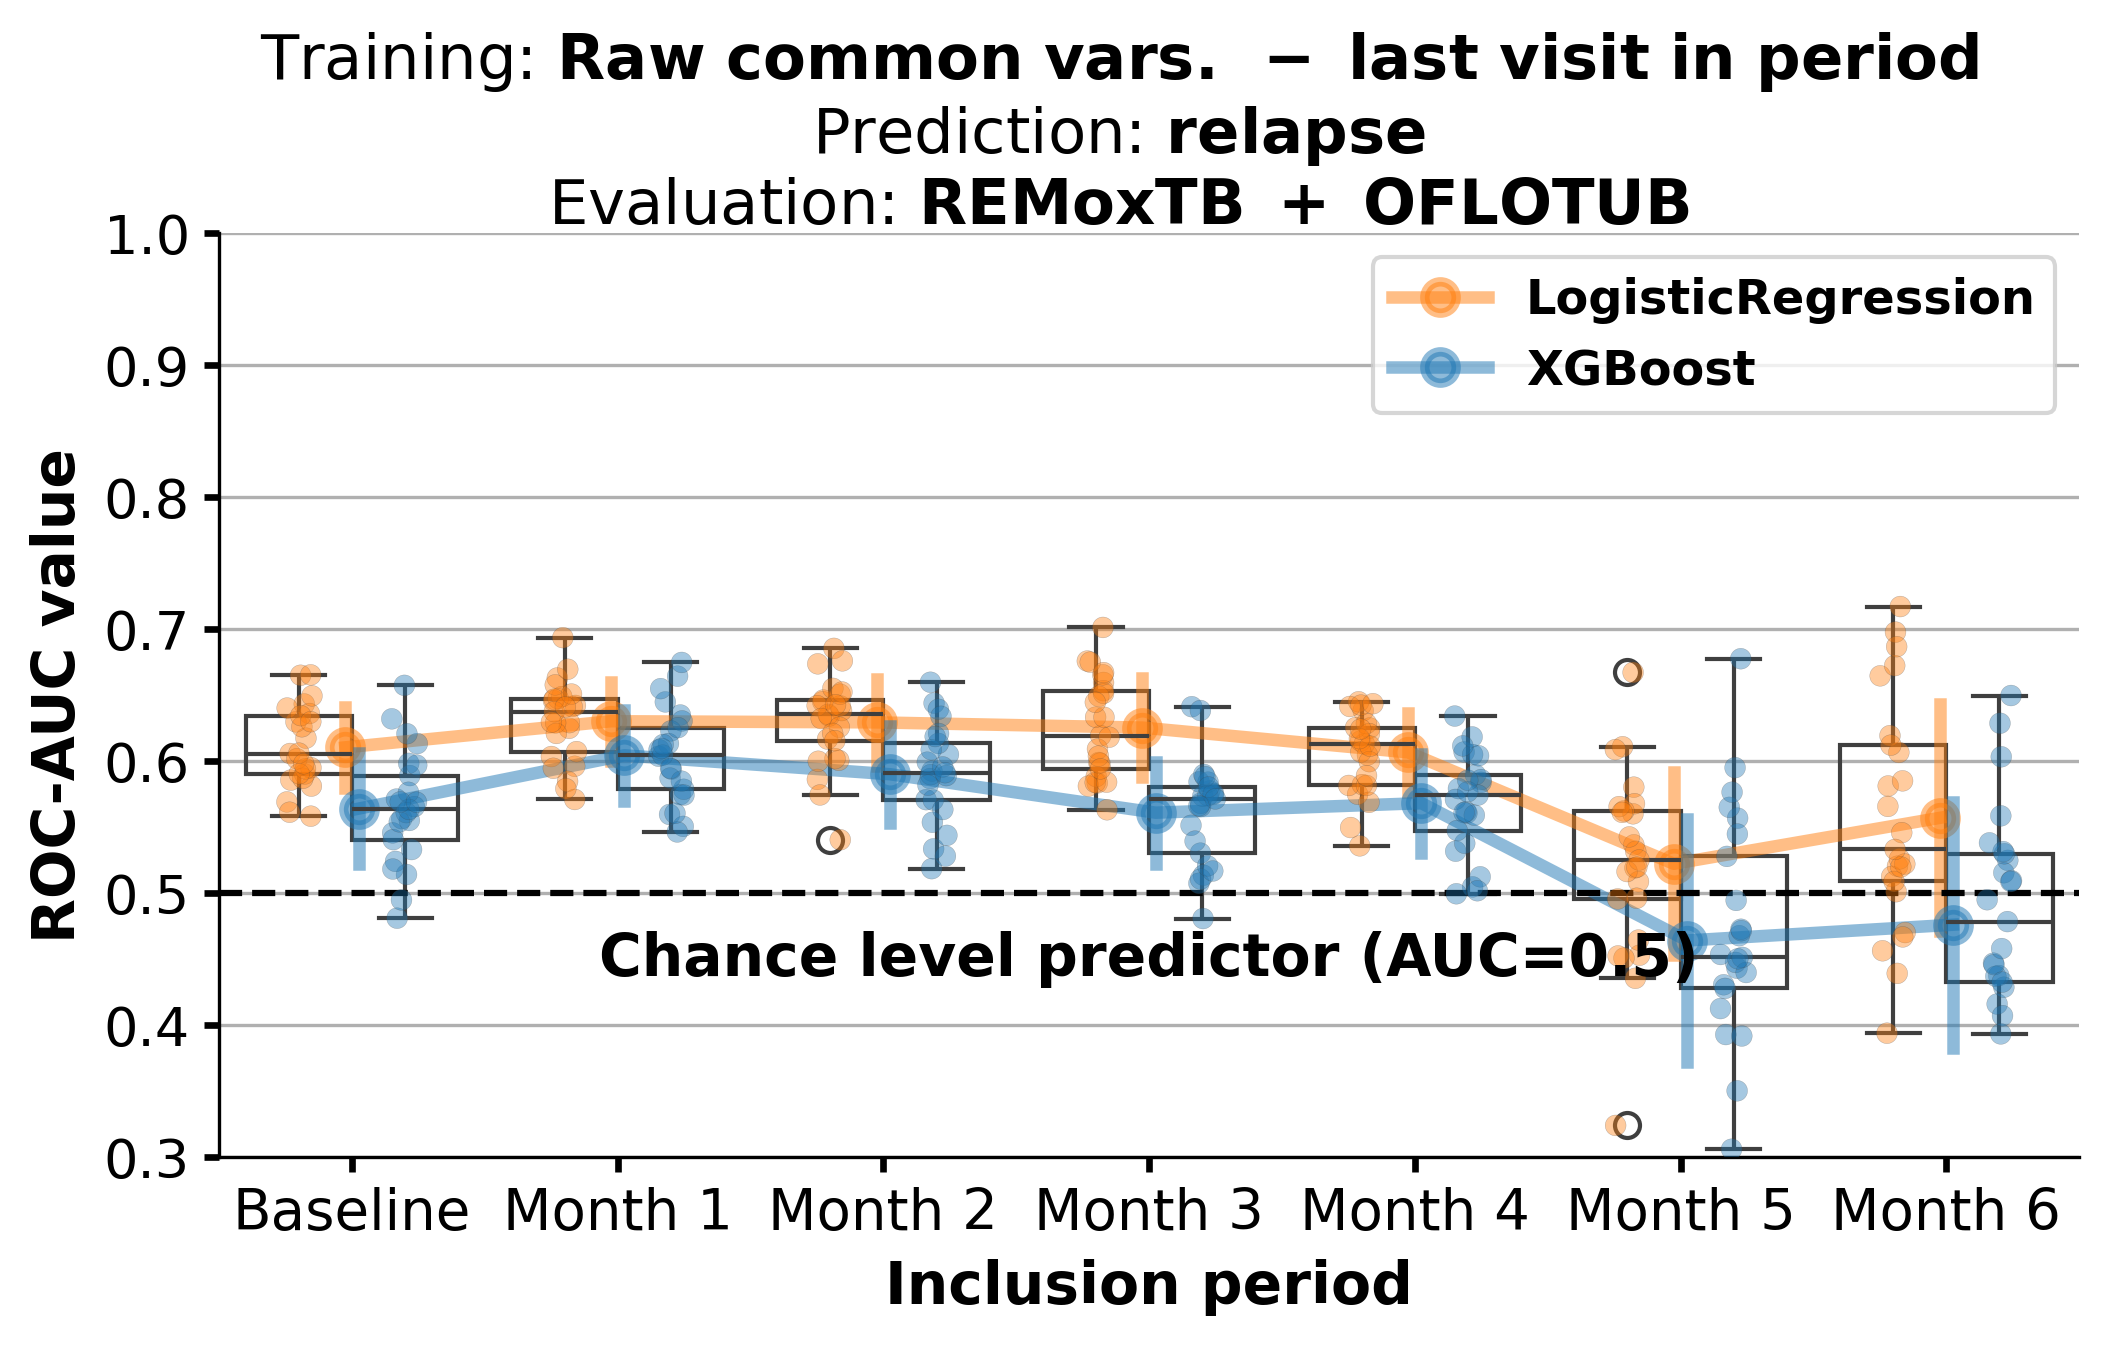

In [5]:
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings("ignore")

figtitle_size=15
subtitle_size=15
x_tick_size=13.5
y_tick_size=13
y_label_size=14
legend_fontsize=11.5
axis_lw=1.6

suptitle_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMoxTB + OFLOTUB',
               'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':'REMoxTB + OFLOTUB',
               'tb21_22_2984_pats_22_vars_relapse':'REMoxTB + OFLOTUB',
              'tb21_1405_pats_40_vars_result_at_end_of_treatment':'REMoxTB',
               'tb21_1405_pats_40_vars_relapse':'REMoxTB',
              'TB-1021':'REMoxTB',
              'TB-1022':'OFLOTUB'}

suptitle_training_type_dict={'all_days':'all variables - all visits in period - embeddings',
                             'baseline_vars':'common variables - all visits in period - embeddings',
                             'baseline_last_day':'common variables - visit at end of period - embeddings'}

data_inclusion_types=['baseline_last_day','baseline_vars','all_days'][:]
plot_split_by_studies=True


model_names=['XGBoost','LogisticRegression','GradientBoost','RandomForest'][:2]
period_end_days=['baseline',31,62,93,125,160,'all']
period_end_days_for_plot=period_end_days[:]

### loop over ML models, train them & training results in a dictionary
idx_list=[0,2]
#for idx in idx_list:
#    data_param_key=[*parameters_for_analysis][idx]
    
#for data_param_key in [*parameters_for_analysis][2:4]:
for data_param_key in [*parameters_for_analysis][2:3]:
    print(data_param_key)

    data_dir_=f'../data/test_roc_auc_values/baseline_LLM_concat'
    fn=os.path.join(data_dir_,
                    #f'{data_param_key}_test_ROC_AUC_across_time_per_study.csv') 
                    f'{data_param_key}_test_ROC_AUC_across_time_all_studies.csv')   

    try:
        roc_auc_concat_df=pd.read_csv(fn,index_col=0,low_memory=False)
    except FileNotFoundError:
        print(f"{fn} not found! Skipping to next element!")
        



    for setup in roc_auc_concat_df['setup'].unique():
        #print('setup',setup)
        exp_setup=setup.replace('Baseline vars','Common vars')
        exp_setup = exp_setup.replace('LLM','LLM embeddings - ')
        exp_setup = exp_setup.replace(' ','_').replace('-','__')
        print('========\n',f"{data_param_key}_{exp_setup}")

        fig,ax=plt.subplots(1,1,figsize=(8,4))
        
        plot_df=roc_auc_concat_df[roc_auc_concat_df['setup']==setup]        
        
        custom_order = ['baseline', '31', '62', '93', '125', '160', 'all']
        
        ## IF not all periods were considered, shorten the ordered list of periods
        num_of_periods_ = plot_df['inclusion_period'].unique().shape[0]
        custom_order_=custom_order[:num_of_periods_]
            
        # Make sure the column is treated as a categorical with a custom order
        plot_df['inclusion_period'] = pd.Categorical(plot_df['inclusion_period'], categories=custom_order_, ordered=True)

        hue='model_name'
        

        print()
        #print(plot_df.groupby(['inclusion_period',hue]).apply(lambda x: x['ROC_AUC_score'].mean()))

        ### CREATE CUSTOM PALETTE FOR SETUPS
        models=np.sort(plot_df[hue].unique())[::-1]
        model_colors = plt.cm.get_cmap('tab10', 10)  # Use a colormap with enough distinct colors
        model_color_mapping = {setup: model_colors(i) for i, setup in enumerate(models)}

        hue_ = 'model_name'# if len(plot_df['model_name'].unique())>1 else None
        model_color_mapping_ = model_color_mapping #if len(plot_df['model_name'].unique())>1 else None
        dodge= True if len(plot_df['model_name'].unique())>1 else False
                        
        sns.boxplot(data=plot_df,x='inclusion_period',hue=hue_,
                    y='ROC_AUC_score',ax=ax,boxprops={'fill': None},legend=False,
                   palette=model_color_mapping_)
        
        sns.stripplot(data=plot_df, x='inclusion_period',
                      hue=hue_, 
                      y='ROC_AUC_score', ax=ax, #color='black',
                      size=5, jitter=0.1, alpha=0.4, dodge=dodge,legend=False,linewidth=0.1,
                     palette=model_color_mapping_)
        
        sns.pointplot(data=plot_df,x='inclusion_period',
                      hue=hue_,
                      y='ROC_AUC_score',ax=ax,
                      linewidth=3,
                      errorbar='sd',alpha=0.5,dodge=dodge,
                      palette=model_color_mapping_)
    
        
        ax.set_ylabel('ROC-AUC value',fontsize=y_label_size,fontweight='bold')
        ax.set_xlabel('Inclusion period',fontsize=y_label_size,fontweight='bold')
        
        ## Convert days to months for xticklabels
        xticklabels=['Month 6' if day == 'all' 
                        else 'Baseline' if day == 'baseline' 
                        else f'Month {int(np.floor(int(day)/30))}' if isinstance(day, int) 
                        else None 
                        for day in period_end_days_for_plot]
    
        ax.set_xticklabels(xticklabels, fontsize=x_tick_size) #weight='bold'
        #ax.set_title(f"{'_'.join([llm_model_name,fine_tuned_tag])} - Test set ROC-AUC")
        ax.set_ylim(0.3,1) 
    
        # Adjust legend: changing font size and handle size
        h, l = ax.get_legend_handles_labels()
        legend = ax.legend(h, l, title='Models', loc='best',title_fontsize=12,handlelength=2)
        
        ax.legend(h,l,frameon=True,framealpha=0.5,
                            prop={'weight':'bold','size':legend_fontsize})
    
    
    
        ## PLot chance predicor's line at 0.5
        ax.axhline(y=0.5,color='black', linestyle='dashed')
        range_mean=(ax.get_xlim()[1]+ ax.get_xlim()[0])/2
        ax.text(range_mean,0.45,'Chance level predictor (AUC=0.5)',fontsize=y_label_size,fontweight='bold',
                            rotation=0,horizontalalignment='center', verticalalignment='center',rotation_mode='default')
    
        # increase tick width
        ax.tick_params(width=axis_lw)
        ax.tick_params(axis='y',labelsize=y_tick_size)
    
        
        '''
        if data_param_key in suptitle_dict.keys():
                study_names=suptitle_dict[data_param_key]
                if 'relapse' not in data_param_key:
                    prediction_time=data_param_key.split('at_')[-1].replace('_',' ')
                    prediction_time = f'outcome at {prediction_time}'
                if 'relapse' in data_param_key:
                    prediction_time='relapse'
                #train_ds_type=suptitle_training_type_dict[data_inclusion_type]
                train_ds_type=setup.replace('LLM','LLM embeddings - ')
                suptitle= f"{study_names} study \n Training: {train_ds_type}\nPrediction: {prediction_time}"
                
        else:   
            suptitle=f"ROC-AUC of CV - {data_param_key} - {data_inclusion_type}" 
        '''
        #if data_param_key in suptitle_dict.keys():
        #study_names=suptitle_dict[data_param_key]
        study_names = return_study_names(data_param_key)
        
        if 'end_of_treatment' in data_param_key:
  
            #prediction_time=data_param_key.split('at_')[-1].replace('_','-')
            prediction_time='end-of-treatment'
            prediction_time = rf"$\bf{{{prediction_time}\ outcome}}$"

    
        if 'relapse' in data_param_key:
            prediction_time='relapse'
            prediction_time = r'$\bf{relapse}$'

        if 'pred_prob' in data_param_key:
            prediction_time=parameters_for_analysis[data_param_key]['result_cat'].replace('_',' ').replace(' ',r'\ ')
            prediction_time = rf'$\bf{{{prediction_time}}}$'

        
        if 'LLM' not in setup:
            train_ds_type=setup.replace('Baseline vars','Common vars.')
            train_ds_type=train_ds_type.replace('Common vars.','Raw common vars.')
            train_ds_type=train_ds_type.replace('.  -','. - ')

            if 'mb_only' in data_param_key:
                train_ds_type=train_ds_type.replace('Raw common vars.','Raw microb. vars.')

            if 'without_mb' in data_param_key:
                train_ds_type=train_ds_type.replace('Raw common vars.','Raw vars. wo. microb.')
                
            print('train_ds_type',train_ds_type)
            train_ds_type=train_ds_type.replace(' ',r'\ ')
        
        if 'LLM' in setup:
            #print('sdfsdfdsf',train_ds_type)
            #train_ds_type=train_ds_type.replace('LLM','LLM embeddings - ')
            train_ds_type=setup.replace('Baseline vars','common vars.')
            train_ds_type=train_ds_type.replace('All vars','all vars.')
            train_ds_type=train_ds_type.replace('LLM','Embedded ')
            print('\ntrain_ds_type',train_ds_type,'\n')
            train_ds_type=train_ds_type.replace(' ',r'\ ')       
            
        
        train_ds_type = rf"$\bf{{{train_ds_type}}}$"

        study_names=study_names.replace(' ',r'\ ')
        study_names=rf"$\bf{{{study_names}}}$"
    
        suptitle= f"Training: {train_ds_type}\nPrediction: {prediction_time}\nEvaluation: {study_names}"
      
        #else:   
        #    suptitle=f"ROC-AUC of CV - {data_param_key} - {training_data_type}" 

    
        fig.suptitle(suptitle,fontsize=figtitle_size,fontweight='normal',y=1.05)  
        ax.yaxis.grid(True) 

        ## Add legend
        handles,labels=ax.get_legend_handles_labels()
        
        # Zip, sort by label, then unzip
        sorted_pairs = sorted(zip(labels, handles), key=lambda pair: pair[0])
        sorted_labels, sorted_handles = zip(*sorted_pairs)

        from matplotlib.font_manager import FontProperties
        bold_font = FontProperties(weight='bold', size=legend_fontsize)
        
        # Legend
        ax.legend(handles=sorted_handles, 
                  labels=sorted_labels,
                  prop=bold_font,
                  loc='best')

        ax.spines[['top','right']].set_visible(False)

        
    
        ## SAVE PLOTS
        data_dir_=f'../data/plots/ROC_AUC_plots_across_time/baseline_LLM_concat/{data_param_key}'
        os.makedirs(data_dir_,exist_ok=True)


        fn=os.path.join(data_dir_,
                    f'{exp_setup}_test_ROC_AUC_across_time_across_studies.png')
        fig.savefig(fn, bbox_inches='tight', dpi=300)
        #plt.close()
        

In [29]:
model_color_mapping_

{'LogisticRegression': (0.12156862745098039,
  0.4666666666666667,
  0.7058823529411765,
  1.0)}

## Per study

In [32]:
from sklearn.metrics import roc_auc_score

figtitle_size=15
subtitle_size=15
x_tick_size=13.5
y_tick_size=13
y_label_size=14
legend_fontsize=11.5
axis_lw=1.6

suptitle_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMoxTB + OFLOTUB',
               'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':'REMoxTB + OFLOTUB',
               'tb21_22_2984_pats_22_vars_relapse':'REMoxTB + OFLOTUB',
              'tb21_1405_pats_40_vars_result_at_end_of_treatment':'REMoxTB',
               'tb21_1405_pats_40_vars_relapse':'REMoxTB',
              'TB-1021':'REMoxTB',
              'TB-1022':'OFLOTUB'}

suptitle_training_type_dict={'all_days':'all variables - all visits in period - embeddings',
                             'baseline_vars':'baseline variables - all visits in period - embeddings',
                             'baseline_last_day':'baseline variables - visit at end of period - embeddings'}

data_inclusion_types=['baseline_last_day','baseline_vars','all_days'][:]

model_names=['XGBoost','LogisticRegression','GradientBoost','RandomForest'][:2]

period_end_days=['baseline',31,62,93,125,160,'all']
period_end_days_for_plot=period_end_days[:]
    
for data_param_key in [*parameters_for_analysis][:10]:

    data_dir_=f'../data/test_roc_auc_values/baseline_LLM_concat'
    fn=os.path.join(data_dir_,
                    f'{data_param_key}_test_ROC_AUC_across_time_per_study.csv') 
                    #f'{data_param_key}_test_ROC_AUC_across_time_all_studies.csv')   
    roc_auc_concat_df=pd.read_csv(fn,index_col=0,low_memory=False)



    for setup in roc_auc_concat_df['setup'].unique():

        for split_coln in ['STUDYID','ARM'][:1]:
            roc_auc_concat_df_ = roc_auc_concat_df[roc_auc_concat_df['split_coln']==split_coln]
     

            for split_coln_level in roc_auc_concat_df_['split_coln_level'].unique():
                
    
                fig,ax=plt.subplots(1,1,figsize=(8,4))

                hue='model_name'

                
                
                plot_df=roc_auc_concat_df[(roc_auc_concat_df['setup']==setup)\
                                         &(roc_auc_concat_df['split_coln_level']==split_coln_level)]

                ### CREATE CUSTOM PALETTE FOR SETUPS
                models=np.sort(plot_df[hue].unique())[::-1]
                model_colors = plt.cm.get_cmap('tab10', 10)  # Use a colormap with enough distinct colors
                model_color_mapping = {setup: model_colors(i) for i, setup in enumerate(models)}

                ## Sort by inclusion periods
                #plot_df=roc_auc_concat_df[roc_auc_concat_df['setup']==setup]
                custom_order = ['baseline', '31', '62', '93', '125', '160', 'all']

                ## IF not all periods were considered, shorten the ordered list of periods
                num_of_periods_ = plot_df['inclusion_period'].unique().shape[0]
                custom_order_=custom_order[:num_of_periods_]

                plot_df['inclusion_period'] = pd.Categorical(plot_df['inclusion_period'], categories=custom_order_, ordered=True)
                
                                
                sns.boxplot(data=plot_df,x='inclusion_period',hue=hue,
                            y='ROC_AUC_score',ax=ax,boxprops={'fill': None},legend=False,
                           palette=model_color_mapping)
                sns.stripplot(data=plot_df, x='inclusion_period',hue=hue, 
                              y='ROC_AUC_score', ax=ax, #color='black',
                              size=5, jitter=0.1, alpha=1, dodge=True,legend=False,
                              palette=model_color_mapping)
                sns.pointplot(data=plot_df,x='inclusion_period',hue=hue,
                              y='ROC_AUC_score',ax=ax,
                              errorbar='sd',alpha=0.5,dodge=True,
                              palette=model_color_mapping)
            
                
                ax.set_ylabel('ROC-AUC value',fontsize=y_label_size,fontweight='bold')
                ax.set_xlabel('Inclusion period',fontsize=y_label_size,fontweight='bold')
                
                ## Convert days to months for xticklabels
                xticklabels=[ 'Month 6' if day == 'all' 
                            else 'Baseline' if day == 'baseline' 
                            else f'Month {int(np.floor(int(day)/30))}' if isinstance(day, int) 
                            else None 
                            for day in period_end_days_for_plot]
            
                ax.set_xticklabels(xticklabels, fontsize=x_tick_size) #weight='bold'
                ax.set_ylim(0.3,1) 
            
                # Adjust legend: changing font size and handle size
                h, l = ax.get_legend_handles_labels()
                legend = ax.legend(h, l, title='Models', loc='best',title_fontsize=12,handlelength=2)
                
                ax.legend(h,l,frameon=True,framealpha=0.5,
                                    prop={'weight':'bold','size':legend_fontsize})
            
            
            
                ## PLot chance predicor's line at 0.5
                ax.axhline(y=0.5,color='black', linestyle='dashed')
                range_mean=(ax.get_xlim()[1]+ ax.get_xlim()[0])/2
                ax.text(range_mean,0.45,'Chance level predictor (AUC=0.5)',fontsize=y_label_size,fontweight='bold',
                                    rotation=0,horizontalalignment='center', verticalalignment='center',rotation_mode='default')
            
                # increase tick width
                ax.tick_params(width=axis_lw)
                ax.tick_params(axis='y',labelsize=y_tick_size)
            
                
                '''
                if data_param_key in suptitle_dict.keys():
                        study_names=suptitle_dict[data_param_key]
                    
                        if 'relapse' not in data_param_key:
                            prediction_time=data_param_key.split('at_')[-1].replace('_',' ')
                            prediction_time = f'outcome at {prediction_time}'
                        if 'relapse' in data_param_key:
                            prediction_time='relapse'
                        #train_ds_type=suptitle_training_type_dict[data_inclusion_type]
                        train_ds_type=setup.replace('LLM','LLM embeddings - ')
                        suptitle= f"{study_names} study \n Training: {train_ds_type}\nPrediction: {prediction_time}"
                        
                else:   
                    suptitle=f"ROC-AUC of CV - {data_param_key} - {data_inclusion_type}" 
                '''
                #if data_param_key in suptitle_dict.keys():
                #study_names=suptitle_dict[study]
                study_names = return_study_names(split_coln_level)
                
                if 'relapse' not in data_param_key:
                    #prediction_time=data_param_key.split('at_')[-1].replace('_',' ')
                    #prediction_time=data_param_key.split('at_')[-1].replace('_','-')
                    prediction_time='end-of-treatment'
                    prediction_time = rf"$\bf{{{prediction_time}\ outcome}}$"
         
            
                if 'relapse' in data_param_key:
                    prediction_time='relapse'
                    prediction_time = r'$\bf{relapse}$'
     
                
                if 'LLM' not in setup:
                    train_ds_type=setup.replace('Baseline vars','Common vars.')
                    train_ds_type=train_ds_type.replace('Common vars.','Raw common vars.')
                    train_ds_type=train_ds_type.replace('.  -','. - ')
                    
                    if 'mb_only' in data_param_key:
                        train_ds_type=train_ds_type.replace('Raw common vars.','Raw microb. vars.')
    
                    if 'without_mb' in data_param_key:
                        train_ds_type=train_ds_type.replace('Raw common vars.','Raw vars. wo. microb.')
                    
                    print('train_ds_type',train_ds_type)
                    train_ds_type=train_ds_type.replace(' ',r'\ ')
                
                if 'LLM' in setup:
                    #print('sdfsdfdsf',train_ds_type)
                    #train_ds_type=train_ds_type.replace('LLM','LLM embeddings - ')
                    train_ds_type=setup.replace('Baseline vars','common vars.')
                    train_ds_type=train_ds_type.replace('All vars','all vars.')
                    train_ds_type=train_ds_type.replace('LLM','Embedded ')
                    print('train_ds_type',train_ds_type)
                    train_ds_type=train_ds_type.replace(' ',r'\ ')
                    
                    
                train_ds_type = rf"$\bf{{{train_ds_type}}}$"
    
                study_names=study_names.replace(' ',r'\ ')
                study_names=rf"$\bf{{{study_names}}}$"
            
                suptitle= f"Training: {train_ds_type}\nPrediction: {prediction_time}\nEvaluation: {study_names}"
          
                #else:   
                #    suptitle=f"ROC-AUC of CV - {data_param_key}"# - {training_data_type}" 
                
            
                fig.suptitle(suptitle,fontsize=figtitle_size,fontweight='normal',y=1.05)  
                
                #ax.set_title(f"{suptitle_dict[study]}",fontsize=subtitle_size)
                ax.yaxis.grid(True) 

                ## Add legend
                handles,labels=ax.get_legend_handles_labels()
                
                # Zip, sort by label, then unzip
                sorted_pairs = sorted(zip(labels, handles), key=lambda pair: pair[0])
                sorted_labels, sorted_handles = zip(*sorted_pairs)

                from matplotlib.font_manager import FontProperties
                bold_font = FontProperties(weight='bold', size=legend_fontsize)
                
                # Now use in legend
                ax.legend(handles=sorted_handles, 
                          labels=sorted_labels,
                          prop=bold_font,
                          loc='best')
        
                ax.spines[['top','right']].set_visible(False)
            
            
                ## SAVE PLOTS
                data_dir_=f'../data/plots/ROC_AUC_plots_across_time/baseline_LLM_concat/{data_param_key}/split_by_{split_coln}'
                os.makedirs(data_dir_,exist_ok=True)
            
                exp_setup=setup.replace('Baseline vars','Common vars')
                exp_setup = exp_setup.replace('LLM','LLM embeddings - ')
                exp_setup = exp_setup.replace(' ','_').replace('-','__')
                split_coln_level_=split_coln_level.replace('/','_')
                fn=os.path.join(data_dir_,
                            f'{exp_setup}_test_ROC_AUC_across_time_per_study_{split_coln_level_}.png')
                #print(f'{data_param_key}_{exp_setup}_test_ROC_AUC_across_time_per_study_{study}.png')
                fig.savefig(fn, bbox_inches='tight', dpi=300)
                plt.close()
    
        

train_ds_type Raw common vars. - last visits concatenated
train_ds_type Raw common vars. - last visits concatenated
train_ds_type Embedded  common vars. - last visit in period
train_ds_type Embedded  common vars. - last visit in period
train_ds_type Embedded  common vars. - all visits in period
train_ds_type Embedded  common vars. - all visits in period
train_ds_type Embedded  all vars. - all visits in period
train_ds_type Embedded  all vars. - all visits in period
train_ds_type Raw common vars. - last visit in period
train_ds_type Raw common vars. - last visit in period
train_ds_type Raw common vars. - last visits concatenated
train_ds_type Raw common vars. - last visits concatenated
train_ds_type Embedded  common vars. - last visit in period
train_ds_type Embedded  common vars. - last visit in period
train_ds_type Embedded  common vars. - all visits in period
train_ds_type Embedded  common vars. - all visits in period
train_ds_type Embedded  all vars. - all visits in period
train_ds_

## Per Arm

In [33]:
from sklearn.metrics import roc_auc_score

figtitle_size=15
subtitle_size=15
x_tick_size=13.5
y_tick_size=13
y_label_size=14
legend_fontsize=11.5
axis_lw=1.6

suptitle_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMoxTB + OFLOTUB',
               'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':'REMoxTB + OFLOTUB',
               'tb21_22_2984_pats_22_vars_relapse':'REMoxTB + OFLOTUB',
              'tb21_1405_pats_40_vars_result_at_end_of_treatment':'REMoxTB',
               'tb21_1405_pats_40_vars_relapse':'REMoxTB',
              'TB-1021':'REMoxTB',
              'TB-1022':'OFLOTUB'}


arm_study_dict={'2EHRZ/4HR':'REMoxTB',
               '2EMRZ/2MR':'REMoxTB',
               '2MHRZ/2MHR':'REMoxTB',
               'Control (6 month)':'OFLOTUB',
               'Gatifloxacin (4 month)':'OFLOTUB'}

suptitle_training_type_dict={'all_days':'all variables - all visits in period - embeddings',
                             'baseline_vars':'baseline variables - all visits in period - embeddings',
                             'baseline_last_day':'baseline variables - visit at end of period - embeddings'}


data_inclusion_types=['baseline_last_day','baseline_vars','all_days'][:]

model_names=['XGBoost','LogisticRegression','GradientBoost','RandomForest'][:2]

period_end_days=['baseline',31,62,93,125,160,'all']
period_end_days_for_plot=period_end_days[:]
    
for data_param_key in [*parameters_for_analysis][:1]:

    data_dir_=f'../data/test_roc_auc_values/baseline_LLM_concat'
    fn=os.path.join(data_dir_,
                    f'{data_param_key}_test_ROC_AUC_across_time_per_study.csv') 
                    #f'{data_param_key}_test_ROC_AUC_across_time_all_studies.csv')   
    roc_auc_concat_df=pd.read_csv(fn,index_col=0,low_memory=False)



    for setup in roc_auc_concat_df['setup'].unique():
        exp_setup=setup.replace('Baseline vars','Common vars')
        exp_setup = exp_setup.replace('LLM','LLM embeddings - ')
        exp_setup = exp_setup.replace(' ','_').replace('-','__')

        for split_coln in ['STUDYID','ARM'][1:]:
            roc_auc_concat_df_ = roc_auc_concat_df[roc_auc_concat_df['split_coln']==split_coln]

            roc_auc_concat_df_['split_coln_level']=roc_auc_concat_df_['split_coln_level'].replace({'Gati-arm regimen (4 month regimen)':'Gatifloxacin (4 month)',
                                                                 'Control-arm regimen (6 month regimen)':'Control (6 month)'},regex=False)

            for split_coln_level in roc_auc_concat_df_['split_coln_level'].unique():
                
    
                fig,ax=plt.subplots(1,1,figsize=(8,4))

                hue='model_name'
                
                
                plot_df=roc_auc_concat_df_[(roc_auc_concat_df_['setup']==setup)\
                                         &(roc_auc_concat_df_['split_coln_level']==split_coln_level)]

                
                ### CREATE CUSTOM PALETTE FOR SETUPS
                models=np.sort(plot_df[hue].unique())[::-1]
                model_colors = plt.cm.get_cmap('tab10', 10)  # Use a colormap with enough distinct colors
                model_color_mapping = {setup: model_colors(i) for i, setup in enumerate(models)}

                ## Sort by inclusion periods
                #plot_df=roc_auc_concat_df[roc_auc_concat_df['setup']==setup]
                custom_order = ['baseline', '31', '62', '93', '125', '160', 'all']
        
                ## IF not all periods were considered, shorten the ordered list of periods
                num_of_periods_ = plot_df['inclusion_period'].unique().shape[0]
                custom_order_=custom_order[:num_of_periods_]
                    
                plot_df['inclusion_period'] = pd.Categorical(plot_df['inclusion_period'], categories=custom_order_, ordered=True)

                print()
                print(split_coln_level,exp_setup)
                print(plot_df.groupby(['inclusion_period',hue]).apply(lambda x: x['ROC_AUC_score'].mean()))
                
                                
                sns.boxplot(data=plot_df,x='inclusion_period',hue=hue,
                            y='ROC_AUC_score',ax=ax,boxprops={'fill': None},legend=False,
                           palette=model_color_mapping)
                sns.stripplot(data=plot_df, x='inclusion_period',hue=hue, 
                              y='ROC_AUC_score', ax=ax, #color='black',
                              size=5, jitter=0.1, alpha=1, dodge=True,legend=False,
                              palette=model_color_mapping)
                sns.pointplot(data=plot_df,x='inclusion_period',hue=hue,
                              y='ROC_AUC_score',ax=ax,
                              errorbar='sd',alpha=0.5,dodge=True,
                              palette=model_color_mapping)
            
                
                ax.set_ylabel('ROC-AUC value',fontsize=y_label_size,fontweight='bold')
                ax.set_xlabel('Inclusion period',fontsize=y_label_size,fontweight='bold')
                
                ## Convert days to months for xticklabels
                xticklabels=[ 'Month 6' if day == 'all' 
                            else 'Baseline' if day == 'baseline' 
                            else f'Month {int(np.floor(int(day)/30))}' if isinstance(day, int) 
                            else None 
                            for day in period_end_days_for_plot]
            
                ax.set_xticklabels(xticklabels, fontsize=x_tick_size) #weight='bold'
                ax.set_ylim(0.2,1) 
            
                # Adjust legend: changing font size and handle size
                h, l = ax.get_legend_handles_labels()
                legend = ax.legend(h, l, title='Models', loc='best',title_fontsize=12,handlelength=2)
                
                ax.legend(h,l,frameon=True,framealpha=0.5,
                                    prop={'weight':'bold','size':legend_fontsize})
            
            
            
                ## PLot chance predicor's line at 0.5
                ax.axhline(y=0.5,color='black', linestyle='dashed')
                range_mean=(ax.get_xlim()[1]+ ax.get_xlim()[0])/2
                ax.text(range_mean,0.45,'Chance level predictor (AUC=0.5)',fontsize=y_label_size,fontweight='bold',
                                    rotation=0,horizontalalignment='center', verticalalignment='center',rotation_mode='default')
            
                # increase tick width
                ax.tick_params(width=axis_lw)
                ax.tick_params(axis='y',labelsize=y_tick_size)
            
                
                '''
                if data_param_key in suptitle_dict.keys():
                        study_names=suptitle_dict[data_param_key]
                    
                        if 'relapse' not in data_param_key:
                            prediction_time=data_param_key.split('at_')[-1].replace('_',' ')
                            prediction_time = f'outcome at {prediction_time}'
                        if 'relapse' in data_param_key:
                            prediction_time='relapse'
                        #train_ds_type=suptitle_training_type_dict[data_inclusion_type]
                        train_ds_type=setup.replace('LLM','LLM embeddings - ')
                        suptitle= f"{study_names} study \n Training: {train_ds_type}\nPrediction: {prediction_time}"
                        
                else:   
                    suptitle=f"ROC-AUC of CV - {data_param_key} - {data_inclusion_type}" 
                '''
                #if data_param_key in suptitle_dict.keys():
                #study_names=suptitle_dict[study]
                study_names = return_study_names(split_coln_level)
                study_=arm_study_dict[study_names]
                
                
                if 'relapse' not in data_param_key:
                    #prediction_time=data_param_key.split('at_')[-1].replace('_',' ')
                    #prediction_time=data_param_key.split('at_')[-1].replace('_','-')
                    prediction_time='end-of-treatment'
                    prediction_time = rf"$\bf{{{prediction_time}\ outcome}}$"
         
            
                if 'relapse' in data_param_key:
                    prediction_time='relapse'
                    prediction_time = r'$\bf{relapse}$'
     
                
                if 'LLM' not in setup:
                    train_ds_type=setup.replace('Baseline vars','Common vars.')
                    train_ds_type=train_ds_type.replace('Common vars.','Raw common vars.')
                    train_ds_type=train_ds_type.replace('.  -','. - ')
                    
                    if 'mb_only' in data_param_key:
                        train_ds_type=train_ds_type.replace('Raw common vars.','Raw microb. vars.')
    
                    if 'without_mb' in data_param_key:
                        train_ds_type=train_ds_type.replace('Raw common vars.','Raw vars. wo. microb.')
                    
                    #print('train_ds_type',train_ds_type)
                    train_ds_type=train_ds_type.replace(' ',r'\ ')
                
                if 'LLM' in setup:
                    #print('sdfsdfdsf',train_ds_type)
                    #train_ds_type=train_ds_type.replace('LLM','LLM embeddings - ')
                    train_ds_type=setup.replace('Baseline vars','common vars.')
                    train_ds_type=train_ds_type.replace('All vars','all vars.')
                    train_ds_type=train_ds_type.replace('LLM','Embedded ')
                    print('train_ds_type',train_ds_type)
                    train_ds_type=train_ds_type.replace(' ',r'\ ')
                    
                    
                train_ds_type = rf"$\bf{{{train_ds_type}}}$"

                study_names = f'{study_names} - {study_}'
                study_names=study_names.replace(' ',r'\ ')
                study_names=rf"$\bf{{{study_names}}}$"
            
                suptitle= f"Training: {train_ds_type}\nPrediction: {prediction_time}\nEvaluation: {study_names}"
          
                #else:   
                #    suptitle=f"ROC-AUC of CV - {data_param_key}"# - {training_data_type}" 
                
            
                fig.suptitle(suptitle,fontsize=figtitle_size,fontweight='normal',y=1.05)  
                
                #ax.set_title(f"{suptitle_dict[study]}",fontsize=subtitle_size)
                ax.yaxis.grid(True) 

                ## Add legend
                handles,labels=ax.get_legend_handles_labels()
                
                # Zip, sort by label, then unzip
                sorted_pairs = sorted(zip(labels, handles), key=lambda pair: pair[0])
                sorted_labels, sorted_handles = zip(*sorted_pairs)

                from matplotlib.font_manager import FontProperties
                bold_font = FontProperties(weight='bold', size=legend_fontsize)
                
                # Now use in legend
                ax.legend(handles=sorted_handles, 
                          labels=sorted_labels,
                          prop=bold_font,
                          loc='best')
        
                ax.spines[['top','right']].set_visible(False)
            
            
                ## SAVE PLOTS
                data_dir_=f'../data/plots/ROC_AUC_plots_across_time/baseline_LLM_concat/{data_param_key}/split_by_{split_coln}'
                os.makedirs(data_dir_,exist_ok=True)
            

                split_coln_level_=split_coln_level.replace('/','_')
                fn=os.path.join(data_dir_,
                            f'{exp_setup}_test_ROC_AUC_across_time_per_study_{split_coln_level_}.png')
                #print(f'{data_param_key}_{exp_setup}_test_ROC_AUC_across_time_per_study_{study}.png')
                fig.savefig(fn, bbox_inches='tight', dpi=300)
                plt.close()
    
        


2EHRZ/4HR Common_vars____last_visits_concatenated
inclusion_period  model_name        
baseline          LogisticRegression    0.568813
                  XGBoost               0.553868
31                LogisticRegression    0.575564
                  XGBoost               0.513663
62                LogisticRegression    0.632702
                  XGBoost               0.647262
93                LogisticRegression    0.612883
                  XGBoost               0.701011
125               LogisticRegression    0.553189
                  XGBoost               0.509722
160               LogisticRegression    0.720976
                  XGBoost               0.696375
dtype: float64

Control (6 month) Common_vars____last_visits_concatenated
inclusion_period  model_name        
baseline          LogisticRegression    0.567552
                  XGBoost               0.513803
31                LogisticRegression    0.612588
                  XGBoost               0.518909
62               

In [ ]:
study_names
arm_study_dict.keys()

In [ ]:
roc_auc_concat_df['split_coln_level'].unique()

# ROC-AUC ACROSS TIME - LSTM

In [ ]:
import warnings
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)
import matplotlib as mpl
from sklearn.metrics import roc_auc_score
import itertools
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches


import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300

figtitle_size=20
subplot_title_size=16
#ylabel_size=12
y_label_size=15
text_size=18
legend_title_fontsize=13
scatter_dot_size=10
dot_size=7
x_tick_size=14
y_tick_size=14
figtitle_size=18
subtitle_size=16
x_tick_size=18
y_tick_size=13
y_label_size=17
legend_fontsize=11.5
axis_lw=1.6

figtitle_size=15
subtitle_size=15
x_tick_size=13.5
y_tick_size=13
y_label_size=14
legend_fontsize=11.5
axis_lw=1.6


#model_names=['LSTM']
#train_dataset_types=['raw','log']

period_end_days=['baseline',31,62,93,125,160,'all']
period_end_days_for_plot=period_end_days[:]


suptitle_dict={'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':'REMoxTB+ OFLOTUB',
               'tb21_22_2984_pats_22_vars_relapse':'REMoxTB+ OFLOTUB',
              'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMoxTB'}

model_complexities=['day_only','regimen_only','full']

for model_complex in model_complexities[2:3]:
    
    for data_param_key in [*parameters_for_analysis][:2]:

        outcome_label=parameters_for_analysis[data_param_key]['result_cat']

        df_list=[]
        for period_end_day in period_end_days[:]:

            if outcome_label=='RESULT_AT_END_OF_TREATMENT' and period_end_day=='all':
                continue
            
        
            #fname=f'../data/{data_param_key}_LSTM_class_results_{model_complex}_model.pickle'
            fname=f'../data/{data_param_key}_LSTM_class_results_{model_complex}_model_{period_end_day}_days_training_results.pickle'
            if os.path.exists(fname):
                with open(fname,'rb') as f:
                    result_dict=pickle.load(f)
    
            
            for categorical_map_name in [*result_dict][:1]:
                #categorical_map=categorical_map_dict[categorical_map_name]
                #training_data_results=result_dict[categorical_map_name]['train_data_results']
                test_data_results=result_dict['test_data_results']
    
    
                #for training_method in training_methods[:1]:  
    
                #if training_method=='training_on_first_x_days':
                #    training_days=training_data_results['training_on_first_x_days']['training_days']
                
                cv_results={}
                #for train_ds_type in train_dataset_types:
                
                roc_list,cv_rep_list,period_list=[],[],[]

                #print(training_data_results.keys())[cv_rep]['results'].keys())
                
                for cv_rep in [*test_data_results]:
                    k_fold_results=test_data_results[cv_rep]['results'][0]
                    
                    
                    n=0
                    
                    #for k_fold in [*k_fold_results]:
                        #print(k_fold_results[k_fold].keys())
                    '''
                    model_name='LSTM'
                    model_name=''
                    actual_y=model_name+'y'
                    #y_train_name=model_name+'_y_with_index'
                    predicted_label=model_name+'predicted_label'
                    predicted_prob=model_name+'predicted_prob'
                    cross_entropy_weights_dict=model_name+'cross_entropy_weights_dict'
                    sample_weights=np.vectorize(k_fold_results[cross_entropy_weights_dict].get)(k_fold_results[predicted_label])

                    y_score  = list(itertools.chain(*[k_fold_results[predicted_prob][n] for n in range(len(k_fold_results[predicted_prob]))]))
                    auc_score=roc_auc_score(y_true=k_fold_results[actual_y],
                                            y_score=y_score,
                                            sample_weight=sample_weights,
                                            average='macro')
                    '''
                    auc_score =  k_fold_results['roc_auc']


                    roc_list.append(round(auc_score,3))
                    cv_rep_list.append(cv_rep.split('_')[-1])
                    period_list.append(period_end_day)

                cv_results['ROC_AUC_score']=roc_list
                cv_results['CV-repeat']=cv_rep_list
                cv_results['period_used_for_training']=period_list

                df=pd.DataFrame.from_dict(cv_results)
                #df['Training type']=train_ds_type + ' TTP'
                df_list.append(df)
    
        ## Concatenate datqaframes of different training dataset types (i.e.raw TTP - log TTP)
        plot_df=pd.concat(df_list,axis=0)        


        metrics=['ROC_AUC_score'][0:]
        ncols=len(metrics)
        nrows=1
        fig=plt.figure(figsize=(nrows*8,ncols*4))

        for n,scoring_method in enumerate(metrics[0:]):
            ax=fig.add_subplot(nrows,ncols,n+1)
            sns.boxplot(data=plot_df,
                        y=scoring_method,
                        x='period_used_for_training',
                        legend=False,
                        ax=ax,boxprops={'facecolor':'none'})
            sns.stripplot(data=plot_df,
                          y=scoring_method,
                          color='orange',
                          x='period_used_for_training',
                          size=6, jitter=0.1, alpha=1, dodge=True,legend=True)
            sns.pointplot(data=plot_df,
                          y=scoring_method,
                          x='period_used_for_training',
                          legend=False,
                          color='orange',
                          errorbar='sd',
                          alpha=0.5,dodge=True)

            ax.set_ylabel('ROC-AUC value',fontsize=y_label_size,fontweight='bold')
            ax.set_xlabel('Inclusion period',fontsize=y_label_size,fontweight='bold')
            
            ## Convert days to months for xticklabels
            xticklabels=[ 'Month 6' if day == 'all' 
                            else 'Baseline' if day == 'baseline' 
                            else f'Month {int(np.floor(int(day)/30))}' if isinstance(day, int) 
                            else None 
                            for day in period_end_days]
        
            ax.set_xticklabels(xticklabels, fontsize=x_tick_size) #weight='bold'
            #ax.set_title(f"{'_'.join([llm_model_name,fine_tuned_tag])} - Test set ROC-AUC")
            ax.set_ylim(0.3,1) 
        
            # Adjust legend: changing font size and handle size
            #h, l = ax.get_legend_handles_labels()
            #legend = ax.legend(h, l, title='Models', loc='best',title_fontsize=12,handlelength=2)

            legend_handles=[Line2D([0],[0],marker="o",color=c,lw=0,label=l,markerfacecolor=c,markersize=7,)
                                    for l, c in zip(['LSTM'],['orange'])]
            
            ax.legend(handles=legend_handles, 
                      frameon=True,framealpha=0.5,
                                prop={'weight':'bold','size':legend_fontsize})




            
            ## PLot chance predicor's line at 0.5
            ax.axhline(y=0.5,color='black', linestyle='dashed')
            range_mean=(ax.get_xlim()[1]+ ax.get_xlim()[0])/2
            ax.text(range_mean,0.45,'Chance level predictor (AUC=0.5)',fontsize=y_label_size,fontweight='bold',
                                rotation=0,horizontalalignment='center', verticalalignment='center',rotation_mode='default')
        
            # increase tick width
            ax.tick_params(width=axis_lw)
            ax.tick_params(axis='y',labelsize=y_tick_size)

            ax.yaxis.grid(True) 
            ax.spines[['top','right']].set_visible(False)
        
            #plt.tight_layout
    
            if data_param_key in suptitle_dict.keys():
                study_names=suptitle_dict[data_param_key]
                if 'relapse' not in data_param_key:
                    prediction_time=data_param_key.split('at_')[-1].replace('_','-')
                    prediction_time = rf"$\bf{{{prediction_time}\ outcome}}$"
            
                if 'relapse' in data_param_key:
                    prediction_time='relapse'
                    prediction_time = r'$\bf{relapse}$'
    
                
                train_ds_type='Common vars - all visits in period'
                #print('train_ds_type',train_ds_type)
                train_ds_type=train_ds_type.replace(' ',r'\ ')
                train_ds_type = rf"$\bf{{{train_ds_type}}}$"
    
                study_names=study_names.replace(' ',r'\ ')
                study_names=rf"$\bf{{{study_names}}}$"
            
                suptitle= f"Training: {train_ds_type}\nPrediction: {prediction_time}\nEvaluation: {study_names} "
          
            else:   
                suptitle=f"ROC-AUC of CV - {data_param_key}" 
                
            fig.suptitle(suptitle,fontsize=figtitle_size,fontweight='normal',y=1.05)        

            ## SAVE PLOTS
            #data_dir_=f'../data/plots/ROC_AUC_plots_across_time/baseline_LLM_concat/'
            data_dir_=f'../data/plots/ROC_AUC_plots_across_time/baseline_LLM_concat/{data_param_key}'
            os.makedirs(data_dir_,exist_ok=True)
    
            
            exp_setup='Common vars - all visits in period'
            exp_setup = exp_setup.replace(' ','_').replace('-','__')
            fn=os.path.join(data_dir_,
                        f'LSTM_{exp_setup}_test_ROC_AUC_across_time_across_studies.png')

            fig.savefig(fn, bbox_inches='tight', dpi=300)

            ## Save dataframe for later comparison
            plot_df=plot_df.rename(columns={'period_used_for_training':'inclusion_period','CV-repeat':'Num_of_CV_repeat'})
            plot_df['trained_on']='raw_vars'
            plot_df['setup']='baseline_all_days_in_period'
            plot_df['model_name']='LSTM'

            fn=f'../data/test_roc_auc_values/baseline/{data_param_key}_days_LSTM_test_ROC_AUC_across_time_all_studies.csv'
            plot_df.to_csv(fn)
                   
#plt.tight_layout()

In [ ]:
plot_df#['setup'].unique()

# ROC-AUC COMPARISON OF MODELS

## Functions

In [17]:
def calc_paired_t_test_between_exp_setups(plot_df):
    from scipy.stats import ttest_rel,ttest_ind
    
    #plot_df_ = plot_df.loc[~plot_df.duplicated(),:]
    plot_df_ = plot_df.loc[~plot_df.duplicated(subset=['model_name','Num_of_CV_repeat','inclusion_period','trained_on','setup']),:]

    # Get unique values from the 'setup' column
    #unique_setups = plot_df['setup'].unique()
    #unique_setups = [f"{mod_name}_{setup}"for mod_name in plot_df['model_name'].unique() for setup in plot_df['setup'].unique()]
    unique_setups = [f"{setup}_{mod_name}"for mod_name in plot_df['model_name'].unique() for setup in plot_df_['setup'].unique()]
    
    
    # Generate all pairwise combinations
    setup_combinations = list(itertools.combinations(unique_setups, 2))

    
    paired_t_res_dict={}

    #print(setup_combinations)
    
    ## Loop over models
    for model_incl_per, model_incl_per_df in plot_df_.groupby(['inclusion_period']):
        
        ttest_res_df=pd.DataFrame(columns=unique_setups,
                                  index=unique_setups)
        
        #print(ttest_res_df.columns)
        
        for setup_combination in setup_combinations:
            #print(setup_combination)
            #print((setup_combination[0].split('_')[0]))
            #print(setup_combination[0].split('_')[-1])
            #print((setup_combination[1].split('_')[0]))
            #print(setup_combination[1].split('_')[-1])
            #print()
            
    
            model_incl_per_df_1 = model_incl_per_df[(model_incl_per_df['setup']==(setup_combination[0].split('_')[0]))\
                                                &(model_incl_per_df['model_name']==(setup_combination[0].split('_')[-1]))].sort_values('Num_of_CV_repeat')
    
            model_incl_per_df_2 = model_incl_per_df[(model_incl_per_df['setup']==(setup_combination[1].split('_')[0]))\
                                                    &(model_incl_per_df['model_name']==(setup_combination[1].split('_')[-1]))].sort_values('Num_of_CV_repeat')

            #print(model_incl_per_df_1.shape,model_incl_per_df_2.shape)

            if model_incl_per_df_1.shape[0]==0 or model_incl_per_df_2.shape[0]==0:
                continue

            #print(model_incl_per_df_1.shape,model_incl_per_df_2.shape)
            t_stat,pval = ttest_rel(model_incl_per_df_1['ROC_AUC_score'],model_incl_per_df_2['ROC_AUC_score'])
            #t_stat,pval = ttest_ind(model_incl_per_df_1['ROC_AUC_score'],model_incl_per_df_2['ROC_AUC_score'])

            if (model_incl_per_df_1['ROC_AUC_score'].values==model_incl_per_df_2['ROC_AUC_score'].values).all()==True:
                pval=1
    
            ttest_res_df.loc[setup_combination[0],setup_combination[1]]=pval
    
        ## Copy upper triangle to lower triangle to get a dataframe where it is easier to extract the exp. setup comparisons later
        X=ttest_res_df.fillna(0).values
        X = X + X.T - np.diag(np.diag(X))
        ttest_res_df=pd.DataFrame(data=X,
                                  columns=unique_setups,
                                  index=unique_setups)
        ttest_res_df=ttest_res_df.replace(0,np.nan)

        ## Add to dict
        paired_t_res_dict[model_incl_per[0]]=ttest_res_df

    return paired_t_res_dict


#####===========================
def extract_paired_t_test_FDR(ttest_res_df,comparison_1,comparison_2):
    from statsmodels.stats.multitest import multipletests

    #print('ttest_res_df')
    #print(ttest_res_df)
    #print('comparison_1',comparison_1)

    pvalues_df = ttest_res_df.loc[comparison_1,comparison_2]#.dropna()
    #print('pvalues_df\n',pvalues_df)

    if pvalues_df.shape[0]>0:

        # 1. Extract non-NaN p-values
        non_nan_pvalues = pvalues_df.stack().values
        #non_nan_pvalues = pvalues_df.values.flatten()
        #print('non_nan_pvalues',non_nan_pvalues)
        
        # 2. FDR correction
        _, corrected_pvalues, _, _ = multipletests(non_nan_pvalues, alpha=0.05, method='fdr_bh')
        #print('corrected_pvalues',corrected_pvalues)
        
        # 3. Replace corrected p-values back into a symmetric DataFrame
        corrected_pvalues_df = pvalues_df.copy()
        corrected_pvalues_df.loc[:, :] = np.nan  # Reset with NaNs
        
        # Use mask to update non-NaN positions with corrected p-values
        pval_flat=pvalues_df.values.flatten()
        pval_flat[~np.isnan(pval_flat)]=corrected_pvalues
        
        mask = ~pvalues_df.isna()
        corrected_pvalues_df[mask] = pval_flat.reshape(corrected_pvalues_df.shape)
    
        return corrected_pvalues_df
    
    else:
        return None

'''
#####==========
def annotate_fdr(ax, comparison_pairs, fdr_values, y_offset=0.02):
    """
    Annotate FDR-corrected p-values above bars with brackets.

    Args:
        ax: Matplotlib axis.
        comparison_pairs: List of (x1, x2) pairs indicating bar comparisons.
        fdr_values: List of corresponding FDR values for the comparisons.
        y_offset: Vertical offset for annotations.
    """
    for i, ((x1, x2), fdr) in enumerate(zip(comparison_pairs, fdr_values)):
        if fdr < 0.05:  # Only annotate significant comparisons
            # Get the y position for the top of the bars
            y1 = ax.patches[x1].get_height()
            y2 = ax.patches[x2].get_height()
            y_max = max(y1, y2) + y_offset
            
            # Draw bracket
            ax.annotate('', xy=(x1, y_max), xytext=(x2, y_max),
                        arrowprops=dict(arrowstyle='-', lw=1.5))
            
            # Add FDR value above bracket
            ax.text((x1 + x2) / 2, y_max + y_offset, f"p={fdr:.3f}", 
                    ha='center', va='bottom', fontsize=10, fontweight='bold')
'''

def fdr_to_significance(fdr):
    """
    Convert an FDR/q-value to a significance label.
    
    Parameters:
        fdr (float): The false discovery rate (between 0 and 1).
    
    Returns:
        str: "n.s.", "*", "**", or "***" based on thresholds.
    """
    if fdr >= 0.05:
        return "n.s."
    elif fdr >= 0.01:
        return '⁎'
    elif fdr >= 0.001:
        return '⁎⁎'
    else:
        return '⁎⁎⁎'
    
#####=========
def add_fdr_vals_to_bars(ax,plot_df,hue_order,paired_t_res_dict,comparison_1,comparison_2,p_val_fontsize,gap_bracket_p_val):
    
    ## Create dict containing the x,y positions of all bars
    bars_x_pos = [p.get_x() + p.get_width() / 2 for p in ax.patches]
    bars_y_pos = [p.get_height() for p in ax.patches]
    err_bars_y_pos=([max(line.get_xydata()[:,1]) for line in ax.lines])

    incl_periods=plot_df['inclusion_period'].unique()  
    mod_name = ax.get_title()
    
    d,dd,err_bar_pos_dict={},{},{}
    for n,incl_per in enumerate(incl_periods):
        bars_x_pos_per = np.array(bars_x_pos)[[n+l*len(incl_periods) for l in range(len(hue_order))]]
        bars_y_pos_per = np.array(bars_y_pos)[[n+l*len(incl_periods) for l in range(len(hue_order))]]
        
        err_bars_y_pos_per = np.array(err_bars_y_pos)[[n+l*len(incl_periods) for l in range(len(hue_order))]]
        
        d[incl_per]=dict(zip(hue_order,tuple(zip(bars_x_pos_per,bars_y_pos_per))))
        d[incl_per]=dict(zip(hue_order,tuple(zip(bars_x_pos_per,err_bars_y_pos_per))))

        ttest_res_df=paired_t_res_dict[incl_per]
        corrected_pvalues_df = extract_paired_t_test_FDR(ttest_res_df,comparison_1,comparison_2)

        if corrected_pvalues_df is None:
            continue
            
        corrected_pvalues_df.index=corrected_pvalues_df.index.str.replace('_', ' - ', regex=True)
        corrected_pvalues_df.columns=corrected_pvalues_df.columns.str.replace('_', ' - ', regex=True)

  
        y_offset=0.035
        dd[incl_per]={}
        err_bar_pos_dict[incl_per]={}

        processed_pairs = set()
        
        m=0
        for i,comp1 in enumerate(comparison_1):
            for k,comp2 in enumerate(comparison_2):
                #if k>i:
                comp1=comp1.replace('_', ' - ') 
                comp2=comp2.replace('_', ' - ')
          
                if comp1!=comp2:
                    
                    # Skip if this pair (or its reverse) was already processed
                    pair_key = tuple(sorted([comp1, comp2]))
                    if pair_key in processed_pairs:
                        continue
                    processed_pairs.add(pair_key)
                    
                    #print('incl_per',incl_per)
                    #print('comp1',comp1)
                    #print('comp2',comp2)
                    fdr=corrected_pvalues_df.loc[comp1,comp2]
          
                        
                    sign_ = fdr_to_significance(fdr)
                    
                    #print('comp1!=comp2',comp1!=comp2)
                    #print('fdr',fdr,'\n')
                    #if str(fdr)!='nan':
                    x_pos=(d[incl_per][comp1][0] + d[incl_per][comp2][0])/2
                    
                    x_pos1=d[incl_per][comp1][0]
                    x_pos2=d[incl_per][comp2][0]
                    y_pos1=d[incl_per][comp1][1]
                    y_pos2=d[incl_per][comp2][1]

                    x_mean=(x_pos1+x_pos2)/2
                    y_mean=np.max(err_bars_y_pos_per)+0.00 +y_offset*m

                    bx = [x_pos1, x_pos1, x_pos2 ,x_pos2]
                    by = [y_mean+ 0.0, y_mean + 0.01, y_mean + 0.01,y_mean + 0.0]

                    if fdr<0.05:
                        ax.plot(bx, by, 'k-', lw=1,clip_on=False)
                        
                        # Add FDR value above bracket
                        #color='black' if fdr>0.05 else 'r'
                        color='black'
                        
                        ax.text(x_mean, y_mean+gap_bracket_p_val,sign_, #f"{fdr:.3f}", 
                                ha='center', va='bottom', fontsize=p_val_fontsize, color=color,
                                fontweight='bold',
                               )
                        
                    dd[incl_per][f"{comp1}_{comp2}"]=[x_mean, y_mean+gap_bracket_p_val]
                    err_bar_pos_dict[incl_per][f"{comp1}_{comp2}"]=[x_mean, np.max(err_bars_y_pos_per)]

                    #if fdr>=0.05:
                    #    continue
                    
                    if fdr<0.05:
                        m=m+1
    return dd,err_bar_pos_dict


#####=========
def replace_substring_in_list(replacements,list):
   
    replaced_list= [h if not isinstance(h, str)  else
                        reduce(lambda s, kv: s.replace(*kv), replacements.items(), h)
                        for h in list]
    return replaced_list


#####=========
def adjust_legend_labels(labels):
    
    final_labels=[]

    for label in labels:
        if 'LLM' not in label:
            adj_label=f"Raw common vars. - {' - '.join(label.split(' - ')[1:])}"
            #adj_label=f"{adj_label.replace('last visit in period -','')}"
    
        if 'LLM' in label:
            adj_label=f"{label.replace('LLM','Embedding')}"
            adj_label=f"{adj_label.replace('Baseline vars','- common vars.')}"
            adj_label=f"{adj_label.replace('All vars','- all vars.')}"
            adj_label=f"{adj_label.replace('Embedding Common vars','Embedded common vars.')}"
            adj_label=f"{adj_label.replace('Embedding - all vars','Embedded all vars')}"
            #adj_label=f"{adj_label.replace('last visit in period -','')}"
            #adj_label=f"{adj_label.replace('all visits in period -','')}"
            
        final_labels.append(adj_label)
    
    return final_labels
    

## Within raw data models

### Across studies

In [ ]:
a=plot_df.loc[(plot_df['setup_']=='Common vars - last visit in period - LogisticRegression')&\
            (plot_df['inclusion_period']=='Baseline'),['Num_of_CV_repeat','ROC_AUC_score'][1:]]
b=plot_df.loc[(plot_df['setup_']=='Common vars - last visits concatenated - LogisticRegression')&\
            (plot_df['inclusion_period']=='Baseline'),['Num_of_CV_repeat','ROC_AUC_score'][1:]]

t_stat,pval = ttest_rel(a,b)
pval

In [ ]:
## PLOT ROC-AUC CURVE OF TEST SET
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import roc_auc_score
from scipy.stats import ttest_rel
from functools import reduce
from matplotlib.font_manager import FontProperties

figtitle_size=20
subtitle_size=18
x_tick_size=18
y_tick_size=13
y_label_size=14
legend_fontsize=11.5
axis_lw=1.6

autoenc_merged_bool_list=[False,True]

period_end_days=['baseline',31,62,93,125,160,'all']
period_end_days_for_plot=period_end_days[:]
model_names=['XGBoost','LogisticRegression','LSTM'][:]

llm_model_names=['BioMistral/BioMistral-7B',"epfl-llm/meditron-7b"]
fine_tuned_tags=['base','fine_tuned']
#model_names=['XGBoost','GradientBoost','LogisticRegression','RandomForest','SVC','KNN']
training_data_types=['full','pca']

llm_model_names=['BioMistral/BioMistral-7B',"epfl-llm/meditron-70b","epfl-llm/meditron-7b",
                 "google/long-t5-local-base",'google/long-t5-tglobal-large',
                'text-embedding-3-small']

suptitle_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMoxTB + OFLOTUB',
               'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':'REMoxTB + OFLOTUB',
               'tb21_22_2984_pats_22_vars_relapse':'REMoxTB + OFLOTUB',
              'tb21_1405_pats_40_vars_result_at_end_of_treatment':'REMoxTB',
               'tb21_1405_pats_40_vars_relapse':'REMoxTB',
              'TB-1021':'REMoxTB',
              'TB-1022':'REMoxTB'}

plot_split_by_studies=True

baseline_training_data_types=['all_days_in_period','last_therapy_day']
llm_data_inclusion_types=['baseline_last_day','baseline_vars','all_days'][:]


## COMAPARISON_1: baseline model setups, that will be compared to all setups in comparison_2
comparison_1=['baseline_last_therapy_day', 'baseline_all_days_in_period'][:]
comparison_2=['baseline_last_therapy_day', 'baseline_all_days_in_period',
              'LLM_embed_baseline_last_day','LLM_embed_baseline_vars','LLM_embed_all_days'][:2]

## Order of the different setups within an inclusion period
hue_order=['baseline_last_therapy_day', 'baseline_all_days_in_period',
           'LLM_embed_baseline_last_day','LLM_embed_baseline_vars','LLM_embed_all_days'][:2]


## SELECT THE FINAL SETUPS FOR COMPARISON, PER EACH MODEL/INCLUSION PERIOD/INPUT VARIABLE
period_end_days=['baseline',31,62,93,125,160,'all']

final_setup_dict={'XGBoost':{'incl_periods':[str(day) for day in period_end_days],
                             'trained_on':['raw_vars','embeddings'][:1]},
                  
                 'LogisticRegression':{'incl_periods':[str(day) for day in period_end_days],
                                      'trained_on':['raw_vars','embeddings'][:1]},
                  
                 'LSTM':{'incl_periods':[str(day) for day in period_end_days],
                             'trained_on':['raw_vars','embeddings'][:1]},}

## TO MAKE A COMPARISON ACROSS MODELS POSSIBLE, ADD THE MODEL NAME IN FRONT OF THE HUE AND COMPARISON SETUP NAMES
#hue_order=[f'{mod_name} - {hue}' for mod_name in model_names for hue in hue_order]
hue_order=[f'{hue} - {mod_name}' for mod_name in model_names for hue in hue_order]

## Use underscore in the comparisons, as the model name will be split from the setup name before the t-test calculation, 
#. and used for subsetting the dataframe holding the t-test p-values for all comparisons performed. 
#. See in the function "calc_paired_t_test_between_exp_setups()", also there underscore is used, as a '-' character is already being used at other part of the setup strings.
#. After the t-test, the '_' will be replaced by ' - ' where needed, to match with the hue_order setup names.
#comparison_1=[f'{mod_name}_{comp}' for mod_name in model_names for comp in comparison_1]
#comparison_2=[f'{mod_name}_{comp}' for mod_name in model_names for comp in comparison_2]
comparison_1=[f'{comp}_{mod_name}' for mod_name in model_names for comp in comparison_1]
comparison_2=[f'{comp}_{mod_name}' for mod_name in model_names for comp in comparison_2]



for data_param_key in [*parameters_for_analysis][:2]:

    for plot_type in ['bar','point'][:1]:

        pred_models_result=[]
        #hue_order=[]
    
        ## LOAD BASLINE MODEL
        for bl_training_data_type in baseline_training_data_types[:]:
            
            fn=f'../data/test_roc_auc_values/baseline/{data_param_key}_days_{bl_training_data_type}_test_ROC_AUC_across_time_all_studies.csv'
            #fn=f'../data/test_roc_auc_values/baseline/{data_param_key}_days_{bl_training_data_type}_test_ROC_AUC_across_time_per_study..csv'
            baseline_cv_res_acros_time_df=pd.read_csv(fn,index_col=0)
            baseline_cv_res_acros_time_df['trained_on']='raw_vars'
            baseline_cv_res_acros_time_df['setup']=f'baseline_{bl_training_data_type}'
            pred_models_result.append(baseline_cv_res_acros_time_df)
            #hue_order.append(f'baseline_{bl_training_data_type}')

        ## Load LSTM results
        fn=f'../data/test_roc_auc_values/baseline/{data_param_key}_days_LSTM_test_ROC_AUC_across_time_all_studies.csv'
        lstm_res=pd.read_csv(fn,index_col=0)
        pred_models_result.append(lstm_res)
        
        #hue_order=comparison_1
        plot_df = pd.concat(pred_models_result,axis=0)
        print(plot_df['setup'].unique())


        # Refine names of the setups
        replacements = {
            '_embed_baseline_vars': ' Common vars - all visits in period',
            '_embed_baseline_last_day': ' Common vars - last visit in period',
            'baseline_last_therapy_day': 'Common vars - last visit in period',
            'baseline_all_days_in_period': 'Common vars - last visits concatenated',
            '_embed_all_days':' All vars - all visits in period'}
        
        #sns.barplot(data=plot_df,x='inclusion_period',y='ROC_AUC_score',hue='setup')
        plot_df['setup']=plot_df['setup'].replace(replacements,regex=True)
        #plot_df['setup_']=plot_df['model_name'] +' - '+ plot_df['setup']
        plot_df['setup_']=plot_df['setup'] +' - '+ plot_df['model_name']

        
        ## FILTER SETUPS BASED ON THE final_setup_dict, WHICH DETERMINES WHICH SETUPS ARE USED FOR FINAL COMPARISON
        l=[]

        for model_name in [*final_setup_dict]:
            
            incl_periods_=final_setup_dict[model_name]['incl_periods']
            trained_on=final_setup_dict[model_name]['trained_on']
            
            plot_df_filt = plot_df.loc[(plot_df['model_name']==model_name)\
                                        &(plot_df['trained_on'].isin(trained_on))\
                                        &(plot_df['inclusion_period'].isin(incl_periods_))]
            #print(plot_df_filt)
            l.append(plot_df_filt)
        
        plot_df = pd.concat(l,axis=0)
     
        
        # Update hur_order list with refined setup names
        hue_order=replace_substring_in_list(replacements,hue_order)
        comparison_1=replace_substring_in_list(replacements,comparison_1)
        comparison_2=replace_substring_in_list(replacements,comparison_2)


        ## FILTER HUE AND COMPARISONS ORDER BASED ON THE SETUPS IN PLOT_DF
        hue_order = [hue for hue in hue_order if hue in plot_df['setup_'].unique()]
        comparison_1 = [comp for comp in comparison_1 if comp.replace('_',' - ') in plot_df['setup_'].unique()]
        comparison_2 = [comp for comp in comparison_2 if comp.replace('_',' - ') in plot_df['setup_'].unique()]
        
        
        ## Change names of inlcusion periods to months
        period_dict=dict(zip([str(x) for x in period_end_days],
                             #[f'{int(np.floor(int(day)/30))} month' if day !='all' else '6 month' for day in period_end_days]
                            
                             ['Month 6' if day == 'all' 
                                        else 'Baseline' if day == 'baseline' 
                                        else f'Month {int(np.floor(int(day)/30))}' if isinstance(day, int) 
                                        else None 
                                        for day in period_end_days_for_plot]
                                             ))
        plot_df['inclusion_period']=plot_df['inclusion_period'].map(period_dict)
        plot_df = plot_df.sort_values(['inclusion_period','setup_','Num_of_CV_repeat'])

        ## Within each model type & inclusion period, calculate the paired t-test results across experimental setups. 
        #. The results coming from the same CV-splits are compared across exp. setups, these are paired for the t-test
        #. The dict. holds all the raw p-values of the t-tests across all exp. setups
        paired_t_res_dict = calc_paired_t_test_between_exp_setups(plot_df)
        #extract_paired_t_test_FDR(ttest_res_df,comparison_1,comparison_2)

        # Figure size customization


        
        # Create a FacetGrid for splitting by 'model_name'
        #g = sns.FacetGrid(plot_df, col='model_name', col_wrap=1, height=fig_height, aspect=1.6,sharex=False,sharey=False)
        fig,ax=plt.subplots(1,1,figsize=(9,4.5))
        
        # Map barplot onto the FacetGrid
        if plot_type=='bar':
            #g.map_dataframe(
                sns.barplot(data=plot_df,
                            x='inclusion_period',
                            y='ROC_AUC_score', 
                            hue='setup_', 
                            errorbar='sd',
                            palette='Pastel1',
                            hue_order=hue_order,
                            ax=ax,
                            alpha=1)

        
        if plot_type=='point':
            #g.map_dataframe(
                sns.pointplot(data=plot_df, 
                            x='inclusion_period',
                            y='ROC_AUC_score', 
                            hue='setup_', 
                            errorbar='sd',
                            palette='Pastel1',
                            hue_order=hue_order,
                            ax=ax,
                            alpha=1)
                                 
        
        

        ax.set_ylabel("ROC AUC value",fontsize=y_label_size,fontweight='bold')
        ax.set_xlabel("Inclusion period",fontsize=y_label_size,fontweight='bold')

        #ax.set_title(study)

        
        # Customize tick sizes
        #for ax in g.axes.flat:  # Loop through each subplot
        ax.tick_params(axis='x', labelsize=14)  # Customize x tick size
        ax.tick_params(axis='y', labelsize=14)  # Customize y tick size


        
        # Set the filtered y-ticks
        yticks = np.arange(0.4, min(1.0, 1.5) + 0.1, 0.1)
        ax.set_yticks(yticks)

        ax.spines[['top','right']].set_visible(False)


         ## PLot chance predicor's line at 0.5
        ax.axhline(y=0.5,color='black', linestyle='dashed')
        range_mean=(ax.get_xlim()[1]+ ax.get_xlim()[0])/2
        ax.text(range_mean,0.46,'Chance level predictor (AUC=0.5)',fontsize=14,fontweight='bold',
                            rotation=0,horizontalalignment='center', verticalalignment='center',rotation_mode='default')

        #xticklabels=[f'{int(np.floor(int(day)/30))} month' if day !='all' else '6 month' for day in period_end_days]
        #ax.set_xticklabels(ax.get_xticklabels(), fontsize=12) #weight='bold'
        #ax.grid(alpha=0.4)
        

        if plot_type=='bar':
            p_val_fontsize=11
            gap_bracket_p_val=0.01
            fdr_text_coords_dict,err_bar_pos_dict=add_fdr_vals_to_bars(ax,plot_df,hue_order,paired_t_res_dict,comparison_1,comparison_2,p_val_fontsize,gap_bracket_p_val)

        ## Extract the y-coordinates of the fdr texts from the barplot, and take the maximum y-coordinate of the first 3 periods
        #. ==> change the ylim according to the top fdr text, therefore the legend will be placed above this area without overlapping with the fdr values over the bars
        top_fdr_text_y_coord = np.max([np.max(np.array(list(fdr_text_coords_dict[per].values()))[:,1]) for per in plot_df['inclusion_period'].unique()[:]])
        top_err_bar_y_coord = np.max([np.max(np.array(list(err_bar_pos_dict[per].values()))[:,1]) for per in plot_df['inclusion_period'].unique()[:]])

        #print('top_fdr_text_y_coord',top_fdr_text_y_coord)
        ylim= top_fdr_text_y_coord+0.0
        ax.set_ylim(0.4,ylim)
        #ax.set_ylim(0.4,1)
        

        ## Set spine of y-axis
        spine_ymin, spine_ymax = 0.4, min(1.0,top_err_bar_y_coord)
        #ax.spines['left'].set_bounds(spine_ymin, (np.ceil(spine_ymax*10))/10) 
        ax.spines['left'].set_bounds(spine_ymin, spine_ymax) 

        # Set the filtered y-ticks       

        if min(1,spine_ymax)<1:     
            yticks = np.arange(0.4, min(1,spine_ymax), 0.1)
            # Manually add gridlines only for valid y-ticks
            for ytick in yticks[:]:
                ax.axhline(y=ytick, color='black', linestyle='-', alpha=0.025)
        else:
            yticks = np.arange(0.4, 1.1, 0.1)
            # Manually add gridlines only for valid y-ticks
            for ytick in yticks:
                ax.axhline(y=ytick, color='black', linestyle='-', alpha=0.025)
        
        ax.set_yticks(yticks)


        ## Place the y-label according to the spine bounds
        y_spine_center = (spine_ymin + spine_ymax) / 2
        
        # Transform to axes-relative coordinates
        _, y_axes_center = ax.transData.transform((0, y_spine_center))
        _, y_axes_center = ax.transAxes.inverted().transform((0, y_axes_center))
        
        # Manually add y-axis label
        ax.set_ylabel(None)  # Remove default label
        
        ax.text(
            -0.09, y_axes_center,           # -0.13: controls horizontal distance from axis
            "ROC AUC value",
            transform=ax.transAxes,
            fontsize=16, fontweight='bold',
            ha='center', va='center',
            rotation='vertical'
        )

        # Add legends
        handles, labels=ax.get_legend_handles_labels()
        ax.get_legend().remove()
        labels = [lab.replace('LogisticRegression','LR') for lab in labels]
        labels = adjust_legend_labels(labels)

        ## Calculate the relative coordinates of legend ased on absolute coordinates of the axes object
        # absolute (figure) coordinates
        #x_data, y_data = ax.get_xlim()[0], ax.get_ylim()[1]#1.015
        x_data, y_data = ax.get_xlim()[0]-0.15, ax.get_ylim()[1]#1.015
        
        # Convert from data to display (pixel) coordinates
        display_coords = ax.transData.transform((x_data, y_data))
        
        # Convert from display to axes-relative coordinates
        axes_coords = ax.transAxes.inverted().transform(display_coords)
        print('axes_coords',axes_coords)
        '''
        ax.legend(handles=handles,
                 labels=labels,
                 title='Setup',
                 alignment='left',
                  fontsize=11,
                  markerscale=1.5,
                  loc='upper left',
                 bbox_to_anchor=axes_coords,
                 frameon=False,
                  handletextpad=0.1,
                 title_fontproperties=FontProperties(weight='bold', size=12))
        '''
        leg_fig,leg_ax=plt.subplots(1,1,figsize=(10,10))
        
                
        leg_ax.legend(handles=handles,
                  labels=labels,               
                  alignment='left',
                  fontsize=20,
                  markerscale=3,
                  #loc='upper left',
                  loc='center',
                  #bbox_to_anchor=axes_coords,
                  #bbox_to_anchor='center'
                  frameon=False,
                  handletextpad=0.2,
                  #title='Experimental setup',
                  #title_fontproperties=FontProperties(weight='bold', size=12),
                 )
        leg_ax.axis("off")
        
        #ax.set_title()


        if data_param_key in suptitle_dict.keys():
            study_names=suptitle_dict[data_param_key]
            if 'relapse' not in data_param_key:
                prediction_time=data_param_key.split('at_')[-1].replace('_','-')
                prediction_time = rf"$\bf{{{prediction_time}\ outcome}}$"
     
        
            if 'relapse' in data_param_key:
                prediction_time='relapse'
                prediction_time = r'$\bf{relapse}$'
    
            study_names=study_names.replace(' ',r'\ ')
            study_names=rf"$\bf{{{study_names}}}$"


            suptitle= f"Test-set performance\nPrediction: {prediction_time}\nEvaluation: {study_names}"
            
        #fig.suptitle(suptitle,y=0.95,fontweight='normal',fontsize=15)


        ### ADD TITLE DYNAMICALLY, POSITIONOD OVER THE HIGHEST BRACKET
        from matplotlib.transforms import blended_transform_factory

        # This transform uses axes coords for x (0.5 is center), and data coords for y
        transform = blended_transform_factory(ax.transAxes, ax.transData)

        y_coord_=top_fdr_text_y_coord if top_fdr_text_y_coord>1.1 else top_fdr_text_y_coord + 0.023 
        print('top_fdr_text_y_coord',top_fdr_text_y_coord)
        print('y_coord_',y_coord_)
        ax.text(
            0.5, y_coord_,  # 0.5 in Axes x-coords, y in data-coords
            suptitle,
            ha='center', va='bottom',
            transform=transform,
            fontsize=15, fontweight='normal')

        plt.tight_layout()

        ## SAVE PLOTS
        data_dir_=f'../data/plots/ROC_AUC_setup_comparisons/within_RAW_models/{data_param_key}'
        os.makedirs(data_dir_,exist_ok=True)
        fn=os.path.join(data_dir_,
                    f'{plot_type}_across_studies.png')
        fig.savefig(fn, bbox_inches='tight', dpi=300)

        ## Save legend
        fn=os.path.join(data_dir_,
                    f'{plot_type}_across_studies_legend.png')
        leg_fig.savefig(fn, bbox_inches='tight', dpi=300)

        
        plt.show()
        
                        

In [ ]:
plot_df#['setup'].unique()
hue_order

### Per study

In [ ]:
## PLOT ROC-AUC CURVE OF TEST SET
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import roc_auc_score
from scipy.stats import ttest_rel
from functools import reduce
from matplotlib.font_manager import FontProperties

figtitle_size=20
subtitle_size=18
x_tick_size=18
y_tick_size=13
y_label_size=14
legend_fontsize=11.5
axis_lw=1.6

autoenc_merged_bool_list=[False,True]

period_end_days=['baseline',31,62,93,125,160,'all']
period_end_days_for_plot=period_end_days[:]
model_names=['XGBoost','LogisticRegression'][:]

llm_model_names=['BioMistral/BioMistral-7B',"epfl-llm/meditron-7b"]
fine_tuned_tags=['base','fine_tuned']
#model_names=['XGBoost','GradientBoost','LogisticRegression','RandomForest','SVC','KNN']
training_data_types=['full','pca']

llm_model_names=['BioMistral/BioMistral-7B',"epfl-llm/meditron-70b","epfl-llm/meditron-7b",
                 "google/long-t5-local-base",'google/long-t5-tglobal-large',
                'text-embedding-3-small']

suptitle_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMoxTB + OFLOTUB',
               'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':'REMoxTB + OFLOTUB',
               'tb21_22_2984_pats_22_vars_relapse':'REMoxTB + OFLOTUB',
              'tb21_1405_pats_40_vars_result_at_end_of_treatment':'REMoxTB',
               'tb21_1405_pats_40_vars_relapse':'REMoxTB',
              'TB-1021':'REMoxTB',
              'TB-1022':'OFLOTUB'}

plot_split_by_studies=True

baseline_training_data_types=['all_days_in_period','last_therapy_day']
llm_data_inclusion_types=['baseline_last_day','baseline_vars','all_days'][:]


## COMAPARISON_1: baseline model setups, that will be compared to all setups in comparison_2
comparison_1=['baseline_last_therapy_day', 'baseline_all_days_in_period'][:]
comparison_2=['baseline_last_therapy_day', 'baseline_all_days_in_period',
              'LLM_embed_baseline_last_day','LLM_embed_baseline_vars','LLM_embed_all_days'][:2]

## Order of the different setups within an inclusion period
hue_order=['baseline_last_therapy_day', 'baseline_all_days_in_period',
           'LLM_embed_baseline_last_day','LLM_embed_baseline_vars','LLM_embed_all_days'][:2]


## SELECT THE FINAL SETUPS FOR COMPARISON, PER EACH MODEL/INCLUSION PERIOD/INPUT VARIABLE
period_end_days=['baseline',31,62,93,125,160,'all']

final_setup_dict={'XGBoost':{'incl_periods':[str(day) for day in period_end_days],
                             'trained_on':['raw_vars','embeddings'][:1]},
                  
                 'LogisticRegression':{'incl_periods':[str(day) for day in period_end_days],
                                      'trained_on':['raw_vars','embeddings'][:1]}}

## TO MAKE A COMPARISON ACROSS MODELS POSSIBLE, ADD THE MODEL NAME IN FRONT OF THE HUE AND COMPARISON SETUP NAMES
#hue_order=[f'{mod_name} - {hue}' for mod_name in model_names for hue in hue_order]
hue_order=[f'{hue} - {mod_name}' for mod_name in model_names for hue in hue_order]

## Use underscore in the comparisons, as the model name will be split from the setup name before the t-test calculation, 
#. and used for subsetting the dataframe holding the t-test p-values for all comparisons performed. 
#. See in the function "calc_paired_t_test_between_exp_setups()", also there underscore is used, as a '-' character is already being used at other part of the setup strings.
#. After the t-test, the '_' will be replaced by ' - ' where needed, to match with the hue_order setup names.
#comparison_1=[f'{mod_name}_{comp}' for mod_name in model_names for comp in comparison_1]
#comparison_2=[f'{mod_name}_{comp}' for mod_name in model_names for comp in comparison_2]
comparison_1=[f'{comp}_{mod_name}' for mod_name in model_names for comp in comparison_1]
comparison_2=[f'{comp}_{mod_name}' for mod_name in model_names for comp in comparison_2]



for data_param_key in [*parameters_for_analysis][:2]:

    for plot_type in ['bar','point'][:1]:

        pred_models_result=[]
        #hue_order=[]
    
        ## LOAD BASLINE MODEL
        for bl_training_data_type in baseline_training_data_types[:]:
            
            fn=f'../data/test_roc_auc_values/baseline/{data_param_key}_days_{bl_training_data_type}_test_ROC_AUC_across_time_all_studies.csv'
            fn=f'../data/test_roc_auc_values/baseline/{data_param_key}_days_{bl_training_data_type}_test_ROC_AUC_across_time_per_study..csv'
            baseline_cv_res_acros_time_df=pd.read_csv(fn,index_col=0)
            baseline_cv_res_acros_time_df['trained_on']='raw_vars'
            baseline_cv_res_acros_time_df['setup']=f'baseline_{bl_training_data_type}'
            pred_models_result.append(baseline_cv_res_acros_time_df)
            #hue_order.append(f'baseline_{bl_training_data_type}')

            for llm_model_name in llm_model_names[:1]:
        
                for fine_tuned_tag in fine_tuned_tags[:1]:
                    
                    
                    if 'text-embedding' in llm_model_name:
                        llm_model_name_with_tag=llm_model_name
                    else:
                        llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])
                    
        
                    for data_inclusion_type in llm_data_inclusion_types[:]:
        
                        for training_data_type in training_data_types[:1]:

                            for autoencoder_merged in autoenc_merged_bool_list[:1]:

                                fn=f'../data/test_roc_auc_values/LLM/{data_param_key}_{llm_model_name_with_tag}_{training_data_type}_4096_{data_inclusion_type}_autoenc_{autoencoder_merged}_test_ROC_AUC_across_time_all_studies.csv'                                                    
                                fn=f'../data/test_roc_auc_values/LLM/{data_param_key}_{llm_model_name_with_tag}_{training_data_type}_4096_{data_inclusion_type}_autoenc_{autoencoder_merged}_test_ROC_AUC_across_time_per_study.csv'                                                    
                                llm_cv_res_acros_time_df=pd.read_csv(fn,index_col=0)
                                llm_cv_res_acros_time_df['trained_on']='embeddings'
                                llm_cv_res_acros_time_df['setup']=f'LLM_embed_{data_inclusion_type}'
                                pred_models_result.append(llm_cv_res_acros_time_df)
                                
        #hue_order=comparison_1
        plot_df = pd.concat(pred_models_result,axis=0)


        # Refine names of the setups
        replacements = {
            '_embed_baseline_vars': ' Common vars - all visits in period',
            '_embed_baseline_last_day': ' Common vars - last visit in period',
            'baseline_last_therapy_day': 'Common vars - last visit in period',
            'baseline_all_days_in_period': 'Common vars - last visits concatenated',
            '_embed_all_days':' All vars - all visits in period'}
        
        #sns.barplot(data=plot_df,x='inclusion_period',y='ROC_AUC_score',hue='setup')
        plot_df['setup']=plot_df['setup'].replace(replacements,regex=True)
        plot_df['setup_']=plot_df['setup'] +' - '+ plot_df['model_name']

        
        ## FILTER SETUPS BASED ON THE final_setup_dict, WHICH DETERMINES WHICH SETUPS ARE USED FOR FINAL COMPARISON
        l=[]

        ## FILTER SETUPS BASED ON THE final_setup_dict, WHICH DETERMINES WHICH SETUPS ARE USED FOR FINAL COMPARISON
        l=[]

        for model_name in [*final_setup_dict]:


            
            incl_periods_=final_setup_dict[model_name]['incl_periods']
            trained_on=final_setup_dict[model_name]['trained_on']
            
            plot_df_filt = plot_df.loc[(plot_df['model_name']==model_name)\
                                        &(plot_df['trained_on'].isin(trained_on))\
                                        &(plot_df['inclusion_period'].isin(incl_periods_))]
            #print(plot_df_filt)
            l.append(plot_df_filt)
        
        plot_df = pd.concat(l,axis=0)
     
        
        # Update hur_order list with refined setup names
        hue_order=replace_substring_in_list(replacements,hue_order)
        comparison_1=replace_substring_in_list(replacements,comparison_1)
        comparison_2=replace_substring_in_list(replacements,comparison_2)

        ## FILTER HUE AND COMPARISONS ORDER BASED ON THE SETUPS IN PLOT_DF
        hue_order = [hue for hue in hue_order if hue in plot_df['setup_'].unique()]
        comparison_1 = [comp for comp in comparison_1 if comp.replace('_',' - ') in plot_df['setup_'].unique()]
        comparison_2 = [comp for comp in comparison_2 if comp.replace('_',' - ') in plot_df['setup_'].unique()]
        
        
        ## Change names of inlcusion periods to months
        period_dict=dict(zip([str(x) for x in period_end_days],
                             #[f'{int(np.floor(int(day)/30))} month' if day !='all' else '6 month' for day in period_end_days]
                            
                             ['Month 6' if day == 'all' 
                                        else 'Baseline' if day == 'baseline' 
                                        else f'Month {int(np.floor(int(day)/30))}'  if isinstance(day, int) 
                                        else None 
                                        for day in period_end_days_for_plot]
                                             ))
        plot_df['inclusion_period']=plot_df['inclusion_period'].map(period_dict)
        plot_df = plot_df.sort_values(['inclusion_period','setup_','Num_of_CV_repeat'])

        ## Within each model type & inclusion period, calculate the paired t-test results across experimental setups. 
        #. The results coming from the same CV-splits are compared across exp. setups, these are paired for the t-test
        #. The dict. holds all the raw p-values of the t-tests across all exp. setups
        #paired_t_res_dict = calc_paired_t_test_between_exp_setups(plot_df)
        #extract_paired_t_test_FDR(ttest_res_df,comparison_1,comparison_2)

        # Figure size customization


        
        # LOOP OVER THE STUDIES AND PLOT THE ROC-AUC CURVES WITHIN STUDY
        for split_coln in ['STUDYID','ARM'][:1]:
            plot_df_ = plot_df[plot_df['split_coln']==split_coln]
     

            for split_coln_level in plot_df_['split_coln_level'].unique():
                
                plot_df_study=plot_df_[plot_df_['split_coln_level']==split_coln_level]
    
                paired_t_res_dict = calc_paired_t_test_between_exp_setups(plot_df_study)
                
                fig,ax=plt.subplots(1,1,figsize=(9,6))
                #fig,ax=plt.subplots(1,1,figsize=(8,6))
                
                # Map barplot onto the FacetGrid
                if plot_type=='bar':
                    #g.map_dataframe(
                        sns.barplot(data=plot_df_study,
                                    x='inclusion_period',
                                    y='ROC_AUC_score', 
                                    hue='setup_', 
                                    errorbar='sd',
                                    palette='Pastel1',
                                    hue_order=hue_order,
                                    ax=ax,
                                    alpha=1)
        
                
                if plot_type=='point':
                    #g.map_dataframe(
                        sns.pointplot(data=plot_df_study, 
                                    x='inclusion_period',
                                    y='ROC_AUC_score', 
                                    hue='setup_', 
                                    errorbar='sd',
                                    palette='Pastel1',
                                    hue_order=hue_order,
                                    ax=ax,
                                    alpha=1)
                                         
                
                # Add legends
                handles, labels=ax.get_legend_handles_labels()
                ax.legend(handles=handles,
                         labels=labels,
                         title='Setup',
                         alignment='left',
                          fontsize=9,
                          markerscale=1.5,
                          loc='upper left',
                         bbox_to_anchor=(0.0, 1),
                         frameon=False,
                         title_fontproperties=FontProperties(weight='bold', size=9))
                
                #ax.set_title()
        
                ax.set_ylabel("ROC AUC value",fontsize=12,fontweight='bold')
                ax.set_xlabel("Inclusion period",fontsize=12,fontweight='bold')
    
                #ax.set_title(suptitle_dict[study])
        
                
                # Customize tick sizes
                #for ax in g.axes.flat:  # Loop through each subplot
                ax.tick_params(axis='x', labelsize=14)  # Customize x tick size
                ax.tick_params(axis='y', labelsize=14)  # Customize y tick size
    
        
                ax.spines[['top','right']].set_visible(False)
        
        
                 ## PLot chance predicor's line at 0.5
                ax.axhline(y=0.5,color='black', linestyle='dashed')
                range_mean=(ax.get_xlim()[1]+ ax.get_xlim()[0])/2
                ax.text(range_mean,0.46,'Chance level predictor (AUC=0.5)',fontsize=14,fontweight='bold',
                                    rotation=0,horizontalalignment='center', verticalalignment='center',rotation_mode='default')
        
        
                if plot_type=='bar':
                    p_val_fontsize=11
                    gap_bracket_p_val=0.009
                    fdr_text_coords_dict,err_bar_pos_dict=add_fdr_vals_to_bars(ax,plot_df_study,hue_order,paired_t_res_dict,comparison_1,comparison_2,p_val_fontsize,gap_bracket_p_val)
    
                
                ## Extract the y-coordinates of the fdr texts from the barplot, and take the maximum y-coordinate of the first 3 periods
                #. ==> change the ylim according to the top fdr text, therefore the legend will be placed above this area without overlapping with the fdr values over the bars
                top_fdr_text_y_coord = np.max([np.max(np.array(list(fdr_text_coords_dict[per].values()))[:,1]) for per in plot_df_study['inclusion_period'].unique()[:5]])
                top_err_bar_y_coord = np.max([np.max(np.array(list(err_bar_pos_dict[per].values()))[:,1]) for per in plot_df_study['inclusion_period'].unique()[:]])
                
                #print('top_fdr_text_y_coord',top_fdr_text_y_coord)
                ylim= top_fdr_text_y_coord+0.21
                ax.set_ylim(0.4,ylim)
                #ax.set_ylim(0.4,1)
                
        
                ## Set spine of y-axis
                spine_ymin, spine_ymax = 0.4, min(1.0,top_err_bar_y_coord)
                #spine_ymin, spine_ymax = 0.4, 1
                #ax.spines['left'].set_bounds(spine_ymin, (np.ceil(spine_ymax*10))/10) 
                ax.spines['left'].set_bounds(spine_ymin, spine_ymax) 

                print('top_err_bar_y_coord',top_err_bar_y_coord)
                
        
                # Set the filtered y-ticks       
        
                if min(1,spine_ymax)<1:     
                    yticks = np.arange(0.4, min(1,spine_ymax), 0.1)
                    print('yticks',yticks)
                    # Manually add gridlines only for valid y-ticks
                    for ytick in yticks[:]:
                        ax.axhline(y=ytick, color='black', linestyle='-', alpha=0.025)
                else:
                    yticks = np.arange(0.4, 1.1, 0.1)
                    # Manually add gridlines only for valid y-ticks
                    for ytick in yticks:
                        ax.axhline(y=ytick, color='black', linestyle='-', alpha=0.025)
                
                ax.set_yticks(yticks)
        
        
                ## Place the y-label according to the spine bounds
                y_spine_center = (spine_ymin + spine_ymax) / 2
                
                # Transform to axes-relative coordinates
                _, y_axes_center = ax.transData.transform((0, y_spine_center))
                _, y_axes_center = ax.transAxes.inverted().transform((0, y_axes_center))
                
                # Manually add y-axis label
                ax.set_ylabel(None)  # Remove default label
                
                ax.text(
                    -0.065, y_axes_center,           # -0.13: controls horizontal distance from axis
                    "ROC AUC value",
                    transform=ax.transAxes,
                    fontsize=16, fontweight='bold',
                    ha='center', va='center',
                    rotation='vertical'
                )

    
                 # Add legends
                handles, labels=ax.get_legend_handles_labels()
        
                labels = adjust_legend_labels(labels)
                labels = [lab.replace('LogisticRegression','LR') for lab in labels]
    
                ## Calculate the relative coordinates of legend ased on absolute coordinates of the axes object
                # absolute (figure) coordinates
                #x_data, y_data = ax.get_xlim()[0], ax.get_ylim()[1]
                x_data, y_data = ax.get_xlim()[0]-0.15, ax.get_ylim()[1]*1#1.015
                
                # Convert from data to display (pixel) coordinates
                display_coords = ax.transData.transform((x_data, y_data))
                
                # Convert from display to axes-relative coordinates
                axes_coords = ax.transAxes.inverted().transform(display_coords)
 
                print('(x_data, y_data )',(x_data, y_data ))
                print('display_coords',display_coords)
                print('axes_coords',axes_coords)
                        
                ax.legend(handles=handles,
                          labels=labels,               
                          alignment='left',
                          fontsize=12,
                          markerscale=2,
                          loc='upper left',                         
                          bbox_to_anchor=axes_coords,
                          frameon=False,
                          handletextpad=0.2,
                          #title='Experimental setup',
                          #title_fontproperties=FontProperties(weight='bold', size=12),
                         )
                    
                    
                # Adjust layout for better appearance
                # Adjust the overall figure size
                if data_param_key in suptitle_dict.keys():
                    #study_names=suptitle_dict[split_coln_level]
                    study_names= return_study_names(split_coln_level)
                    print(split_coln_level,study_names,split_coln_level.replace('/','_'))
                    if 'relapse' not in data_param_key:
                        prediction_time=data_param_key.split('at_')[-1].replace('_','-')
                        prediction_time = rf"$\bf{{{prediction_time}\ outcome}}$"
             
                
                    if 'relapse' in data_param_key:
                        prediction_time='relapse'
                        prediction_time = r'$\bf{relapse}$'
            
                    study_names=study_names.replace(' ',r'\ ')
                    study_names=rf"$\bf{{{study_names}}}$"
        
        
                    suptitle= f"Test-set performance\nPrediction: {prediction_time}\nEvaluation: {study_names}"
                fig.suptitle(suptitle,y=0.96,fontweight='normal',fontsize=15)\
        
                plt.tight_layout()
    
                ## SAVE PLOTS
                split_coln_level_ = split_coln_level.replace('/','_')
                #data_dir_=f'../data/plots/ROC_AUC_setup_comparisons/{data_param_key}/split_by_{split_coln}'
                data_dir_=f'../data/plots/ROC_AUC_setup_comparisons/within_RAW_models/{data_param_key}/split_by_{split_coln}'
                os.makedirs(data_dir_,exist_ok=True)
                fn=os.path.join(data_dir_,
                            f'{plot_type}_{split_coln_level_}.png')
                fig.savefig(fn, bbox_inches='tight', dpi=300)
                plt.show()
        
                        

### Per Arm

In [ ]:
## PLOT ROC-AUC CURVE OF TEST SET
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import roc_auc_score
from scipy.stats import ttest_rel
from functools import reduce
from matplotlib.font_manager import FontProperties

figtitle_size=20
subtitle_size=18
x_tick_size=18
y_tick_size=13
y_label_size=14
legend_fontsize=11.5
axis_lw=1.6

autoenc_merged_bool_list=[False,True]

period_end_days=['baseline',31,62,93,125,160,'all']
period_end_days_for_plot=period_end_days[:]
model_names=['XGBoost','LogisticRegression'][:]

llm_model_names=['BioMistral/BioMistral-7B',"epfl-llm/meditron-7b"]
fine_tuned_tags=['base','fine_tuned']
#model_names=['XGBoost','GradientBoost','LogisticRegression','RandomForest','SVC','KNN']
training_data_types=['full','pca']

llm_model_names=['BioMistral/BioMistral-7B',"epfl-llm/meditron-70b","epfl-llm/meditron-7b",
                 "google/long-t5-local-base",'google/long-t5-tglobal-large',
                'text-embedding-3-small']

suptitle_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMoxTB + OFLOTUB',
               'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':'REMoxTB + OFLOTUB',
               'tb21_22_2984_pats_22_vars_relapse':'REMoxTB + OFLOTUB',
              'tb21_1405_pats_40_vars_result_at_end_of_treatment':'REMoxTB',
               'tb21_1405_pats_40_vars_relapse':'REMoxTB',
              'TB-1021':'REMoxTB',
              'TB-1022':'OFLOTUB'}


arm_study_dict={'2EHRZ/4HR':'REMoxTB',
               '2EMRZ/2MR':'REMoxTB',
               '2MHRZ/2MHR':'REMoxTB',
               'Control (6 month)':'OFLOTUB',
               'Gatifloxacin (4 month)':'OFLOTUB'}

plot_split_by_studies=True

baseline_training_data_types=['all_days_in_period','last_therapy_day']
llm_data_inclusion_types=['baseline_last_day','baseline_vars','all_days'][:]


## COMAPARISON_1: baseline model setups, that will be compared to all setups in comparison_2
comparison_1=['baseline_last_therapy_day', 'baseline_all_days_in_period'][:]
comparison_2=['baseline_last_therapy_day', 'baseline_all_days_in_period',
              'LLM_embed_baseline_last_day','LLM_embed_baseline_vars','LLM_embed_all_days'][:2]

## Order of the different setups within an inclusion period
hue_order=['baseline_last_therapy_day', 'baseline_all_days_in_period',
           'LLM_embed_baseline_last_day','LLM_embed_baseline_vars','LLM_embed_all_days'][:2]


## SELECT THE FINAL SETUPS FOR COMPARISON, PER EACH MODEL/INCLUSION PERIOD/INPUT VARIABLE
period_end_days=['baseline',31,62,93,125,160,'all']

final_setup_dict={'XGBoost':{'incl_periods':[str(day) for day in period_end_days],
                             'trained_on':['raw_vars','embeddings'][:1]},
                  
                 'LogisticRegression':{'incl_periods':[str(day) for day in period_end_days],
                                      'trained_on':['raw_vars','embeddings'][:1]}}

## TO MAKE A COMPARISON ACROSS MODELS POSSIBLE, ADD THE MODEL NAME IN FRONT OF THE HUE AND COMPARISON SETUP NAMES
#hue_order=[f'{mod_name} - {hue}' for mod_name in model_names for hue in hue_order]
hue_order=[f'{hue} - {mod_name}' for mod_name in model_names for hue in hue_order]

## Use underscore in the comparisons, as the model name will be split from the setup name before the t-test calculation, 
#. and used for subsetting the dataframe holding the t-test p-values for all comparisons performed. 
#. See in the function "calc_paired_t_test_between_exp_setups()", also there underscore is used, as a '-' character is already being used at other part of the setup strings.
#. After the t-test, the '_' will be replaced by ' - ' where needed, to match with the hue_order setup names.
#comparison_1=[f'{mod_name}_{comp}' for mod_name in model_names for comp in comparison_1]
#comparison_2=[f'{mod_name}_{comp}' for mod_name in model_names for comp in comparison_2]
comparison_1=[f'{comp}_{mod_name}' for mod_name in model_names for comp in comparison_1]
comparison_2=[f'{comp}_{mod_name}' for mod_name in model_names for comp in comparison_2]



for data_param_key in [*parameters_for_analysis][:2]:

    for plot_type in ['bar','point'][:1]:

        pred_models_result=[]
        #hue_order=[]
    
        ## LOAD BASLINE MODEL
        for bl_training_data_type in baseline_training_data_types[:]:
            
            fn=f'../data/test_roc_auc_values/baseline/{data_param_key}_days_{bl_training_data_type}_test_ROC_AUC_across_time_all_studies.csv'
            fn=f'../data/test_roc_auc_values/baseline/{data_param_key}_days_{bl_training_data_type}_test_ROC_AUC_across_time_per_study..csv'
            baseline_cv_res_acros_time_df=pd.read_csv(fn,index_col=0)
            baseline_cv_res_acros_time_df['trained_on']='raw_vars'
            baseline_cv_res_acros_time_df['setup']=f'baseline_{bl_training_data_type}'
            pred_models_result.append(baseline_cv_res_acros_time_df)
            #hue_order.append(f'baseline_{bl_training_data_type}')

            for llm_model_name in llm_model_names[:1]:
        
                for fine_tuned_tag in fine_tuned_tags[:1]:
                    
                    
                    if 'text-embedding' in llm_model_name:
                        llm_model_name_with_tag=llm_model_name
                    else:
                        llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])
                    
        
                    for data_inclusion_type in llm_data_inclusion_types[:]:
        
                        for training_data_type in training_data_types[:1]:

                            for autoencoder_merged in autoenc_merged_bool_list[:1]:

                                fn=f'../data/test_roc_auc_values/LLM/{data_param_key}_{llm_model_name_with_tag}_{training_data_type}_4096_{data_inclusion_type}_autoenc_{autoencoder_merged}_test_ROC_AUC_across_time_all_studies.csv'                                                    
                                fn=f'../data/test_roc_auc_values/LLM/{data_param_key}_{llm_model_name_with_tag}_{training_data_type}_4096_{data_inclusion_type}_autoenc_{autoencoder_merged}_test_ROC_AUC_across_time_per_study.csv'                                                    
                                llm_cv_res_acros_time_df=pd.read_csv(fn,index_col=0)
                                llm_cv_res_acros_time_df['trained_on']='embeddings'
                                llm_cv_res_acros_time_df['setup']=f'LLM_embed_{data_inclusion_type}'
                                pred_models_result.append(llm_cv_res_acros_time_df)
                                
        #hue_order=comparison_1
        plot_df = pd.concat(pred_models_result,axis=0)


        # Refine names of the setups
        replacements = {
            '_embed_baseline_vars': ' Common vars - all visits in period',
            '_embed_baseline_last_day': ' Common vars - last visit in period',
            'baseline_last_therapy_day': 'Common vars - last visit in period',
            'baseline_all_days_in_period': 'Common vars - last visits concatenated',
            '_embed_all_days':' All vars - all visits in period'}
        
        #sns.barplot(data=plot_df,x='inclusion_period',y='ROC_AUC_score',hue='setup')
        plot_df['setup']=plot_df['setup'].replace(replacements,regex=True)
        plot_df['setup_']=plot_df['setup'] +' - '+ plot_df['model_name']

        
        ## FILTER SETUPS BASED ON THE final_setup_dict, WHICH DETERMINES WHICH SETUPS ARE USED FOR FINAL COMPARISON
        l=[]

        ## FILTER SETUPS BASED ON THE final_setup_dict, WHICH DETERMINES WHICH SETUPS ARE USED FOR FINAL COMPARISON
        l=[]

        for model_name in [*final_setup_dict]:


            
            incl_periods_=final_setup_dict[model_name]['incl_periods']
            trained_on=final_setup_dict[model_name]['trained_on']
            
            plot_df_filt = plot_df.loc[(plot_df['model_name']==model_name)\
                                        &(plot_df['trained_on'].isin(trained_on))\
                                        &(plot_df['inclusion_period'].isin(incl_periods_))]
            #print(plot_df_filt)
            l.append(plot_df_filt)
        
        plot_df = pd.concat(l,axis=0)
     
        
        # Update hur_order list with refined setup names
        hue_order=replace_substring_in_list(replacements,hue_order)
        comparison_1=replace_substring_in_list(replacements,comparison_1)
        comparison_2=replace_substring_in_list(replacements,comparison_2)

        ## FILTER HUE AND COMPARISONS ORDER BASED ON THE SETUPS IN PLOT_DF
        hue_order = [hue for hue in hue_order if hue in plot_df['setup_'].unique()]
        comparison_1 = [comp for comp in comparison_1 if comp.replace('_',' - ') in plot_df['setup_'].unique()]
        comparison_2 = [comp for comp in comparison_2 if comp.replace('_',' - ') in plot_df['setup_'].unique()]
        
        
        ## Change names of inlcusion periods to months
        period_dict=dict(zip([str(x) for x in period_end_days],
                             #[f'{int(np.floor(int(day)/30))} month' if day !='all' else '6 month' for day in period_end_days]
                            
                             ['Month 6' if day == 'all' 
                                        else 'Baseline' if day == 'baseline' 
                                        else f'Month {int(np.floor(int(day)/30))}'  if isinstance(day, int) 
                                        else None 
                                        for day in period_end_days_for_plot]
                                             ))
        plot_df['inclusion_period']=plot_df['inclusion_period'].map(period_dict)
        plot_df = plot_df.sort_values(['inclusion_period','setup_','Num_of_CV_repeat'])

        ## Within each model type & inclusion period, calculate the paired t-test results across experimental setups. 
        #. The results coming from the same CV-splits are compared across exp. setups, these are paired for the t-test
        #. The dict. holds all the raw p-values of the t-tests across all exp. setups
        #paired_t_res_dict = calc_paired_t_test_between_exp_setups(plot_df)
        #extract_paired_t_test_FDR(ttest_res_df,comparison_1,comparison_2)

        # Figure size customization


        
        # LOOP OVER THE STUDIES AND PLOT THE ROC-AUC CURVES WITHIN STUDY
        for split_coln in ['STUDYID','ARM'][1:]:
            plot_df_ = plot_df[plot_df['split_coln']==split_coln]
     

            for split_coln_level in plot_df_['split_coln_level'].unique():
                
                plot_df_study=plot_df_[plot_df_['split_coln_level']==split_coln_level]
    
                paired_t_res_dict = calc_paired_t_test_between_exp_setups(plot_df_study)
                
                #fig,ax=plt.subplots(1,1,figsize=(9,6))
                fig,ax=plt.subplots(1,1,figsize=(8,6))
                
                # Map barplot onto the FacetGrid
                if plot_type=='bar':
                    #g.map_dataframe(
                        sns.barplot(data=plot_df_study,
                                    x='inclusion_period',
                                    y='ROC_AUC_score', 
                                    hue='setup_', 
                                    errorbar='sd',
                                    palette='Pastel1',
                                    hue_order=hue_order,
                                    ax=ax,
                                    alpha=1)
        
                
                if plot_type=='point':
                    #g.map_dataframe(
                        sns.pointplot(data=plot_df_study, 
                                    x='inclusion_period',
                                    y='ROC_AUC_score', 
                                    hue='setup_', 
                                    errorbar='sd',
                                    palette='Pastel1',
                                    hue_order=hue_order,
                                    ax=ax,
                                    alpha=1)
                                         
                
                # Add legends
                handles, labels=ax.get_legend_handles_labels()
                ax.legend(handles=handles,
                         labels=labels,
                         title='Setup',
                         alignment='left',
                          fontsize=9,
                          markerscale=1.5,
                          loc='upper left',
                         bbox_to_anchor=(0.0, 1),
                         frameon=False,
                         title_fontproperties=FontProperties(weight='bold', size=9))
                
                #ax.set_title()
        
                ax.set_ylabel("ROC AUC value",fontsize=12,fontweight='bold')
                ax.set_xlabel("Inclusion period",fontsize=12,fontweight='bold')
    
                #ax.set_title(suptitle_dict[study])
        
                
                # Customize tick sizes
                #for ax in g.axes.flat:  # Loop through each subplot
                ax.tick_params(axis='x', labelsize=14)  # Customize x tick size
                ax.tick_params(axis='y', labelsize=14)  # Customize y tick size
    
        
                ax.spines[['top','right']].set_visible(False)
        
        
                 ## PLot chance predicor's line at 0.5
                ax.axhline(y=0.5,color='black', linestyle='dashed')
                range_mean=(ax.get_xlim()[1]+ ax.get_xlim()[0])/2
                ax.text(range_mean,0.46,'Chance level predictor (AUC=0.5)',fontsize=14,fontweight='bold',
                                    rotation=0,horizontalalignment='center', verticalalignment='center',rotation_mode='default')
        
        
                if plot_type=='bar':
                    p_val_fontsize=8
                    gap_bracket_p_val=0.01
                    fdr_text_coords_dict,err_bar_pos_dict=add_fdr_vals_to_bars(ax,plot_df_study,hue_order,paired_t_res_dict,comparison_1,comparison_2,p_val_fontsize,gap_bracket_p_val)
    
                
                ## Extract the y-coordinates of the fdr texts from the barplot, and take the maximum y-coordinate of the first 3 periods
                #. ==> change the ylim according to the top fdr text, therefore the legend will be placed above this area without overlapping with the fdr values over the bars
                top_fdr_text_y_coord = np.max([np.max(np.array(list(fdr_text_coords_dict[per].values()))[:,1]) for per in plot_df_study['inclusion_period'].unique()[:]])
                top_err_bar_y_coord = np.max([np.max(np.array(list(err_bar_pos_dict[per].values()))[:,1]) for per in plot_df_study['inclusion_period'].unique()[:]])
                
                #print('top_fdr_text_y_coord',top_fdr_text_y_coord)
                ylim= top_fdr_text_y_coord+0.21
                ax.set_ylim(0.4,ylim)
                #ax.set_ylim(0.4,1)
                
        
                ## Set spine of y-axis
                spine_ymin, spine_ymax = 0.4, min(1.0,top_err_bar_y_coord)
                #spine_ymin, spine_ymax = 0.4, 1
                #ax.spines['left'].set_bounds(spine_ymin, (np.ceil(spine_ymax*10))/10) 
                ax.spines['left'].set_bounds(spine_ymin, spine_ymax) 

                print('top_err_bar_y_coord',top_err_bar_y_coord)
                
        
                # Set the filtered y-ticks       
        
                if min(1,spine_ymax)<1:     
                    yticks = np.arange(0.4, min(1,spine_ymax), 0.1)
                    print('yticks',yticks)
                    # Manually add gridlines only for valid y-ticks
                    for ytick in yticks[:]:
                        ax.axhline(y=ytick, color='black', linestyle='-', alpha=0.025)
                else:
                    yticks = np.arange(0.4, 1.1, 0.1)
                    # Manually add gridlines only for valid y-ticks
                    for ytick in yticks:
                        ax.axhline(y=ytick, color='black', linestyle='-', alpha=0.025)
                
                ax.set_yticks(yticks)
        
        
                ## Place the y-label according to the spine bounds
                y_spine_center = (spine_ymin + spine_ymax) / 2
                
                # Transform to axes-relative coordinates
                _, y_axes_center = ax.transData.transform((0, y_spine_center))
                _, y_axes_center = ax.transAxes.inverted().transform((0, y_axes_center))
                
                # Manually add y-axis label
                ax.set_ylabel(None)  # Remove default label
                
                ax.text(
                    -0.065, y_axes_center,           # -0.13: controls horizontal distance from axis
                    "ROC AUC value",
                    transform=ax.transAxes,
                    fontsize=16, fontweight='bold',
                    ha='center', va='center',
                    rotation='vertical'
                )

    
                 # Add legends
                handles, labels=ax.get_legend_handles_labels()
        
                labels = adjust_legend_labels(labels)
                labels = [lab.replace('LogisticRegression','LR') for lab in labels]
    
                ## Calculate the relative coordinates of legend ased on absolute coordinates of the axes object
                # absolute (figure) coordinates
                #x_data, y_data = ax.get_xlim()[0], ax.get_ylim()[1]
                x_data, y_data = ax.get_xlim()[0]-0.15, ax.get_ylim()[1]*1#1.015
                
                # Convert from data to display (pixel) coordinates
                display_coords = ax.transData.transform((x_data, y_data))
                
                # Convert from display to axes-relative coordinates
                axes_coords = ax.transAxes.inverted().transform(display_coords)
 
                print('(x_data, y_data )',(x_data, y_data ))
                print('display_coords',display_coords)
                print('axes_coords',axes_coords)
                        
                ax.legend(handles=handles,
                          labels=labels,               
                          alignment='left',
                          fontsize=12,
                          markerscale=2,
                          loc='upper left',                         
                          bbox_to_anchor=axes_coords,
                          frameon=False,
                          handletextpad=0.2,
                          #title='Experimental setup',
                          #title_fontproperties=FontProperties(weight='bold', size=12),
                         )
                    
                    
                # Adjust layout for better appearance
                # Adjust the overall figure size
                if data_param_key in suptitle_dict.keys():
                    #study_names=suptitle_dict[split_coln_level]
                    study_names= return_study_names(split_coln_level)
                    study_=arm_study_dict[study_names]
                    
                    print(split_coln_level,study_names,split_coln_level.replace('/','_'))
                    if 'relapse' not in data_param_key:
                        prediction_time=data_param_key.split('at_')[-1].replace('_','-')
                        prediction_time = rf"$\bf{{{prediction_time}\ outcome}}$"
             
                
                    if 'relapse' in data_param_key:
                        prediction_time='relapse'
                        prediction_time = r'$\bf{relapse}$'
            

                    study_names = f'{study_names} - {study_}'
                    study_names=study_names.replace(' ',r'\ ')
                    study_names=rf"$\bf{{{study_names}}}$"
        
        
                    suptitle= f"Test-set performance\nPrediction: {prediction_time}\nEvaluation: {study_names}"
                fig.suptitle(suptitle,y=0.96,fontweight='normal',fontsize=15)\
        
                plt.tight_layout()
    
                ## SAVE PLOTS
                split_coln_level_ = split_coln_level.replace('/','_')
                #data_dir_=f'../data/plots/ROC_AUC_setup_comparisons/{data_param_key}/split_by_{split_coln}'
                data_dir_=f'../data/plots/ROC_AUC_setup_comparisons/within_RAW_models/{data_param_key}/split_by_{split_coln}'
                os.makedirs(data_dir_,exist_ok=True)
                fn=os.path.join(data_dir_,
                            f'{plot_type}_{split_coln_level_}.png')
                fig.savefig(fn, bbox_inches='tight', dpi=300)
                plt.show()
        
                        

## Within LLM models

### Across studies

In [ ]:
## PLOT ROC-AUC CURVE OF TEST SET
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import roc_auc_score
from scipy.stats import ttest_rel
from functools import reduce
from matplotlib.font_manager import FontProperties

figtitle_size=20
subtitle_size=18
x_tick_size=18
y_tick_size=13
y_label_size=17
legend_fontsize=11.5
axis_lw=1.6


period_end_days=['baseline',31,62,93,125,160,'all']
period_end_days_for_plot=period_end_days[:]

model_names=['XGBoost','LogisticRegression',]#'Dense']#,'SVC','KNN']
autoenc_merged_bool_list=[False,True]


llm_model_names=['BioMistral/BioMistral-7B',"epfl-llm/meditron-7b"]
fine_tuned_tags=['base','fine_tuned']
#model_names=['XGBoost','GradientBoost','LogisticRegression','RandomForest','SVC','KNN']
training_data_types=['full','pca']

llm_model_names=['BioMistral/BioMistral-7B',"epfl-llm/meditron-70b","epfl-llm/meditron-7b",
                 "google/long-t5-local-base",'google/long-t5-tglobal-large',
                'text-embedding-3-small']

suptitle_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMoxTB + OFLOTUB',
               'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':'REMoxTB + OFLOTUB',
               'tb21_22_2984_pats_22_vars_relapse':'REMoxTB + OFLOTUB',
              'tb21_1405_pats_40_vars_result_at_end_of_treatment':'REMoxTB',
               'tb21_1405_pats_40_vars_relapse':'REMoxTB',
              'TB-1021':'REMoxTB',
              'TB-1022':'REMoxTB'}

plot_split_by_studies=True

baseline_training_data_types=['all_days_in_period','last_therapy_day']
llm_data_inclusion_types=['baseline_vars','baseline_last_day','all_days'][:]


## COMPARISON_1: baseline model setups, that will be compared to all setups in comparison_2
#comparison_1=['baseline_last_therapy_day', 'baseline_all_days_in_period'][:1]
comparison_1=['baseline_last_therapy_day', 'LLM_embed_baseline_last_day','LLM_embed_baseline_vars','LLM_embed_all_days'][1:]
comparison_2=['baseline_last_therapy_day', 'LLM_embed_baseline_last_day','LLM_embed_baseline_vars','LLM_embed_all_days'][1:]

## Order of the different setups within an inclusion period
hue_order=['baseline_last_therapy_day', 'LLM_embed_baseline_last_day','LLM_embed_baseline_vars','LLM_embed_all_days'][:]


## SELECT THE FINAL SETUPS FOR COMPARISON, PER EACH MODEL/INCLUSION PERIOD/INPUT VARIABLE
period_end_days=['baseline',31,62,93,125,160,'all']

final_setup_dict={[*parameters_for_analysis][0]:
                      {'XGBoost':{'include_in_anal':True,
                             'incl_periods':[str(day) for day in period_end_days],
                             'trained_on':['raw_vars','embeddings'][1:]},
        
                      'LogisticRegression':{'include_in_anal':True,
                                      'incl_periods':[str(day) for day in period_end_days],
                                      'trained_on':['raw_vars','embeddings'][1:]}},

                  
                  [*parameters_for_analysis][1]:
                        {'XGBoost':{'include_in_anal':False,
                             'incl_periods':[str(day) for day in period_end_days],
                             'trained_on':['raw_vars','embeddings'][:1]},
                          'LogisticRegression':{'include_in_anal':True,
                                      'incl_periods':[str(day) for day in period_end_days],
                                      'trained_on':['raw_vars','embeddings'][:]}}}

## TO MAKE A COMPARISON ACROSS MODELS POSSIBLE, ADD THE MODEL NAME IN FRONT OF THE HUE AND COMPARISON SETUP NAMES
#hue_order=[f'{mod_name} - {hue}' for mod_name in model_names for hue in hue_order]
hue_order=[f'{hue} - {mod_name}' for mod_name in model_names for hue in hue_order]

## Use underscore in the comparisons, as the model name will be split from the setup name before the t-test calculation, 
#. and used for subsetting the dataframe holding the t-test p-values for all comparisons performed. 
#. See in the function "calc_paired_t_test_between_exp_setups()", also there underscore is used, as a '-' character is already being used at other part of the setup strings.
#. After the t-test, the '_' will be replaced by ' - ' where needed, to match with the hue_order setup names.
#comparison_1=[f'{mod_name}_{comp}' for mod_name in model_names for comp in comparison_1]
#comparison_2=[f'{mod_name}_{comp}' for mod_name in model_names for comp in comparison_2]
comparison_1=[f'{comp}_{mod_name}' for mod_name in model_names for comp in comparison_1]
comparison_2=[f'{comp}_{mod_name}' for mod_name in model_names for comp in comparison_2]



for data_param_key in [*parameters_for_analysis][:2]:

    for plot_type in ['bar','point'][:1]:

        pred_models_result=[]
        #hue_order=[]
    
        ## LOAD BASELINE MODEL ROC-AUC RESULTS
        for bl_training_data_type in baseline_training_data_types[1:]:
            
            fn=f'../data/test_roc_auc_values/baseline/{data_param_key}_days_{bl_training_data_type}_test_ROC_AUC_across_time_all_studies.csv'
            #fn=f'../data/test_roc_auc_values/baseline/{data_param_key}_days_{bl_training_data_type}_test_ROC_AUC_across_time_per_study..csv'
            baseline_cv_res_acros_time_df=pd.read_csv(fn,index_col=0)
            baseline_cv_res_acros_time_df['trained_on']='raw_vars'
            baseline_cv_res_acros_time_df['setup']=f'baseline_{bl_training_data_type}'
            pred_models_result.append(baseline_cv_res_acros_time_df)
            #hue_order.append(f'baseline_{bl_training_data_type}')

            ## LOAD LLM MODEL ROC-AUC RESULTS
            for llm_model_name in llm_model_names[:1]:
        
                for fine_tuned_tag in fine_tuned_tags[:1]:
                    
                    
                    if 'text-embedding' in llm_model_name:
                        llm_model_name_with_tag=llm_model_name
                    else:
                        llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])
                    
        
                    for data_inclusion_type in llm_data_inclusion_types[:]:
        
                        for training_data_type in training_data_types[:1]:

                            for autoencoder_merged in autoenc_merged_bool_list[:1]:

                                fn=f'../data/test_roc_auc_values/LLM/{data_param_key}_{llm_model_name_with_tag}_{training_data_type}_4096_{data_inclusion_type}_autoenc_{autoencoder_merged}_test_ROC_AUC_across_time_all_studies.csv'                                                    
                                #fn=f'../data/test_roc_auc_values/LLM/{data_param_key}_{llm_model_name_with_tag}_{training_data_type}_4096_{data_inclusion_type}_autoenc_{autoencoder_merged}_test_ROC_AUC_across_time_per_study.csv'                                                    
                                llm_cv_res_acros_time_df=pd.read_csv(fn,index_col=0)
                                llm_cv_res_acros_time_df['trained_on']='embeddings'
                                llm_cv_res_acros_time_df['setup']=f'LLM_embed_{data_inclusion_type}'
                                pred_models_result.append(llm_cv_res_acros_time_df)
                                
        #hue_order=comparison_1
        plot_df = pd.concat(pred_models_result,axis=0)


        # Refine names of the setups
        replacements = {
            '_embed_baseline_vars': ' Common vars - all visits in period',
            '_embed_baseline_last_day': ' Common vars - last visit in period',
            'baseline_last_therapy_day': 'Common vars - last visit in period',
            'baseline_all_days_in_period': 'Common vars - last visits concatenated',
            '_embed_all_days':' All vars - all visits in period'}
        
        #sns.barplot(data=plot_df,x='inclusion_period',y='ROC_AUC_score',hue='setup')
        plot_df['setup']=plot_df['setup'].replace(replacements,regex=True)
        plot_df['setup_']=plot_df['setup'] +' - '+ plot_df['model_name']

         ## CREATE CUSTOM PALETTE FOR SETUPS
        setups=np.sort(plot_df['setup_'].unique())
        setup_colors = plt.cm.get_cmap('Set2', len(setups))  # Use a colormap with enough distinct colors
        setup_color_mapping = {setup: setup_colors(i) for i, setup in enumerate(setups)}

        print('setup_color_mapping',[*setup_color_mapping])

        
        ## FILTER SETUPS BASED ON THE final_setup_dict, WHICH DETERMINES WHICH SETUPS ARE USED FOR FINAL COMPARISON
        l=[]

        
        for model_name in [*final_setup_dict[data_param_key]]:

            if final_setup_dict[data_param_key][model_name]['include_in_anal']==True:
            
                incl_periods_=final_setup_dict[data_param_key][model_name]['incl_periods']
                trained_on=final_setup_dict[data_param_key][model_name]['trained_on']
                
                plot_df_filt = plot_df.loc[(plot_df['model_name']==model_name)\
                                            &(plot_df['trained_on'].isin(trained_on))\
                                            &(plot_df['inclusion_period'].isin(incl_periods_))]
                #print(plot_df_filt)
                l.append(plot_df_filt)
        
        plot_df = pd.concat(l,axis=0)
     
        
        # Update hur_order list with refined setup names
        hue_order_=replace_substring_in_list(replacements,hue_order)
        comparison_1_=replace_substring_in_list(replacements,comparison_1)
        comparison_2_=replace_substring_in_list(replacements,comparison_2)

        ## FILTER HUE AND COMPARISONS ORDER BASED ON THE SETUPS IN PLOT_DF
        hue_order_ = [hue for hue in hue_order_ if hue in plot_df['setup_'].unique()]
        comparison_1_ = [comp for comp in comparison_1_ if comp.replace('_',' - ') in plot_df['setup_'].unique()]
        comparison_2_ = [comp for comp in comparison_2_ if comp.replace('_',' - ') in plot_df['setup_'].unique()]

        hue_order_ = list(np.sort([x for x in hue_order_ if x.startswith('Common vars')])) + \
                             [x for x in hue_order_ if not x.startswith('Common vars')]
        comparison_1_ = list(np.sort([x for x in comparison_1_ if x.startswith('Common vars')])) + \
                                     [x for x in comparison_1_ if not x.startswith('Common vars')]
        comparison_2_ = list(np.sort([x for x in comparison_2_ if x.startswith('Common vars')])) + \
                                     [x for x in comparison_2_ if not x.startswith('Common vars')]
        
        
        ## Change names of inlcusion periods to months
        period_dict=dict(zip([str(x) for x in period_end_days],
                             #[f'{int(np.floor(int(day)/30))} month' if day !='all' else '6 month' for day in period_end_days]
                            
                             ['Month 6' if day == 'all' 
                                        else 'Baseline' if day == 'baseline' 
                                        else f'Month {int(np.floor(int(day)/30))}' if isinstance(day, int) 
                                        else None 
                                        for day in period_end_days_for_plot]
                                             ))
        plot_df['inclusion_period']=plot_df['inclusion_period'].map(period_dict)
        plot_df = plot_df.sort_values(['inclusion_period','setup_','Num_of_CV_repeat'])

        ## Within each model type & inclusion period, calculate the paired t-test results across experimental setups. 
        #. The results coming from the same CV-splits are compared across exp. setups, these are paired for the t-test
        #. The dict. holds all the raw p-values of the t-tests across all exp. setups
        paired_t_res_dict = calc_paired_t_test_between_exp_setups(plot_df)
        #extract_paired_t_test_FDR(ttest_res_df,comparison_1,comparison_2)

        # Figure size customization


        
        # Create a FacetGrid for splitting by 'model_name'
        #g = sns.FacetGrid(plot_df, col='model_name', col_wrap=1, height=fig_height, aspect=1.6,sharex=False,sharey=False)
        #fig,ax=plt.subplots(1,1,figsize=(9,6))
        fig,ax=plt.subplots(1,1,figsize=(9,6))
        #fig,ax=plt.subplots(1,1,figsize=(8,6))
        #dpi = 300  
        #fig_width_px = 600
        #fig_height_px = 300
        
        #figsize = (fig_width_px / dpi, fig_height_px / dpi)
        #print(figsize)
        #fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=dpi)
        
        # Map barplot onto the FacetGrid
        if plot_type=='bar':
            #g.map_dataframe(
                sns.barplot(data=plot_df,
                            x='inclusion_period',
                            y='ROC_AUC_score', 
                            hue='setup_', 
                            errorbar='sd',
                            palette=setup_color_mapping,
                            hue_order=hue_order_,
                            ax=ax,
                            alpha=1)

        
        if plot_type=='point':
            #g.map_dataframe(
                sns.pointplot(data=plot_df, 
                            x='inclusion_period',
                            y='ROC_AUC_score', 
                            hue='setup_', 
                            errorbar='sd',
                            palette=setup_color_mapping,
                            hue_order=hue_order_,
                            ax=ax,
                            alpha=1)
                                 
        
       
        #ax.set_title()

        ax.set_ylabel("ROC AUC value",fontsize=16,fontweight='bold')
        ax.set_xlabel("Inclusion period",fontsize=16,fontweight='bold')

        #ax.set_title(study)

        
        # Customize tick sizes
        #for ax in g.axes.flat:  # Loop through each subplot
        ax.tick_params(axis='x', labelsize=14)  # Customize x tick size
        ax.tick_params(axis='y', labelsize=14)  # Customize y tick size


        
        # Set the filtered y-ticks
        yticks = np.arange(0.4, min(1.0, 1.5) + 0.1, 0.1)
        ax.set_yticks(yticks)

        ax.spines[['top','right']].set_visible(False)


         ## PLot chance predicor's line at 0.5
        ax.axhline(y=0.5,color='black', linestyle='dashed')
        range_mean=(ax.get_xlim()[1]+ ax.get_xlim()[0])/2
        ax.text(range_mean,0.46,'Chance level predictor (AUC=0.5)',fontsize=14,fontweight='bold',
                            rotation=0,horizontalalignment='center', verticalalignment='center',rotation_mode='default')
 

        if plot_type=='bar':
            p_val_fontsize=10
            gap_bracket_p_val=0.01
            fdr_text_coords_dict,err_bar_pos_dict=add_fdr_vals_to_bars(ax,plot_df,hue_order_,paired_t_res_dict,comparison_1_,comparison_2_,p_val_fontsize,gap_bracket_p_val)

        ## Extract the y-coordinates of the fdr texts from the barplot, and take the maximum y-coordinate of the first 3 periods
        #. ==> change the ylim according to the top fdr text, therefore the legend will be placed above this area without overlapping with the fdr values over the bars
        top_fdr_text_y_coord = np.max([np.max(np.array(list(fdr_text_coords_dict[per].values()))[:,1]) for per in plot_df['inclusion_period'].unique()[:5]])
        top_err_bar_y_coord = np.max([np.max(np.array(list(err_bar_pos_dict[per].values()))[:,1]) for per in plot_df['inclusion_period'].unique()[:]])

        
         #print('top_fdr_text_y_coord',top_fdr_text_y_coord)
        ylim= top_fdr_text_y_coord+0.13
        ax.set_ylim(0.4,ylim)
        #ax.set_ylim(0.4,1)
        

        ## Set spine of y-axis
        spine_ymin, spine_ymax = 0.4, min(1.0,top_err_bar_y_coord)
        #ax.spines['left'].set_bounds(spine_ymin, (np.ceil(spine_ymax*10))/10) 
        ax.spines['left'].set_bounds(spine_ymin, spine_ymax) 

        # Set the filtered y-ticks       

        if min(1,spine_ymax)<1:     
            yticks = np.arange(0.4, min(1,spine_ymax), 0.1)
            # Manually add gridlines only for valid y-ticks
            for ytick in yticks[:]:
                ax.axhline(y=ytick, color='black', linestyle='-', alpha=0.025)
        else:
            yticks = np.arange(0.4, 1.1, 0.1)
            # Manually add gridlines only for valid y-ticks
            for ytick in yticks:
                ax.axhline(y=ytick, color='black', linestyle='-', alpha=0.025)
        
        ax.set_yticks(yticks)


        ## Place the y-label according to the spine bounds
        y_spine_center = (spine_ymin + spine_ymax) / 2
        
        # Transform to axes-relative coordinates
        _, y_axes_center = ax.transData.transform((0, y_spine_center))
        _, y_axes_center = ax.transAxes.inverted().transform((0, y_axes_center))
        
        # Manually add y-axis label
        ax.set_ylabel(None)  # Remove default label
        
        ax.text(
            -0.09, y_axes_center,           # -0.13: controls horizontal distance from axis
            "ROC AUC value",
            transform=ax.transAxes,
            fontsize=16, fontweight='bold',
            ha='center', va='center',
            rotation='vertical'
        )

         # Add legends
        handles, labels=ax.get_legend_handles_labels()
        labels = [lab.replace('LogisticRegression','LR') for lab in labels]
        ax.get_legend().remove()
        #print('lalbels before adjustment',labels)
        labels = adjust_legend_labels(labels)
        #print('lalbels after adjustment',labels)

        ## Calculate the relative coordinates of legend ased on absolute coordinates of the axes object
        # absolute (figure) coordinates
        x_data, y_data = ax.get_xlim()[0]-0.1, ax.get_ylim()[1]#*1.02#1.015
        
        # Convert from data to display (pixel) coordinates
        display_coords = ax.transData.transform((x_data, y_data))
        
        # Convert from display to axes-relative coordinates
        axes_coords = ax.transAxes.inverted().transform(display_coords)
        print('axes_coords',axes_coords)

        leg_fig,leg_ax=plt.subplots(1,1,figsize=(10,10))
        
                
        leg_ax.legend(handles=handles,
                  labels=labels,               
                  alignment='left',
                  fontsize=20,
                  markerscale=3,
                  #loc='upper left',
                  loc='center',
                  #bbox_to_anchor=axes_coords,
                  #bbox_to_anchor='center'
                  frameon=False,
                  handletextpad=0.2,
                  #title='Experimental setup',
                  #title_fontproperties=FontProperties(weight='bold', size=12),
                 )
        leg_ax.axis("off")
                

        # Adjust layout for better appearance
        # Adjust the overall figure size
        if data_param_key in suptitle_dict.keys():
            study_names=suptitle_dict[data_param_key]
            if 'relapse' not in data_param_key:
                prediction_time=data_param_key.split('at_')[-1].replace('_','-')
                prediction_time = rf"$\bf{{{prediction_time}\ outcome}}$"
     
        
            if 'relapse' in data_param_key:
                prediction_time='relapse'
                prediction_time = r'$\bf{relapse}$'
    
            study_names=study_names.replace(' ',r'\ ')
            study_names=rf"$\bf{{{study_names}}}$"


            suptitle= f"Test-set performance\nPrediction: {prediction_time}\nEvaluation: {study_names}"
            
        fig.suptitle(suptitle,y=0.95,fontweight='normal',fontsize=15)

        plt.tight_layout()

        ## SAVE PLOTS
        #data_dir_=f'../data/plots/ROC_AUC_setup_comparisons'
        data_dir_=f'../data/plots/ROC_AUC_setup_comparisons/within_LLM_models/{data_param_key}'
        os.makedirs(data_dir_,exist_ok=True)
        fn=os.path.join(data_dir_,
                    f'{plot_type}_across_studies.png')
        fig.savefig(fn, bbox_inches='tight', dpi=300)

        fn=os.path.join(data_dir_,
                    f'{plot_type}_across_studies_legend.png')
        leg_fig.savefig(fn, bbox_inches='tight', dpi=300)
        
        plt.show()
        
                        

### Per study

In [ ]:
# PLOT ROC-AUC CURVE OF TEST SET
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import roc_auc_score
from scipy.stats import ttest_rel
from functools import reduce
from matplotlib.font_manager import FontProperties

figtitle_size=20
subtitle_size=18
x_tick_size=18
y_tick_size=13
y_label_size=17
legend_fontsize=11.5
axis_lw=1.6


period_end_days=['baseline',31,62,93,125,160,'all']
period_end_days_for_plot=period_end_days[:]

model_names=['XGBoost','LogisticRegression',]#'Dense']#,'SVC','KNN']
autoenc_merged_bool_list=[False,True]


llm_model_names=['BioMistral/BioMistral-7B',"epfl-llm/meditron-7b"]
fine_tuned_tags=['base','fine_tuned']
#model_names=['XGBoost','GradientBoost','LogisticRegression','RandomForest','SVC','KNN']
training_data_types=['full','pca']

llm_model_names=['BioMistral/BioMistral-7B',"epfl-llm/meditron-70b","epfl-llm/meditron-7b",
                 "google/long-t5-local-base",'google/long-t5-tglobal-large',
                'text-embedding-3-small']

suptitle_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMoxTB + OFLOTUB',
               'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':'REMoxTB + OFLOTUB',
               'tb21_22_2984_pats_22_vars_relapse':'REMoxTB + OFLOTUB',
              'tb21_1405_pats_40_vars_result_at_end_of_treatment':'REMoxTB',
               'tb21_1405_pats_40_vars_relapse':'REMoxTB',
              'TB-1021':'REMoxTB',
              'TB-1022':'OFLOTUB'}

plot_split_by_studies=True

baseline_training_data_types=['all_days_in_period','last_therapy_day']
llm_data_inclusion_types=['baseline_vars','baseline_last_day','all_days'][:]


## COMPARISON_1: baseline model setups, that will be compared to all setups in comparison_2
#comparison_1=['baseline_last_therapy_day', 'baseline_all_days_in_period'][:1]
comparison_1=['baseline_last_therapy_day', 'LLM_embed_baseline_last_day','LLM_embed_baseline_vars','LLM_embed_all_days'][1:]
comparison_2=['baseline_last_therapy_day', 'LLM_embed_baseline_last_day','LLM_embed_baseline_vars','LLM_embed_all_days'][1:]

## Order of the different setups within an inclusion period
hue_order=['baseline_last_therapy_day', 'LLM_embed_baseline_last_day','LLM_embed_baseline_vars','LLM_embed_all_days'][:]


## SELECT THE FINAL SETUPS FOR COMPARISON, PER EACH MODEL/INCLUSION PERIOD/INPUT VARIABLE
period_end_days=['baseline',31,62,93,125,160,'all']

final_setup_dict={'XGBoost':{'include_in_anal':False,
                             'incl_periods':[str(day) for day in period_end_days],
                             'trained_on':['raw_vars','embeddings'][1:]},
                  
                 'LogisticRegression':{'include_in_anal':True,
                                      'incl_periods':[str(day) for day in period_end_days],
                                      'trained_on':['raw_vars','embeddings'][1:]}}

## TO MAKE A COMPARISON ACROSS MODELS POSSIBLE, ADD THE MODEL NAME IN FRONT OF THE HUE AND COMPARISON SETUP NAMES
#hue_order=[f'{mod_name} - {hue}' for mod_name in model_names for hue in hue_order]
hue_order=[f'{hue} - {mod_name}' for mod_name in model_names for hue in hue_order]

## Use underscore in the comparisons, as the model name will be split from the setup name before the t-test calculation, 
#. and used for subsetting the dataframe holding the t-test p-values for all comparisons performed. 
#. See in the function "calc_paired_t_test_between_exp_setups()", also there underscore is used, as a '-' character is already being used at other part of the setup strings.
#. After the t-test, the '_' will be replaced by ' - ' where needed, to match with the hue_order setup names.
#comparison_1=[f'{mod_name}_{comp}' for mod_name in model_names for comp in comparison_1]
#comparison_2=[f'{mod_name}_{comp}' for mod_name in model_names for comp in comparison_2]
comparison_1=[f'{comp}_{mod_name}' for mod_name in model_names for comp in comparison_1]
comparison_2=[f'{comp}_{mod_name}' for mod_name in model_names for comp in comparison_2]



for data_param_key in [*parameters_for_analysis][:2]:

    for plot_type in ['bar','point'][:1]:

        pred_models_result=[]
        #hue_order=[]
    
        ## LOAD BASLINE MODEL
        for bl_training_data_type in baseline_training_data_types[1:]:
            
            fn=f'../data/test_roc_auc_values/baseline/{data_param_key}_days_{bl_training_data_type}_test_ROC_AUC_across_time_all_studies.csv'
            fn=f'../data/test_roc_auc_values/baseline/{data_param_key}_days_{bl_training_data_type}_test_ROC_AUC_across_time_per_study..csv'
            baseline_cv_res_acros_time_df=pd.read_csv(fn,index_col=0)
            baseline_cv_res_acros_time_df['trained_on']='raw_vars'
            baseline_cv_res_acros_time_df['setup']=f'baseline_{bl_training_data_type}'
            pred_models_result.append(baseline_cv_res_acros_time_df)
            #hue_order.append(f'baseline_{bl_training_data_type}')

            for llm_model_name in llm_model_names[:1]:
        
                for fine_tuned_tag in fine_tuned_tags[:1]:
                    
                    
                    if 'text-embedding' in llm_model_name:
                        llm_model_name_with_tag=llm_model_name
                    else:
                        llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])
                    
        
                    for data_inclusion_type in llm_data_inclusion_types[:]:
        
                        for training_data_type in training_data_types[:1]:

                            for autoencoder_merged in autoenc_merged_bool_list[:1]:

                                fn=f'../data/test_roc_auc_values/LLM/{data_param_key}_{llm_model_name_with_tag}_{training_data_type}_4096_{data_inclusion_type}_autoenc_{autoencoder_merged}_test_ROC_AUC_across_time_all_studies.csv'                                                    
                                fn=f'../data/test_roc_auc_values/LLM/{data_param_key}_{llm_model_name_with_tag}_{training_data_type}_4096_{data_inclusion_type}_autoenc_{autoencoder_merged}_test_ROC_AUC_across_time_per_study.csv'                                                    
                                llm_cv_res_acros_time_df=pd.read_csv(fn,index_col=0)
                                llm_cv_res_acros_time_df['trained_on']='embeddings'
                                llm_cv_res_acros_time_df['setup']=f'LLM_embed_{data_inclusion_type}'
                                pred_models_result.append(llm_cv_res_acros_time_df)
                                
        #hue_order=comparison_1
        plot_df = pd.concat(pred_models_result,axis=0)


        # Refine names of the setups
        replacements = {
            '_embed_baseline_vars': ' Common vars - all visits in period',
            '_embed_baseline_last_day': ' Common vars - last visit in period',
            'baseline_last_therapy_day': 'Common vars - last visit in period',
            'baseline_all_days_in_period': 'Common vars - last visits concatenated',
            '_embed_all_days':' All vars - all visits in period'}
        
        #sns.barplot(data=plot_df,x='inclusion_period',y='ROC_AUC_score',hue='setup')
        plot_df['setup']=plot_df['setup'].replace(replacements,regex=True)
        plot_df['setup_']=plot_df['setup'] +' - '+ plot_df['model_name']

        
        ## FILTER SETUPS BASED ON THE final_setup_dict, WHICH DETERMINES WHICH SETUPS ARE USED FOR FINAL COMPARISON
        l=[]

        ## FILTER SETUPS BASED ON THE final_setup_dict, WHICH DETERMINES WHICH SETUPS ARE USED FOR FINAL COMPARISON
        l=[]

        for model_name in [*final_setup_dict]:

            if final_setup_dict[model_name]['include_in_anal']==True:
            
                incl_periods_=final_setup_dict[model_name]['incl_periods']
                trained_on=final_setup_dict[model_name]['trained_on']
                
                plot_df_filt = plot_df.loc[(plot_df['model_name']==model_name)\
                                            &(plot_df['trained_on'].isin(trained_on))\
                                            &(plot_df['inclusion_period'].isin(incl_periods_))]
                #print(plot_df_filt)
                l.append(plot_df_filt)
        
        plot_df = pd.concat(l,axis=0)
     
        
        # Update hur_order list with refined setup names
        hue_order=replace_substring_in_list(replacements,hue_order)
        comparison_1=replace_substring_in_list(replacements,comparison_1)
        comparison_2=replace_substring_in_list(replacements,comparison_2)

        ## FILTER HUE AND COMPARISONS ORDER BASED ON THE SETUPS IN PLOT_DF
        hue_order = [hue for hue in hue_order if hue in plot_df['setup_'].unique()]
        comparison_1 = [comp for comp in comparison_1 if comp.replace('_',' - ') in plot_df['setup_'].unique()]
        comparison_2 = [comp for comp in comparison_2 if comp.replace('_',' - ') in plot_df['setup_'].unique()]
        
        
        ## Change names of inlcusion periods to months
        period_dict=dict(zip([str(x) for x in period_end_days],
                             #[f'{int(np.floor(int(day)/30))} month' if day !='all' else '6 month' for day in period_end_days]
                            
                             ['Month 6' if day == 'all' 
                                        else 'Baseline' if day == 'baseline' 
                                        else f'Month {int(np.floor(int(day)/30))}' if isinstance(day, int) 
                                        else None 
                                        for day in period_end_days_for_plot]
                                             ))
        plot_df['inclusion_period']=plot_df['inclusion_period'].map(period_dict)

        ## Within each model type & inclusion period, calculate the paired t-test results across experimental setups. 
        #. The results coming from the same CV-splits are compared across exp. setups, these are paired for the t-test
        #. The dict. holds all the raw p-values of the t-tests across all exp. setups
        paired_t_res_dict = calc_paired_t_test_between_exp_setups(plot_df)
        #extract_paired_t_test_FDR(ttest_res_df,comparison_1,comparison_2)

        # Figure size customization


        
        # LOOP OVER THE STUDIES AND PLOT THE ROC-AUC CURVES WITHIN STUDY
        for split_coln in ['STUDYID','ARM'][:1]:
            plot_df_ = plot_df[plot_df['split_coln']==split_coln]
     

            for split_coln_level in plot_df_['split_coln_level'].unique():
                
                plot_df_study=plot_df_[plot_df_['split_coln_level']==split_coln_level]

                if plot_df_study.shape[0]>0:
            
                    fig,ax=plt.subplots(1,1,figsize=(8,5))
                    #fig,ax=plt.subplots(1,1,figsize=(8,6))
                    
                    # Map barplot onto the FacetGrid
                    if plot_type=='bar':
                        #g.map_dataframe(
                            sns.barplot(data=plot_df_study,
                                        x='inclusion_period',
                                        y='ROC_AUC_score', 
                                        hue='setup_', 
                                        errorbar='sd',
                                        palette='Pastel1',
                                        hue_order=hue_order,
                                        ax=ax,
                                        alpha=1)
            
                    
                    if plot_type=='point':
                        #g.map_dataframe(
                            sns.pointplot(data=plot_df_study, 
                                        x='inclusion_period',
                                        y='ROC_AUC_score', 
                                        hue='setup_', 
                                        errorbar='sd',
                                        palette='Pastel1',
                                        hue_order=hue_order,
                                        ax=ax,
                                        alpha=1)
                                             
                    
                    # Add legends
                    handles, labels=ax.get_legend_handles_labels()
                    ax.legend(handles=handles,
                             labels=labels,
                             title='Setup',
                             alignment='left',
                              fontsize=9,
                              markerscale=1.5,
                              loc='upper left',
                             bbox_to_anchor=(0.0, 1),
                             frameon=False,
                             title_fontproperties=FontProperties(weight='bold', size=9))
                    
                    #ax.set_title()
            
                    ax.set_ylabel("ROC AUC value",fontsize=12,fontweight='bold')
                    ax.set_xlabel("Inclusion period",fontsize=12,fontweight='bold')
        
                    #ax.set_title(suptitle_dict[study])
            
                    
                    # Customize tick sizes
                    #for ax in g.axes.flat:  # Loop through each subplot
                    ax.tick_params(axis='x', labelsize=14)  # Customize x tick size
                    ax.tick_params(axis='y', labelsize=14)  # Customize y tick size
        
            
                    
                    # Set the filtered y-ticks
                    #yticks = np.arange(0.4, min(1.0, ylim) + 0.1, 0.1)
                    yticks = np.arange(0.4, min(1.0, 1.5) + 0.1, 0.1)
                    ax.set_yticks(yticks)
            
                    ax.spines[['top','right']].set_visible(False)
            
            
                     ## PLot chance predicor's line at 0.5
                    ax.axhline(y=0.5,color='black', linestyle='dashed')
                    range_mean=(ax.get_xlim()[1]+ ax.get_xlim()[0])/2
                    ax.text(range_mean,0.46,'Chance level predictor (AUC=0.5)',fontsize=14,fontweight='bold',
                                        rotation=0,horizontalalignment='center', verticalalignment='center',rotation_mode='default')
            
            
                    if plot_type=='bar':
                        p_val_fontsize=11
                        gap_bracket_p_val=0.01
                        fdr_text_coords_dict,err_bar_pos_dict=add_fdr_vals_to_bars(ax,plot_df_study,hue_order,paired_t_res_dict,comparison_1,comparison_2,p_val_fontsize,gap_bracket_p_val)

                    ## Extract the y-coordinates of the fdr texts from the barplot, and take the maximum y-coordinate of the first 3 periods
                    #. ==> change the ylim according to the top fdr text, therefore the legend will be placed above this area without overlapping with the fdr values over the bars
                    top_fdr_text_y_coord = np.max([np.max(np.array(list(fdr_text_coords_dict[per].values()))[:,1]) for per in plot_df_study['inclusion_period'].unique()[:5]])
                    top_err_bar_y_coord = np.max([np.max(np.array(list(err_bar_pos_dict[per].values()))[:,1]) for per in plot_df_study['inclusion_period'].unique()[:]])
            
                    
                     #print('top_fdr_text_y_coord',top_fdr_text_y_coord)
                    ylim= top_fdr_text_y_coord+0.18
                    ax.set_ylim(0.4,ylim)
                    #ax.set_ylim(0.4,1)
                    
            
                    ## Set spine of y-axis
                    spine_ymin, spine_ymax = 0.4, min(1.0,top_err_bar_y_coord)
                    #ax.spines['left'].set_bounds(spine_ymin, (np.ceil(spine_ymax*10))/10) 
                    ax.spines['left'].set_bounds(spine_ymin, spine_ymax) 
            
                    # Set the filtered y-ticks       
            
                    if min(1,spine_ymax)<1:     
                        yticks = np.arange(0.4, min(1,spine_ymax), 0.1)
                        # Manually add gridlines only for valid y-ticks
                        for ytick in yticks[:]:
                            ax.axhline(y=ytick, color='black', linestyle='-', alpha=0.025)
                    else:
                        yticks = np.arange(0.4, 1.1, 0.1)
                        # Manually add gridlines only for valid y-ticks
                        for ytick in yticks:
                            ax.axhline(y=ytick, color='black', linestyle='-', alpha=0.025)
                    
                    ax.set_yticks(yticks)
            
            
                    ## Place the y-label according to the spine bounds
                    y_spine_center = (spine_ymin + spine_ymax) / 2
                    
                    # Transform to axes-relative coordinates
                    _, y_axes_center = ax.transData.transform((0, y_spine_center))
                    _, y_axes_center = ax.transAxes.inverted().transform((0, y_axes_center))
                    
                    # Manually add y-axis label
                    ax.set_ylabel(None)  # Remove default label
                    
                    ax.text(
                        -0.069, y_axes_center,           # -0.13: controls horizontal distance from axis
                        "ROC AUC value",
                        transform=ax.transAxes,
                        fontsize=16, fontweight='bold',
                        ha='center', va='center',
                        rotation='vertical'
                    )

        
                     # Add legends
                    handles, labels=ax.get_legend_handles_labels()
            
                    labels = adjust_legend_labels(labels)
                    labels = [lab.replace('LogisticRegression','LR') for lab in labels]
        
                    ## Calculate the relative coordinates of legend ased on absolute coordinates of the axes object
                    # absolute (figure) coordinates
                    #x_data, y_data = ax.get_xlim()[0], ax.get_ylim()[1]
                    x_data, y_data = ax.get_xlim()[0]-0.1, ax.get_ylim()[1]*1.02#1.015
                    
                    # Convert from data to display (pixel) coordinates
                    display_coords = ax.transData.transform((x_data, y_data))
                    
                    # Convert from display to axes-relative coordinates
                    axes_coords = ax.transAxes.inverted().transform(display_coords)
                    print('axes_coords',axes_coords)
                            
                    ax.legend(handles=handles,
                              labels=labels,               
                              alignment='left',
                              fontsize=13,
                              markerscale=2,
                              loc='upper left',
                              bbox_to_anchor=axes_coords,
                              frameon=False,
                              handletextpad=0.2,
                              #title='Experimental setup',
                              #title_fontproperties=FontProperties(weight='bold', size=12),
                             )
                        
                        
                    # Adjust layout for better appearance
                    # Adjust the overall figure size
                    if data_param_key in suptitle_dict.keys():
                        #study_names=suptitle_dict[study]
                        study_names = return_study_names(split_coln_level)
                        if 'relapse' not in data_param_key:
                            prediction_time=data_param_key.split('at_')[-1].replace('_','-')
                            prediction_time = rf"$\bf{{{prediction_time}\ outcome}}$"
                 
                    
                        if 'relapse' in data_param_key:
                            prediction_time='relapse'
                            prediction_time = r'$\bf{relapse}$'
                
                        study_names=study_names.replace(' ',r'\ ')
                        study_names=rf"$\bf{{{study_names}}}$"
            
            
                        suptitle= f"Test-set performance\nPrediction: {prediction_time}\nEvaluation: {study_names}"
                    fig.suptitle(suptitle,y=0.96,fontweight='normal',fontsize=15)\
            
                    plt.tight_layout()
        
                    ## SAVE PLOTS
                    #data_dir_=f'../data/plots/ROC_AUC_setup_comparisons'
                    split_coln_level_ = split_coln_level.replace('/','_')
                    data_dir_=f'../data/plots/ROC_AUC_setup_comparisons/within_LLM_models/{data_param_key}/split_by_{split_coln}'
                    os.makedirs(data_dir_,exist_ok=True)
                    fn=os.path.join(data_dir_,
                                f'{plot_type}_{split_coln_level_}.png')
                    fig.savefig(fn, bbox_inches='tight', dpi=300)
                    
                    plt.show()
            
                        

### Per Arm

In [ ]:
# PLOT ROC-AUC CURVE OF TEST SET
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import roc_auc_score
from scipy.stats import ttest_rel
from functools import reduce
from matplotlib.font_manager import FontProperties

figtitle_size=20
subtitle_size=18
x_tick_size=18
y_tick_size=13
y_label_size=17
legend_fontsize=11.5
axis_lw=1.6


period_end_days=['baseline',31,62,93,125,160,'all']
period_end_days_for_plot=period_end_days[:]

model_names=['XGBoost','LogisticRegression',]#'Dense']#,'SVC','KNN']
autoenc_merged_bool_list=[False,True]


llm_model_names=['BioMistral/BioMistral-7B',"epfl-llm/meditron-7b"]
fine_tuned_tags=['base','fine_tuned']
#model_names=['XGBoost','GradientBoost','LogisticRegression','RandomForest','SVC','KNN']
training_data_types=['full','pca']

llm_model_names=['BioMistral/BioMistral-7B',"epfl-llm/meditron-70b","epfl-llm/meditron-7b",
                 "google/long-t5-local-base",'google/long-t5-tglobal-large',
                'text-embedding-3-small']

suptitle_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMoxTB + OFLOTUB',
               'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':'REMoxTB + OFLOTUB',
               'tb21_22_2984_pats_22_vars_relapse':'REMoxTB + OFLOTUB',
              'tb21_1405_pats_40_vars_result_at_end_of_treatment':'REMoxTB',
               'tb21_1405_pats_40_vars_relapse':'REMoxTB',
              'TB-1021':'REMoxTB',
              'TB-1022':'OFLOTUB'}

arm_study_dict={'2EHRZ/4HR':'REMoxTB',
               '2EMRZ/2MR':'REMoxTB',
               '2MHRZ/2MHR':'REMoxTB',
               'Control (6 month)':'OFLOTUB',
               'Gatifloxacin (4 month)':'OFLOTUB'}

plot_split_by_studies=True

baseline_training_data_types=['all_days_in_period','last_therapy_day']
llm_data_inclusion_types=['baseline_vars','baseline_last_day','all_days'][:]


## COMPARISON_1: baseline model setups, that will be compared to all setups in comparison_2
#comparison_1=['baseline_last_therapy_day', 'baseline_all_days_in_period'][:1]
comparison_1=['baseline_last_therapy_day', 'LLM_embed_baseline_last_day','LLM_embed_baseline_vars','LLM_embed_all_days'][1:]
comparison_2=['baseline_last_therapy_day', 'LLM_embed_baseline_last_day','LLM_embed_baseline_vars','LLM_embed_all_days'][1:]

## Order of the different setups within an inclusion period
hue_order=['baseline_last_therapy_day', 'LLM_embed_baseline_last_day','LLM_embed_baseline_vars','LLM_embed_all_days'][:]


## SELECT THE FINAL SETUPS FOR COMPARISON, PER EACH MODEL/INCLUSION PERIOD/INPUT VARIABLE
period_end_days=['baseline',31,62,93,125,160,'all']

final_setup_dict={[*parameters_for_analysis][0]:
                      {'XGBoost':{'include_in_anal':False,
                             'incl_periods':[str(day) for day in period_end_days],
                             'trained_on':['raw_vars','embeddings'][1:]},
        
                      'LogisticRegression':{'include_in_anal':True,
                                      'incl_periods':[str(day) for day in period_end_days],
                                      'trained_on':['raw_vars','embeddings'][1:]}},

                  
                  [*parameters_for_analysis][1]:
                        {'XGBoost':{'include_in_anal':False,
                             'incl_periods':[str(day) for day in period_end_days],
                             'trained_on':['raw_vars','embeddings'][:1]},
                          'LogisticRegression':{'include_in_anal':True,
                                      'incl_periods':[str(day) for day in period_end_days],
                                      'trained_on':['raw_vars','embeddings'][:]}}}

## TO MAKE A COMPARISON ACROSS MODELS POSSIBLE, ADD THE MODEL NAME IN FRONT OF THE HUE AND COMPARISON SETUP NAMES
#hue_order=[f'{mod_name} - {hue}' for mod_name in model_names for hue in hue_order]
hue_order=[f'{hue} - {mod_name}' for mod_name in model_names for hue in hue_order]

## Use underscore in the comparisons, as the model name will be split from the setup name before the t-test calculation, 
#. and used for subsetting the dataframe holding the t-test p-values for all comparisons performed. 
#. See in the function "calc_paired_t_test_between_exp_setups()", also there underscore is used, as a '-' character is already being used at other part of the setup strings.
#. After the t-test, the '_' will be replaced by ' - ' where needed, to match with the hue_order setup names.
#comparison_1=[f'{mod_name}_{comp}' for mod_name in model_names for comp in comparison_1]
#comparison_2=[f'{mod_name}_{comp}' for mod_name in model_names for comp in comparison_2]
comparison_1=[f'{comp}_{mod_name}' for mod_name in model_names for comp in comparison_1]
comparison_2=[f'{comp}_{mod_name}' for mod_name in model_names for comp in comparison_2]



for data_param_key in [*parameters_for_analysis][:2]:

    for plot_type in ['bar','point'][:1]:

        pred_models_result=[]
        #hue_order=[]
    
        ## LOAD BASLINE MODEL
        for bl_training_data_type in baseline_training_data_types[1:]:
            
            fn=f'../data/test_roc_auc_values/baseline/{data_param_key}_days_{bl_training_data_type}_test_ROC_AUC_across_time_all_studies.csv'
            fn=f'../data/test_roc_auc_values/baseline/{data_param_key}_days_{bl_training_data_type}_test_ROC_AUC_across_time_per_study..csv'
            baseline_cv_res_acros_time_df=pd.read_csv(fn,index_col=0)
            baseline_cv_res_acros_time_df['trained_on']='raw_vars'
            baseline_cv_res_acros_time_df['setup']=f'baseline_{bl_training_data_type}'
            pred_models_result.append(baseline_cv_res_acros_time_df)
            #hue_order.append(f'baseline_{bl_training_data_type}')

            for llm_model_name in llm_model_names[:1]:
        
                for fine_tuned_tag in fine_tuned_tags[:1]:
                    
                    
                    if 'text-embedding' in llm_model_name:
                        llm_model_name_with_tag=llm_model_name
                    else:
                        llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])
                    
        
                    for data_inclusion_type in llm_data_inclusion_types[:]:
        
                        for training_data_type in training_data_types[:1]:

                            for autoencoder_merged in autoenc_merged_bool_list[:1]:

                                fn=f'../data/test_roc_auc_values/LLM/{data_param_key}_{llm_model_name_with_tag}_{training_data_type}_4096_{data_inclusion_type}_autoenc_{autoencoder_merged}_test_ROC_AUC_across_time_all_studies.csv'                                                    
                                fn=f'../data/test_roc_auc_values/LLM/{data_param_key}_{llm_model_name_with_tag}_{training_data_type}_4096_{data_inclusion_type}_autoenc_{autoencoder_merged}_test_ROC_AUC_across_time_per_study.csv'                                                    
                                llm_cv_res_acros_time_df=pd.read_csv(fn,index_col=0)
                                llm_cv_res_acros_time_df['trained_on']='embeddings'
                                llm_cv_res_acros_time_df['setup']=f'LLM_embed_{data_inclusion_type}'
                                pred_models_result.append(llm_cv_res_acros_time_df)
                                
        #hue_order=comparison_1
        plot_df = pd.concat(pred_models_result,axis=0)


        # Refine names of the setups
        replacements = {
            '_embed_baseline_vars': ' Common vars - all visits in period',
            '_embed_baseline_last_day': ' Common vars - last visit in period',
            'baseline_last_therapy_day': 'Common vars - last visit in period',
            'baseline_all_days_in_period': 'Common vars - last visits concatenated',
            '_embed_all_days':' All vars - all visits in period'}
        
        #sns.barplot(data=plot_df,x='inclusion_period',y='ROC_AUC_score',hue='setup')
        plot_df['setup']=plot_df['setup'].replace(replacements,regex=True)
        plot_df['setup_']=plot_df['setup'] +' - '+ plot_df['model_name']

        
        ## FILTER SETUPS BASED ON THE final_setup_dict, WHICH DETERMINES WHICH SETUPS ARE USED FOR FINAL COMPARISON
        l=[]

        ## FILTER SETUPS BASED ON THE final_setup_dict, WHICH DETERMINES WHICH SETUPS ARE USED FOR FINAL COMPARISON
        l=[]

        for model_name in [*final_setup_dict[data_param_key]]:

            if final_setup_dict[data_param_key][model_name]['include_in_anal']==True:
            
                incl_periods_=final_setup_dict[data_param_key][model_name]['incl_periods']
                trained_on=final_setup_dict[data_param_key][model_name]['trained_on']
                
                plot_df_filt = plot_df.loc[(plot_df['model_name']==model_name)\
                                            &(plot_df['trained_on'].isin(trained_on))\
                                            &(plot_df['inclusion_period'].isin(incl_periods_))]
                #print(plot_df_filt)
                l.append(plot_df_filt)
        
        plot_df = pd.concat(l,axis=0)
     
        
        # Update hur_order list with refined setup names
        hue_order_=replace_substring_in_list(replacements,hue_order)
        comparison_1_=replace_substring_in_list(replacements,comparison_1)
        comparison_2_=replace_substring_in_list(replacements,comparison_2)

        ## FILTER HUE AND COMPARISONS ORDER BASED ON THE SETUPS IN PLOT_DF
        hue_order_ = [hue for hue in hue_order_ if hue in plot_df['setup_'].unique()]
        comparison_1_ = [comp for comp in comparison_1_ if comp.replace('_',' - ') in plot_df['setup_'].unique()]
        comparison_2_ = [comp for comp in comparison_2_ if comp.replace('_',' - ') in plot_df['setup_'].unique()]

        hue_order_ = list(np.sort([x for x in hue_order_ if x.startswith('Common vars')])) + \
                             [x for x in hue_order_ if not x.startswith('Common vars')]
        comparison_1_ = list(np.sort([x for x in comparison_1_ if x.startswith('Common vars')])) + \
                                     [x for x in comparison_1_ if not x.startswith('Common vars')]
        comparison_2_ = list(np.sort([x for x in comparison_2_ if x.startswith('Common vars')])) + \
                                     [x for x in comparison_2_ if not x.startswith('Common vars')]
        
        
        
        ## Change names of inlcusion periods to months
        period_dict=dict(zip([str(x) for x in period_end_days],
                             #[f'{int(np.floor(int(day)/30))} month' if day !='all' else '6 month' for day in period_end_days]
                            
                             ['Month 6' if day == 'all' 
                                        else 'Baseline' if day == 'baseline' 
                                        else f'Month {int(np.floor(int(day)/30))}' if isinstance(day, int) 
                                        else None 
                                        for day in period_end_days_for_plot]
                                             ))
        plot_df['inclusion_period']=plot_df['inclusion_period'].map(period_dict)

        ## Within each model type & inclusion period, calculate the paired t-test results across experimental setups. 
        #. The results coming from the same CV-splits are compared across exp. setups, these are paired for the t-test
        #. The dict. holds all the raw p-values of the t-tests across all exp. setups
        paired_t_res_dict = calc_paired_t_test_between_exp_setups(plot_df)
        #extract_paired_t_test_FDR(ttest_res_df,comparison_1,comparison_2)

        # Figure size customization


        
        # LOOP OVER THE STUDIES AND PLOT THE ROC-AUC CURVES WITHIN STUDY
        for split_coln in ['STUDYID','ARM'][1:]:
            plot_df_ = plot_df[plot_df['split_coln']==split_coln]

            plot_df_['split_coln_level']=plot_df_['split_coln_level'].replace({'Gati-arm regimen (4 month regimen)':'Gatifloxacin (4 month)',
                                                                 'Control-arm regimen (6 month regimen)':'Control (6 month)'},regex=False)

     

            for split_coln_level in plot_df_['split_coln_level'].unique():
                
                plot_df_study=plot_df_[plot_df_['split_coln_level']==split_coln_level]

                if plot_df_study.shape[0]>0:
            
                    fig,ax=plt.subplots(1,1,figsize=(9,6))
                    #fig,ax=plt.subplots(1,1,figsize=(8,6))
                    
                    # Map barplot onto the FacetGrid
                    if plot_type=='bar':
                        #g.map_dataframe(
                            sns.barplot(data=plot_df_study,
                                        x='inclusion_period',
                                        y='ROC_AUC_score', 
                                        hue='setup_', 
                                        errorbar='sd',
                                        palette='Pastel1',
                                        hue_order=hue_order_,
                                        ax=ax,
                                        alpha=1)
            
                    
                    if plot_type=='point':
                        #g.map_dataframe(
                            sns.pointplot(data=plot_df_study, 
                                        x='inclusion_period',
                                        y='ROC_AUC_score', 
                                        hue='setup_', 
                                        errorbar='sd',
                                        palette='Pastel1',
                                        hue_order=hue_order_,
                                        ax=ax,
                                        alpha=1)
                                             
                    
                    # Add legends
                    handles, labels=ax.get_legend_handles_labels()
                    ax.legend(handles=handles,
                             labels=labels,
                             title='Setup',
                             alignment='left',
                              fontsize=9,
                              markerscale=1.5,
                              loc='upper left',
                             bbox_to_anchor=(0.0, 1),
                             frameon=False,
                             title_fontproperties=FontProperties(weight='bold', size=9))
                    
                    #ax.set_title()
            
                    ax.set_ylabel("ROC AUC value",fontsize=12,fontweight='bold')
                    ax.set_xlabel("Inclusion period",fontsize=12,fontweight='bold')
        
                    #ax.set_title(suptitle_dict[study])
            
                    
                    # Customize tick sizes
                    #for ax in g.axes.flat:  # Loop through each subplot
                    ax.tick_params(axis='x', labelsize=14)  # Customize x tick size
                    ax.tick_params(axis='y', labelsize=14)  # Customize y tick size
        
            
                    
                    # Set the filtered y-ticks
                    #yticks = np.arange(0.4, min(1.0, ylim) + 0.1, 0.1)
                    yticks = np.arange(0.4, min(1.0, 1.5) + 0.1, 0.1)
                    ax.set_yticks(yticks)
            
                    ax.spines[['top','right']].set_visible(False)
            
            
                     ## PLot chance predicor's line at 0.5
                    ax.axhline(y=0.5,color='black', linestyle='dashed')
                    range_mean=(ax.get_xlim()[1]+ ax.get_xlim()[0])/2
                    ax.text(range_mean,0.46,'Chance level predictor (AUC=0.5)',fontsize=14,fontweight='bold',
                                        rotation=0,horizontalalignment='center', verticalalignment='center',rotation_mode='default')
            
            
                    if plot_type=='bar':
                        p_val_fontsize=11
                        gap_bracket_p_val=0.01
                        fdr_text_coords_dict,err_bar_pos_dict=add_fdr_vals_to_bars(ax,plot_df_study,hue_order_,paired_t_res_dict,comparison_1_,comparison_2_,p_val_fontsize,gap_bracket_p_val)

                    ## Extract the y-coordinates of the fdr texts from the barplot, and take the maximum y-coordinate of the first 3 periods
                    #. ==> change the ylim according to the top fdr text, therefore the legend will be placed above this area without overlapping with the fdr values over the bars
                    top_fdr_text_y_coord = np.max([np.max(np.array(list(fdr_text_coords_dict[per].values()))[:,1]) for per in plot_df_study['inclusion_period'].unique()[:5]])
                    top_err_bar_y_coord = np.max([np.max(np.array(list(err_bar_pos_dict[per].values()))[:,1]) for per in plot_df_study['inclusion_period'].unique()[:]])
            
                    
                     #print('top_fdr_text_y_coord',top_fdr_text_y_coord)
                    ylim= top_fdr_text_y_coord+0.13
                    ax.set_ylim(0.4,ylim)
                    #ax.set_ylim(0.4,1)
                    
            
                    ## Set spine of y-axis
                    spine_ymin, spine_ymax = 0.4, min(1.0,top_err_bar_y_coord)
                    #ax.spines['left'].set_bounds(spine_ymin, (np.ceil(spine_ymax*10))/10) 
                    ax.spines['left'].set_bounds(spine_ymin, spine_ymax) 
            
                    # Set the filtered y-ticks       
            
                    if min(1,spine_ymax)<1:     
                        yticks = np.arange(0.4, min(1,spine_ymax), 0.1)
                        # Manually add gridlines only for valid y-ticks
                        for ytick in yticks[:]:
                            ax.axhline(y=ytick, color='black', linestyle='-', alpha=0.025)
                    else:
                        yticks = np.arange(0.4, 1.1, 0.1)
                        # Manually add gridlines only for valid y-ticks
                        for ytick in yticks:
                            ax.axhline(y=ytick, color='black', linestyle='-', alpha=0.025)
                    
                    ax.set_yticks(yticks)
            
            
                    ## Place the y-label according to the spine bounds
                    y_spine_center = (spine_ymin + spine_ymax) / 2
                    
                    # Transform to axes-relative coordinates
                    _, y_axes_center = ax.transData.transform((0, y_spine_center))
                    _, y_axes_center = ax.transAxes.inverted().transform((0, y_axes_center))
                    
                    # Manually add y-axis label
                    ax.set_ylabel(None)  # Remove default label
                    
                    ax.text(
                        -0.065, y_axes_center,           # -0.13: controls horizontal distance from axis
                        "ROC AUC value",
                        transform=ax.transAxes,
                        fontsize=16, fontweight='bold',
                        ha='center', va='center',
                        rotation='vertical'
                    )

        
                     # Add legends
                    handles, labels=ax.get_legend_handles_labels()
            
                    labels = adjust_legend_labels(labels)
                    labels = [lab.replace('LogisticRegression','LR') for lab in labels]
        
                    ## Calculate the relative coordinates of legend ased on absolute coordinates of the axes object
                    # absolute (figure) coordinates
                    #x_data, y_data = ax.get_xlim()[0], ax.get_ylim()[1]
                    x_data, y_data = ax.get_xlim()[0]-0.1, ax.get_ylim()[1]*1.02#1.015
                    
                    # Convert from data to display (pixel) coordinates
                    display_coords = ax.transData.transform((x_data, y_data))
                    
                    # Convert from display to axes-relative coordinates
                    axes_coords = ax.transAxes.inverted().transform(display_coords)
                    print('axes_coords',axes_coords)
                            
                    ax.legend(handles=handles,
                              labels=labels,               
                              alignment='left',
                              fontsize=13,
                              markerscale=2,
                              loc='upper left',
                              bbox_to_anchor=axes_coords,
                              frameon=False,
                              handletextpad=0.2,
                              #title='Experimental setup',
                              #title_fontproperties=FontProperties(weight='bold', size=12),
                             )
                        
                        
                    # Adjust layout for better appearance
                    # Adjust the overall figure size
                    if data_param_key in suptitle_dict.keys():
                        #study_names=suptitle_dict[study]
                        study_names = return_study_names(split_coln_level)
                        study_=arm_study_dict[study_names]
                        
                        if 'relapse' not in data_param_key:
                            prediction_time=data_param_key.split('at_')[-1].replace('_','-')
                            prediction_time = rf"$\bf{{{prediction_time}\ outcome}}$"
                 
                    
                        if 'relapse' in data_param_key:
                            prediction_time='relapse'
                            prediction_time = r'$\bf{relapse}$'
                
                        study_names = f'{study_names} - {study_}'
                        study_names=study_names.replace(' ',r'\ ')
                        study_names=rf"$\bf{{{study_names}}}$"
            
            
                        suptitle= f"Test-set performance\nPrediction: {prediction_time}\nEvaluation: {study_names}"
                    fig.suptitle(suptitle,y=0.96,fontweight='normal',fontsize=15)\
            
                    plt.tight_layout()
        
                    ## SAVE PLOTS
                    #data_dir_=f'../data/plots/ROC_AUC_setup_comparisons'
                    split_coln_level_ = split_coln_level.replace('/','_')
                    data_dir_=f'../data/plots/ROC_AUC_setup_comparisons/within_LLM_models/{data_param_key}/split_by_{split_coln}'
                    os.makedirs(data_dir_,exist_ok=True)
                    fn=os.path.join(data_dir_,
                                f'{plot_type}_{split_coln_level_}.png')
                    fig.savefig(fn, bbox_inches='tight', dpi=300)
                    
                    plt.show()
            
                        

# Across RAW & LLM models

### Across studies - all exp.setups

['baseline_last_therapy_day' 'LLM_embed_baseline_vars'
 'LLM_embed_baseline_last_day' 'LLM_embed_all_days']
setup_color_mapping ['Common vars - last visit in period - LogisticRegression'
 'Common vars - last visit in period - XGBoost'
 'LLM All vars - all visits in period - LogisticRegression'
 'LLM All vars - all visits in period - XGBoost'
 'LLM Common vars - all visits in period - LogisticRegression'
 'LLM Common vars - all visits in period - XGBoost'
 'LLM Common vars - last visit in period - LogisticRegression'
 'LLM Common vars - last visit in period - XGBoost']
top_fdr_text_y_coord 1.6744635944043444
y_coord_ 1.6744635944043444
['baseline_last_therapy_day' 'LLM_embed_baseline_vars'
 'LLM_embed_baseline_last_day' 'LLM_embed_all_days']
setup_color_mapping ['Common vars - last visit in period - LogisticRegression'
 'Common vars - last visit in period - XGBoost'
 'LLM All vars - all visits in period - LogisticRegression'
 'LLM All vars - all visits in period - XGBoost'
 'LLM Common 

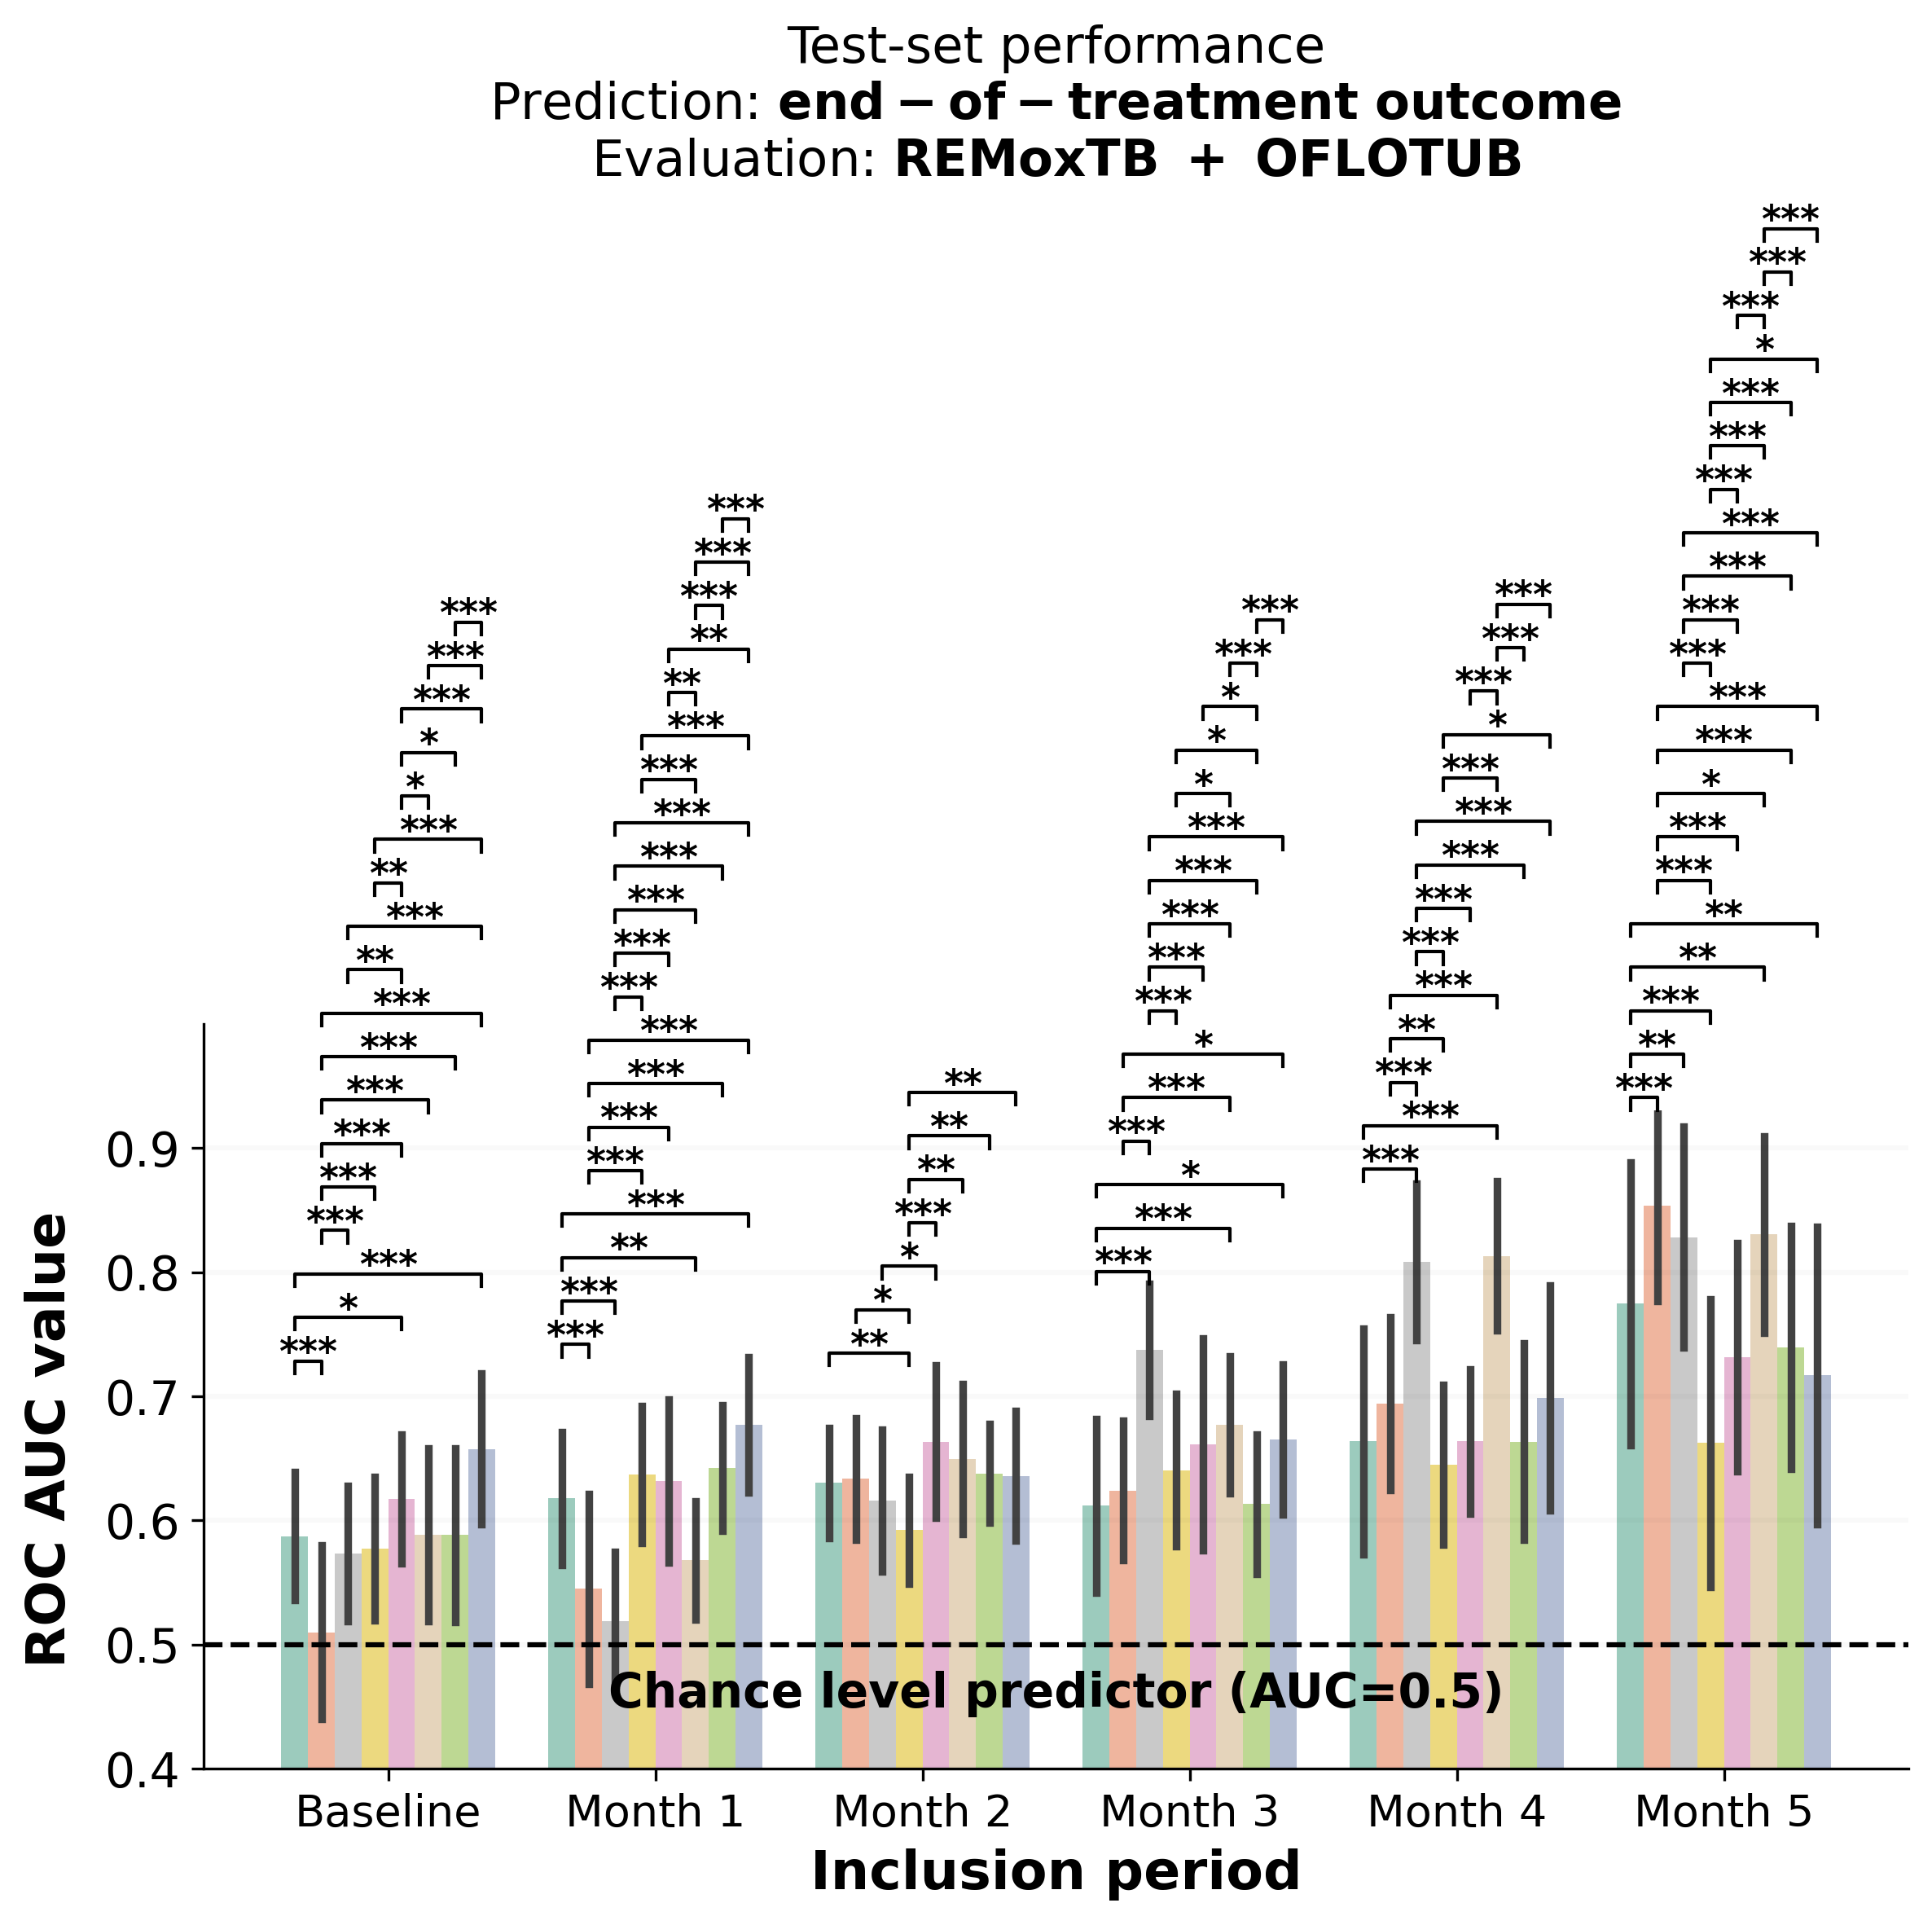

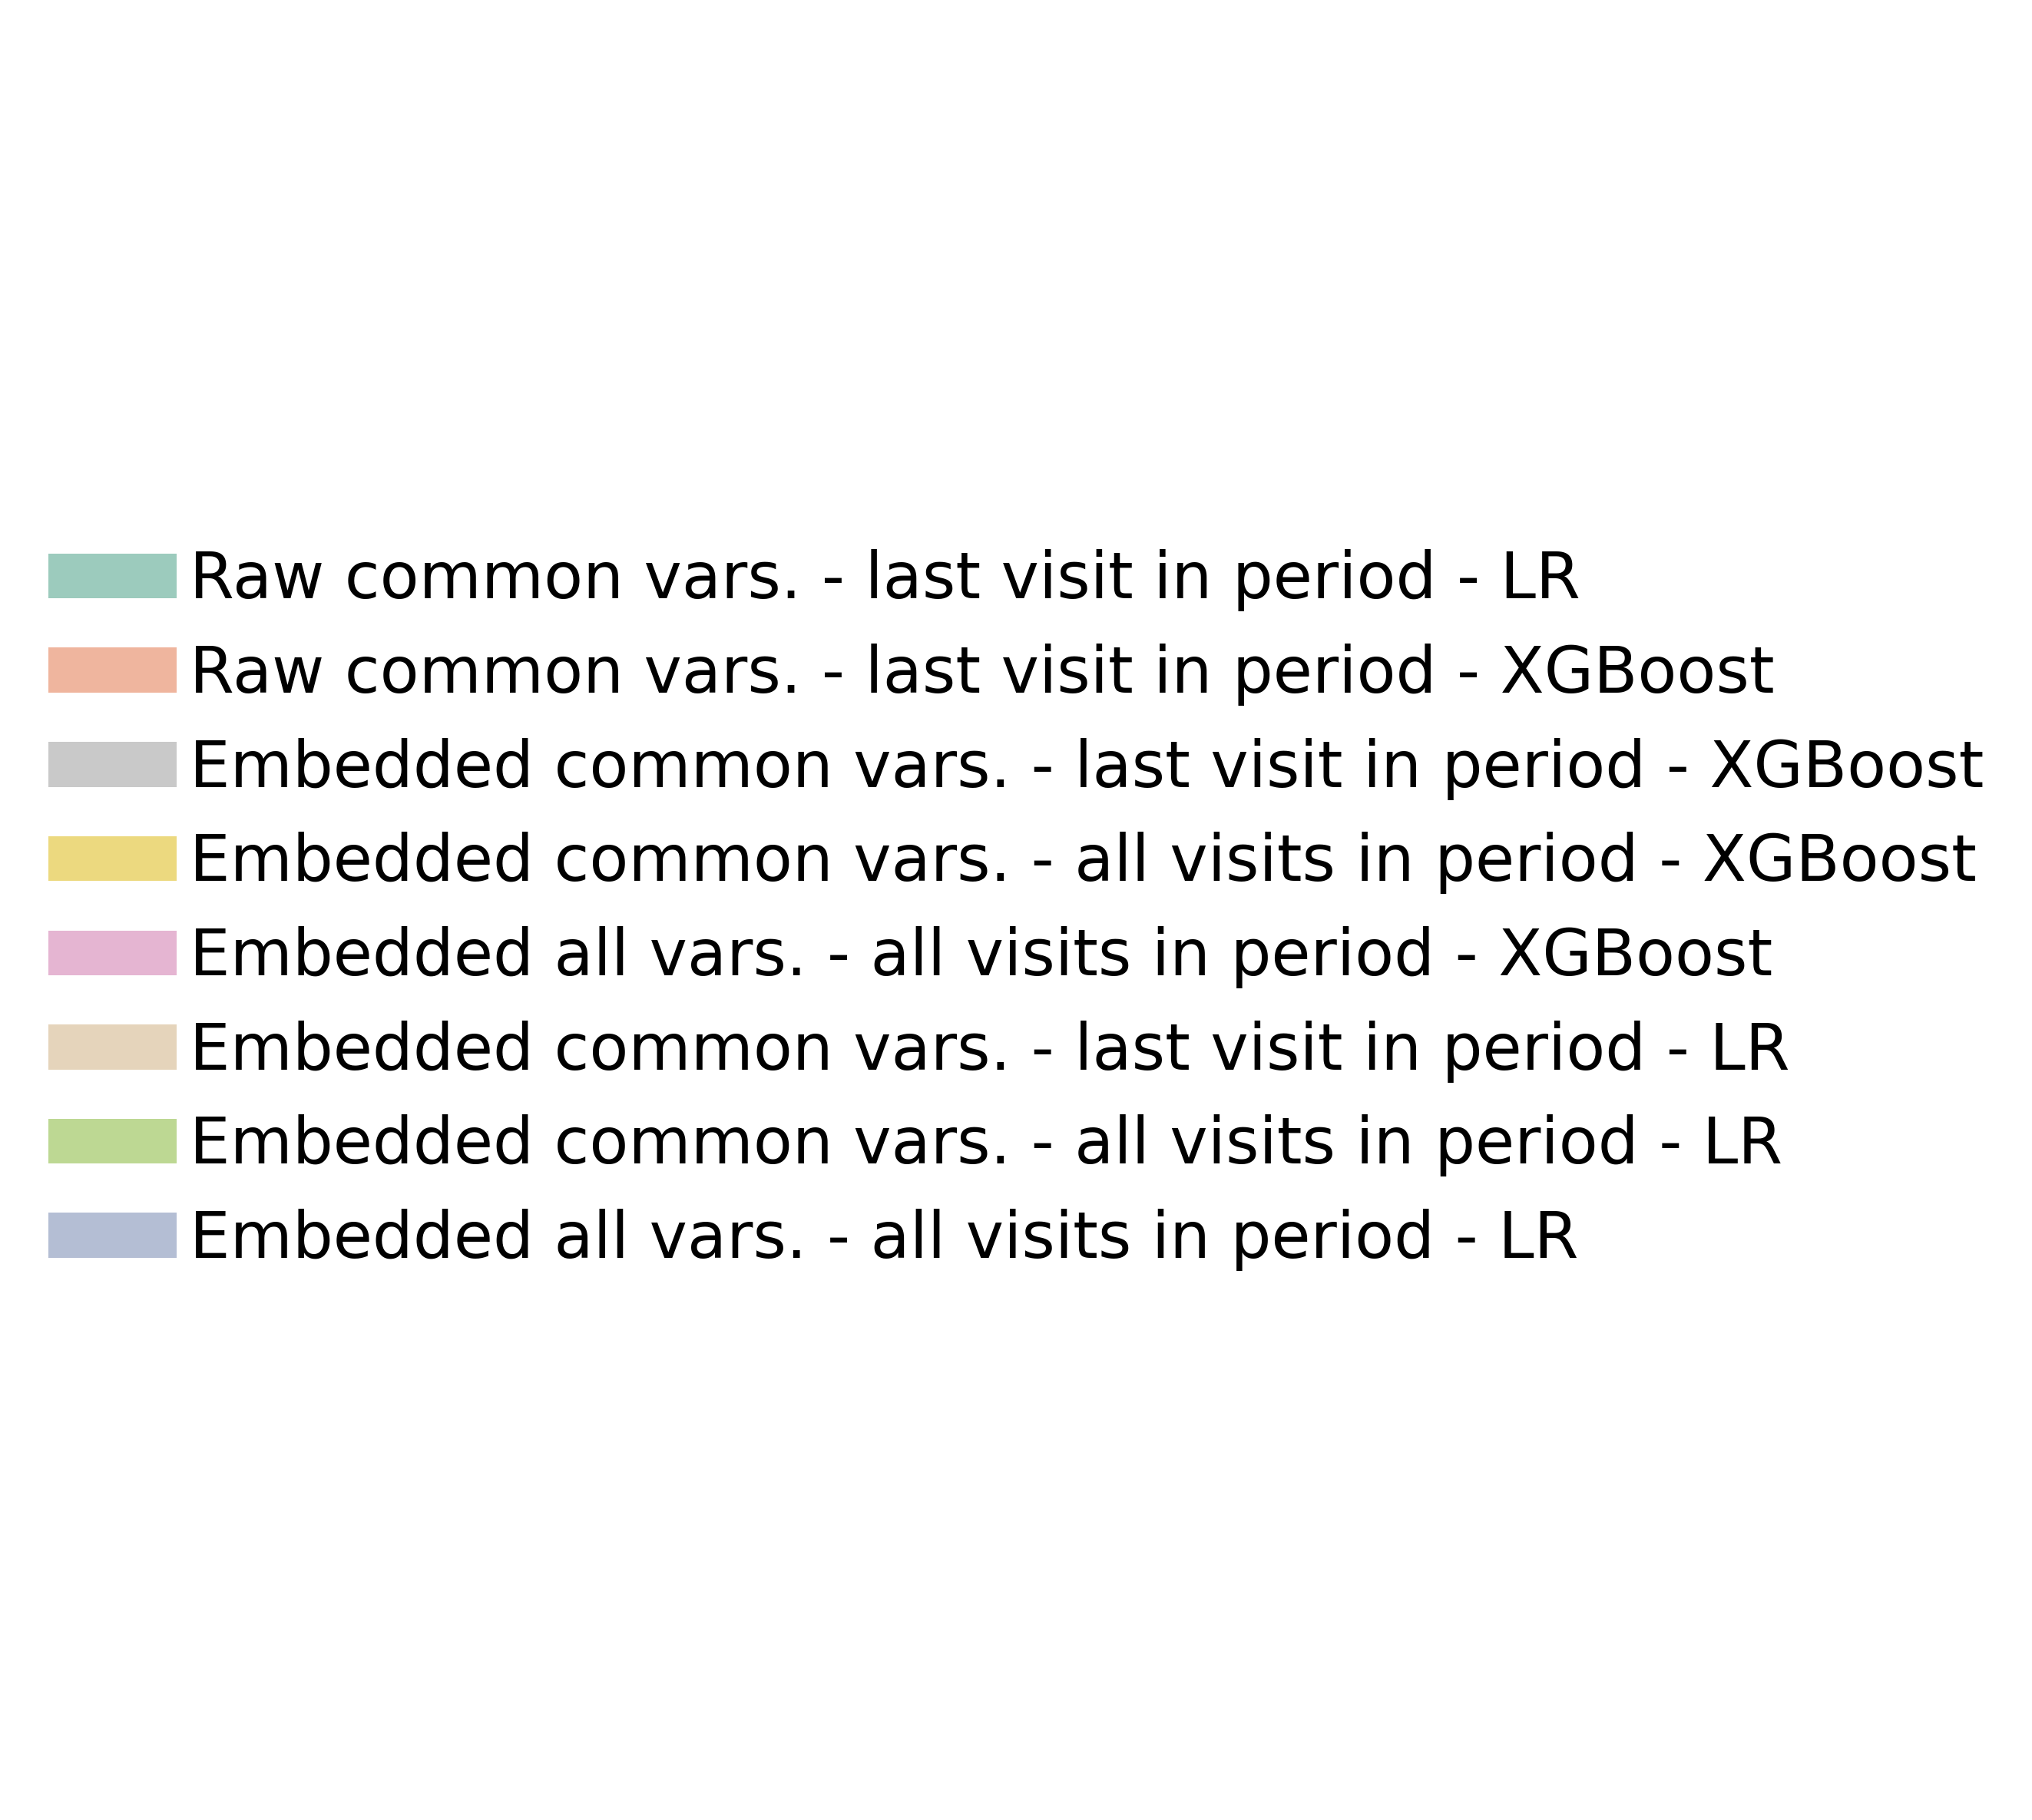

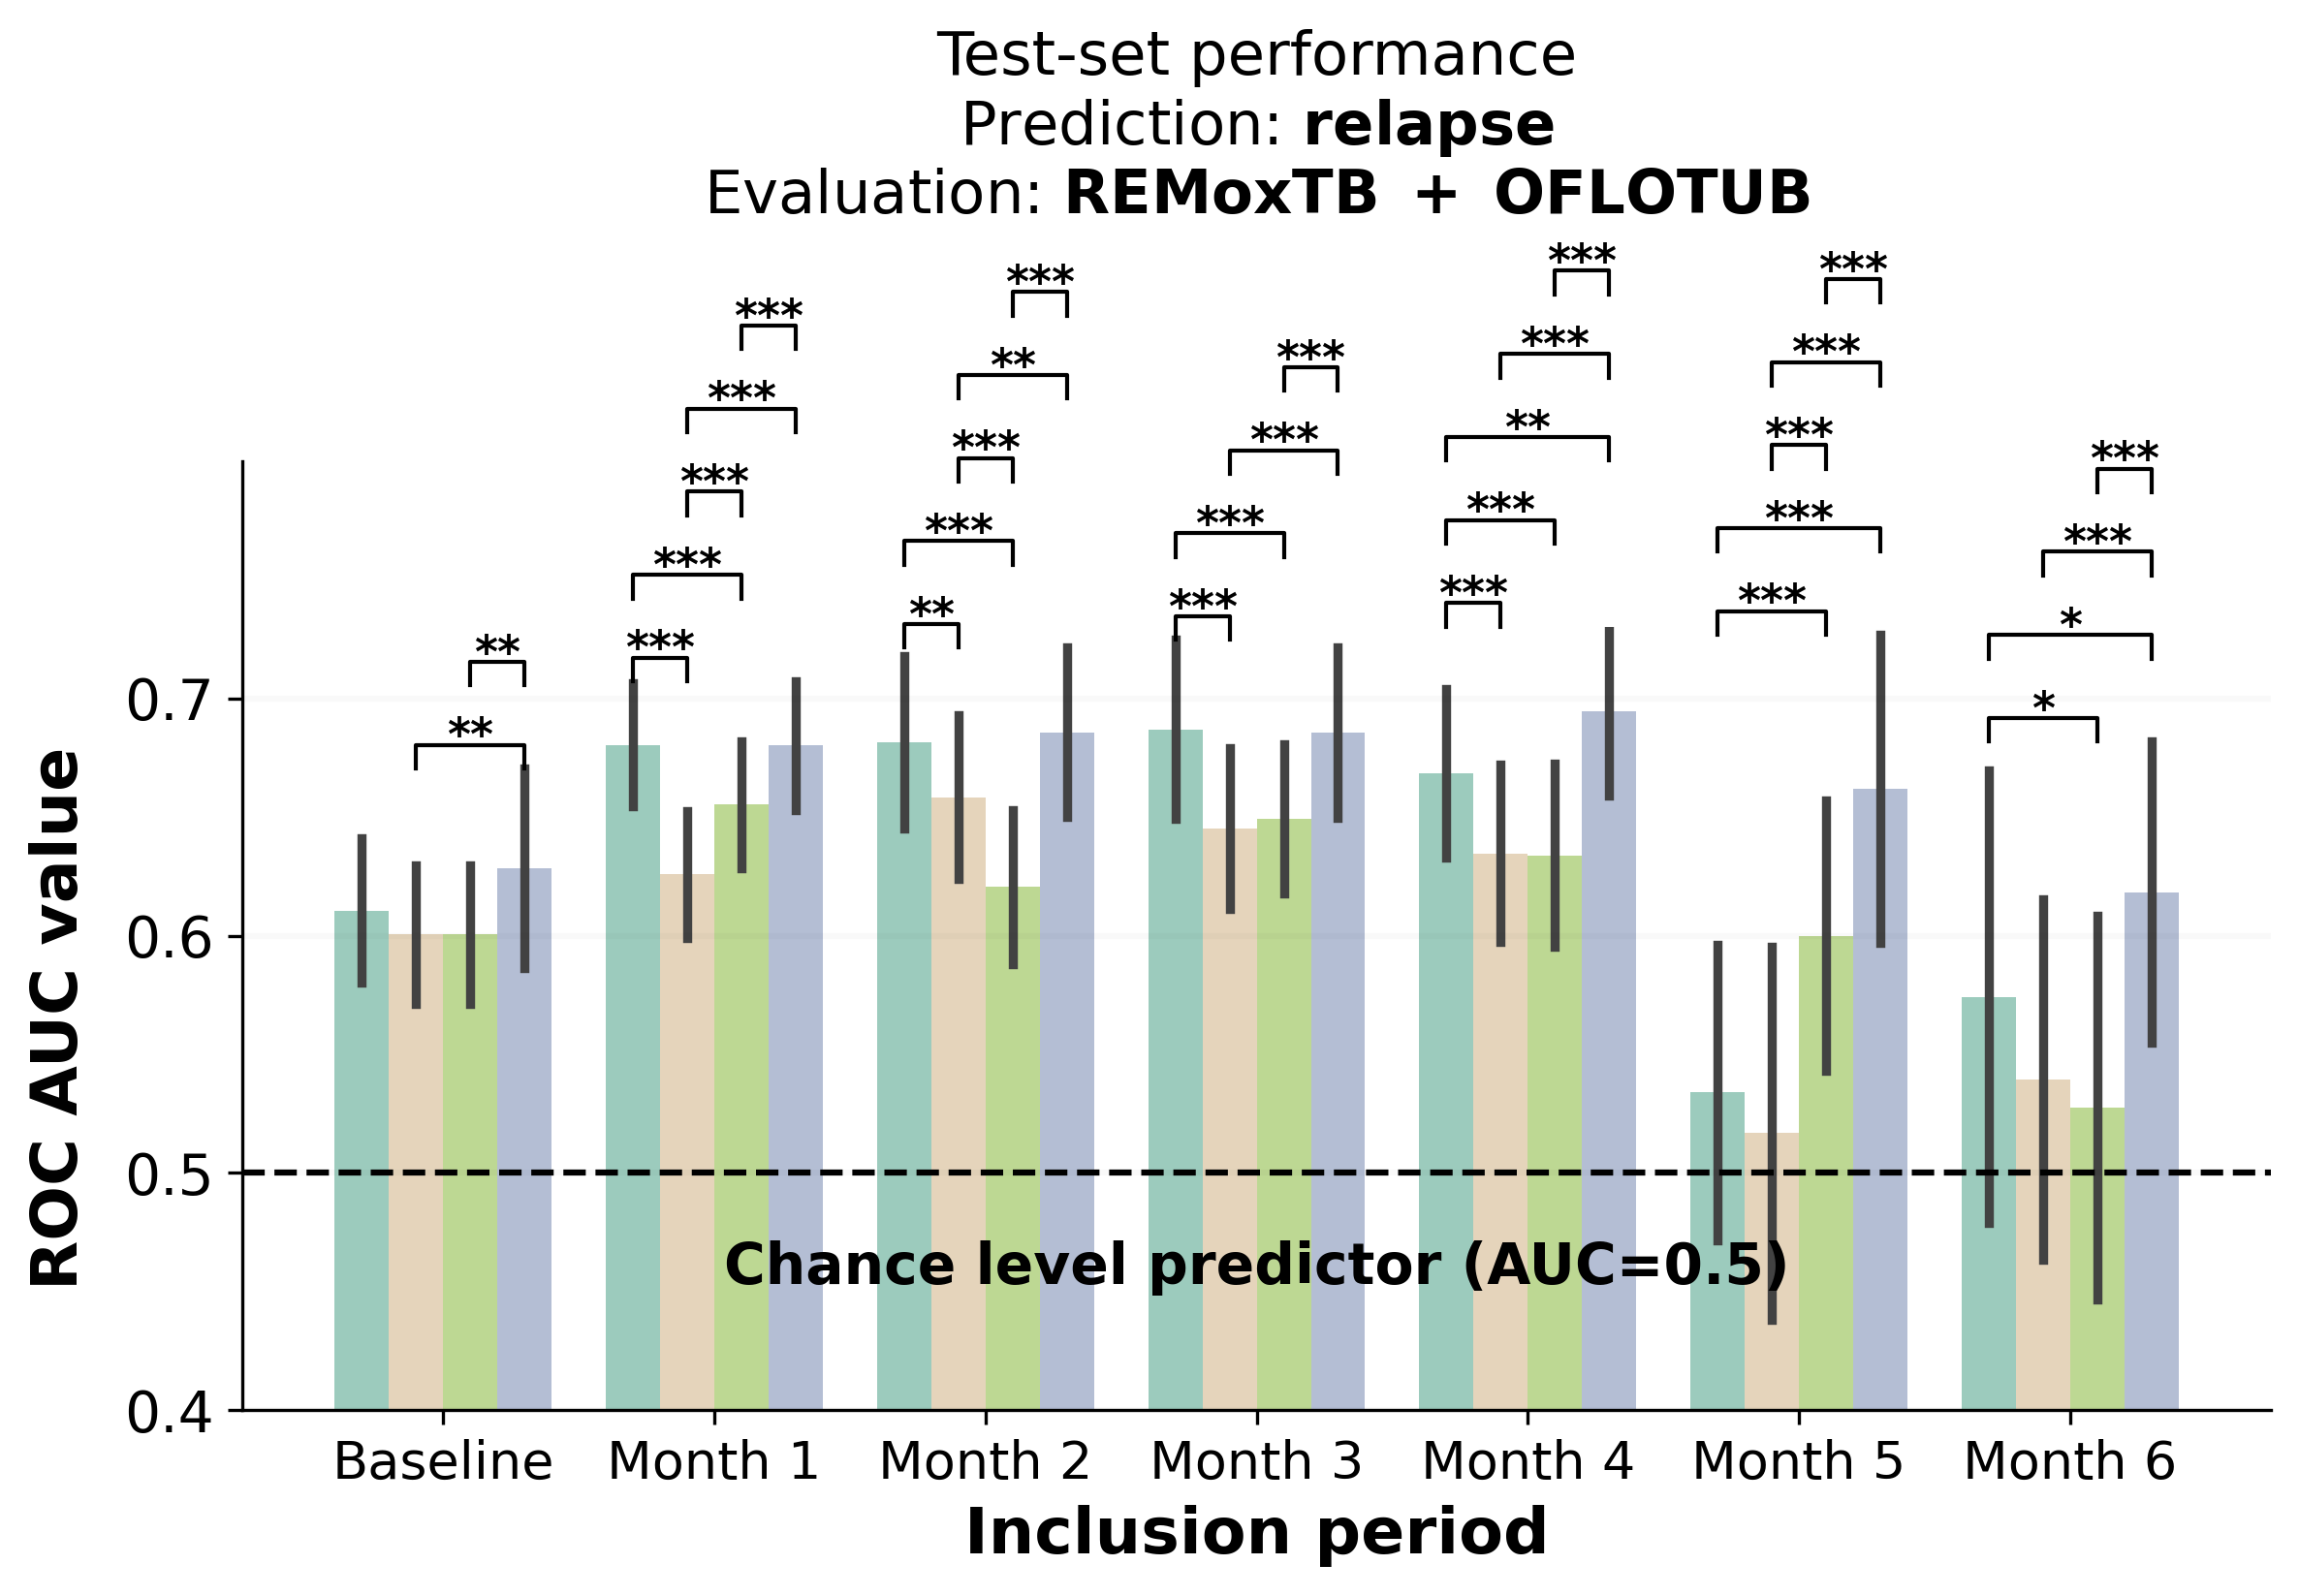

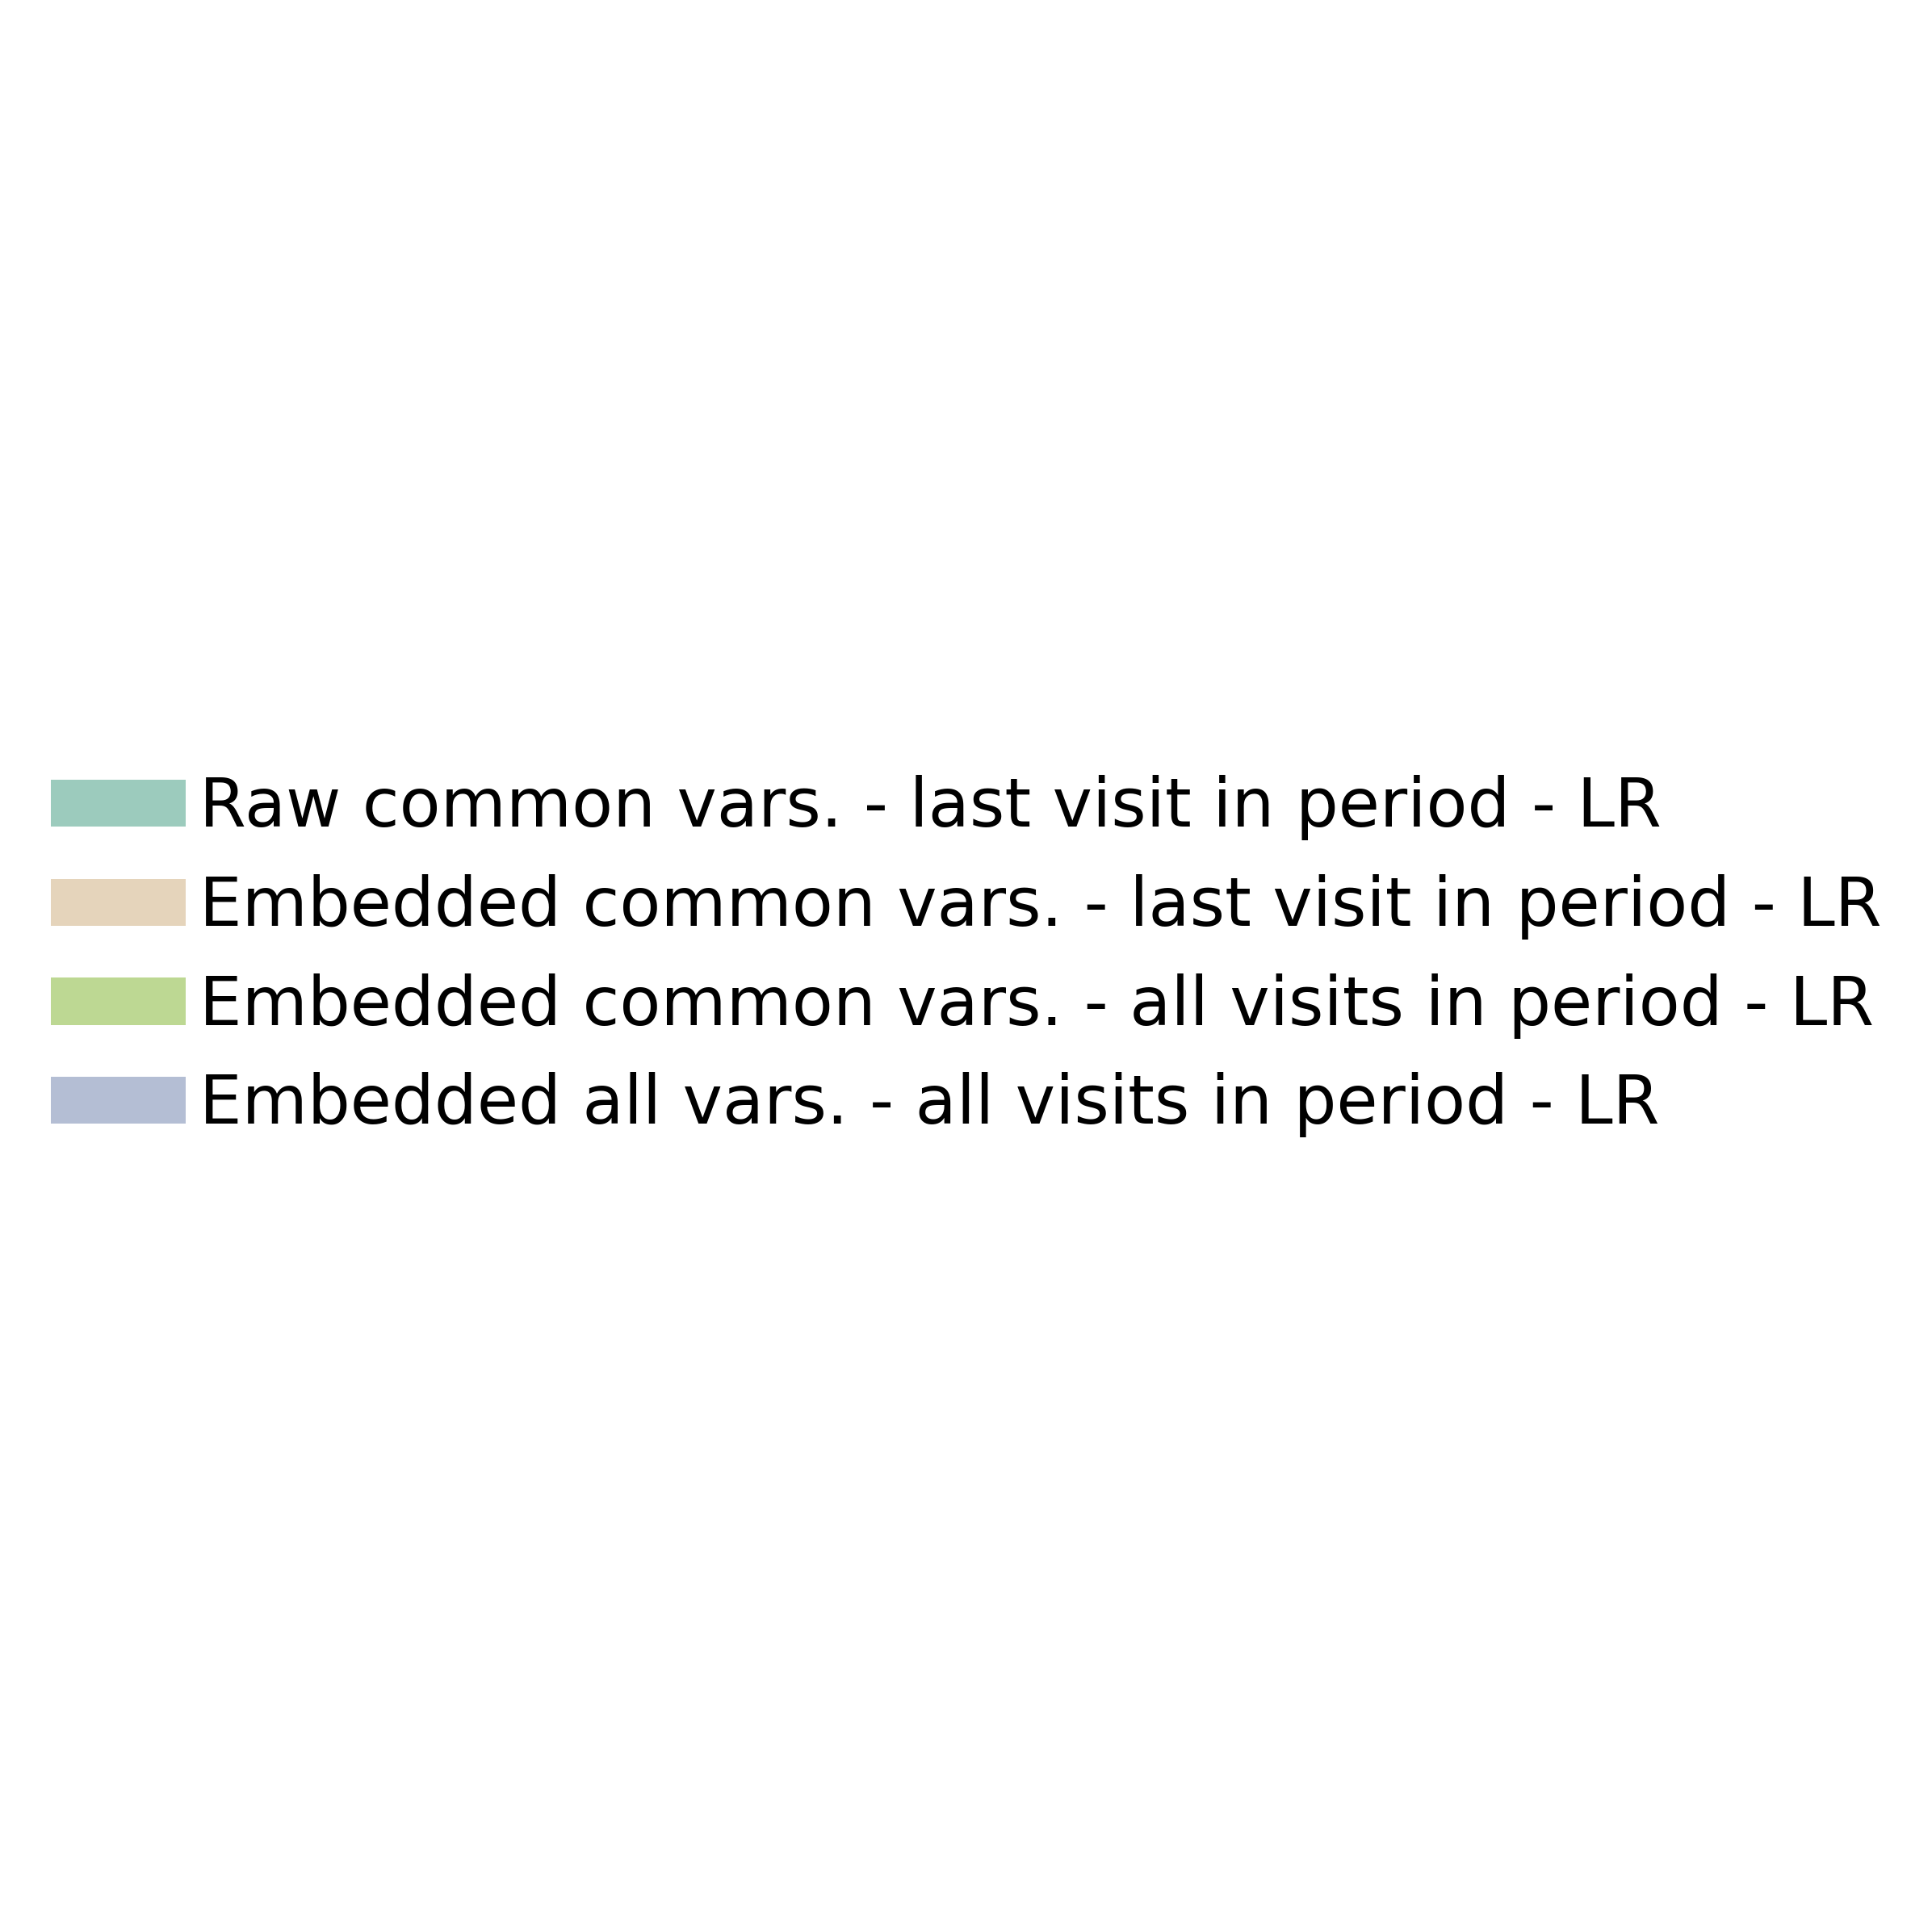

In [29]:
## PLOT ROC-AUC CURVE OF TEST SET
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import roc_auc_score
from scipy.stats import ttest_rel
from functools import reduce
from matplotlib.font_manager import FontProperties

figtitle_size=20
subtitle_size=18
x_tick_size=18
y_tick_size=13
y_label_size=14
legend_fontsize=11.5
axis_lw=1.6


period_end_days=['baseline',31,62,93,125,160,'all']
period_end_days_for_plot=period_end_days[:]

model_names=['XGBoost','LogisticRegression',]#'Dense']#,'SVC','KNN']
autoenc_merged_bool_list=[False,True]


llm_model_names=['BioMistral/BioMistral-7B',"epfl-llm/meditron-7b"]
fine_tuned_tags=['base','fine_tuned']
#model_names=['XGBoost','GradientBoost','LogisticRegression','RandomForest','SVC','KNN']
training_data_types=['full','pca']

llm_model_names=['BioMistral/BioMistral-7B',"epfl-llm/meditron-70b","epfl-llm/meditron-7b",
                 "google/long-t5-local-base",'google/long-t5-tglobal-large',
                'text-embedding-3-small']

suptitle_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMoxTB + OFLOTUB',
               'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':'REMoxTB + OFLOTUB',
               'tb21_22_2984_pats_22_vars_relapse':'REMoxTB + OFLOTUB',
              'tb21_1405_pats_40_vars_result_at_end_of_treatment':'REMoxTB',
               'tb21_1405_pats_40_vars_relapse':'REMoxTB',
              'TB-1021':'REMoxTB',
              'TB-1022':'OFLOTUB'}

plot_split_by_studies=True

baseline_training_data_types=['all_days_in_period','last_therapy_day']
llm_data_inclusion_types=['baseline_vars','baseline_last_day','all_days'][:]


## COMPARISON_1: baseline model setups, that will be compared to all setups in comparison_2
#comparison_1=['baseline_last_therapy_day', 'baseline_all_days_in_period'][:1]
#comparison_2 =['LLM_embed_baseline_last_day','LLM_embed_baseline_vars','LLM_embed_all_days'][:]

comparison_1=['baseline_last_therapy_day', 'LLM_embed_baseline_last_day','LLM_embed_baseline_vars','LLM_embed_all_days'][:]
comparison_2=['baseline_last_therapy_day', 'LLM_embed_baseline_last_day','LLM_embed_baseline_vars','LLM_embed_all_days'][:]


## Order of the different setups within an inclusion period
hue_order=['baseline_all_days_in_period','baseline_last_therapy_day'][1:] + \
           ['LLM_embed_baseline_last_day','LLM_embed_baseline_vars','LLM_embed_all_days'][:]

#hue_order=comparison_1 + comparison_2[:]


## SELECT THE FINAL SETUPS FOR COMPARISON, PER EACH MODEL/INCLUSION PERIOD/INPUT VARIABLE
period_end_days=['baseline',31,62,93,125,160,'all']

final_setup_dict={[*parameters_for_analysis][0]:
                      {'XGBoost':{'include_in_anal':True,
                             'incl_periods':[str(day) for day in period_end_days],
                             'trained_on':['raw_vars','embeddings'][:],
                                 'setups':['baseline_last_therapy_day','LLM_embed_baseline_last_day',
                                                'LLM_embed_baseline_vars','LLM_embed_all_days'][:]},
        
                      'LogisticRegression':{'include_in_anal':True,
                                      'incl_periods':[str(day) for day in period_end_days],
                                      'trained_on':['raw_vars','embeddings'][:],
                                      'setups':['baseline_last_therapy_day','LLM_embed_all_days',
                                                'LLM_embed_baseline_last_day',
                                                'LLM_embed_baseline_vars',][:]}},

                  
                  [*parameters_for_analysis][1]:
                        {'XGBoost':{'include_in_anal':False,
                             'incl_periods':[str(day) for day in period_end_days],
                             'trained_on':['raw_vars','embeddings'][:1],
                            'setups':['baseline_last_therapy_day','LLM_embed_baseline_last_day',
                                                'LLM_embed_baseline_vars','LLM_embed_all_days'][:]},
                         
                          'LogisticRegression':{'include_in_anal':True,
                                      'incl_periods':[str(day) for day in period_end_days],
                                      'trained_on':['raw_vars','embeddings'][:],
                                      'setups':['baseline_last_therapy_day','LLM_embed_baseline_last_day',
                                                'LLM_embed_baseline_vars','LLM_embed_all_days'][:]}}}

## TO MAKE A COMPARISON ACROSS MODELS POSSIBLE, ADD THE MODEL NAME IN FRONT OF THE HUE AND COMPARISON SETUP NAMES
#hue_order=[f'{mod_name} - {hue}' for mod_name in model_names for hue in hue_order]
hue_order=[f'{hue} - {mod_name}' for mod_name in model_names for hue in hue_order]

## Use underscore in the comparisons, as the model name will be split from the setup name before the t-test calculation, 
#. and used for subsetting the dataframe holding the t-test p-values for all comparisons performed. 
#. See in the function "calc_paired_t_test_between_exp_setups()", also there underscore is used, as a '-' character is already being used at other part of the setup strings.
#. After the t-test, the '_' will be replaced by ' - ' where needed, to match with the hue_order setup names.
#comparison_1=[f'{mod_name}_{comp}' for mod_name in model_names for comp in comparison_1]
#comparison_2=[f'{mod_name}_{comp}' for mod_name in model_names for comp in comparison_2]
comparison_1=[f'{comp}_{mod_name}' for mod_name in model_names for comp in comparison_1]
comparison_2=[f'{comp}_{mod_name}' for mod_name in model_names for comp in comparison_2]


#print(comparison_2)

for data_param_key in [*parameters_for_analysis][:2]:

    for plot_type in ['bar','point'][:1]:

        pred_models_result=[]
        #hue_order=[]
    
        ## LOAD BASELINE MODEL ROC-AUC RESULTS
        for bl_training_data_type in baseline_training_data_types[1:]:
            
            fn=f'../data/test_roc_auc_values/baseline/{data_param_key}_days_{bl_training_data_type}_test_ROC_AUC_across_time_all_studies.csv'
            #fn=f'../data/test_roc_auc_values/baseline/{data_param_key}_days_{bl_training_data_type}_test_ROC_AUC_across_time_per_study..csv'
            baseline_cv_res_acros_time_df=pd.read_csv(fn,index_col=0)
            baseline_cv_res_acros_time_df['trained_on']='raw_vars'
            baseline_cv_res_acros_time_df['setup']=f'baseline_{bl_training_data_type}'
            pred_models_result.append(baseline_cv_res_acros_time_df)
            #hue_order.append(f'baseline_{bl_training_data_type}')

            ## LOAD LLM MODEL ROC-AUC RESULTS
            for llm_model_name in llm_model_names[:1]:
        
                for fine_tuned_tag in fine_tuned_tags[:1]:
                    
                    
                    if 'text-embedding' in llm_model_name:
                        llm_model_name_with_tag=llm_model_name
                    else:
                        llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])
                    
        
                    for data_inclusion_type in llm_data_inclusion_types[:]:
        
                        for training_data_type in training_data_types[:1]:

                            for autoencoder_merged in autoenc_merged_bool_list[:1]:

                                fn=f'../data/test_roc_auc_values/LLM/{data_param_key}_{llm_model_name_with_tag}_{training_data_type}_4096_{data_inclusion_type}_autoenc_{autoencoder_merged}_test_ROC_AUC_across_time_all_studies.csv'                                                    
                                #fn=f'../data/test_roc_auc_values/LLM/{data_param_key}_{llm_model_name_with_tag}_{training_data_type}_4096_{data_inclusion_type}_autoenc_{autoencoder_merged}_test_ROC_AUC_across_time_per_study.csv'                                                    
                                llm_cv_res_acros_time_df=pd.read_csv(fn,index_col=0)
                                llm_cv_res_acros_time_df['trained_on']='embeddings'
                                llm_cv_res_acros_time_df['setup']=f'LLM_embed_{data_inclusion_type}'
                                pred_models_result.append(llm_cv_res_acros_time_df)
                                
        #hue_order=comparison_1
        plot_df = pd.concat(pred_models_result,axis=0)

        print(plot_df['setup'].unique())

        # Refine names of the setups
        replacements = {
            '_embed_baseline_vars': ' Common vars - all visits in period',
            '_embed_baseline_last_day': ' Common vars - last visit in period',
            'baseline_last_therapy_day': 'Common vars - last visit in period',
            'baseline_all_days_in_period': 'Common vars - last visits concatenated',
            '_embed_all_days':' All vars - all visits in period'}
        
        #sns.barplot(data=plot_df,x='inclusion_period',y='ROC_AUC_score',hue='setup')
        plot_df['setup__']=plot_df['setup'].values
        plot_df['setup']=plot_df['setup'].replace(replacements,regex=True)
        plot_df['setup_']=plot_df['setup'] +' - '+ plot_df['model_name']

        ## CREATE CUSTOM PALETTE FOR SETUPS
        setups=np.sort(plot_df['setup_'].unique())
        setup_colors = plt.cm.get_cmap('Set2', len(setups))  # Use a colormap with enough distinct colors
        setup_color_mapping = {setup: setup_colors(i) for i, setup in enumerate(setups)}

        print('setup_color_mapping',np.sort([*setup_color_mapping]))
        
        
        ## FILTER SETUPS BASED ON THE final_setup_dict, WHICH DETERMINES WHICH SETUPS ARE USED FOR FINAL COMPARISON
        l=[]

        for model_name in [*final_setup_dict[data_param_key]]:

            if final_setup_dict[data_param_key][model_name]['include_in_anal']==True:
            
                incl_periods_=final_setup_dict[data_param_key][model_name]['incl_periods']
                trained_on=final_setup_dict[data_param_key][model_name]['trained_on']
                setups=final_setup_dict[data_param_key][model_name]['setups']
                
                plot_df_filt = plot_df.loc[(plot_df['model_name']==model_name)\
                                            &(plot_df['trained_on'].isin(trained_on))\
                                            &(plot_df['inclusion_period'].isin(incl_periods_))\
                                            &(plot_df['setup__'].isin(setups))]
                #print(plot_df_filt)
                l.append(plot_df_filt)
        
        plot_df = pd.concat(l,axis=0)


        
        # Update hur_order list with refined setup names
        hue_order_=replace_substring_in_list(replacements,hue_order)
        comparison_1_=replace_substring_in_list(replacements,comparison_1)
        comparison_2_=replace_substring_in_list(replacements,comparison_2)

        ## FILTER HUE AND COMPARISONS ORDER BASED ON THE SETUPS IN PLOT_DF
        hue_order_ = [hue for hue in hue_order_ if hue in plot_df['setup_'].unique()]
        comparison_1_ = [comp for comp in comparison_1_ if comp.replace('_',' - ') in plot_df['setup_'].unique()]
        comparison_2_ = [comp for comp in comparison_2_ if comp.replace('_',' - ') in plot_df['setup_'].unique()]

        hue_order_ = list(np.sort([x for x in hue_order_ if x.startswith('Common vars')])) + \
                             [x for x in hue_order_ if not x.startswith('Common vars')]
        comparison_1_ = list(np.sort([x for x in comparison_1_ if x.startswith('Common vars')])) + \
                                     [x for x in comparison_1_ if not x.startswith('Common vars')]
        comparison_2_ = list(np.sort([x for x in comparison_2_ if x.startswith('Common vars')])) + \
                                     [x for x in comparison_2_ if not x.startswith('Common vars')]
        
        
        ## Change names of inlcusion periods to months
        period_dict=dict(zip([str(x) for x in period_end_days],
                             #[f'{int(np.floor(int(day)/30))} month' if day !='all' else '6 month' for day in period_end_days]
                            
                             ['Month 6' if day == 'all' 
                                        else 'Baseline' if day == 'baseline' 
                                        else f'Month {int(np.floor(int(day)/30))}' if isinstance(day, int) 
                                        else None 
                                        for day in period_end_days_for_plot]
                                             ))
        plot_df['inclusion_period']=plot_df['inclusion_period'].map(period_dict)
        plot_df = plot_df.sort_values(['inclusion_period','setup_','Num_of_CV_repeat'])

        ## Within each model type & inclusion period, calculate the paired t-test results across experimental setups. 
        #. The results coming from the same CV-splits are compared across exp. setups, these are paired for the t-test
        #. The dict. holds all the raw p-values of the t-tests across all exp. setups
        paired_t_res_dict = calc_paired_t_test_between_exp_setups(plot_df)
        #extract_paired_t_test_FDR(ttest_res_df,comparison_1,comparison_2)

        # Figure size customization
        
        # Create a FacetGrid for splitting by 'model_name'
        #g = sns.FacetGrid(plot_df, col='model_name', col_wrap=1, height=fig_height, aspect=1.6,sharex=False,sharey=False)
        fig,ax=plt.subplots(1,1,figsize=(9,3.5))
        #fig,ax=plt.subplots(1,1,figsize=(9,5))
        #fig,ax=plt.subplots(1,1,figsize=(8,5))


        
        # Map barplot onto the FacetGrid
        if plot_type=='bar':
            #g.map_dataframe(
                sns.barplot(data=plot_df,
                            x='inclusion_period',
                            y='ROC_AUC_score', 
                            hue='setup_', 
                            errorbar='sd',
                            #palette='Pastel1',
                            palette=setup_color_mapping,
                            hue_order=hue_order_,
                            ax=ax,
                            alpha=0.7)

        
        if plot_type=='point':
            #g.map_dataframe(
                sns.pointplot(data=plot_df, 
                            x='inclusion_period',
                            y='ROC_AUC_score', 
                            hue='setup_', 
                            errorbar='sd',
                            #palette='Pastel1',
                            palette=setup_color_mapping,
                            hue_order=hue_order_,
                            ax=ax,
                            alpha=0.7)
                                 
        
       
        #ax.set_title()

        #ax.set_ylabel("ROC AUC value",fontsize=16,fontweight='bold')
        ax.set_xlabel("Inclusion period",fontsize=16,fontweight='bold')


        #ax.set_title(study)

        
        # Customize tick sizes
        #for ax in g.axes.flat:  # Loop through each subplot
        ax.tick_params(axis='x', labelsize=13)  # Customize x tick size
        ax.tick_params(axis='y', labelsize=14)  # Customize y tick size


    

        ax.spines[['top','right']].set_visible(False)


         ## PLot chance predicor's line at 0.5
        ax.axhline(y=0.5,color='black', linestyle='dashed')
        range_mean=(ax.get_xlim()[1]+ ax.get_xlim()[0])/2
        ax.text(range_mean,0.46,'Chance level predictor (AUC=0.5)',fontsize=14,fontweight='bold',
                            rotation=0,horizontalalignment='center', verticalalignment='center',rotation_mode='default')

        #xticklabels=[f'{int(np.floor(int(day)/30))} month' if day !='all' else '6 month' for day in period_end_days]
        #ax.set_xticklabels(ax.get_xticklabels(), fontsize=12) #weight='bold'
        #ax.grid(alpha=0.4)
        

        if plot_type=='bar':
            p_val_fontsize=11
            gap_bracket_p_val=0.009
            fdr_text_coords_dict,err_bar_pos_dict=add_fdr_vals_to_bars(ax,plot_df,hue_order_,paired_t_res_dict,comparison_1_,comparison_2_,p_val_fontsize,gap_bracket_p_val)

        ## Extract the y-coordinates of the fdr texts from the barplot, and take the maximum y-coordinate of the first 3 periods
        #. ==> change the ylim according to the top fdr text, therefore the legend will be placed above this area without overlapping with the fdr values over the bars
        top_fdr_text_y_coord = np.max([np.max(np.array(list(fdr_text_coords_dict[per].values()))[:,1]) for per in plot_df['inclusion_period'].unique()[:]])
        top_err_bar_y_coord = np.max([np.max(np.array(list(err_bar_pos_dict[per].values()))[:,1]) for per in plot_df['inclusion_period'].unique()[:]])
        
        #print('top_fdr_text_y_coord',top_fdr_text_y_coord)
        ylim= top_err_bar_y_coord
        ax.set_ylim(0.4,ylim)
        #ax.set_ylim(0.4,1)
        

        ## Set spine of y-axis
        spine_ymin, spine_ymax = 0.4, min(1.0,top_err_bar_y_coord)
        ax.spines['left'].set_bounds(spine_ymin, (np.ceil(spine_ymax*10))/10) 

        # Set the filtered y-ticks       
        


        if min(1,spine_ymax)<1:     
            yticks = np.arange(0.4, min(1,spine_ymax), 0.1)
            # Manually add gridlines only for valid y-ticks
            for ytick in yticks[:]:
                ax.axhline(y=ytick, color='black', linestyle='-', alpha=0.025)
        else:
            yticks = np.arange(0.4, 1.1, 0.1)
            # Manually add gridlines only for valid y-ticks
            for ytick in yticks:
                ax.axhline(y=ytick, color='black', linestyle='-', alpha=0.025)
        
        ax.set_yticks(yticks)

        


        ## Place the y-label according to the spine bounds
        y_spine_center = (spine_ymin + spine_ymax) / 2
        
        # Transform to axes-relative coordinates
        _, y_axes_center = ax.transData.transform((0, y_spine_center))
        _, y_axes_center = ax.transAxes.inverted().transform((0, y_axes_center))
        
        # Manually add y-axis label
        ax.set_ylabel(None)  # Remove default label
        
        ax.text(
            -0.09, y_axes_center,           # -0.13: controls horizontal distance from axis
            "ROC AUC value",
            transform=ax.transAxes,
            fontsize=16, fontweight='bold',
            ha='center', va='center',
            rotation='vertical'
        )

        # Adjust layout for better appearance
        # Adjust the overall figure size
        if data_param_key in suptitle_dict.keys():
            study_names=suptitle_dict[data_param_key]
            if 'relapse' not in data_param_key:
                prediction_time=data_param_key.split('at_')[-1].replace('_','-')
                prediction_time = rf"$\bf{{{prediction_time}\ outcome}}$"
     
        
            if 'relapse' in data_param_key:
                prediction_time='relapse'
                prediction_time = r'$\bf{relapse}$'
    
            study_names=study_names.replace(' ',r'\ ')
            study_names=rf"$\bf{{{study_names}}}$"


            suptitle= f"Test-set performance\nPrediction: {prediction_time}\nEvaluation: {study_names}"
            
        #fig.suptitle(suptitle,y=0.95,fontweight='normal',fontsize=15)
        
        ### ADD TITLE DYNAMICALLY, POSITIONOD OVER THE HIGHEST BRACKET
        from matplotlib.transforms import blended_transform_factory

        # This transform uses axes coords for x (0.5 is center), and data coords for y
        transform = blended_transform_factory(ax.transAxes, ax.transData)

        y_coord_=top_fdr_text_y_coord if top_fdr_text_y_coord>1 else top_fdr_text_y_coord + 0.02 
        print('top_fdr_text_y_coord',top_fdr_text_y_coord)
        print('y_coord_',y_coord_)
        ax.text(
            0.5, y_coord_,  # 0.5 in Axes x-coords, y in data-coords
            suptitle,
            ha='center', va='bottom',
            transform=transform,
            fontsize=15, fontweight='normal')
        

        
        # Add legends
        handles, labels=ax.get_legend_handles_labels()
        ax.get_legend().remove()
        labels = [lab.replace('LogisticRegression','LR') for lab in labels]
        #print('lalbels before adjustment',labels)
        labels = adjust_legend_labels(labels)
        #print('lalbels after adjustment',labels)

        ## Calculate the relative coordinates of legend ased on absolute coordinates of the axes object
        # absolute (figure) coordinates
        x_data, y_data = ax.get_xlim()[0], ax.get_ylim()[1]#1.015
        
        # Convert from data to display (pixel) coordinates
        display_coords = ax.transData.transform((x_data, y_data))
        
        # Convert from display to axes-relative coordinates
        axes_coords = ax.transAxes.inverted().transform(display_coords)
        #print('axes_coords',axes_coords)

        leg_fig,leg_ax=plt.subplots(1,1,figsize=(10,10))
        
                
        leg_ax.legend(handles=handles,
                  labels=labels,               
                  alignment='left',
                  fontsize=20,
                  markerscale=3,
                  #loc='upper left',
                  loc='center',
                  #bbox_to_anchor=axes_coords,
                  #bbox_to_anchor='center'
                  frameon=False,
                  handletextpad=0.2,
                  #title='Experimental setup',
                  #title_fontproperties=FontProperties(weight='bold', size=12),
                 )
        leg_ax.axis("off")
        

        #plt.tight_layout()

        
        ## SAVE PLOTS
        data_dir_=f'../data/plots/ROC_AUC_setup_comparisons/RAW_LLM_models/{data_param_key}'
        os.makedirs(data_dir_,exist_ok=True)
        fn=os.path.join(data_dir_,
                    f'{plot_type}_across_studies_all_setups.png')
        fig.savefig(fn, bbox_inches='tight', dpi=300)

        fn=os.path.join(data_dir_,
                     f'{plot_type}_across_studies_all_setups_legend.png')
        leg_fig.savefig(fn, bbox_inches='tight', dpi=300)
        
        #plt.close()
        #plt.show()
        
        
                        

In [24]:
comparison_2_

['LLM Common vars - last visit in period_LogisticRegression',
 'LLM Common vars - all visits in period_LogisticRegression',
 'LLM All vars - all visits in period_LogisticRegression']

In [25]:
comparison_1_

['Common vars - last visit in period_LogisticRegression']

### Across studies - preselected exp.setups

['baseline_last_therapy_day' 'LLM_embed_baseline_vars'
 'LLM_embed_baseline_last_day' 'LLM_embed_all_days']
setup_color_mapping ['Common vars - last visit in period - LogisticRegression', 'Common vars - last visit in period - XGBoost', 'LLM All vars - all visits in period - LogisticRegression', 'LLM All vars - all visits in period - XGBoost', 'LLM Common vars - all visits in period - LogisticRegression', 'LLM Common vars - all visits in period - XGBoost', 'LLM Common vars - last visit in period - LogisticRegression', 'LLM Common vars - last visit in period - XGBoost']
top_fdr_text_y_coord 1.1608654659645161
y_coord_ 1.1808654659645161


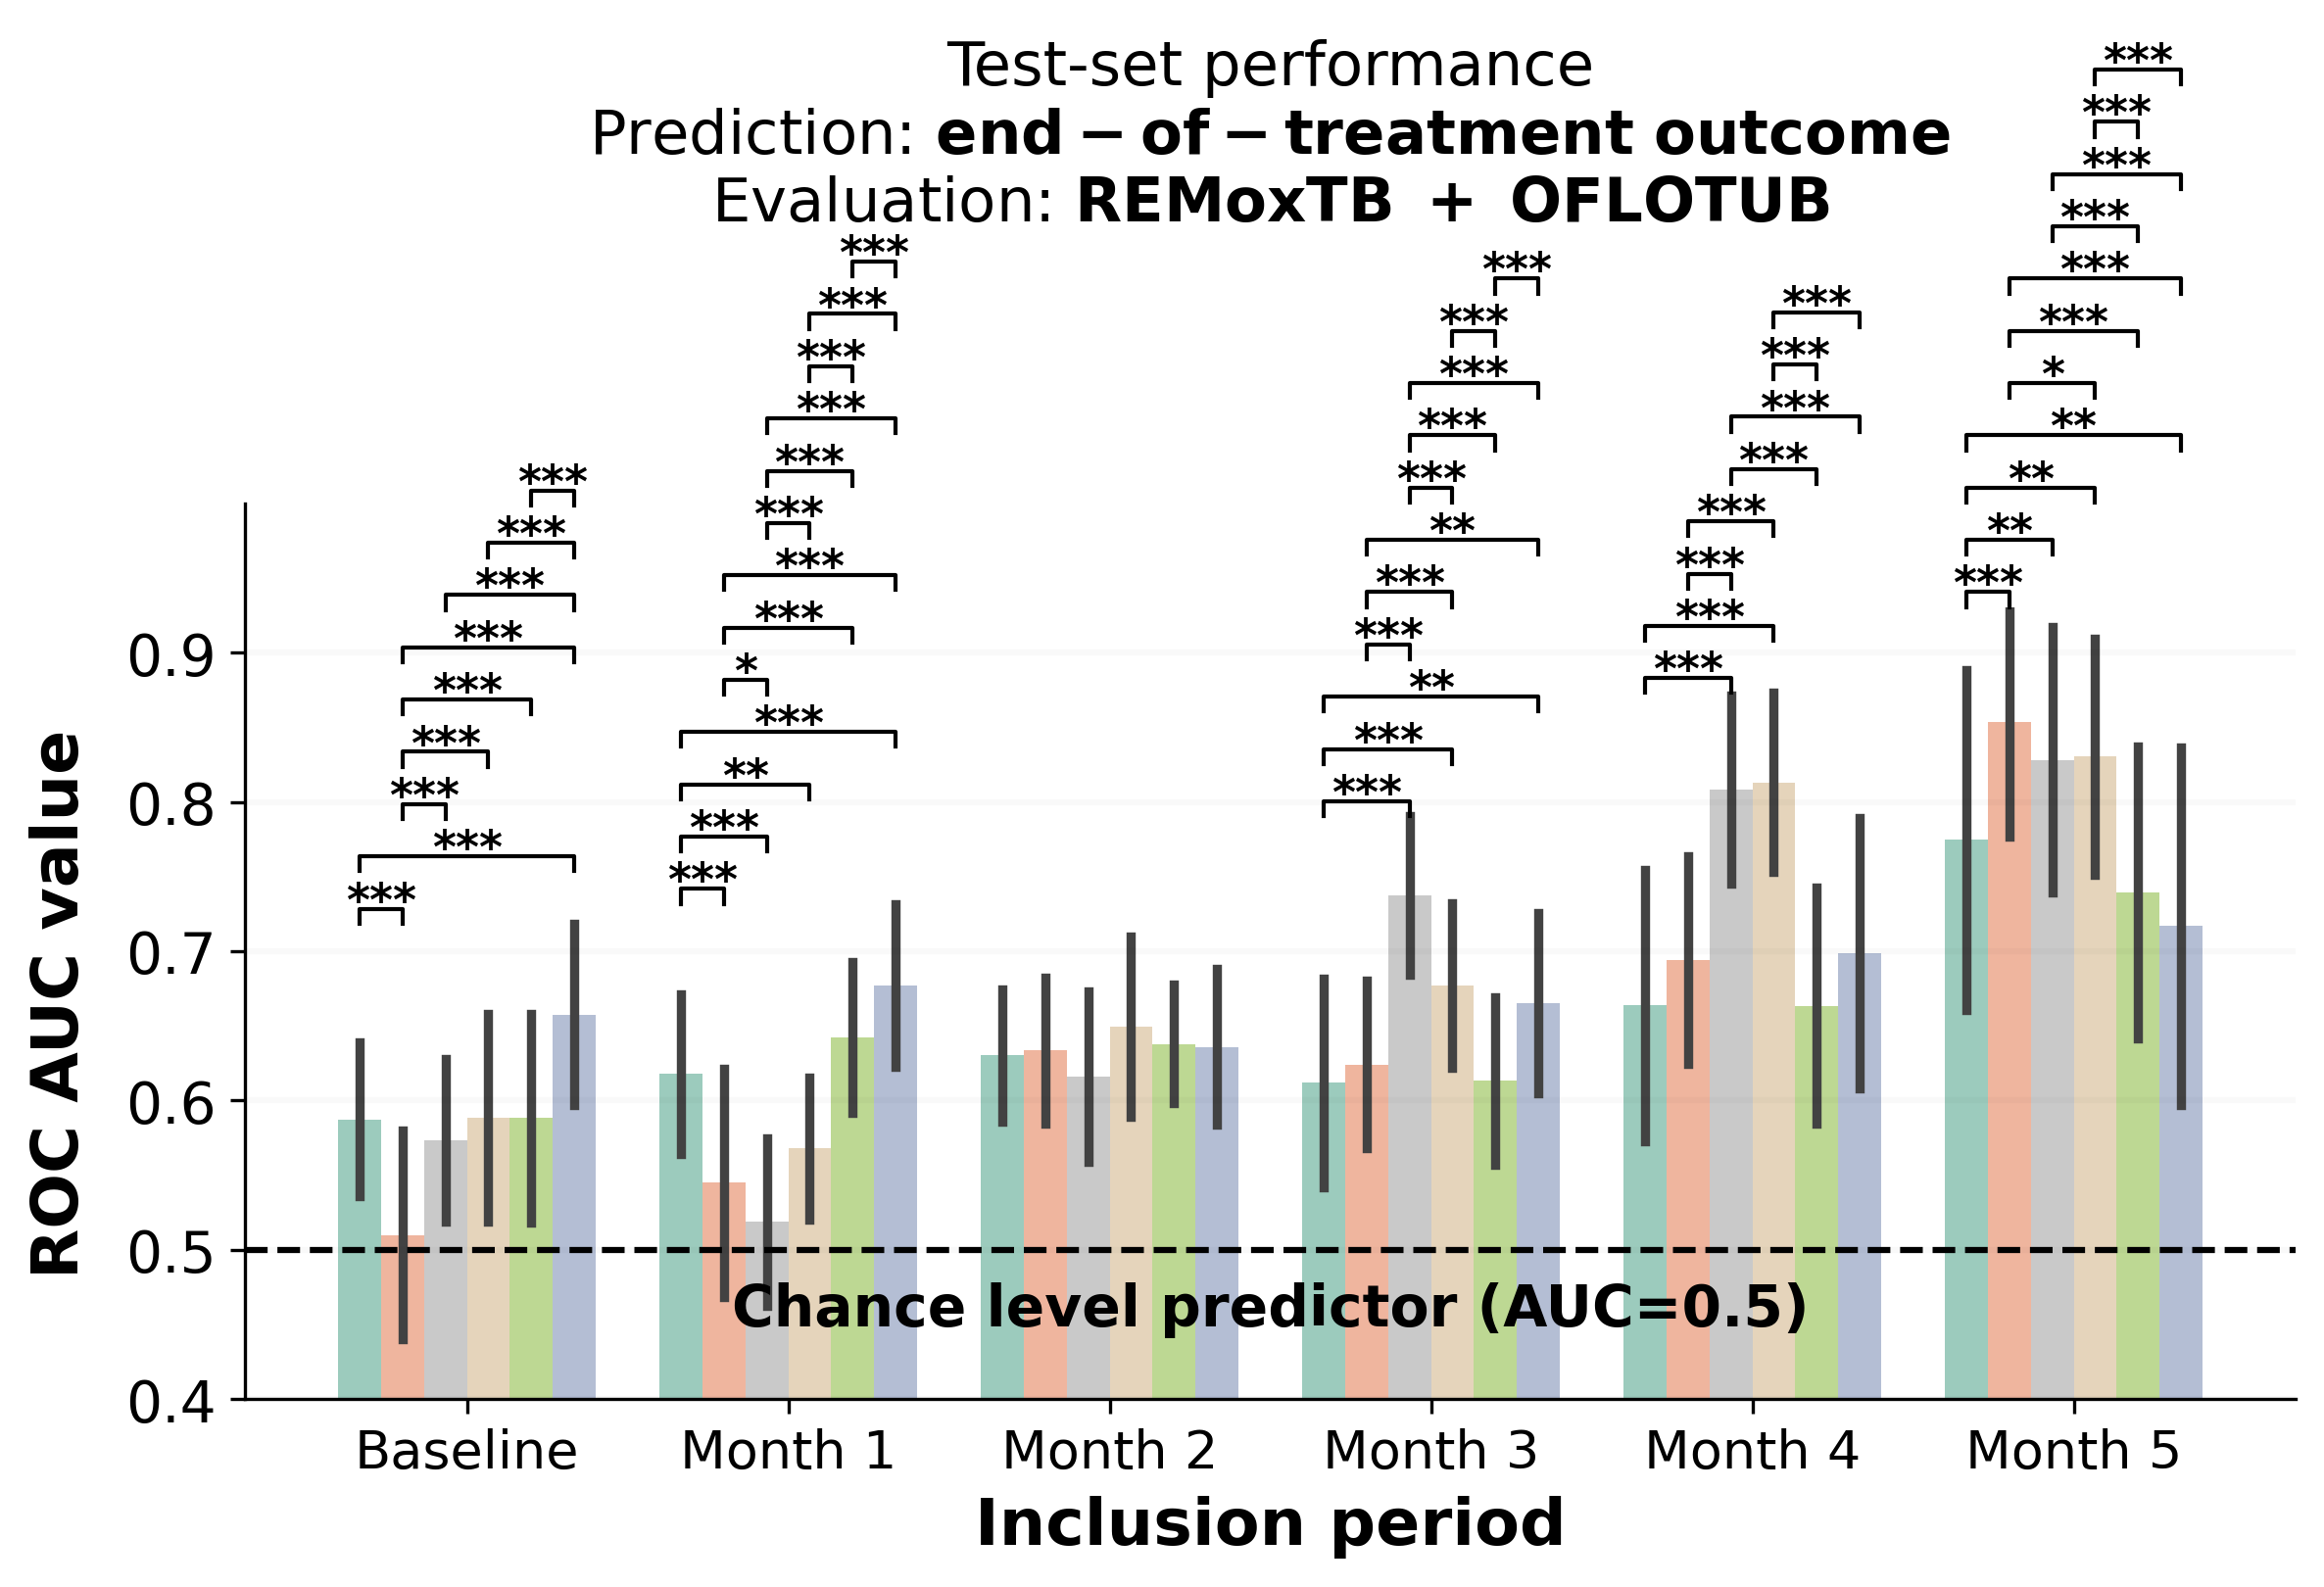

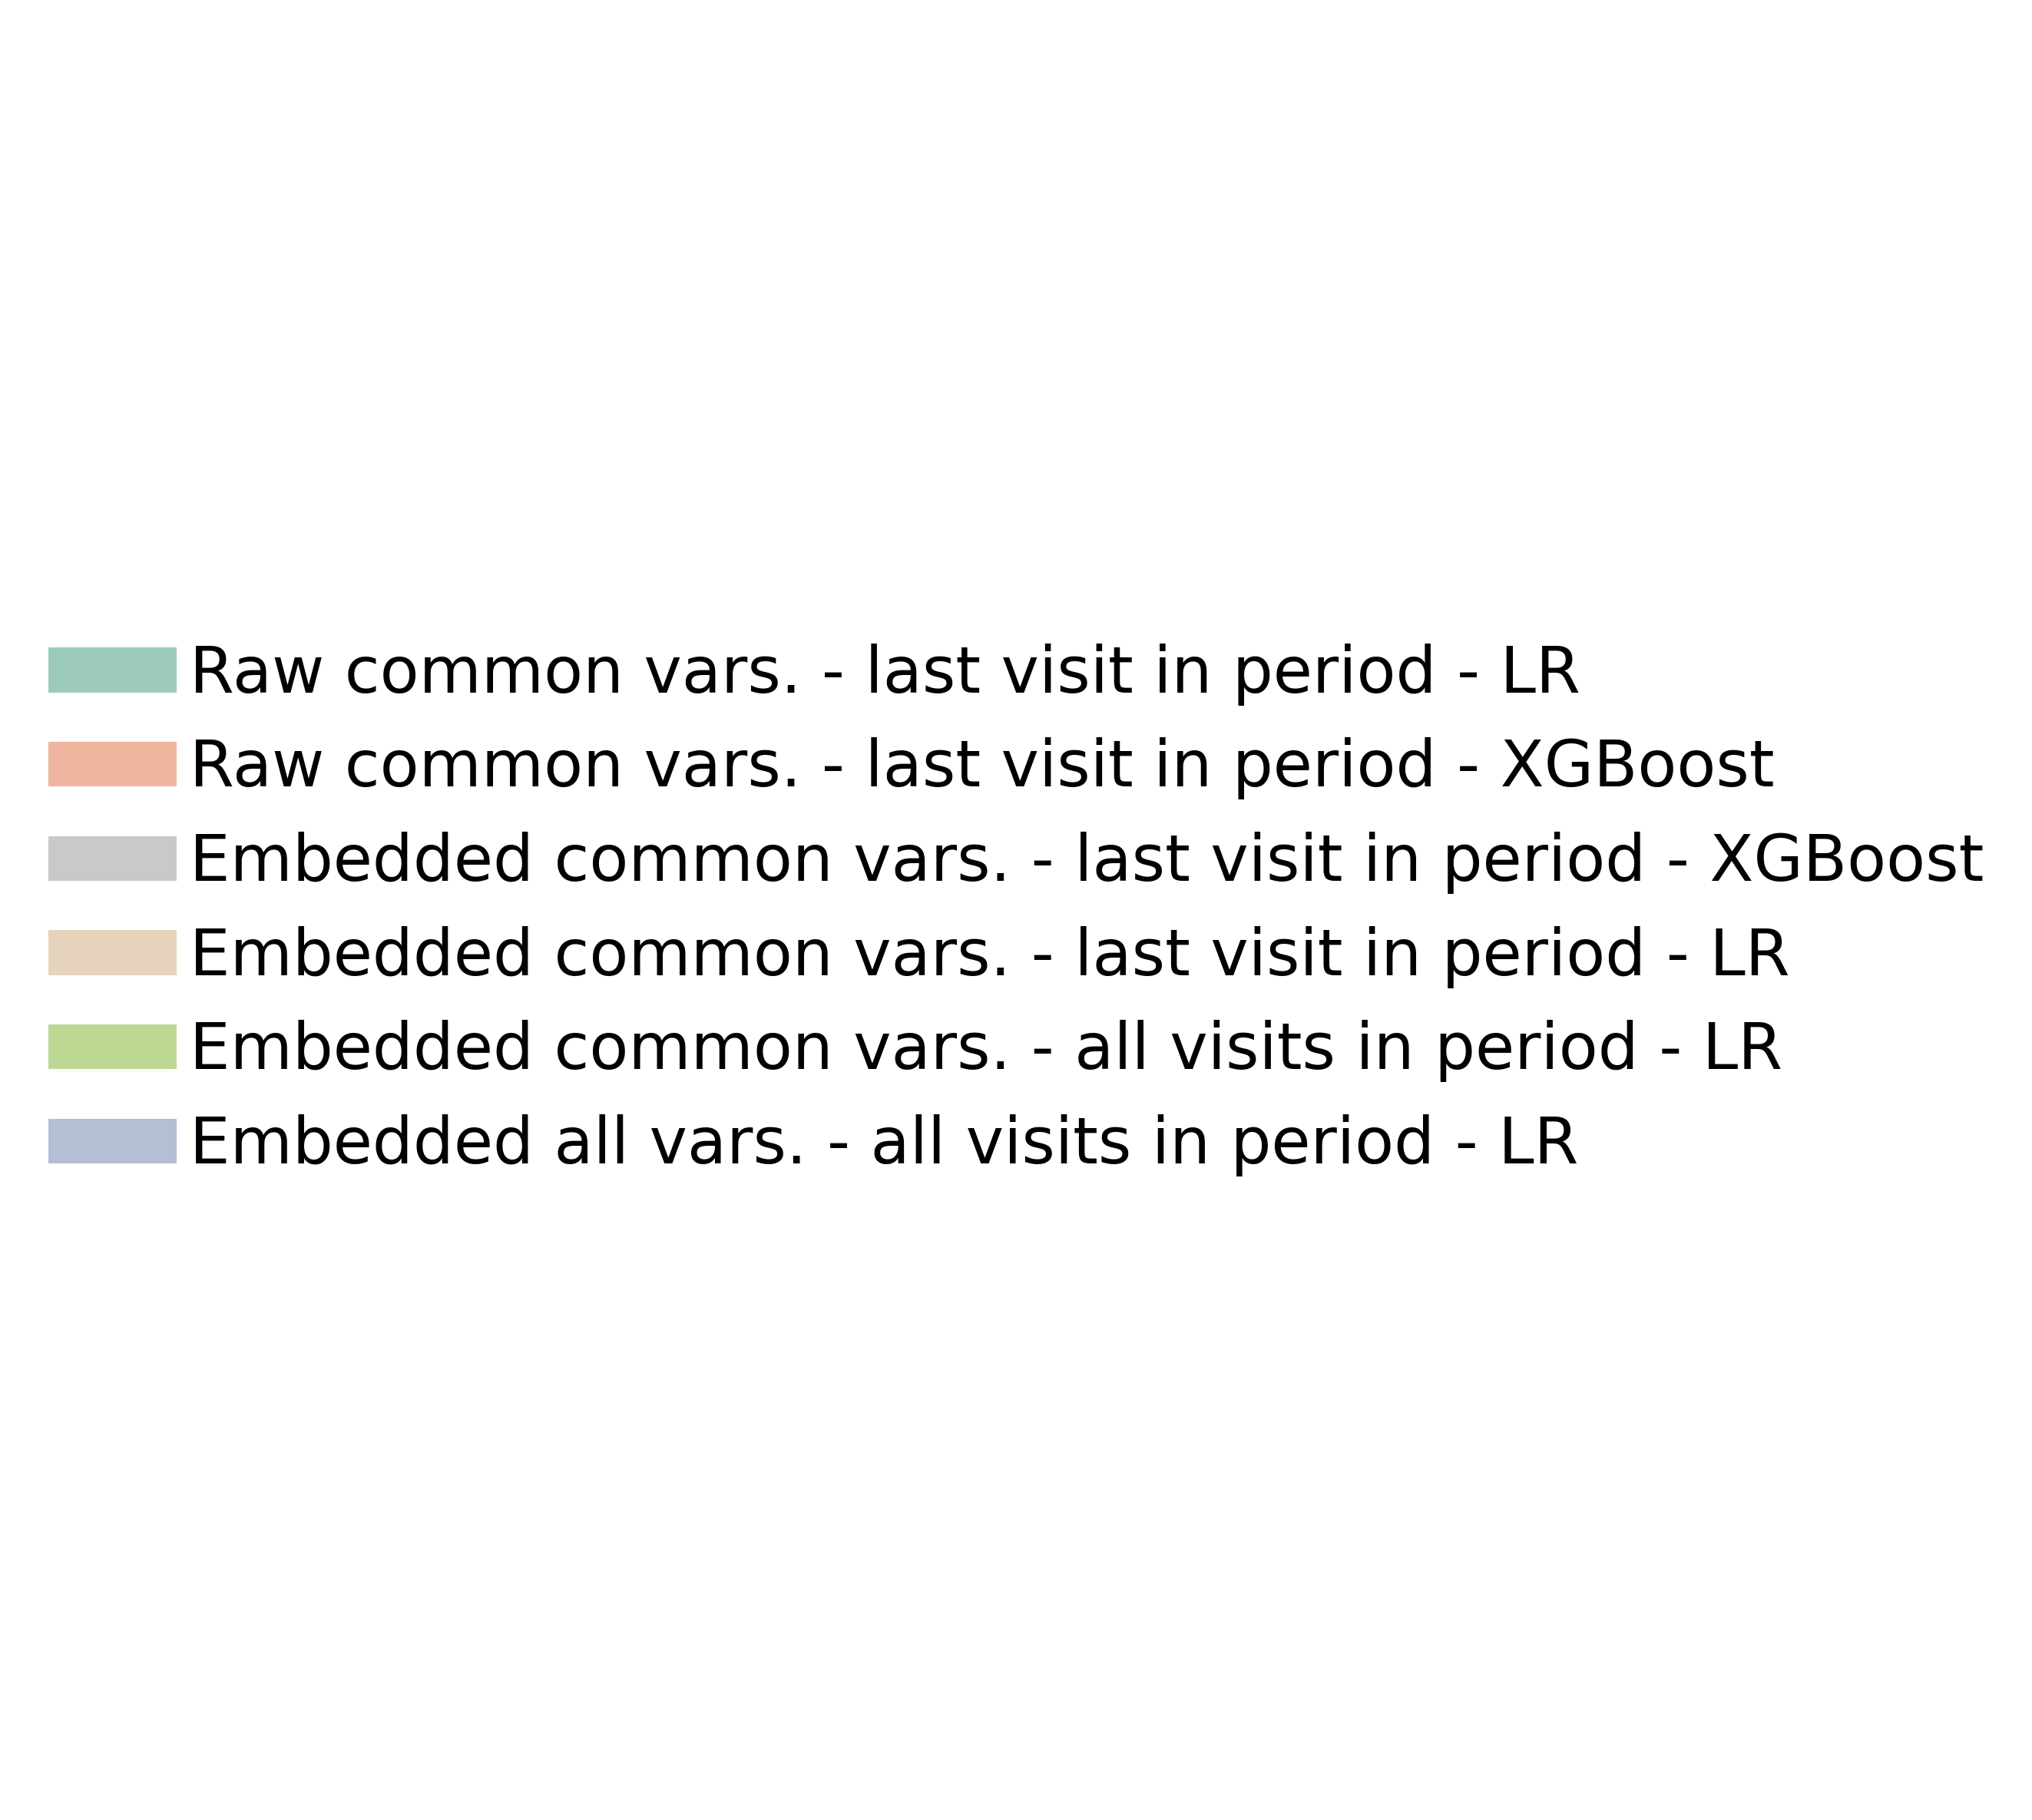

['baseline_last_therapy_day' 'LLM_embed_baseline_vars'
 'LLM_embed_baseline_last_day' 'LLM_embed_all_days']
setup_color_mapping ['Common vars - last visit in period - LogisticRegression', 'Common vars - last visit in period - XGBoost', 'LLM All vars - all visits in period - LogisticRegression', 'LLM All vars - all visits in period - XGBoost', 'LLM Common vars - all visits in period - LogisticRegression', 'LLM Common vars - all visits in period - XGBoost', 'LLM Common vars - last visit in period - LogisticRegression', 'LLM Common vars - last visit in period - XGBoost']
top_fdr_text_y_coord 0.8782550769616166
y_coord_ 0.8982550769616167


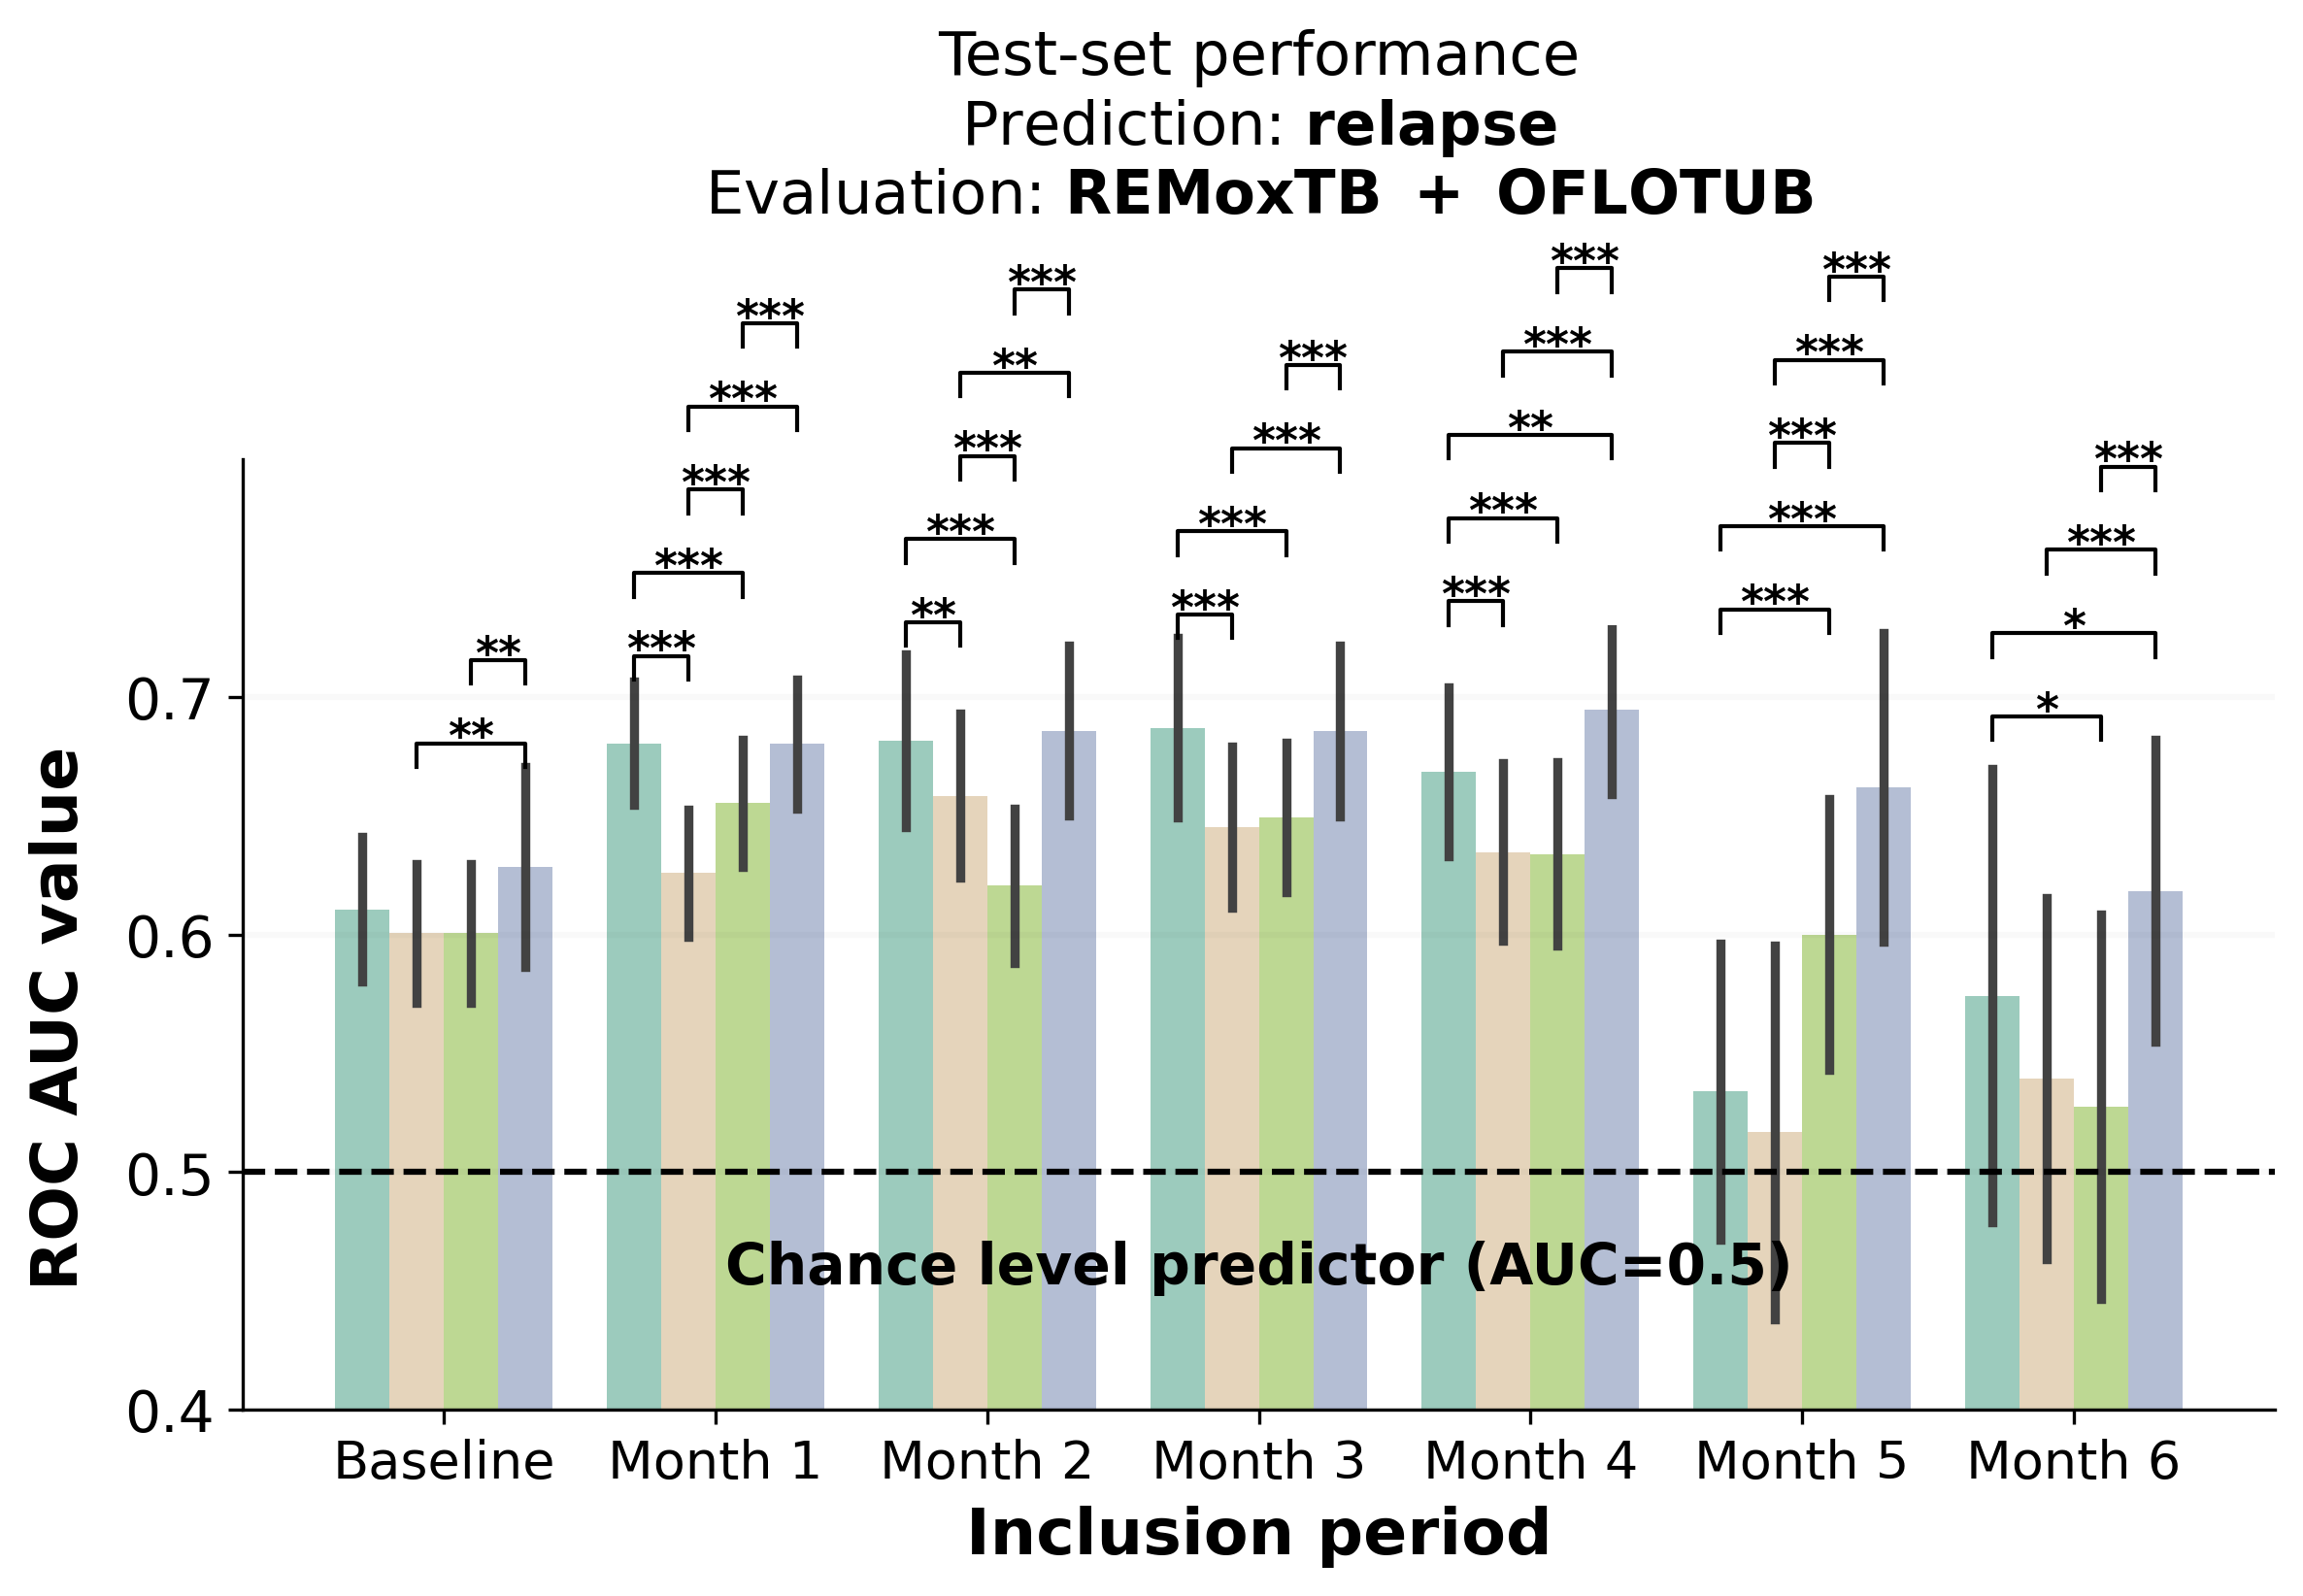

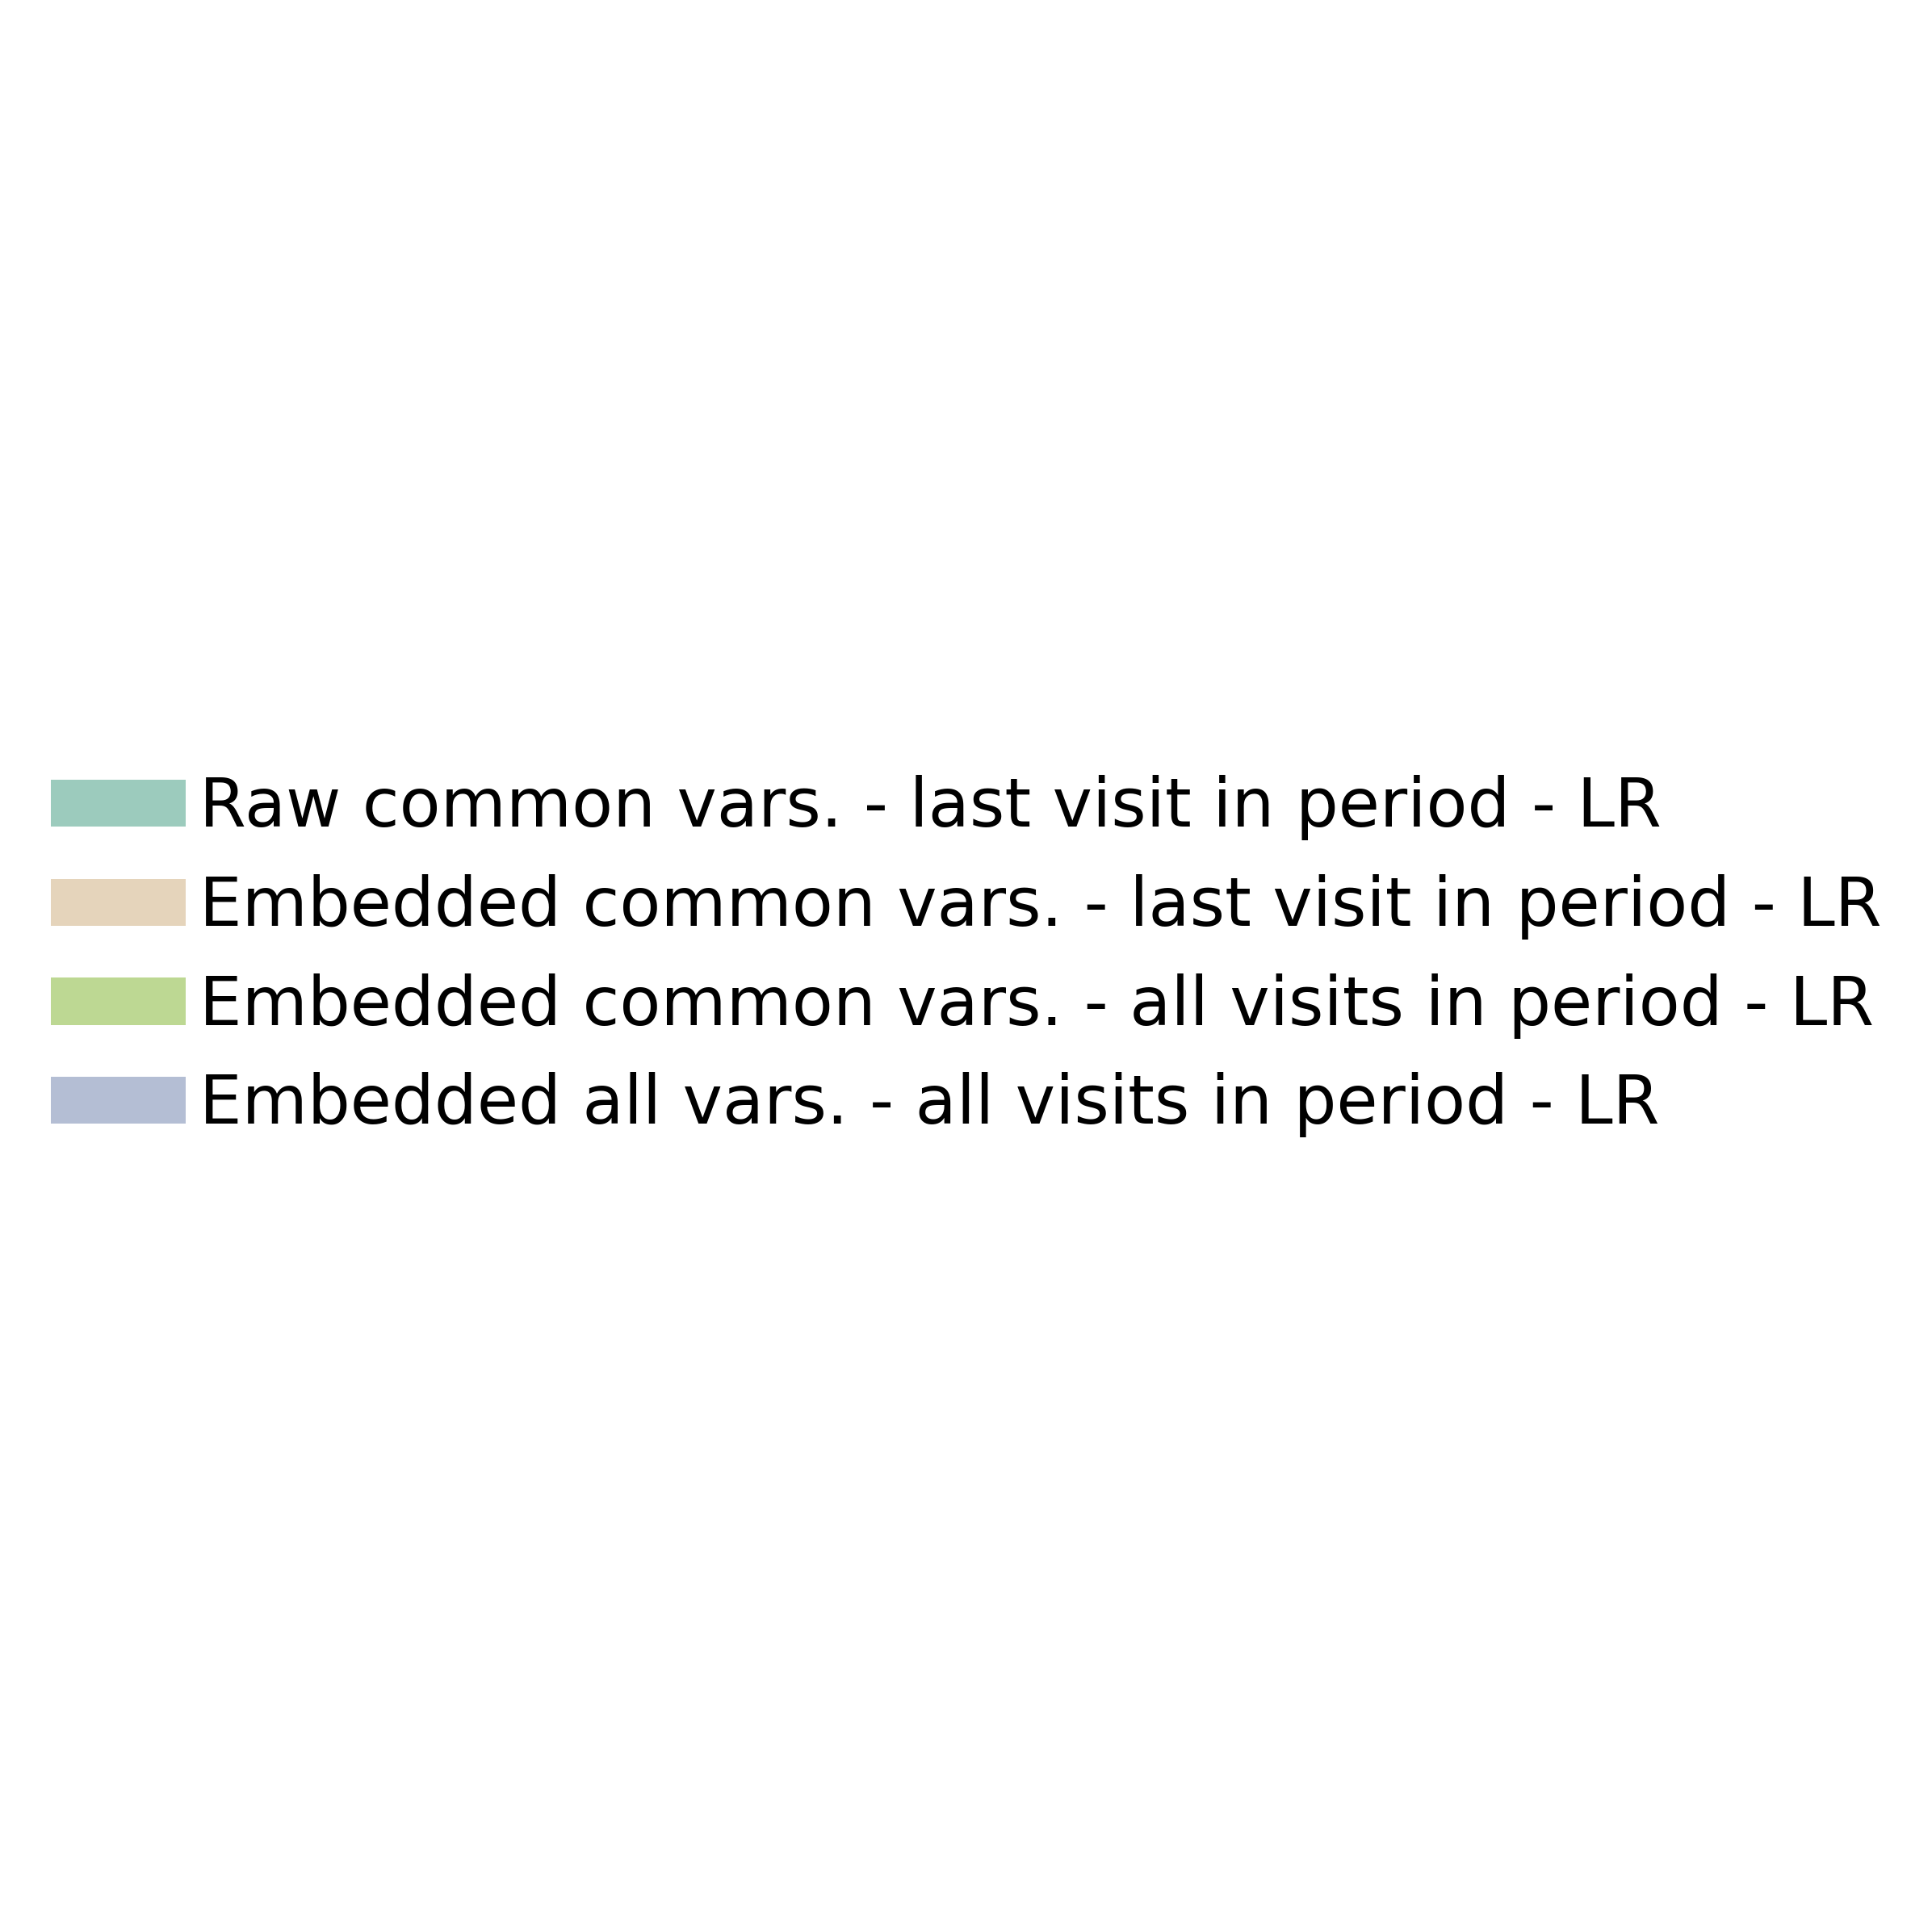

In [31]:
## PLOT ROC-AUC CURVE OF TEST SET
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import roc_auc_score
from scipy.stats import ttest_rel
from functools import reduce
from matplotlib.font_manager import FontProperties

figtitle_size=20
subtitle_size=18
x_tick_size=18
y_tick_size=13
y_label_size=14
legend_fontsize=11.5
axis_lw=1.6


period_end_days=['baseline',31,62,93,125,160,'all']
period_end_days_for_plot=period_end_days[:]

model_names=['XGBoost','LogisticRegression',]#'Dense']#,'SVC','KNN']
autoenc_merged_bool_list=[False,True]


llm_model_names=['BioMistral/BioMistral-7B',"epfl-llm/meditron-7b"]
fine_tuned_tags=['base','fine_tuned']
#model_names=['XGBoost','GradientBoost','LogisticRegression','RandomForest','SVC','KNN']
training_data_types=['full','pca']

llm_model_names=['BioMistral/BioMistral-7B',"epfl-llm/meditron-70b","epfl-llm/meditron-7b",
                 "google/long-t5-local-base",'google/long-t5-tglobal-large',
                'text-embedding-3-small']

suptitle_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMoxTB + OFLOTUB',
               'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':'REMoxTB + OFLOTUB',
               'tb21_22_2984_pats_22_vars_relapse':'REMoxTB + OFLOTUB',
              'tb21_1405_pats_40_vars_result_at_end_of_treatment':'REMoxTB',
               'tb21_1405_pats_40_vars_relapse':'REMoxTB',
              'TB-1021':'REMoxTB',
              'TB-1022':'OFLOTUB'}

plot_split_by_studies=True

baseline_training_data_types=['all_days_in_period','last_therapy_day']
llm_data_inclusion_types=['baseline_vars','baseline_last_day','all_days'][:]


## COMPARISON_1: baseline model setups, that will be compared to all setups in comparison_2
#comparison_1=['baseline_last_therapy_day', 'baseline_all_days_in_period'][:1]
#comparison_2 =['LLM_embed_baseline_last_day','LLM_embed_baseline_vars','LLM_embed_all_days'][:]
comparison_1=['baseline_last_therapy_day', 'LLM_embed_baseline_last_day','LLM_embed_baseline_vars','LLM_embed_all_days'][:]
comparison_2=['baseline_last_therapy_day', 'LLM_embed_baseline_last_day','LLM_embed_baseline_vars','LLM_embed_all_days'][:]

## Order of the different setups within an inclusion period
hue_order=['baseline_all_days_in_period','baseline_last_therapy_day'][1:] + \
           ['LLM_embed_baseline_last_day','LLM_embed_baseline_vars','LLM_embed_all_days'][:]

#hue_order=comparison_1 + comparison_2[:]


## SELECT THE FINAL SETUPS FOR COMPARISON, PER EACH MODEL/INCLUSION PERIOD/INPUT VARIABLE
period_end_days=['baseline',31,62,93,125,160,'all']

final_setup_dict={[*parameters_for_analysis][0]:
                      {'XGBoost':{'include_in_anal':True,
                             'incl_periods':[str(day) for day in period_end_days],
                             'trained_on':['raw_vars','embeddings'][:],
                                 'setups':['baseline_last_therapy_day','LLM_embed_baseline_last_day',
                                                'LLM_embed_baseline_vars','LLM_embed_all_days'][:2]},
        
                      'LogisticRegression':{'include_in_anal':True,
                                      'incl_periods':[str(day) for day in period_end_days],
                                      'trained_on':['raw_vars','embeddings'][:],
                                      'setups':['baseline_last_therapy_day','LLM_embed_all_days',
                                                'LLM_embed_baseline_last_day',
                                                'LLM_embed_baseline_vars',][:]}},

                  
                  [*parameters_for_analysis][1]:
                        {'XGBoost':{'include_in_anal':False,
                             'incl_periods':[str(day) for day in period_end_days],
                             'trained_on':['raw_vars','embeddings'][:1],
                            'setups':['baseline_last_therapy_day','LLM_embed_baseline_last_day',
                                                'LLM_embed_baseline_vars','LLM_embed_all_days'][:]},
                         
                          'LogisticRegression':{'include_in_anal':True,
                                      'incl_periods':[str(day) for day in period_end_days],
                                      'trained_on':['raw_vars','embeddings'][:],
                                      'setups':['baseline_last_therapy_day','LLM_embed_baseline_last_day',
                                                'LLM_embed_baseline_vars','LLM_embed_all_days'][:]}}}

## TO MAKE A COMPARISON ACROSS MODELS POSSIBLE, ADD THE MODEL NAME IN FRONT OF THE HUE AND COMPARISON SETUP NAMES
#hue_order=[f'{mod_name} - {hue}' for mod_name in model_names for hue in hue_order]
hue_order=[f'{hue} - {mod_name}' for mod_name in model_names for hue in hue_order]

## Use underscore in the comparisons, as the model name will be split from the setup name before the t-test calculation, 
#. and used for subsetting the dataframe holding the t-test p-values for all comparisons performed. 
#. See in the function "calc_paired_t_test_between_exp_setups()", also there underscore is used, as a '-' character is already being used at other part of the setup strings.
#. After the t-test, the '_' will be replaced by ' - ' where needed, to match with the hue_order setup names.
#comparison_1=[f'{mod_name}_{comp}' for mod_name in model_names for comp in comparison_1]
#comparison_2=[f'{mod_name}_{comp}' for mod_name in model_names for comp in comparison_2]
comparison_1=[f'{comp}_{mod_name}' for mod_name in model_names for comp in comparison_1]
comparison_2=[f'{comp}_{mod_name}' for mod_name in model_names for comp in comparison_2]


#print(comparison_2)

for data_param_key in [*parameters_for_analysis][:2]:

    for plot_type in ['bar','point'][:1]:

        pred_models_result=[]
        #hue_order=[]
    
        ## LOAD BASELINE MODEL ROC-AUC RESULTS
        for bl_training_data_type in baseline_training_data_types[1:]:
            
            fn=f'../data/test_roc_auc_values/baseline/{data_param_key}_days_{bl_training_data_type}_test_ROC_AUC_across_time_all_studies.csv'
            #fn=f'../data/test_roc_auc_values/baseline/{data_param_key}_days_{bl_training_data_type}_test_ROC_AUC_across_time_per_study..csv'
            baseline_cv_res_acros_time_df=pd.read_csv(fn,index_col=0)
            baseline_cv_res_acros_time_df['trained_on']='raw_vars'
            baseline_cv_res_acros_time_df['setup']=f'baseline_{bl_training_data_type}'
            pred_models_result.append(baseline_cv_res_acros_time_df)
            #hue_order.append(f'baseline_{bl_training_data_type}')

            ## LOAD LLM MODEL ROC-AUC RESULTS
            for llm_model_name in llm_model_names[:1]:
        
                for fine_tuned_tag in fine_tuned_tags[:1]:
                    
                    
                    if 'text-embedding' in llm_model_name:
                        llm_model_name_with_tag=llm_model_name
                    else:
                        llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])
                    
        
                    for data_inclusion_type in llm_data_inclusion_types[:]:
        
                        for training_data_type in training_data_types[:1]:

                            for autoencoder_merged in autoenc_merged_bool_list[:1]:

                                fn=f'../data/test_roc_auc_values/LLM/{data_param_key}_{llm_model_name_with_tag}_{training_data_type}_4096_{data_inclusion_type}_autoenc_{autoencoder_merged}_test_ROC_AUC_across_time_all_studies.csv'                                                    
                                #fn=f'../data/test_roc_auc_values/LLM/{data_param_key}_{llm_model_name_with_tag}_{training_data_type}_4096_{data_inclusion_type}_autoenc_{autoencoder_merged}_test_ROC_AUC_across_time_per_study.csv'                                                    
                                llm_cv_res_acros_time_df=pd.read_csv(fn,index_col=0)
                                llm_cv_res_acros_time_df['trained_on']='embeddings'
                                llm_cv_res_acros_time_df['setup']=f'LLM_embed_{data_inclusion_type}'
                                pred_models_result.append(llm_cv_res_acros_time_df)
                                
        #hue_order=comparison_1
        plot_df = pd.concat(pred_models_result,axis=0)

        print(plot_df['setup'].unique())

        # Refine names of the setups
        replacements = {
            '_embed_baseline_vars': ' Common vars - all visits in period',
            '_embed_baseline_last_day': ' Common vars - last visit in period',
            'baseline_last_therapy_day': 'Common vars - last visit in period',
            'baseline_all_days_in_period': 'Common vars - last visits concatenated',
            '_embed_all_days':' All vars - all visits in period'}
        
  
        
        #sns.barplot(data=plot_df,x='inclusion_period',y='ROC_AUC_score',hue='setup')
        plot_df['setup__']=plot_df['setup'].values
        plot_df['setup']=plot_df['setup'].replace(replacements,regex=True)
        plot_df['setup_']=plot_df['setup'] +' - '+ plot_df['model_name']

        ## CREATE CUSTOM PALETTE FOR SETUPS
        setups=np.sort(plot_df['setup_'].unique())
        setup_colors = plt.cm.get_cmap('Set2', len(setups))  # Use a colormap with enough distinct colors
        setup_color_mapping = {setup: setup_colors(i) for i, setup in enumerate(setups)}

        print('setup_color_mapping',[*setup_color_mapping])

        ## FILTER SETUPS BASED ON THE final_setup_dict, WHICH DETERMINES WHICH SETUPS ARE USED FOR FINAL COMPARISON
        l=[]

        for model_name in [*final_setup_dict[data_param_key]]:

            if final_setup_dict[data_param_key][model_name]['include_in_anal']==True:
            
                incl_periods_=final_setup_dict[data_param_key][model_name]['incl_periods']
                trained_on=final_setup_dict[data_param_key][model_name]['trained_on']
                setups=final_setup_dict[data_param_key][model_name]['setups']
                
                plot_df_filt = plot_df.loc[(plot_df['model_name']==model_name)\
                                            &(plot_df['trained_on'].isin(trained_on))\
                                            &(plot_df['inclusion_period'].isin(incl_periods_))\
                                            &(plot_df['setup__'].isin(setups))]
                #print(plot_df_filt)
                l.append(plot_df_filt)
        
        plot_df = pd.concat(l,axis=0)


     
        
        # Update hur_order list with refined setup names
        hue_order_=replace_substring_in_list(replacements,hue_order)
        comparison_1_=replace_substring_in_list(replacements,comparison_1)
        comparison_2_=replace_substring_in_list(replacements,comparison_2)

        ## FILTER HUE AND COMPARISONS ORDER BASED ON THE SETUPS IN PLOT_DF
        hue_order_ = [hue for hue in hue_order_ if hue in plot_df['setup_'].unique()]
        comparison_1_ = [comp for comp in comparison_1_ if comp.replace('_',' - ') in plot_df['setup_'].unique()]
        comparison_2_ = [comp for comp in comparison_2_ if comp.replace('_',' - ') in plot_df['setup_'].unique()]

        hue_order_ = list(np.sort([x for x in hue_order_ if x.startswith('Common vars')])) + \
                             [x for x in hue_order_ if not x.startswith('Common vars')]
        comparison_1_ = list(np.sort([x for x in comparison_1_ if x.startswith('Common vars')])) + \
                                     [x for x in comparison_1_ if not x.startswith('Common vars')]
        comparison_2_ = list(np.sort([x for x in comparison_2_ if x.startswith('Common vars')])) + \
                                     [x for x in comparison_2_ if not x.startswith('Common vars')]
        
        
        ## Change names of inlcusion periods to months
        period_dict=dict(zip([str(x) for x in period_end_days],
                             #[f'{int(np.floor(int(day)/30))} month' if day !='all' else '6 month' for day in period_end_days]
                            
                             ['Month 6' if day == 'all' 
                                        else 'Baseline' if day == 'baseline' 
                                        else f'Month {int(np.floor(int(day)/30))}' if isinstance(day, int) 
                                        else None 
                                        for day in period_end_days_for_plot]
                                             ))
        plot_df['inclusion_period']=plot_df['inclusion_period'].map(period_dict)
        plot_df = plot_df.sort_values(['inclusion_period','setup_','Num_of_CV_repeat'])

        ## Within each model type & inclusion period, calculate the paired t-test results across experimental setups. 
        #. The results coming from the same CV-splits are compared across exp. setups, these are paired for the t-test
        #. The dict. holds all the raw p-values of the t-tests across all exp. setups
        paired_t_res_dict = calc_paired_t_test_between_exp_setups(plot_df)
        #extract_paired_t_test_FDR(ttest_res_df,comparison_1,comparison_2)

        # Figure size customization


        
        # Create a FacetGrid for splitting by 'model_name'
        #g = sns.FacetGrid(plot_df, col='model_name', col_wrap=1, height=fig_height, aspect=1.6,sharex=False,sharey=False)
        fig,ax=plt.subplots(1,1,figsize=(9,3.5))
        #fig,ax=plt.subplots(1,1,figsize=(9,5))
        #fig,ax=plt.subplots(1,1,figsize=(8,5))


        
        # Map barplot onto the FacetGrid
        if plot_type=='bar':
            #g.map_dataframe(
                sns.barplot(data=plot_df,
                            x='inclusion_period',
                            y='ROC_AUC_score', 
                            hue='setup_', 
                            errorbar='sd',
                            #palette='Pastel1',
                            palette=setup_color_mapping,
                            hue_order=hue_order_,
                            ax=ax,
                            alpha=0.7)

        
        if plot_type=='point':
            #g.map_dataframe(
                sns.pointplot(data=plot_df, 
                            x='inclusion_period',
                            y='ROC_AUC_score', 
                            hue='setup_', 
                            errorbar='sd',
                            #palette='Pastel1',
                            palette=setup_color_mapping,
                            hue_order=hue_order_,
                            ax=ax,
                            alpha=0.7)
                                 
        
       
        #ax.set_title()

        #ax.set_ylabel("ROC AUC value",fontsize=16,fontweight='bold')
        ax.set_xlabel("Inclusion period",fontsize=16,fontweight='bold')


        #ax.set_title(study)

        
        # Customize tick sizes
        #for ax in g.axes.flat:  # Loop through each subplot
        ax.tick_params(axis='x', labelsize=13)  # Customize x tick size
        ax.tick_params(axis='y', labelsize=14)  # Customize y tick size


    

        ax.spines[['top','right']].set_visible(False)


         ## PLot chance predicor's line at 0.5
        ax.axhline(y=0.5,color='black', linestyle='dashed')
        range_mean=(ax.get_xlim()[1]+ ax.get_xlim()[0])/2
        ax.text(range_mean,0.46,'Chance level predictor (AUC=0.5)',fontsize=14,fontweight='bold',
                            rotation=0,horizontalalignment='center', verticalalignment='center',rotation_mode='default')

        #xticklabels=[f'{int(np.floor(int(day)/30))} month' if day !='all' else '6 month' for day in period_end_days]
        #ax.set_xticklabels(ax.get_xticklabels(), fontsize=12) #weight='bold'
        #ax.grid(alpha=0.4)
        

        if plot_type=='bar':
            p_val_fontsize=11
            gap_bracket_p_val=0.008
            fdr_text_coords_dict,err_bar_pos_dict=add_fdr_vals_to_bars(ax,plot_df,hue_order_,paired_t_res_dict,comparison_1_,comparison_2_,p_val_fontsize,gap_bracket_p_val)

        ## Extract the y-coordinates of the fdr texts from the barplot, and take the maximum y-coordinate of the first 3 periods
        #. ==> change the ylim according to the top fdr text, therefore the legend will be placed above this area without overlapping with the fdr values over the bars
        top_fdr_text_y_coord = np.max([np.max(np.array(list(fdr_text_coords_dict[per].values()))[:,1]) for per in plot_df['inclusion_period'].unique()[:-1]\
                                      if np.array(list(fdr_text_coords_dict[per].values())).shape[0]>0])
        top_err_bar_y_coord = np.max([np.max(np.array(list(err_bar_pos_dict[per].values()))[:,1]) for per in plot_df['inclusion_period'].unique()[:]])
        
        #print('top_fdr_text_y_coord',top_fdr_text_y_coord)
        ylim= top_err_bar_y_coord
        ax.set_ylim(0.4,ylim)
        #ax.set_ylim(0.4,1)
        

        ## Set spine of y-axis
        spine_ymin, spine_ymax = 0.4, min(1.0,top_err_bar_y_coord)
        ax.spines['left'].set_bounds(spine_ymin, (np.ceil(spine_ymax*10))/10) 

        # Set the filtered y-ticks       
        


        if min(1,spine_ymax)<1:     
            yticks = np.arange(0.4, min(1,spine_ymax), 0.1)
            # Manually add gridlines only for valid y-ticks
            for ytick in yticks[:]:
                ax.axhline(y=ytick, color='black', linestyle='-', alpha=0.025)
        else:
            yticks = np.arange(0.4, 1.1, 0.1)
            # Manually add gridlines only for valid y-ticks
            for ytick in yticks:
                ax.axhline(y=ytick, color='black', linestyle='-', alpha=0.025)
        
        ax.set_yticks(yticks)

        
        #bar_x_coords=np.array([list(err_bar_pos_dict[per].values()) for per in plot_df['inclusion_period'].unique()[:]])[:,:,0].flatten()
        #for bar_x_coord in bar_x_coords:
        #    ax.axvline(x=bar_x_coord, color='black', linestyle='-', alpha=0.025)
        


        ## Place the y-label according to the spine bounds
        y_spine_center = (spine_ymin + spine_ymax) / 2
        
        # Transform to axes-relative coordinates
        _, y_axes_center = ax.transData.transform((0, y_spine_center))
        _, y_axes_center = ax.transAxes.inverted().transform((0, y_axes_center))
        
        # Manually add y-axis label
        ax.set_ylabel(None)  # Remove default label
        
        ax.text(
            -0.09, y_axes_center,           # -0.13: controls horizontal distance from axis
            "ROC AUC value",
            transform=ax.transAxes,
            fontsize=16, fontweight='bold',
            ha='center', va='center',
            rotation='vertical'
        )

        # Adjust layout for better appearance
        # Adjust the overall figure size
        if data_param_key in suptitle_dict.keys():
            study_names=suptitle_dict[data_param_key]
            if 'relapse' not in data_param_key:
                prediction_time=data_param_key.split('at_')[-1].replace('_','-')
                prediction_time = rf"$\bf{{{prediction_time}\ outcome}}$"
     
        
            if 'relapse' in data_param_key:
                prediction_time='relapse'
                prediction_time = r'$\bf{relapse}$'
    
            study_names=study_names.replace(' ',r'\ ')
            study_names=rf"$\bf{{{study_names}}}$"


            suptitle= f"Test-set performance\nPrediction: {prediction_time}\nEvaluation: {study_names}"
            
        #fig.suptitle(suptitle,y=0.95,fontweight='normal',fontsize=15)
        
        ### ADD TITLE DYNAMICALLY, POSITIONOD OVER THE HIGHEST BRACKET
        from matplotlib.transforms import blended_transform_factory

        # This transform uses axes coords for x (0.5 is center), and data coords for y
        transform = blended_transform_factory(ax.transAxes, ax.transData)

        y_coord_=top_fdr_text_y_coord if top_fdr_text_y_coord>1.2 else top_fdr_text_y_coord + 0.02 
        print('top_fdr_text_y_coord',top_fdr_text_y_coord)
        print('y_coord_',y_coord_)
        ax.text(
            0.5, y_coord_,  # 0.5 in Axes x-coords, y in data-coords
            suptitle,
            ha='center', va='bottom',
            transform=transform,
            fontsize=15, fontweight='normal')
        

        
        # Add legends
        handles, labels=ax.get_legend_handles_labels()
        ax.get_legend().remove()
        labels = [lab.replace('LogisticRegression','LR') for lab in labels]
        #print('lalbels before adjustment',labels)
        labels = adjust_legend_labels(labels)
        #print('lalbels after adjustment',labels)

        ## Calculate the relative coordinates of legend ased on absolute coordinates of the axes object
        # absolute (figure) coordinates
        x_data, y_data = ax.get_xlim()[0], ax.get_ylim()[1]#1.015
        
        # Convert from data to display (pixel) coordinates
        display_coords = ax.transData.transform((x_data, y_data))
        
        # Convert from display to axes-relative coordinates
        axes_coords = ax.transAxes.inverted().transform(display_coords)
        #print('axes_coords',axes_coords)

        leg_fig,leg_ax=plt.subplots(1,1,figsize=(10,10))
        
                
        leg_ax.legend(handles=handles,
                  labels=labels,               
                  alignment='left',
                  fontsize=20,
                  markerscale=3,
                  #loc='upper left',
                  loc='center',
                  #bbox_to_anchor=axes_coords,
                  #bbox_to_anchor='center'
                  frameon=False,
                  handletextpad=0.2,
                  #title='Experimental setup',
                  #title_fontproperties=FontProperties(weight='bold', size=12),
                 )
        leg_ax.axis("off")
        

        #plt.tight_layout()

        
        ## SAVE PLOTS
        data_dir_=f'../data/plots/ROC_AUC_setup_comparisons/RAW_LLM_models/{data_param_key}'
        os.makedirs(data_dir_,exist_ok=True)
        fn=os.path.join(data_dir_,
                    f'{plot_type}_across_studies_preselected_setups.png')
        fig.savefig(fn, bbox_inches='tight', dpi=300)

        fn=os.path.join(data_dir_,
                     f'{plot_type}_across_studies_preselected_setups_legend.png')
        leg_fig.savefig(fn, bbox_inches='tight', dpi=300)
        
        plt.show()
        
                        

In [ ]:



#[np.array(list(fdr_text_coords_dict[per].values()))[:,:] for per in plot_df['inclusion_period'].unique()[:]]

### Per study

['Month 4' 'Month 5' 'Month 1' 'Month 2' 'Month 3' 'Baseline']
spine_ymax 0.9523337051039994
spine max bound 0.9
min(1,spine_ymax) 0.9523337051039994
yticks [0.4 0.5 0.6 0.7 0.8 0.9]
top_fdr_text_y_coord 1.2688696125051424
y_coord_ 1.2688696125051424
['Month 4' 'Month 5' 'Month 1' 'Month 2' 'Month 3' 'Baseline']
spine_ymax 0.9750197385691699
spine max bound 0.9
min(1,spine_ymax) 0.9750197385691699
yticks [0.4 0.5 0.6 0.7 0.8 0.9]
top_fdr_text_y_coord 1.3000197385691699
y_coord_ 1.3000197385691699
['Month 4' 'Month 5' 'Month 1' 'Month 2' 'Month 3' 'Month 6' 'Baseline']
spine_ymax 0.767264928436619
spine max bound 0.7
min(1,spine_ymax) 0.767264928436619
yticks [0.4 0.5 0.6 0.7]
top_fdr_text_y_coord 0.917264928436619
y_coord_ 0.930264928436619
['Month 4' 'Month 5' 'Month 1' 'Month 2' 'Month 3' 'Month 6' 'Baseline']
spine_ymax 0.762934383021871
spine max bound 0.7
min(1,spine_ymax) 0.762934383021871
yticks [0.4 0.5 0.6 0.7]
top_fdr_text_y_coord 0.947934383021871
y_coord_ 0.9609343830218711

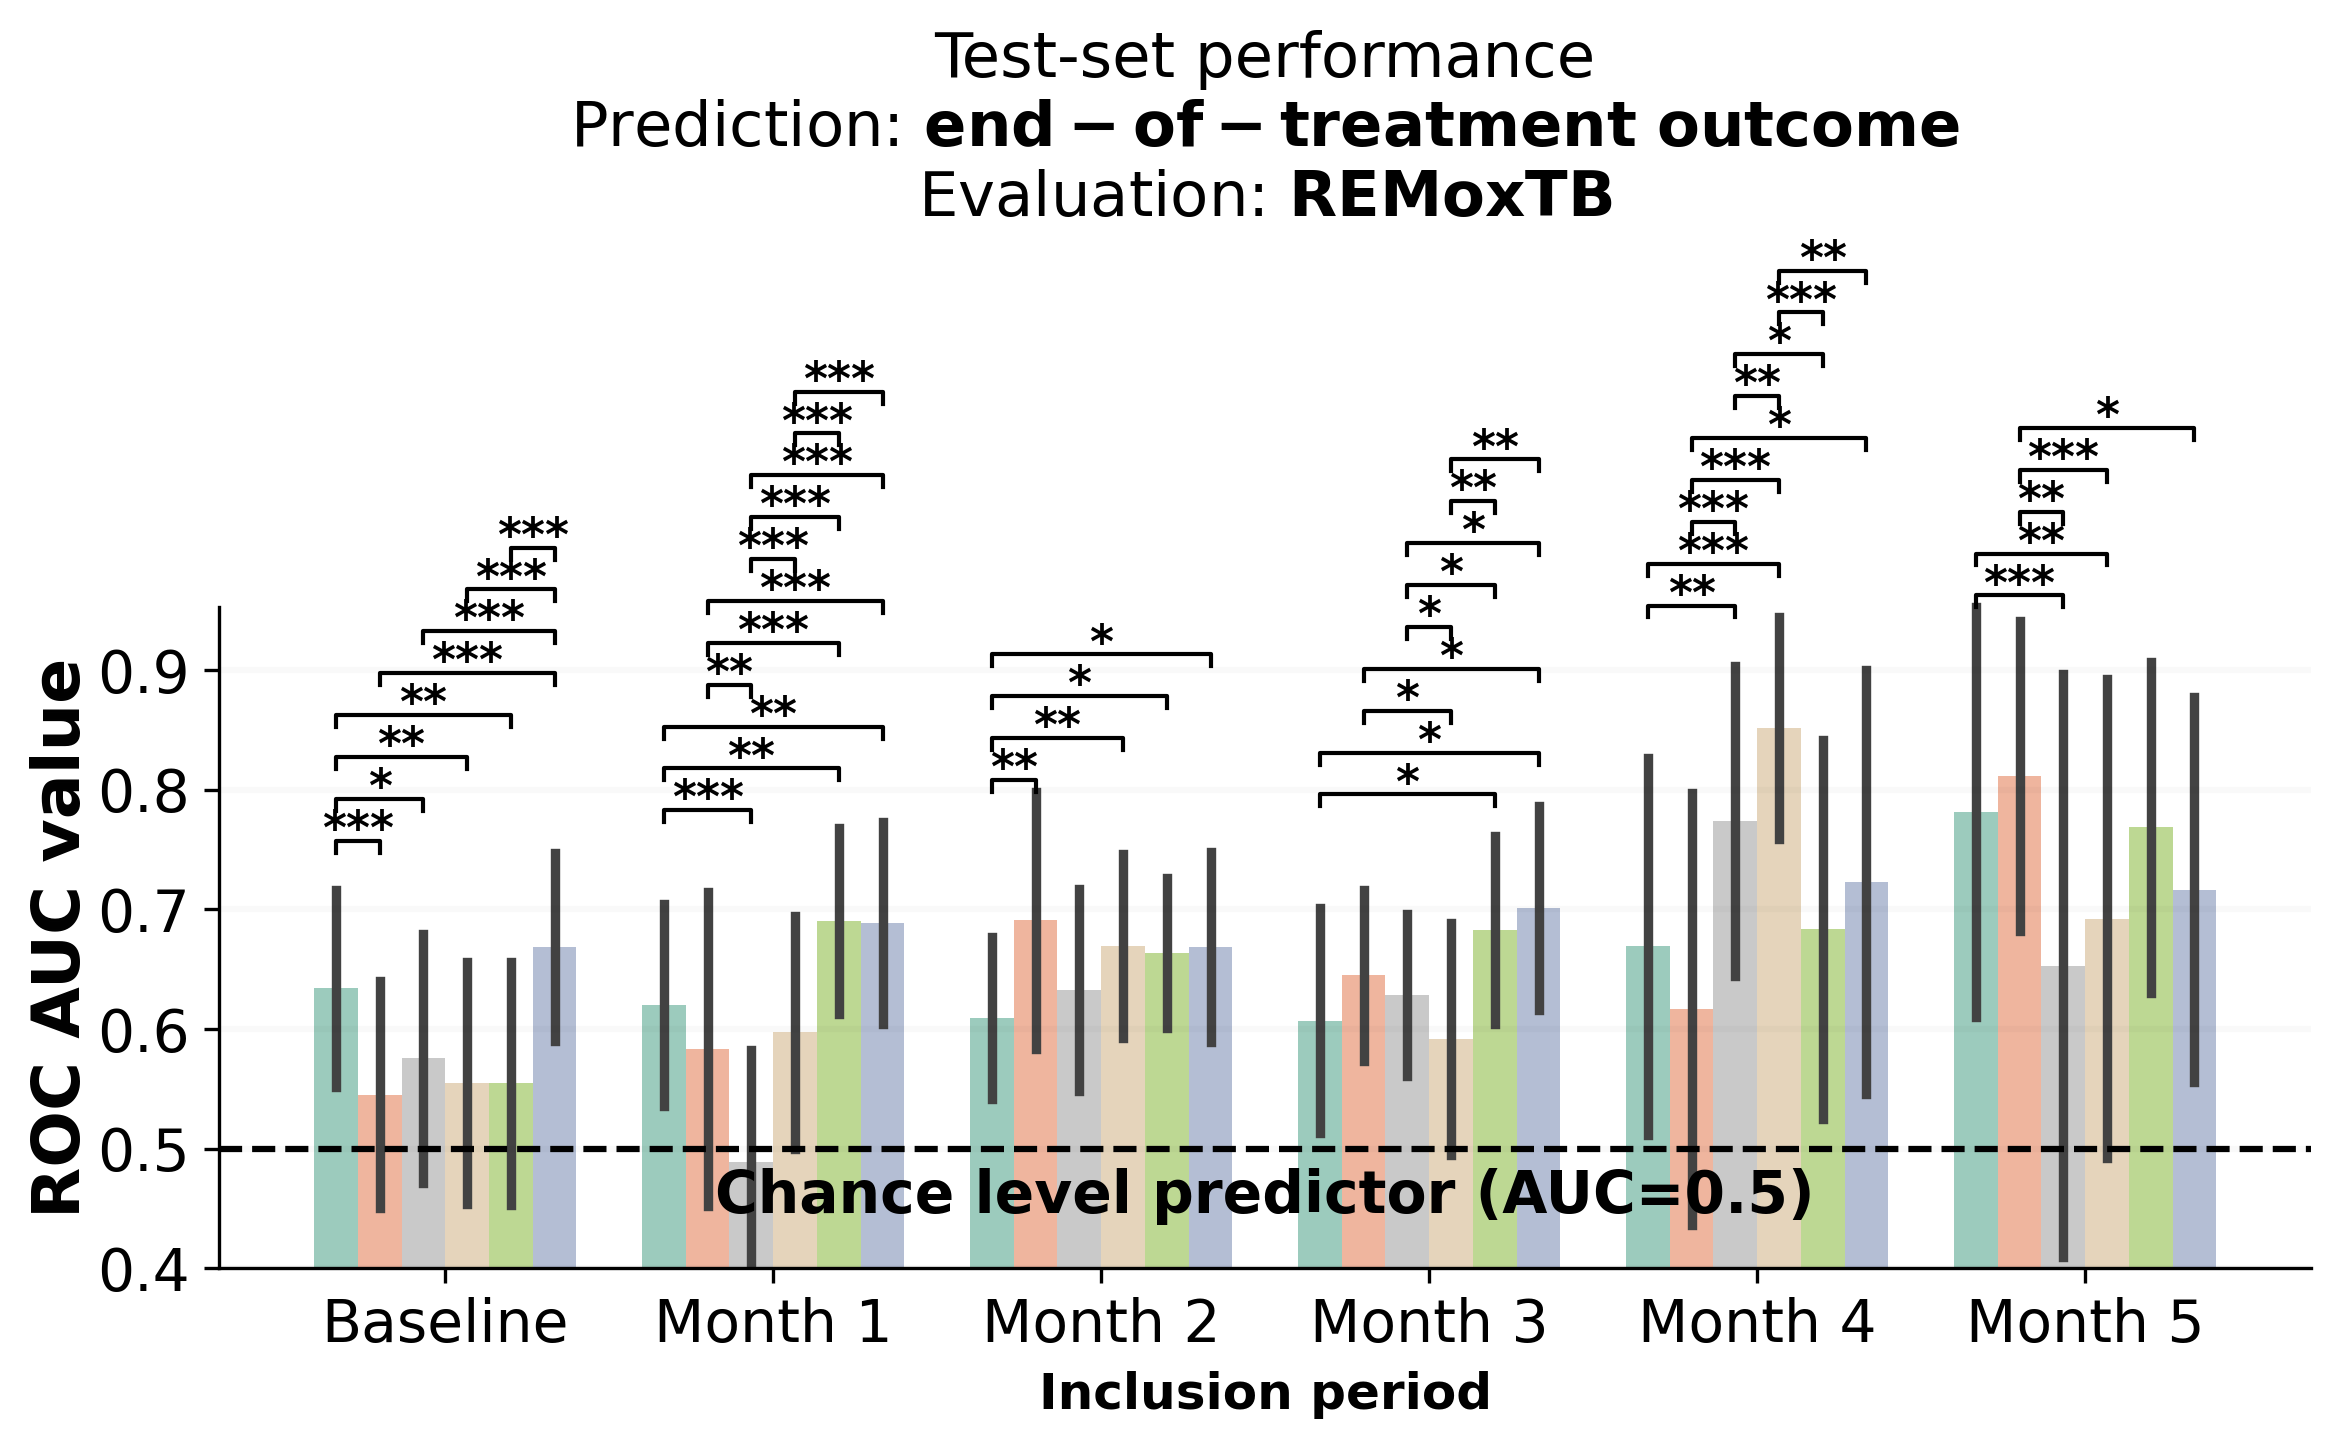

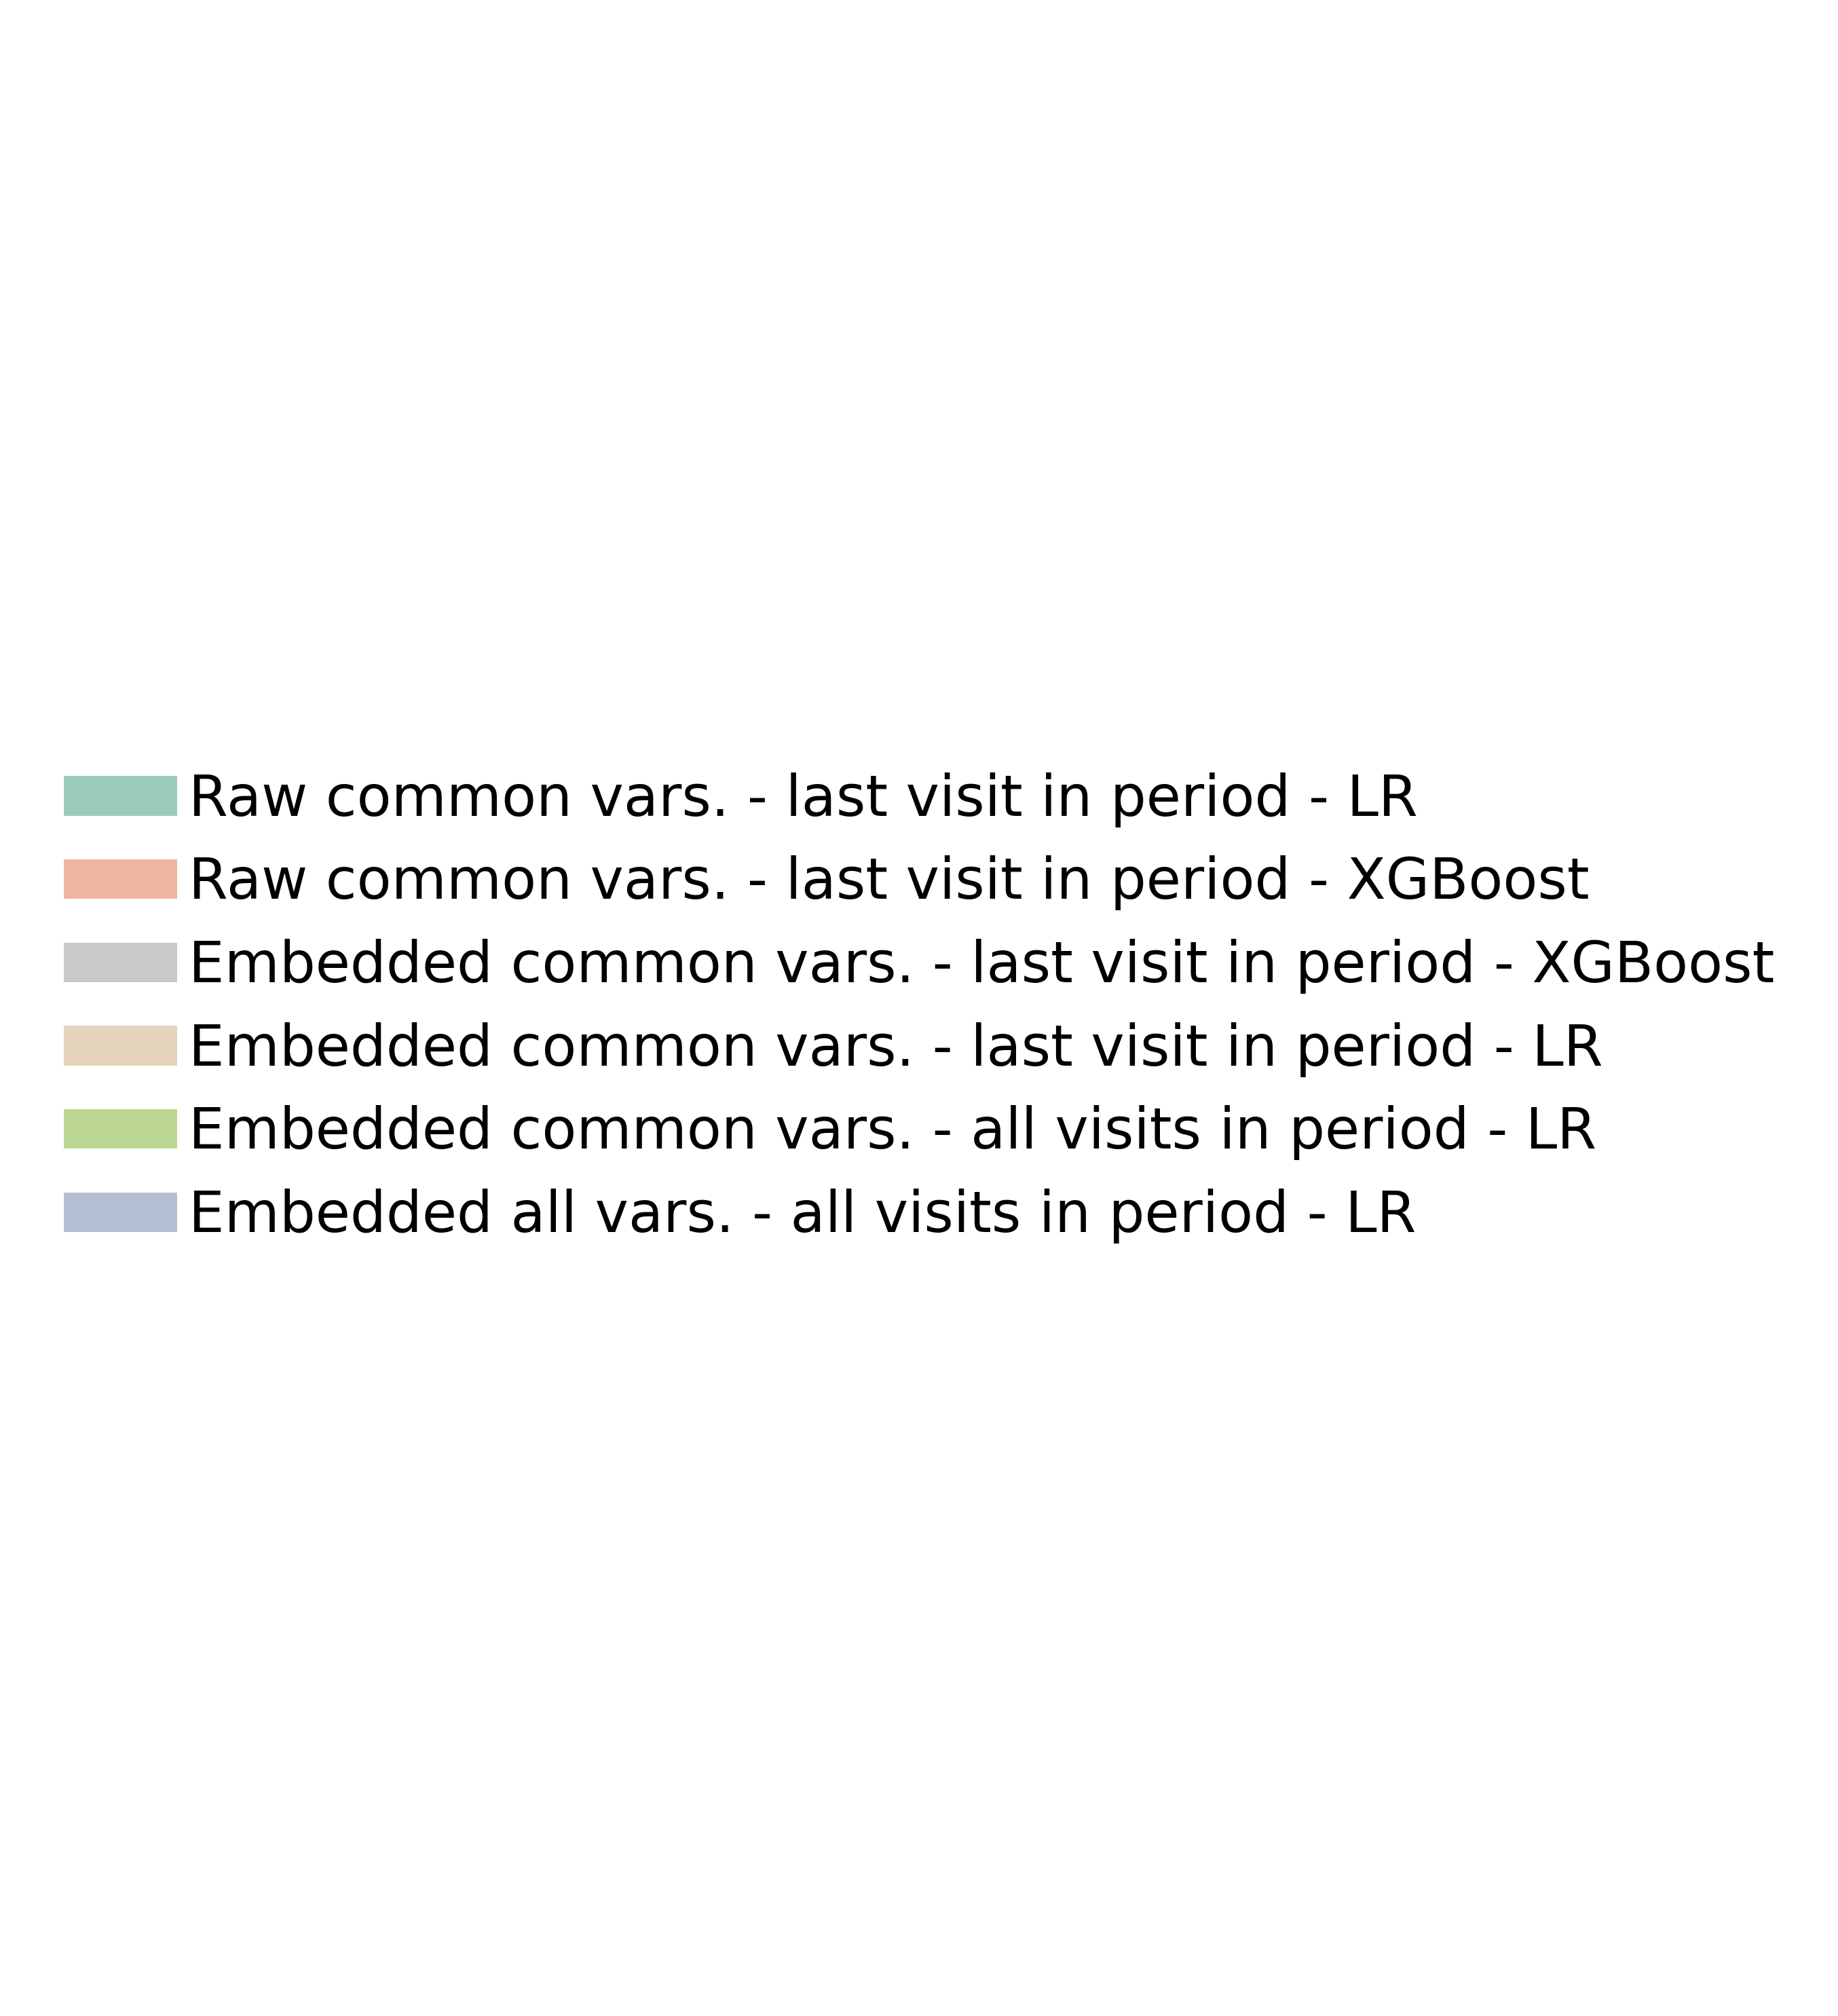

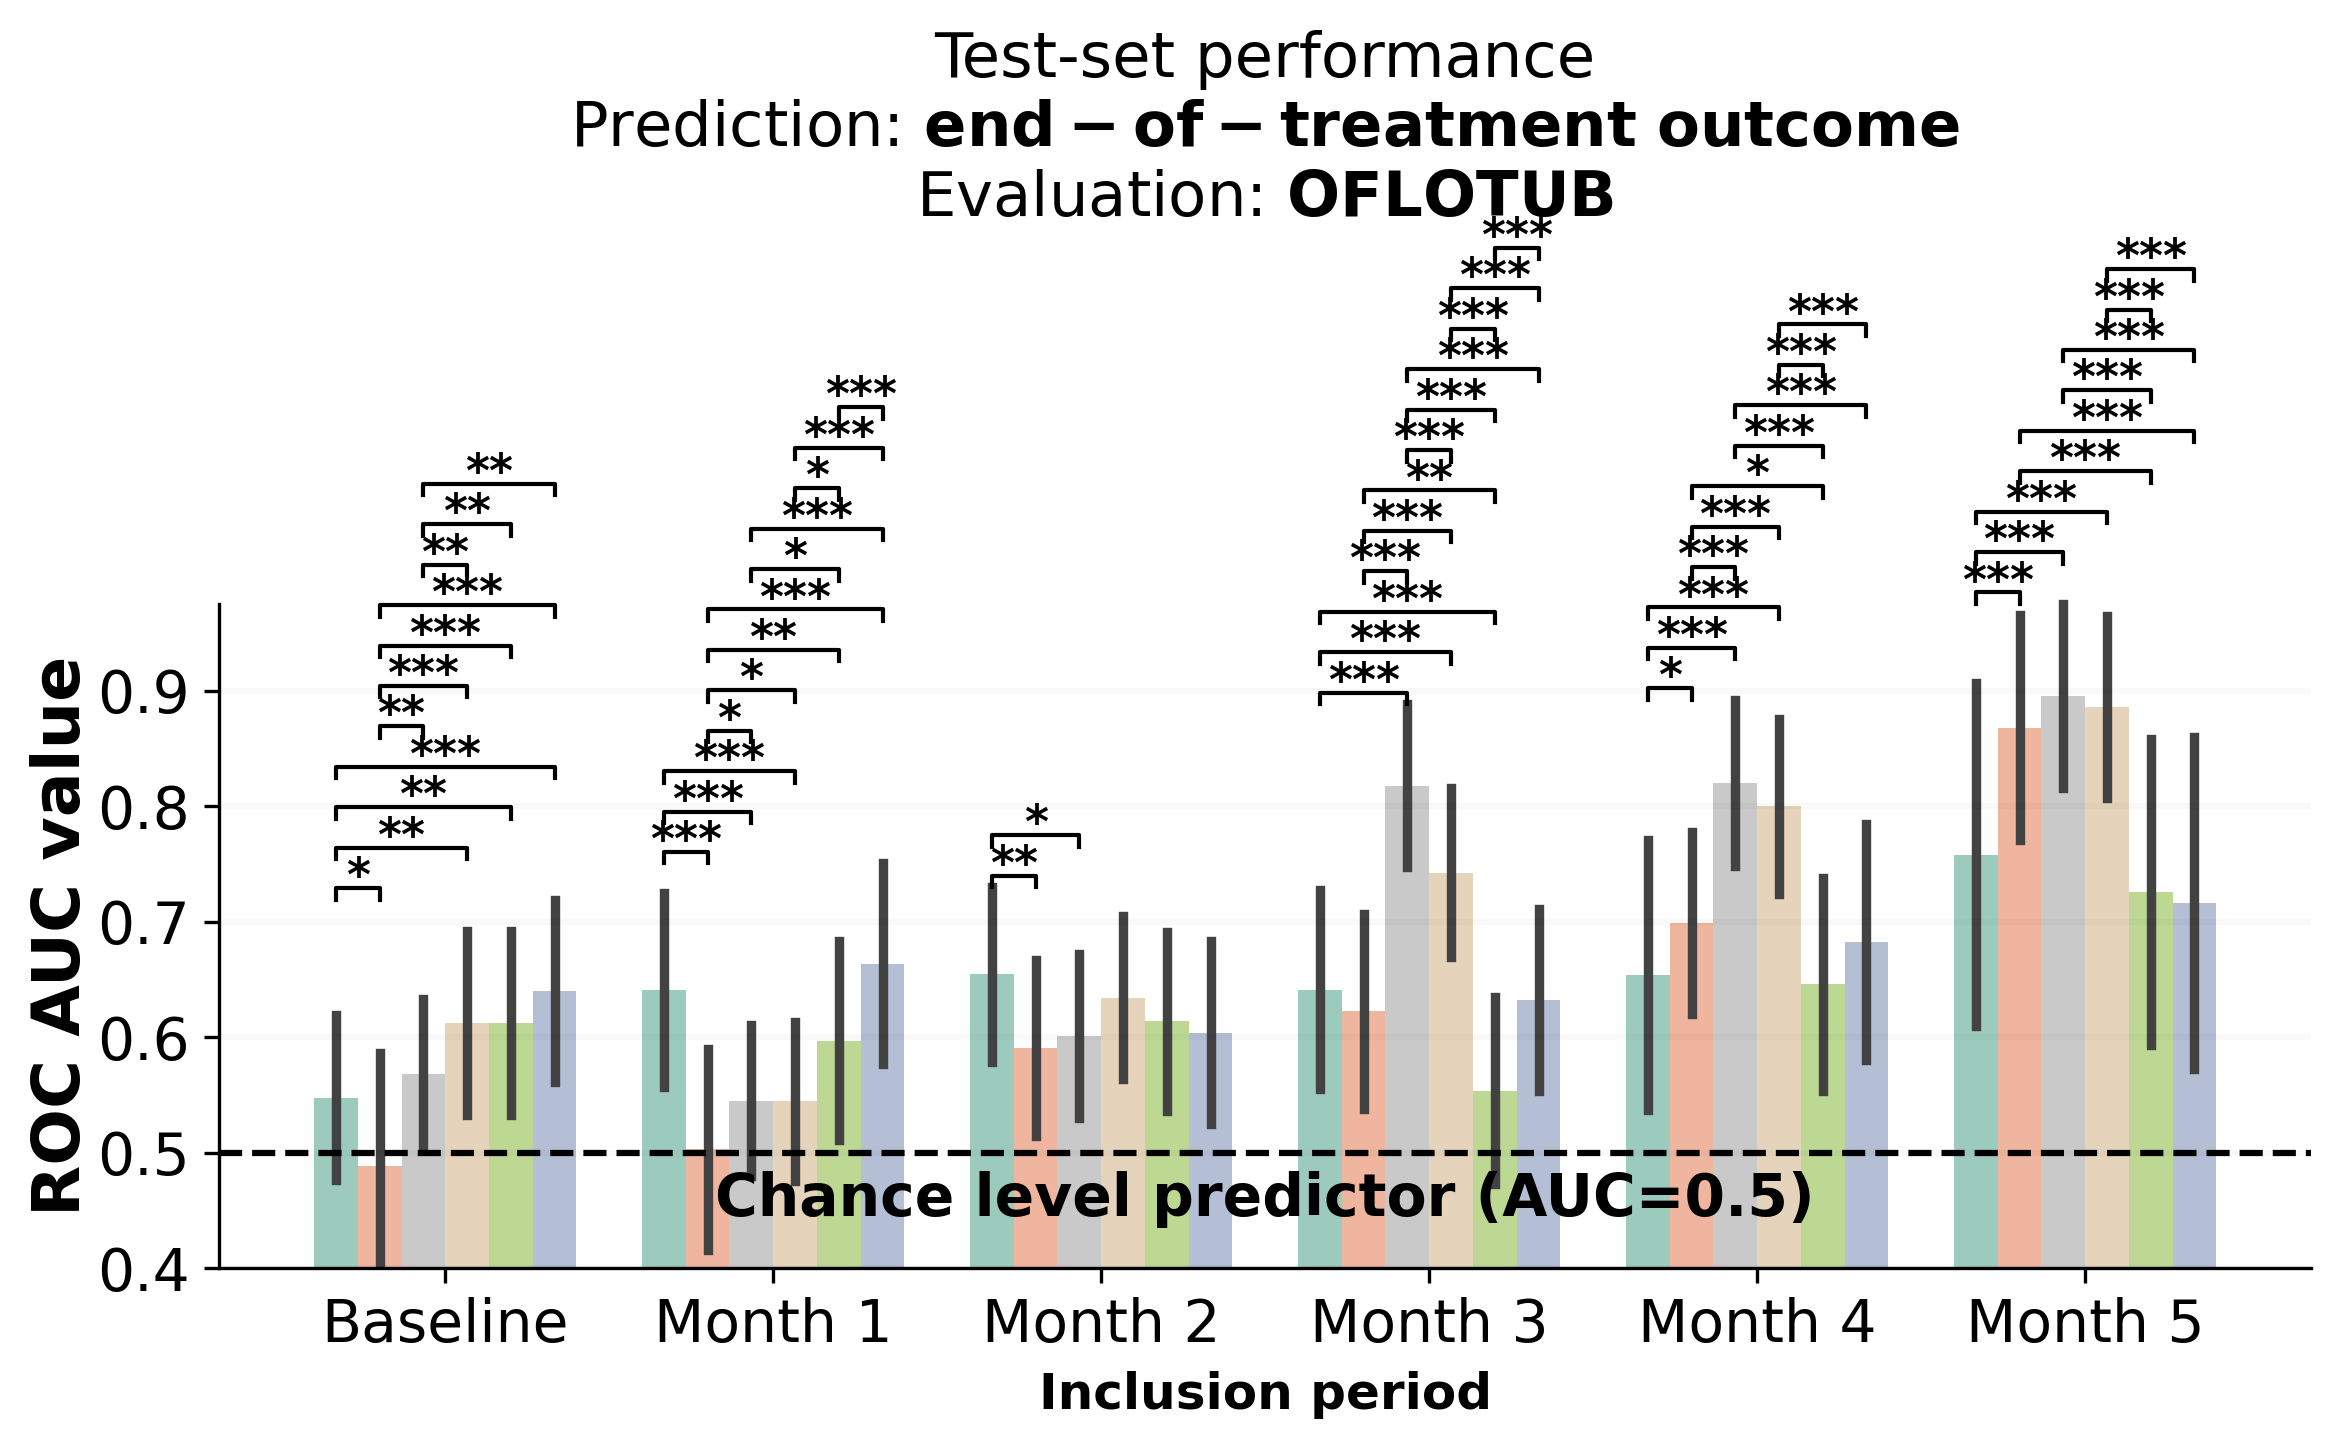

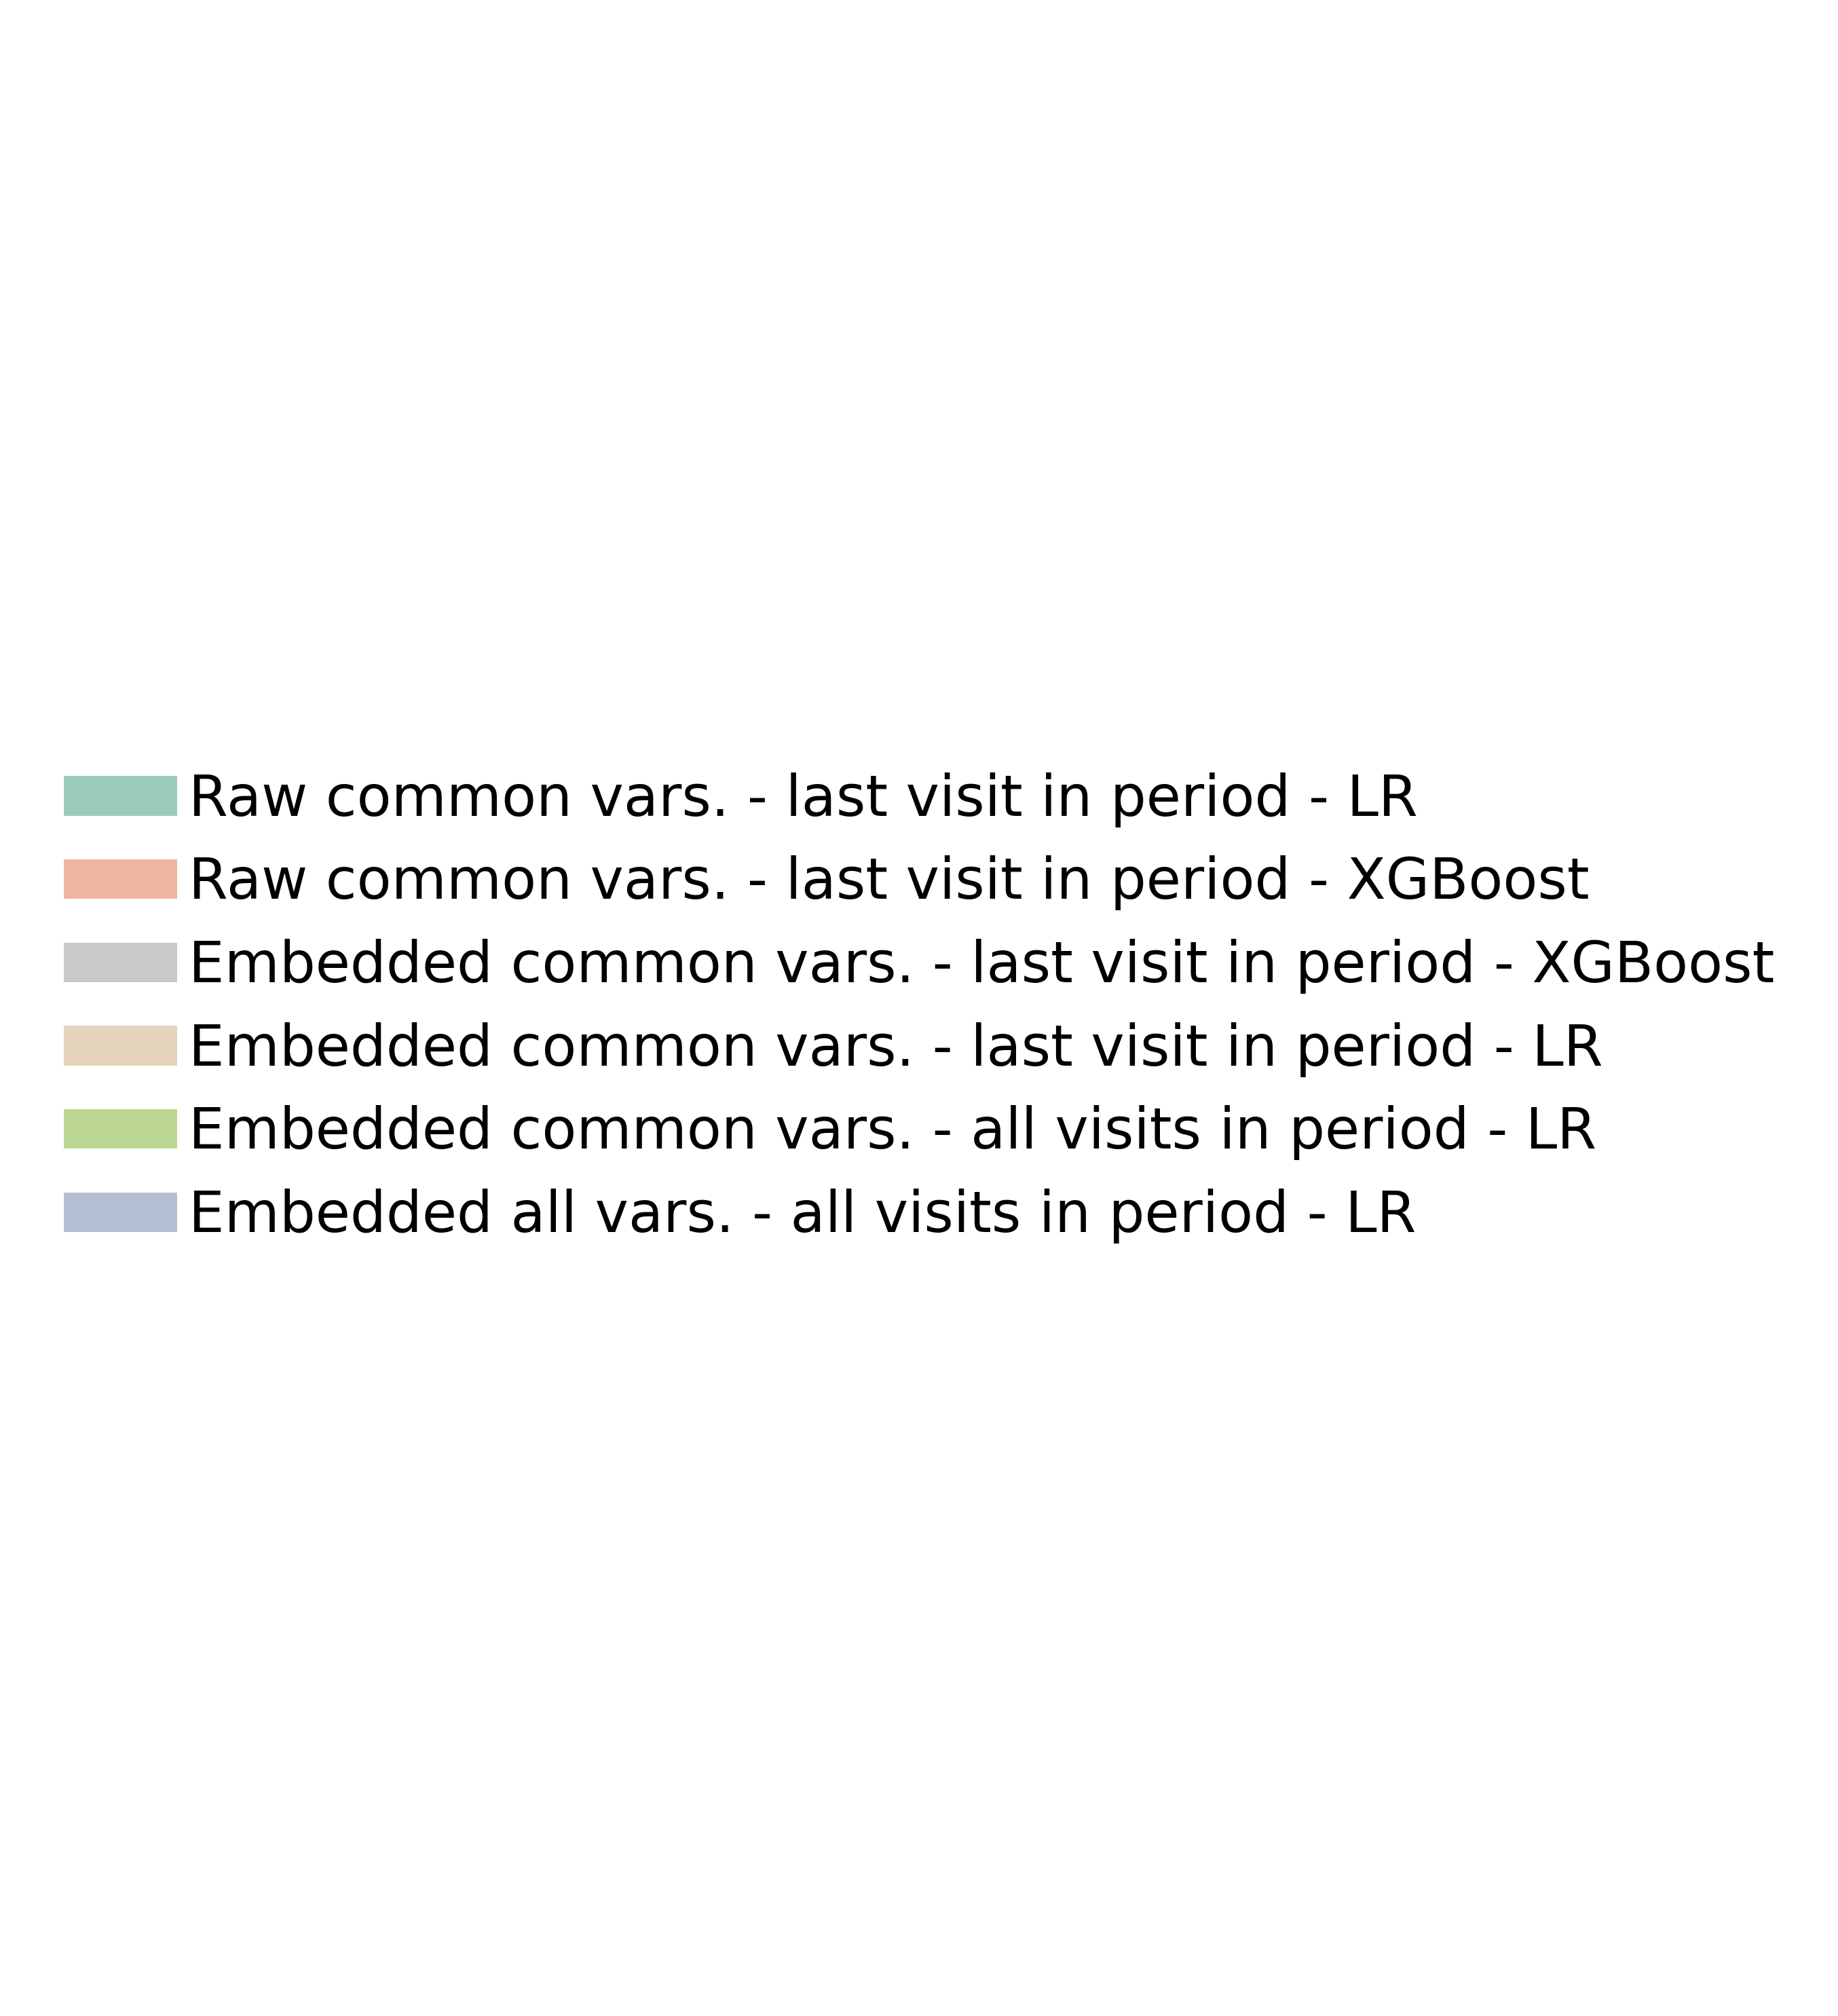

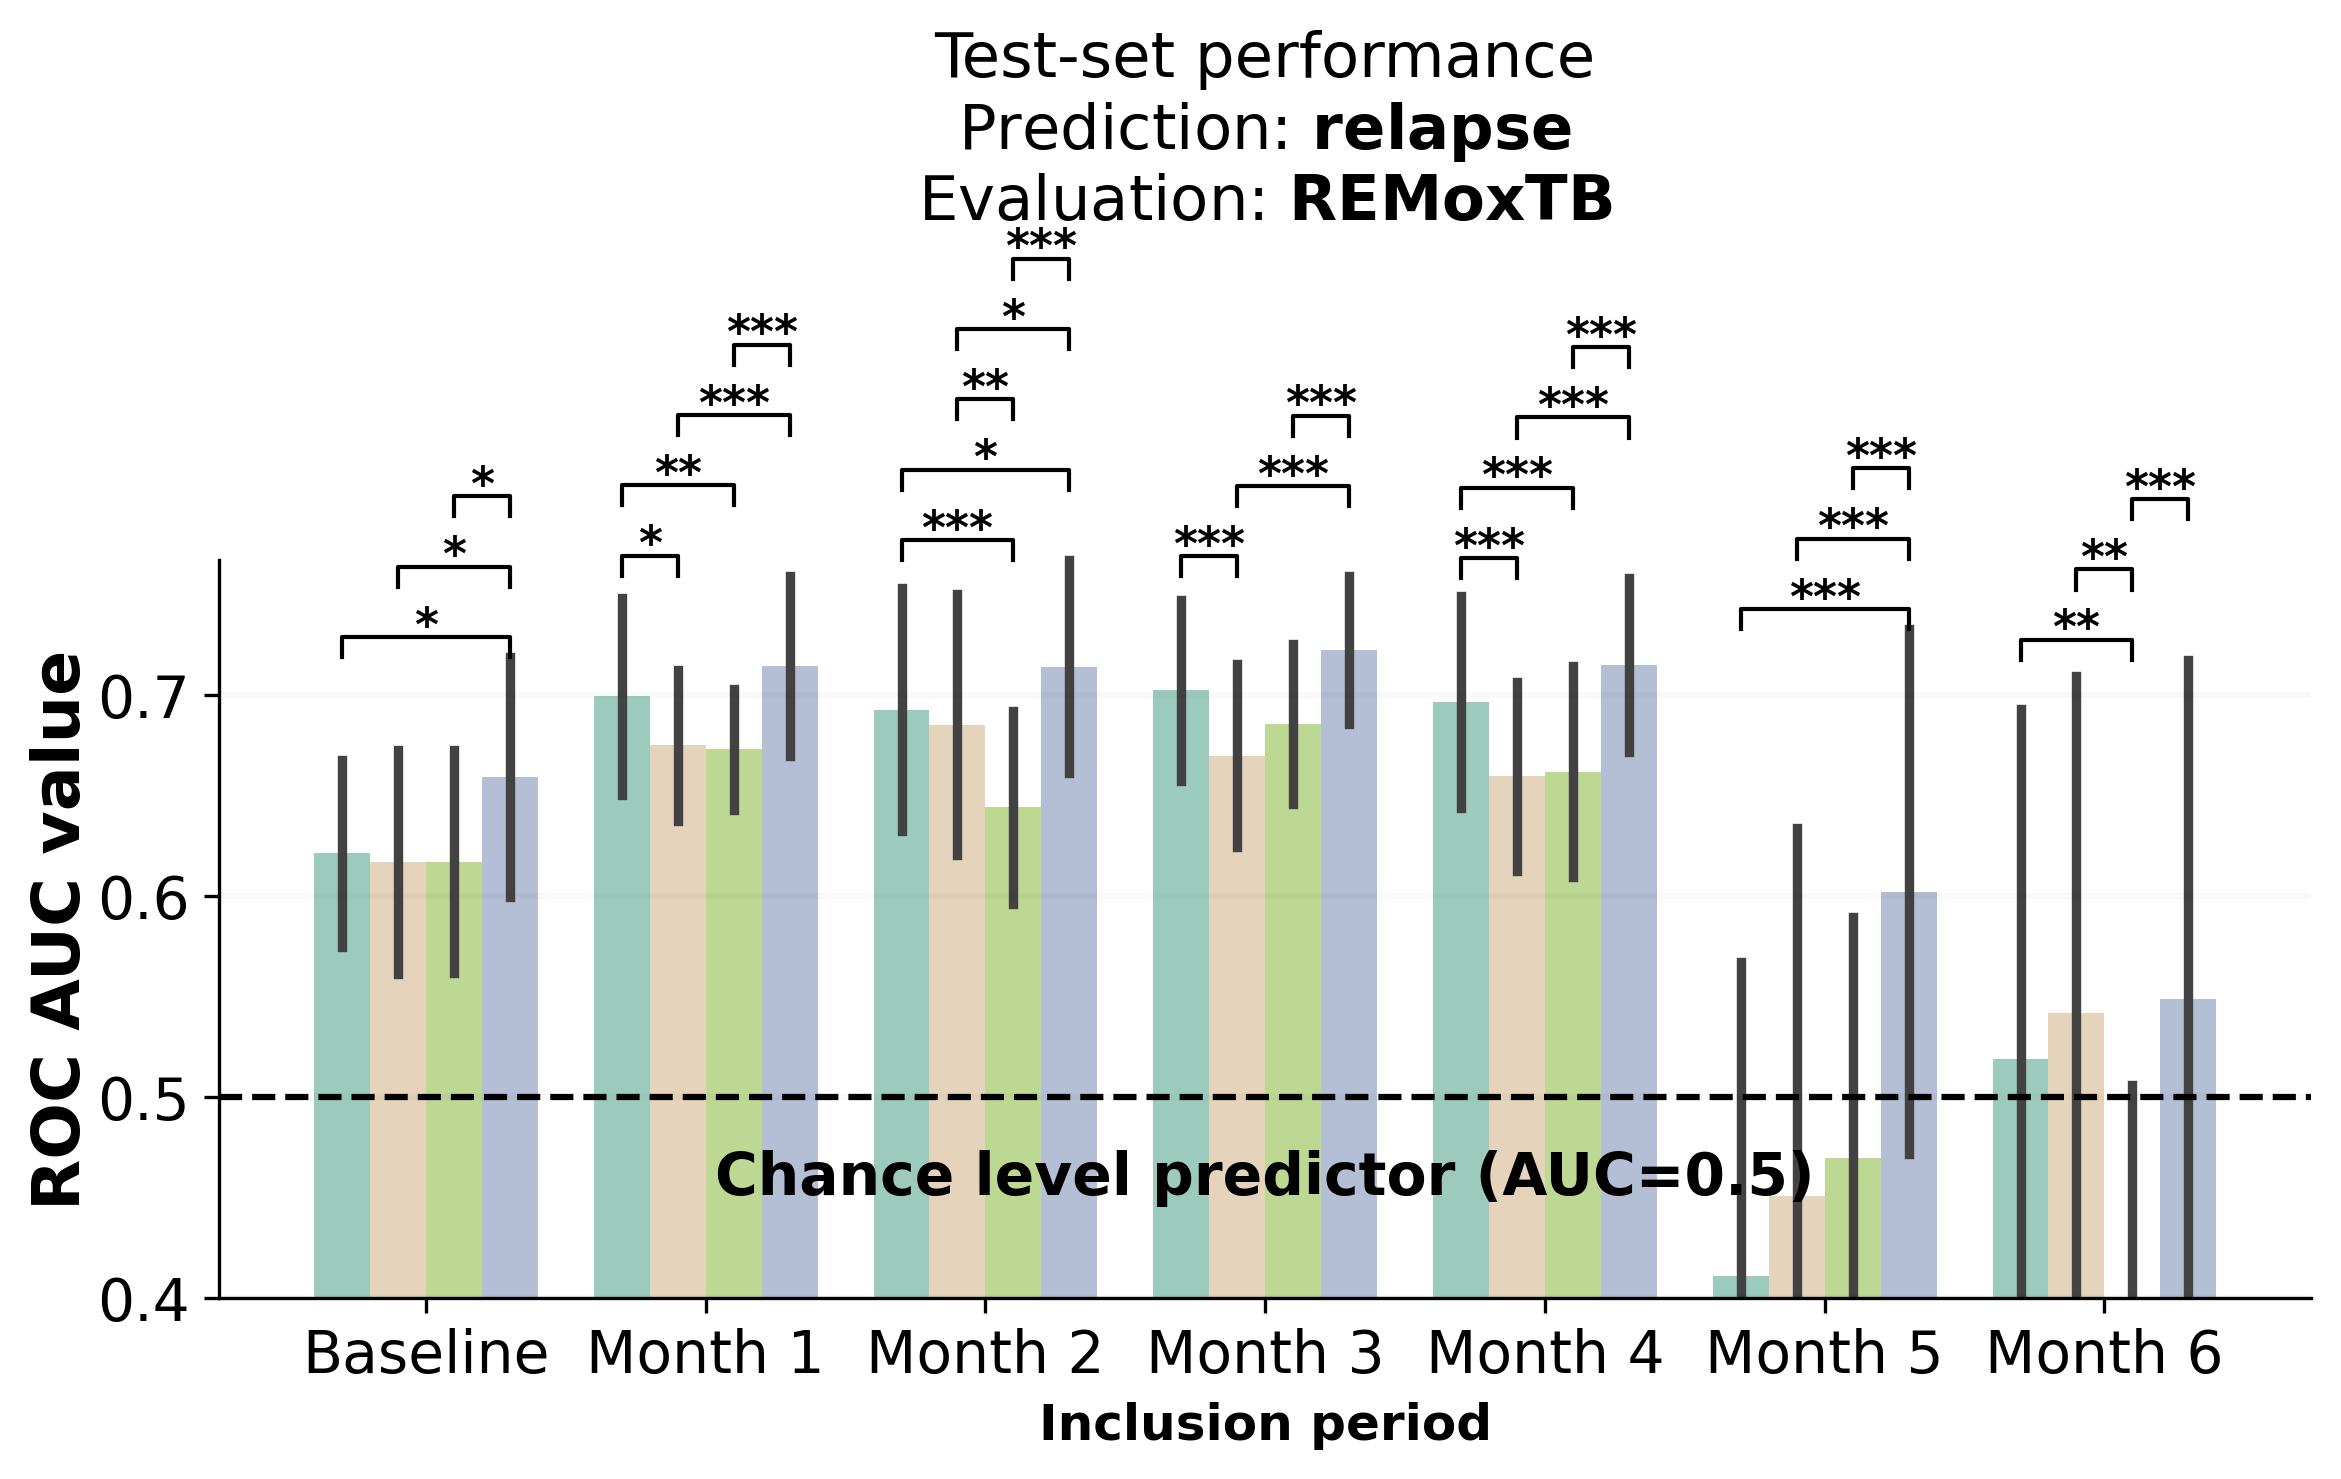

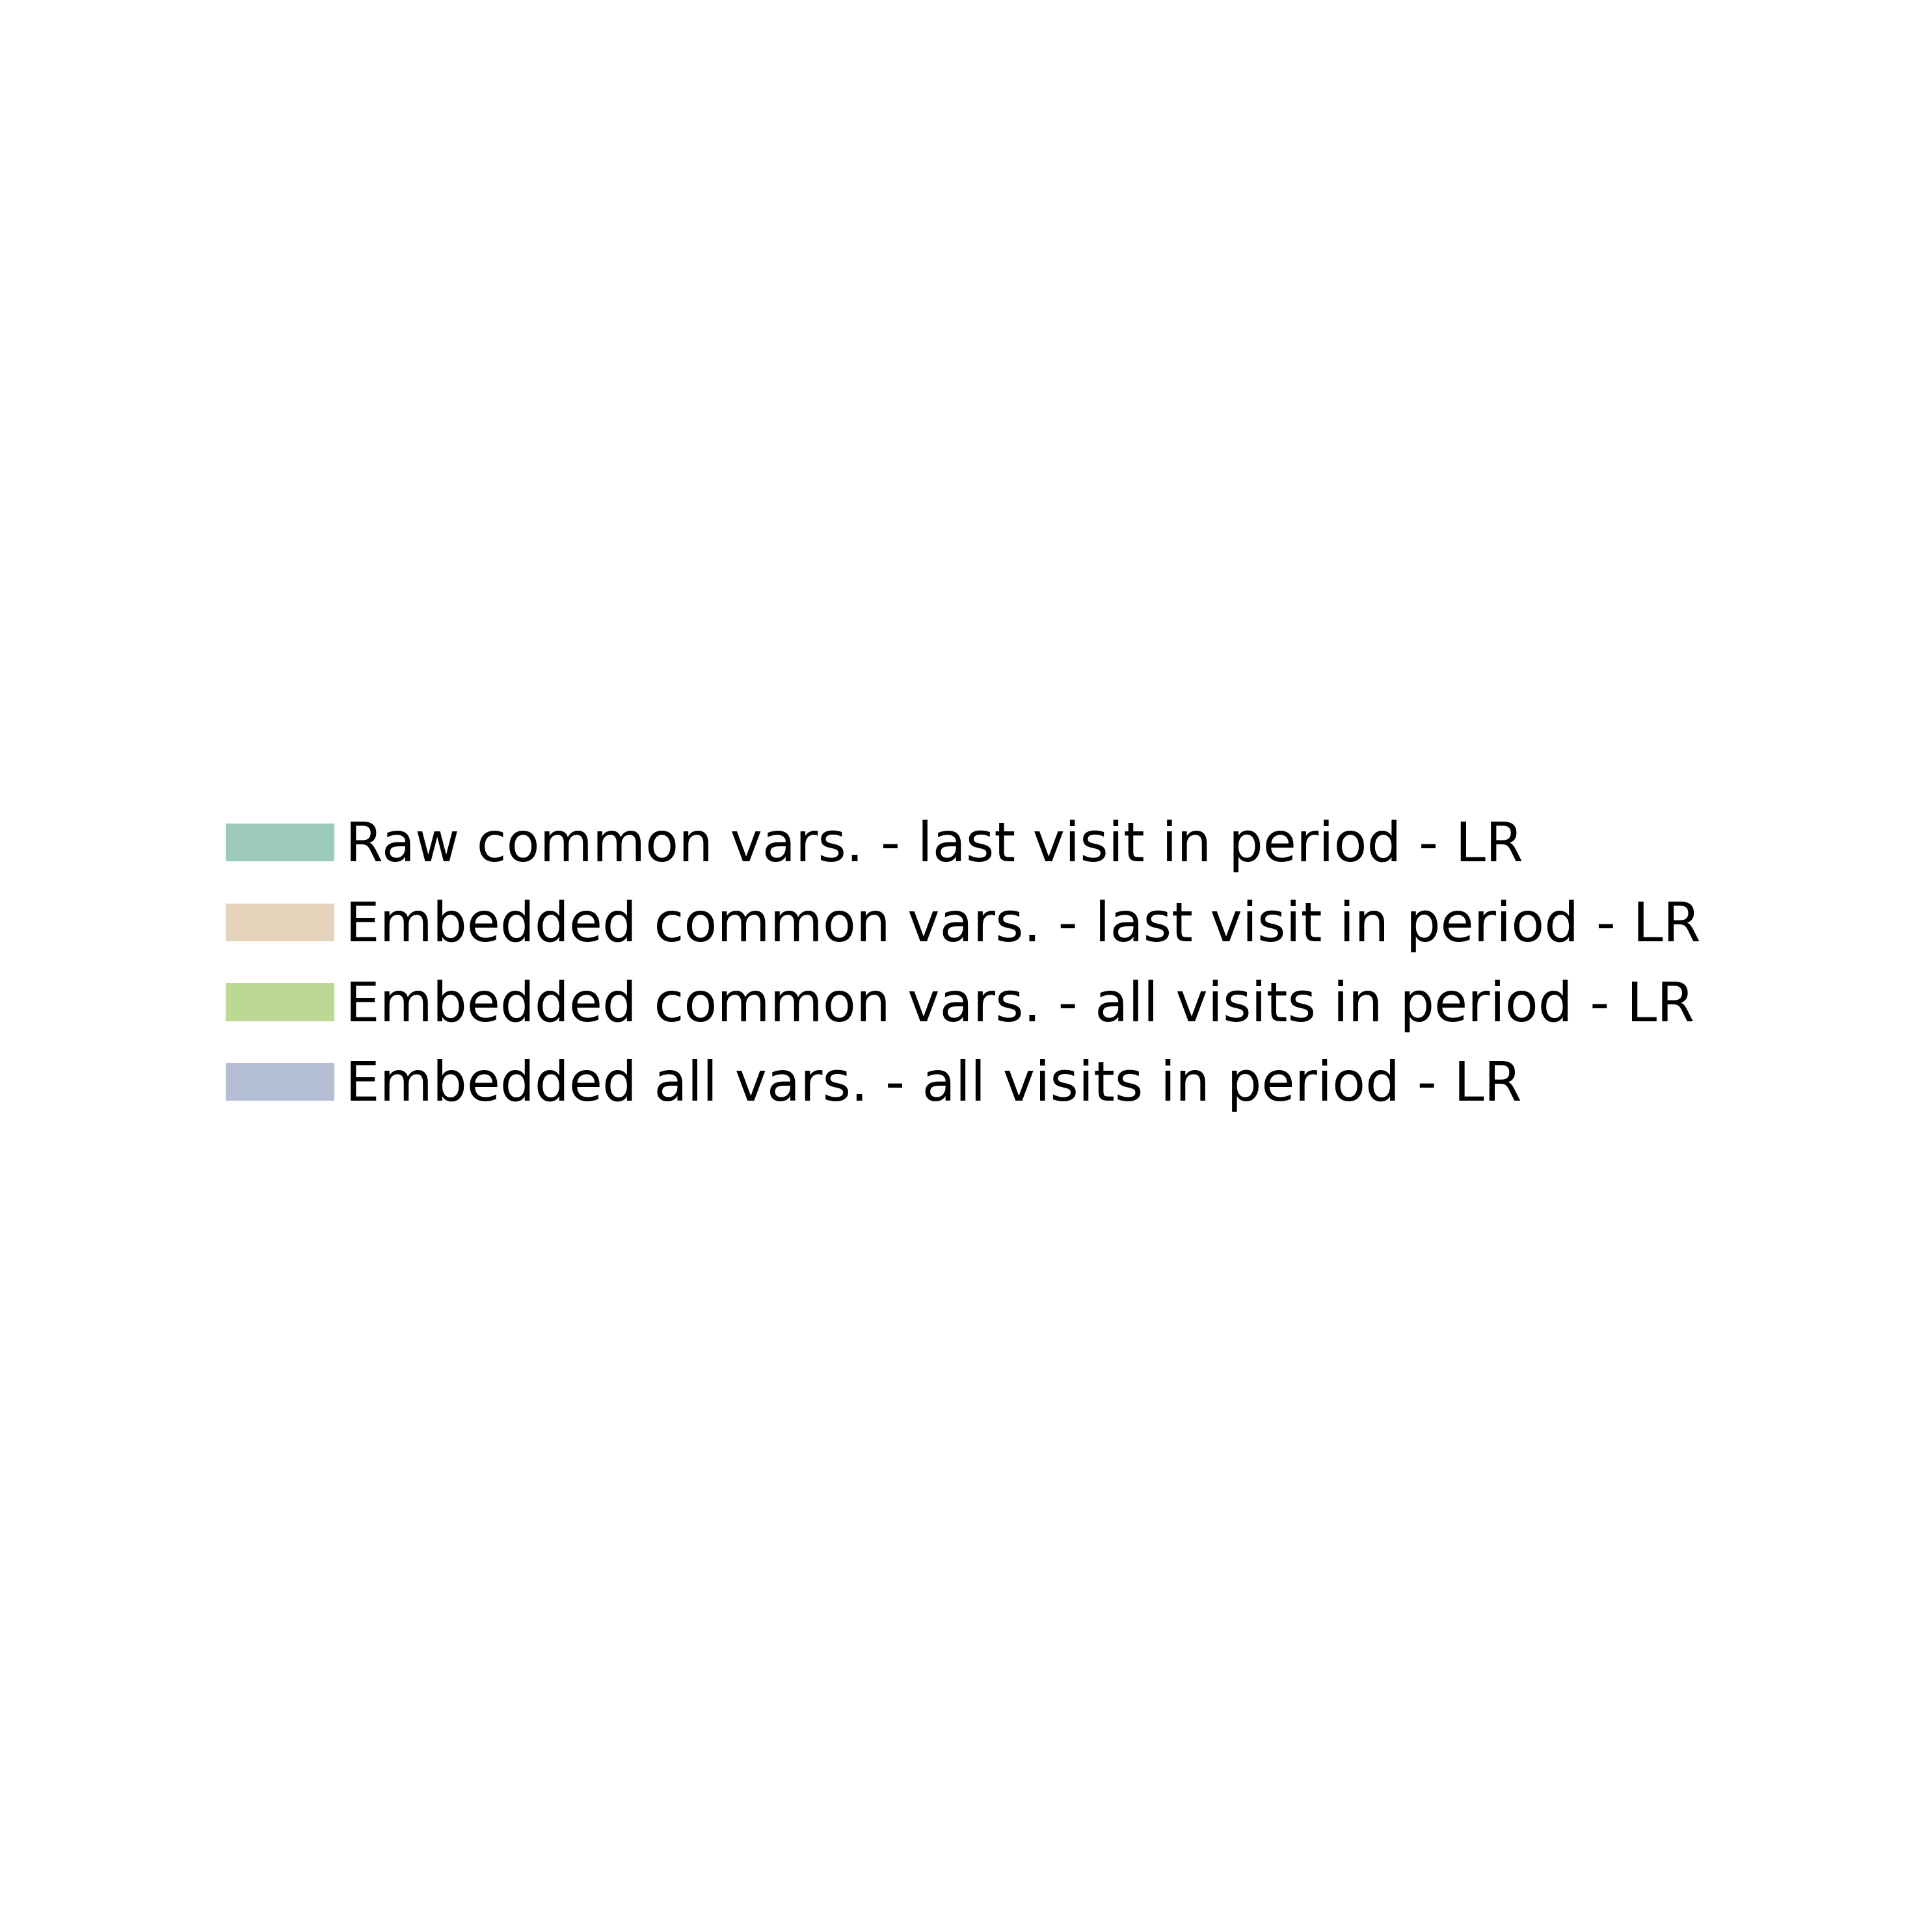

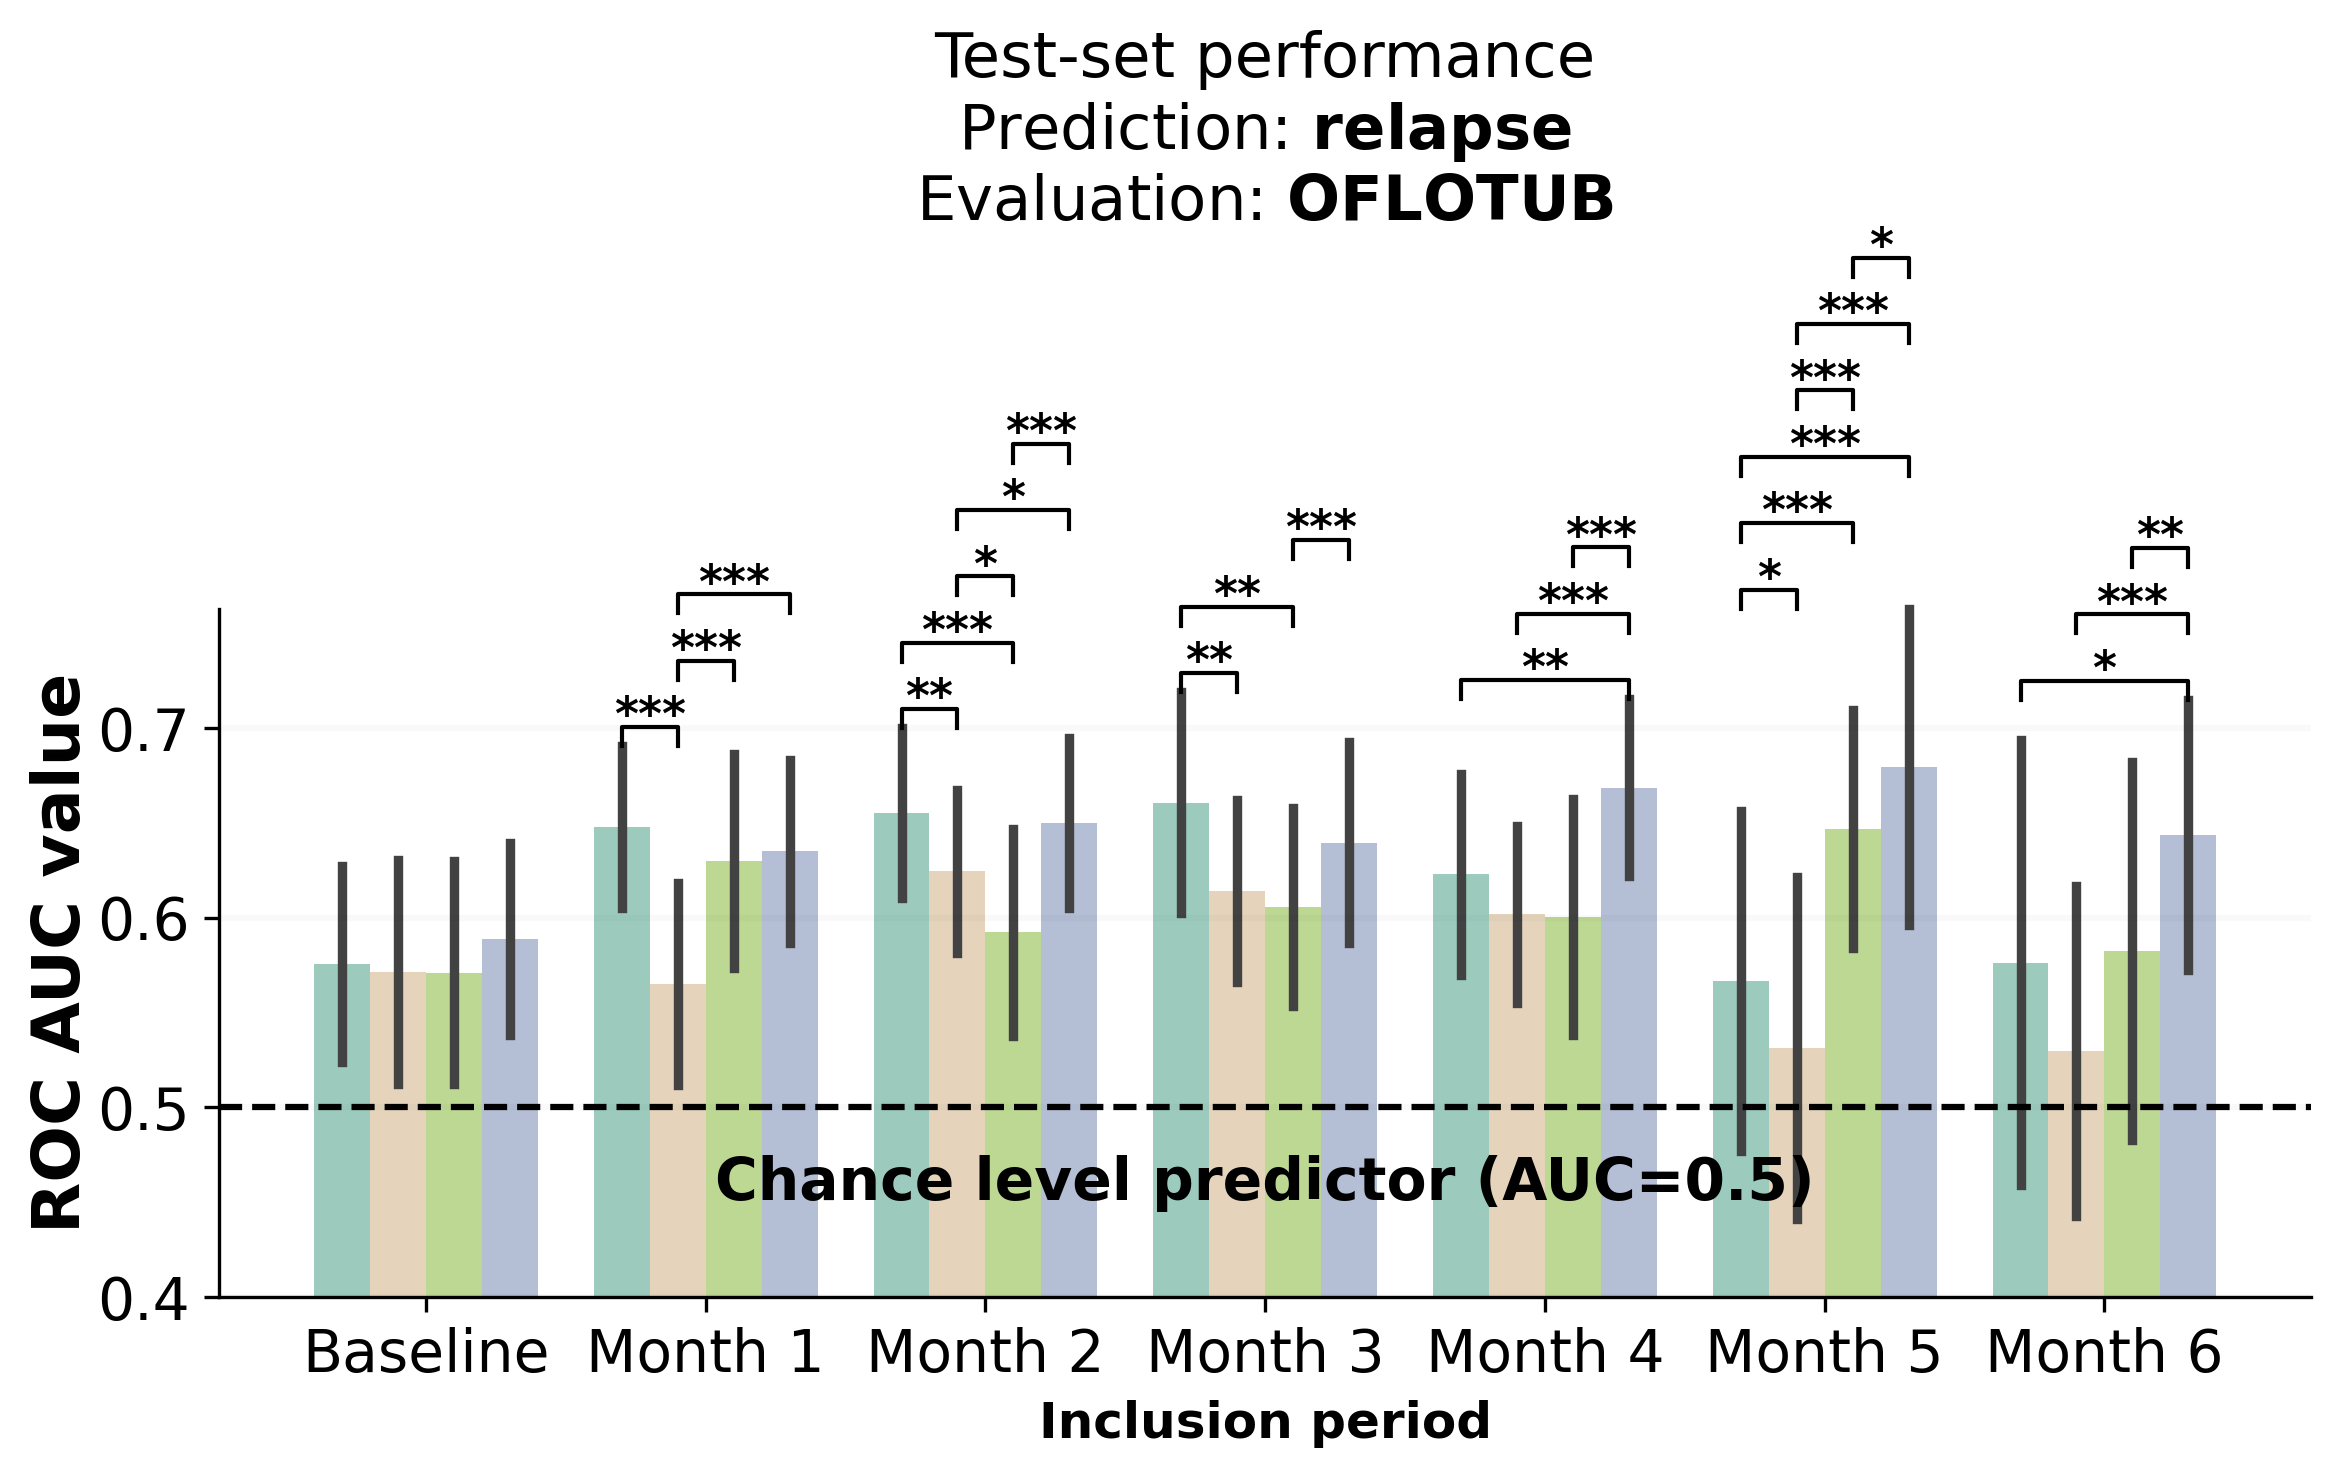

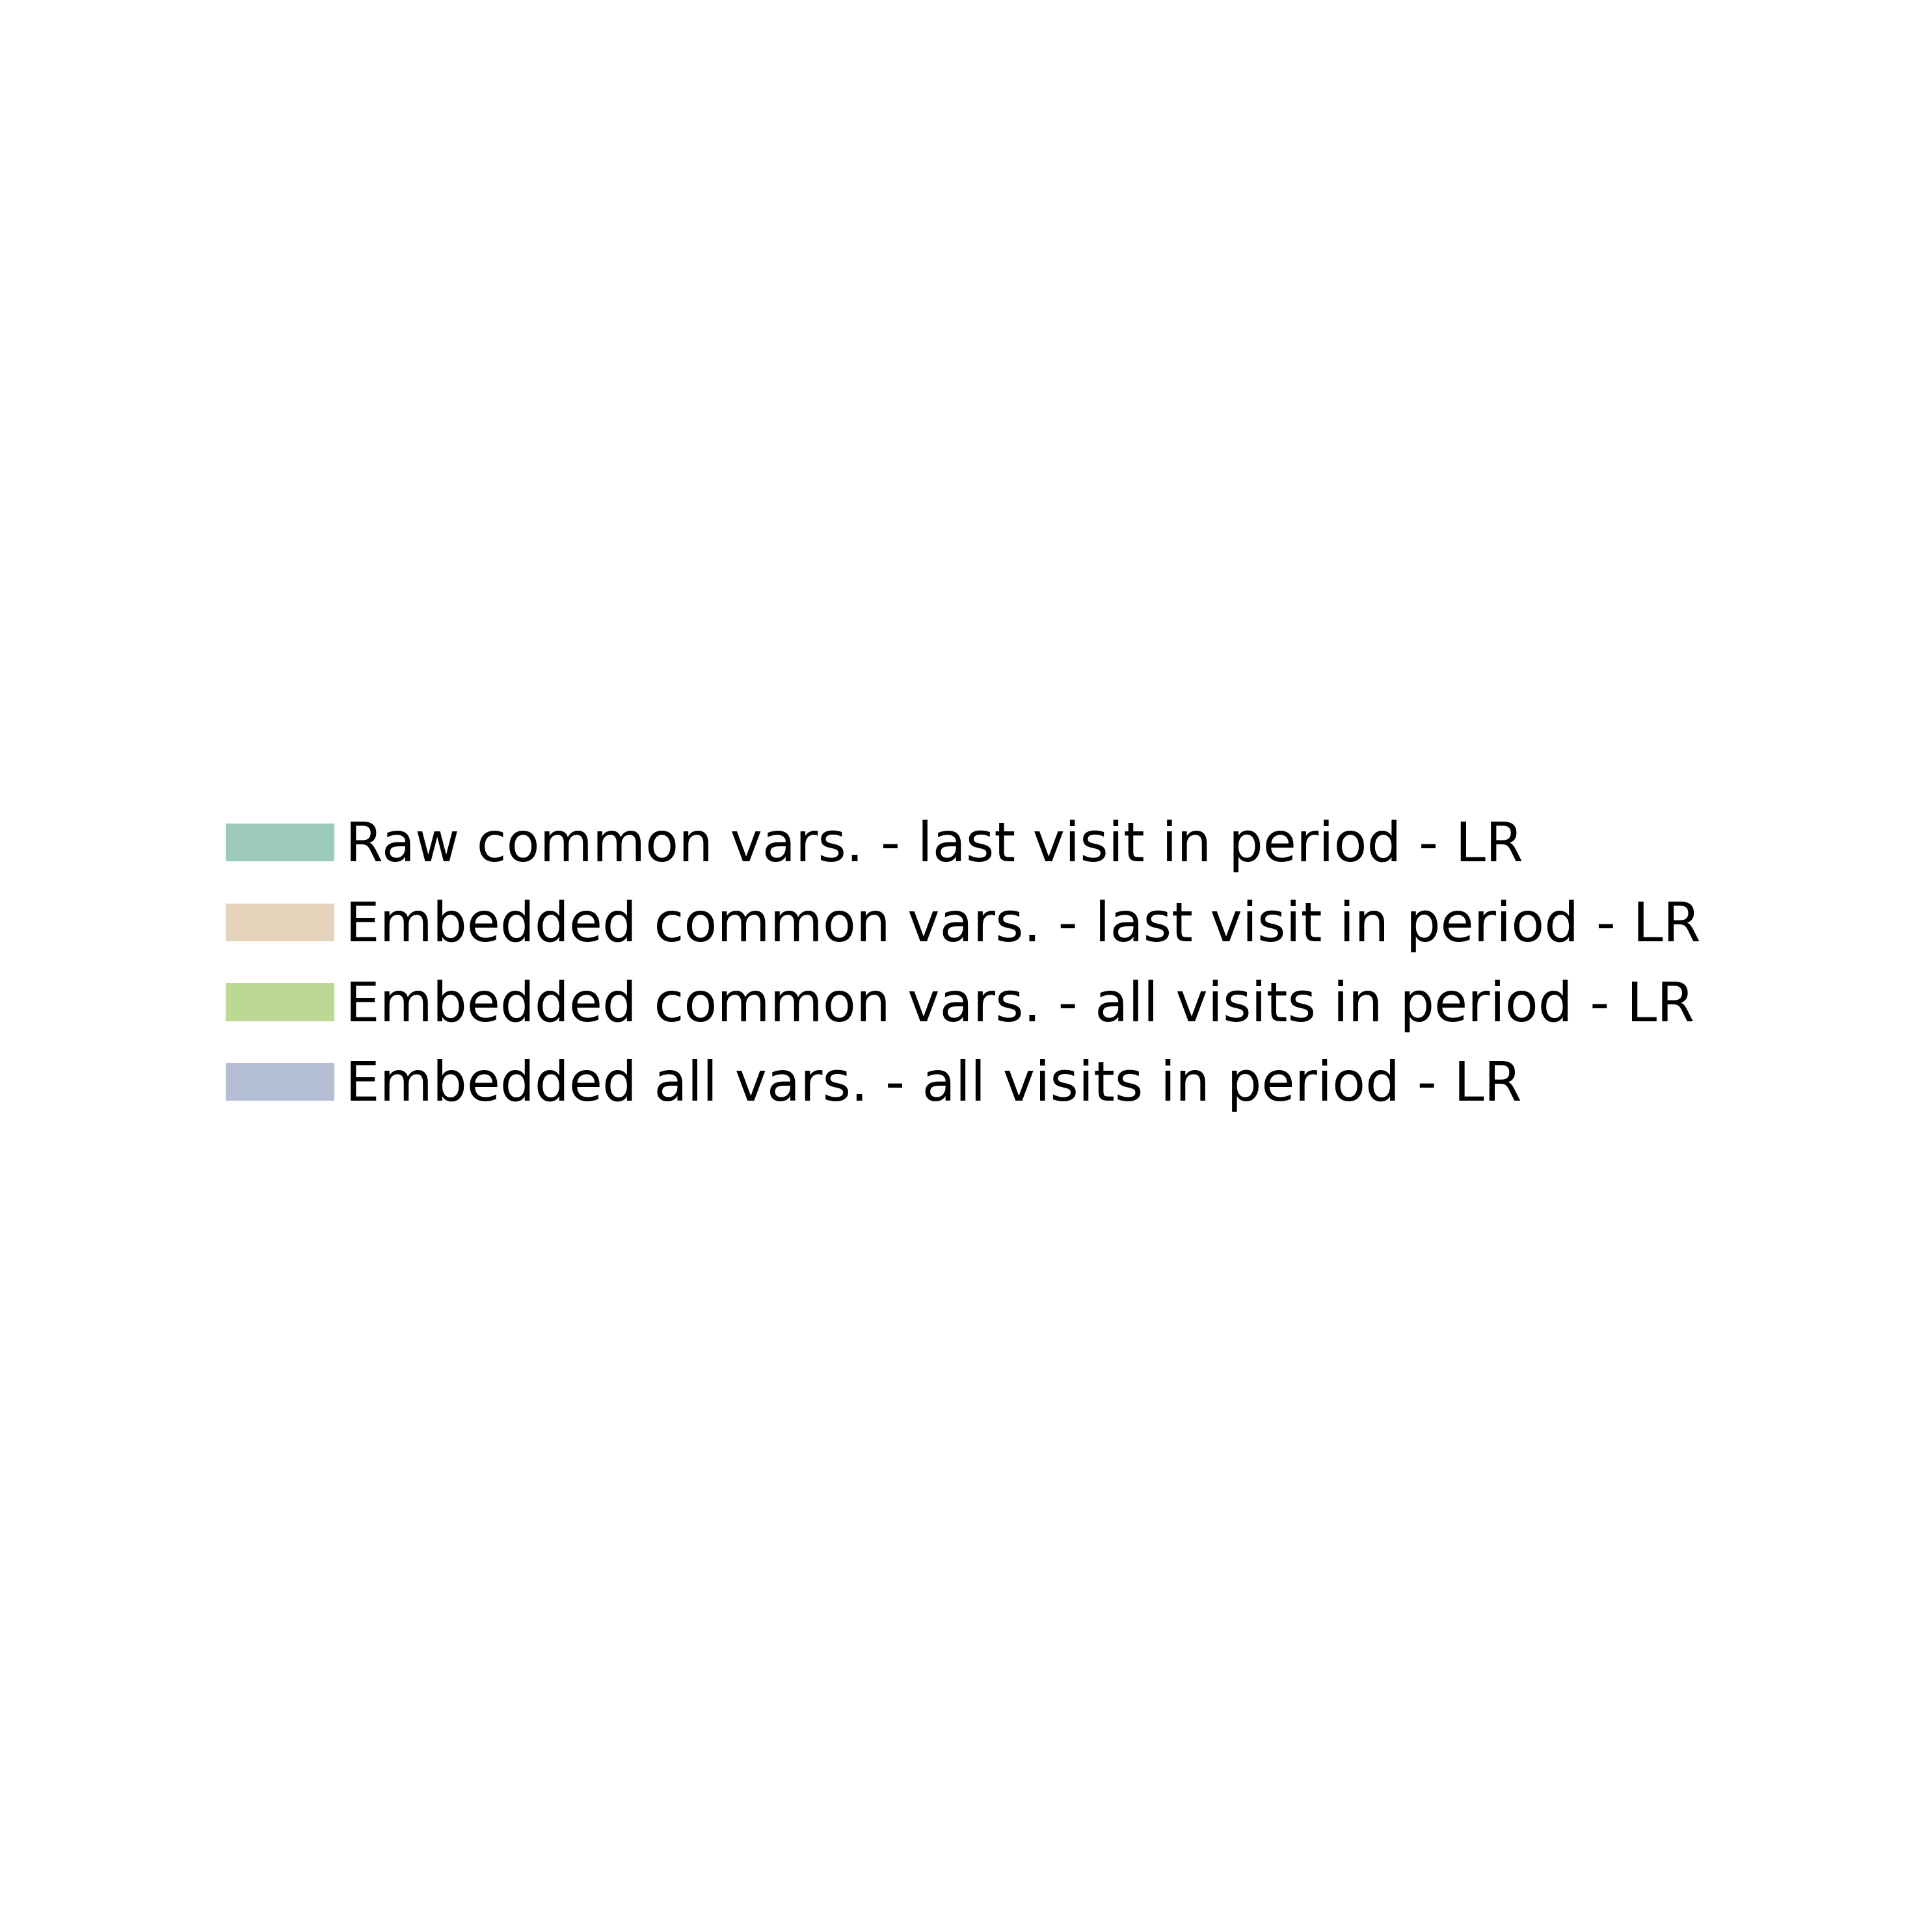

In [34]:
## PLOT ROC-AUC CURVE OF TEST SET
## PLOT ROC-AUC CURVE OF TEST SET
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import roc_auc_score
from scipy.stats import ttest_rel
from functools import reduce
from matplotlib.font_manager import FontProperties

figtitle_size=20
subtitle_size=18
x_tick_size=18
y_tick_size=13
y_label_size=14
legend_fontsize=11.5
axis_lw=1.6


period_end_days=['baseline',31,62,93,125,160,'all']
period_end_days_for_plot=period_end_days[:]

model_names=['XGBoost','LogisticRegression',]#'Dense']#,'SVC','KNN']
autoenc_merged_bool_list=[False,True]


llm_model_names=['BioMistral/BioMistral-7B',"epfl-llm/meditron-7b"]
fine_tuned_tags=['base','fine_tuned']
#model_names=['XGBoost','GradientBoost','LogisticRegression','RandomForest','SVC','KNN']
training_data_types=['full','pca']

llm_model_names=['BioMistral/BioMistral-7B',"epfl-llm/meditron-70b","epfl-llm/meditron-7b",
                 "google/long-t5-local-base",'google/long-t5-tglobal-large',
                'text-embedding-3-small']

suptitle_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMoxTB + OFLOTUB',
               'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':'REMoxTB + OFLOTUB',
               'tb21_22_2984_pats_22_vars_relapse':'REMoxTB + OFLOTUB',
              'tb21_1405_pats_40_vars_result_at_end_of_treatment':'REMoxTB',
               'tb21_1405_pats_40_vars_relapse':'REMoxTB',
              'TB-1021':'REMoxTB',
              'TB-1022':'OFLOTUB'}

plot_split_by_studies=True

baseline_training_data_types=['all_days_in_period','last_therapy_day']
llm_data_inclusion_types=['baseline_vars','baseline_last_day','all_days'][:]


## COMPARISON_1: baseline model setups, that will be compared to all setups in comparison_2
#comparison_1=['baseline_last_therapy_day', 'baseline_all_days_in_period'][:1]
#comparison_2 =['LLM_embed_baseline_last_day','LLM_embed_baseline_vars','LLM_embed_all_days'][:]
comparison_1=['baseline_last_therapy_day', 'LLM_embed_baseline_last_day','LLM_embed_baseline_vars','LLM_embed_all_days'][:]
comparison_2=['baseline_last_therapy_day', 'LLM_embed_baseline_last_day','LLM_embed_baseline_vars','LLM_embed_all_days'][:]

## Order of the different setups within an inclusion period
hue_order=['baseline_all_days_in_period','baseline_last_therapy_day'][1:] + \
           ['LLM_embed_baseline_last_day','LLM_embed_baseline_vars','LLM_embed_all_days'][:]

#hue_order=comparison_1 + comparison_2[:]


## SELECT THE FINAL SETUPS FOR COMPARISON, PER EACH MODEL/INCLUSION PERIOD/INPUT VARIABLE
period_end_days=['baseline',31,62,93,125,160,'all']

final_setup_dict={[*parameters_for_analysis][0]:
                      {'XGBoost':{'include_in_anal':True,
                             'incl_periods':[str(day) for day in period_end_days],
                             'trained_on':['raw_vars','embeddings'][:],
                                 'setups':['baseline_last_therapy_day','LLM_embed_baseline_last_day',
                                                'LLM_embed_baseline_vars','LLM_embed_all_days'][:2]},
        
                      'LogisticRegression':{'include_in_anal':True,
                                      'incl_periods':[str(day) for day in period_end_days],
                                      'trained_on':['raw_vars','embeddings'][:],
                                      'setups':['baseline_last_therapy_day','LLM_embed_all_days',
                                                'LLM_embed_baseline_last_day',
                                                'LLM_embed_baseline_vars',][:]}},

                  
                  [*parameters_for_analysis][1]:
                        {'XGBoost':{'include_in_anal':False,
                             'incl_periods':[str(day) for day in period_end_days],
                             'trained_on':['raw_vars','embeddings'][:1],
                            'setups':['baseline_last_therapy_day','LLM_embed_baseline_last_day',
                                                'LLM_embed_baseline_vars','LLM_embed_all_days'][:]},
                         
                          'LogisticRegression':{'include_in_anal':True,
                                      'incl_periods':[str(day) for day in period_end_days],
                                      'trained_on':['raw_vars','embeddings'][:],
                                      'setups':['baseline_last_therapy_day','LLM_embed_baseline_last_day',
                                                'LLM_embed_baseline_vars','LLM_embed_all_days'][:]}}}

## TO MAKE A COMPARISON ACROSS MODELS POSSIBLE, ADD THE MODEL NAME IN FRONT OF THE HUE AND COMPARISON SETUP NAMES
#hue_order=[f'{mod_name} - {hue}' for mod_name in model_names for hue in hue_order]
hue_order=[f'{hue} - {mod_name}' for mod_name in model_names for hue in hue_order]

## Use underscore in the comparisons, as the model name will be split from the setup name before the t-test calculation, 
#. and used for subsetting the dataframe holding the t-test p-values for all comparisons performed. 
#. See in the function "calc_paired_t_test_between_exp_setups()", also there underscore is used, as a '-' character is already being used at other part of the setup strings.
#. After the t-test, the '_' will be replaced by ' - ' where needed, to match with the hue_order setup names.
#comparison_1=[f'{mod_name}_{comp}' for mod_name in model_names for comp in comparison_1]
#comparison_2=[f'{mod_name}_{comp}' for mod_name in model_names for comp in comparison_2]
comparison_1=[f'{comp}_{mod_name}' for mod_name in model_names for comp in comparison_1]
comparison_2=[f'{comp}_{mod_name}' for mod_name in model_names for comp in comparison_2]



for data_param_key in [*parameters_for_analysis][:2]:

    for plot_type in ['bar','point'][:1]:

        pred_models_result=[]
        #hue_order=[]
    
        ## LOAD BASLINE MODEL
        for bl_training_data_type in baseline_training_data_types[1:]:
            
            fn=f'../data/test_roc_auc_values/baseline/{data_param_key}_days_{bl_training_data_type}_test_ROC_AUC_across_time_all_studies.csv'
            fn=f'../data/test_roc_auc_values/baseline/{data_param_key}_days_{bl_training_data_type}_test_ROC_AUC_across_time_per_study..csv'
            baseline_cv_res_acros_time_df=pd.read_csv(fn,index_col=0)
            baseline_cv_res_acros_time_df['trained_on']='raw_vars'
            baseline_cv_res_acros_time_df['setup']=f'baseline_{bl_training_data_type}'
            pred_models_result.append(baseline_cv_res_acros_time_df)
            #hue_order.append(f'baseline_{bl_training_data_type}')

            for llm_model_name in llm_model_names[:1]:
        
                for fine_tuned_tag in fine_tuned_tags[:1]:
                    
                    
                    if 'text-embedding' in llm_model_name:
                        llm_model_name_with_tag=llm_model_name
                    else:
                        llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])
                    
        
                    for data_inclusion_type in llm_data_inclusion_types[:]:
        
                        for training_data_type in training_data_types[:1]:

                            for autoencoder_merged in autoenc_merged_bool_list[:1]:

                                fn=f'../data/test_roc_auc_values/LLM/{data_param_key}_{llm_model_name_with_tag}_{training_data_type}_4096_{data_inclusion_type}_autoenc_{autoencoder_merged}_test_ROC_AUC_across_time_all_studies.csv'                                                    
                                fn=f'../data/test_roc_auc_values/LLM/{data_param_key}_{llm_model_name_with_tag}_{training_data_type}_4096_{data_inclusion_type}_autoenc_{autoencoder_merged}_test_ROC_AUC_across_time_per_study.csv'                                                    
                                llm_cv_res_acros_time_df=pd.read_csv(fn,index_col=0)
                                llm_cv_res_acros_time_df['trained_on']='embeddings'
                                llm_cv_res_acros_time_df['setup']=f'LLM_embed_{data_inclusion_type}'
                                pred_models_result.append(llm_cv_res_acros_time_df)
                                
        #hue_order=comparison_1
        plot_df = pd.concat(pred_models_result,axis=0)



        # Refine names of the setups
        replacements = {
            '_embed_baseline_vars': ' Common vars - all visits in period',
            '_embed_baseline_last_day': ' Common vars - last visit in period',
            'baseline_last_therapy_day': 'Common vars - last visit in period',
            'baseline_all_days_in_period': 'Common vars - last visits concatenated',
            '_embed_all_days':' All vars - all visits in period'}
        
        #sns.barplot(data=plot_df,x='inclusion_period',y='ROC_AUC_score',hue='setup')
        plot_df['setup__']=plot_df['setup'].values
        plot_df['setup']=plot_df['setup'].replace(replacements,regex=True)
        plot_df['setup_']=plot_df['setup'] +' - '+ plot_df['model_name']

        ### CREATE CUSTOM PALETTE FOR SETUPS
        setups=np.sort(plot_df['setup_'].unique())
        setup_colors = plt.cm.get_cmap('Set2', len(setups))  # Use a colormap with enough distinct colors
        setup_color_mapping = {setup: setup_colors(i) for i, setup in enumerate(setups)}

        
        ## FILTER SETUPS BASED ON THE final_setup_dict, WHICH DETERMINES WHICH SETUPS ARE USED FOR FINAL COMPARISON
        l=[]

        for model_name in [*final_setup_dict[data_param_key]]:

            if final_setup_dict[data_param_key][model_name]['include_in_anal']==True:
            
                incl_periods_=final_setup_dict[data_param_key][model_name]['incl_periods']
                trained_on=final_setup_dict[data_param_key][model_name]['trained_on']
                setups=final_setup_dict[data_param_key][model_name]['setups']
                
                plot_df_filt = plot_df.loc[(plot_df['model_name']==model_name)\
                                            &(plot_df['trained_on'].isin(trained_on))\
                                            &(plot_df['inclusion_period'].isin(incl_periods_))\
                                            &(plot_df['setup__'].isin(setups))]
                #print(plot_df_filt)
                l.append(plot_df_filt)
        
        plot_df = pd.concat(l,axis=0)

     
        
        # Update hur_order list with refined setup names
        hue_order_=replace_substring_in_list(replacements,hue_order)
        comparison_1_=replace_substring_in_list(replacements,comparison_1)
        comparison_2_=replace_substring_in_list(replacements,comparison_2)

        ## FILTER HUE AND COMPARISONS ORDER BASED ON THE SETUPS IN PLOT_DF
        hue_order_ = [hue for hue in hue_order_ if hue in plot_df['setup_'].unique()]
        comparison_1_ = [comp for comp in comparison_1_ if comp.replace('_',' - ') in plot_df['setup_'].unique()]
        comparison_2_ = [comp for comp in comparison_2_ if comp.replace('_',' - ') in plot_df['setup_'].unique()]

        hue_order_ = list(np.sort([x for x in hue_order_ if x.startswith('Common vars')])) + \
                             [x for x in hue_order_ if not x.startswith('Common vars')]
        comparison_1_ = list(np.sort([x for x in comparison_1_ if x.startswith('Common vars')])) + \
                                     [x for x in comparison_1_ if not x.startswith('Common vars')]
        comparison_2_ = list(np.sort([x for x in comparison_2_ if x.startswith('Common vars')])) + \
                                     [x for x in comparison_2_ if not x.startswith('Common vars')]
        
        
        ## Change names of inlcusion periods to months
        period_dict=dict(zip([str(x) for x in period_end_days],
                             #[f'{int(np.floor(int(day)/30))} month' if day !='all' else '6 month' for day in period_end_days]
                            
                             ['Month 6' if day == 'all' 
                                        else 'Baseline' if day == 'baseline' 
                                        else f'Month {int(np.floor(int(day)/30))}' if isinstance(day, int) 
                                        else None 
                                        for day in period_end_days_for_plot]
                                             ))
        plot_df['inclusion_period']=plot_df['inclusion_period'].map(period_dict)

        ## Within each model type & inclusion period, calculate the paired t-test results across experimental setups. 
        #. The results coming from the same CV-splits are compared across exp. setups, these are paired for the t-test
        #. The dict. holds all the raw p-values of the t-tests across all exp. setups
        #paired_t_res_dict = calc_paired_t_test_between_exp_setups(plot_df)
        #extract_paired_t_test_FDR(ttest_res_df,comparison_1,comparison_2)

        # Figure size customization


        
        # LOOP OVER THE STUDIES AND PLOT THE ROC-AUC CURVES WITHIN STUDY
        for split_coln in ['STUDYID','ARM'][:1]:
            plot_df_ = plot_df[plot_df['split_coln']==split_coln]

            plot_df_['split_coln_level']=plot_df_['split_coln_level'].replace({'Gati-arm regimen (4 month regimen)':'Gatifloxacin (4 month)',
                                                                 'Control-arm regimen (6 month regimen)':'Control (6 month)'},regex=False)
     
     

            for split_coln_level in plot_df_['split_coln_level'].unique():
                
                plot_df_study=plot_df_[plot_df_['split_coln_level']==split_coln_level]
                
                ## Sort by inclusion periods
                #plot_df=roc_auc_concat_df[roc_auc_concat_df['setup']==setup]
                custom_order = ['baseline', 31, 62, 93, 125, 160, 'all']
        
                
                if plot_df_study.shape[0]>0:
            
                    paired_t_res_dict = calc_paired_t_test_between_exp_setups(plot_df_study)
                    
                    fig,ax=plt.subplots(1,1,figsize=(9,4.5))
                    
                    ## IF not all periods were considered, shorten the ordered list of periods
                    num_of_periods_ = plot_df_study['inclusion_period'].unique().shape[0]
                    custom_order_=custom_order[:num_of_periods_]
                    print(plot_df_study['inclusion_period'].unique())
                    #plot_df_study['inclusion_period'] = pd.Categorical(plot_df_study['inclusion_period'], categories=custom_order_, ordered=True)
                    plot_df_study=plot_df_study.sort_values('inclusion_period')

                    
                    # Map barplot onto the FacetGrid
                    if plot_type=='bar':
                        #g.map_dataframe(
                            sns.barplot(data=plot_df_study,
                                        x='inclusion_period',
                                        y='ROC_AUC_score', 
                                        hue='setup_', 
                                        errorbar='sd',
                                        #palette='Pastel1',
                                        palette=setup_color_mapping,
                                        hue_order=hue_order_,
                                        ax=ax,
                                        alpha=0.7)
            
                    
                    if plot_type=='point':
                        #g.map_dataframe(
                            sns.pointplot(data=plot_df_study, 
                                        x='inclusion_period',
                                        y='ROC_AUC_score', 
                                        hue='setup_', 
                                        errorbar='sd',
                                        #palette='Pastel1',
                                        palette=setup_color_mapping,
                                        hue_order=hue_order_,
                                        ax=ax,
                                        alpha=0.7)
                                             
                    
                    # Add legends
                    handles, labels=ax.get_legend_handles_labels()
                    ax.legend(handles=handles,
                             labels=labels,
                             title='Setup',
                             alignment='left',
                              fontsize=9,
                              markerscale=1.5,
                              loc='upper left',
                             bbox_to_anchor=(0.0, 1),
                             frameon=False,
                             title_fontproperties=FontProperties(weight='bold', size=9))
                    
                    #ax.set_title()
            
                    ax.set_ylabel("ROC AUC value",fontsize=12,fontweight='bold')
                    ax.set_xlabel("Inclusion period",fontsize=12,fontweight='bold')
        
                    #ax.set_title(suptitle_dict[study])
            
                    
                    # Customize tick sizes
                    #for ax in g.axes.flat:  # Loop through each subplot
                    ax.tick_params(axis='x', labelsize=14)  # Customize x tick size
                    ax.tick_params(axis='y', labelsize=14)  # Customize y tick size
        
            
                    
                    # Set the filtered y-ticks
                    #yticks = np.arange(0.4, min(1.0, ylim) + 0.1, 0.1)
                    #yticks = np.arange(0.4, min(1.0, 1.5) + 0.1, 0.1)
                
            
                    ax.spines[['top','right']].set_visible(False)
            
            
                     ## PLot chance predicor's line at 0.5
                    ax.axhline(y=0.5,color='black', linestyle='dashed')
                    range_mean=(ax.get_xlim()[1]+ ax.get_xlim()[0])/2
                    ax.text(range_mean,0.46,'Chance level predictor (AUC=0.5)',fontsize=14,fontweight='bold',
                                        rotation=0,horizontalalignment='center', verticalalignment='center',rotation_mode='default')
            
                    #xticklabels=[f'{int(np.floor(int(day)/30))} month' if day !='all' else '6 month' for day in period_end_days]
                    #ax.set_xticklabels(ax.get_xticklabels(), fontsize=12) #weight='bold'
                    #ax.grid(alpha=0.4)
        
            
                    if plot_type=='bar':
                        p_val_fontsize=11
                        gap_bracket_p_val=0.01
                        fdr_text_coords_dict,err_bar_pos_dict=add_fdr_vals_to_bars(ax,plot_df_study,hue_order_,paired_t_res_dict,comparison_1_,comparison_2_,p_val_fontsize,gap_bracket_p_val)
                        
                    ## Extract the y-coordinates of the fdr texts from the barplot, and take the maximum y-coordinate of the first 3 periods
                    #. ==> change the ylim according to the top fdr text, therefore the legend will be placed above this area without overlapping with the fdr values over the bars
                    top_fdr_text_y_coord = np.max([np.max(np.array(list(fdr_text_coords_dict[per].values()))[:,1]) for per in plot_df_study['inclusion_period'].unique()[:]])
                    top_err_bar_y_coord = np.max([np.max(np.array(list(err_bar_pos_dict[per].values()))[:,1]) for per in plot_df_study['inclusion_period'].unique()[:]])
        
                    
                    ylim= top_fdr_text_y_coord+0.0
                    ax.set_ylim(0.4,ylim)
        
                    ## Set spine of y-axis
                    spine_ymin, spine_ymax = 0.4, min(1.0,top_err_bar_y_coord)
                    #ax.spines['left'].set_bounds(spine_ymin, (np.ceil(spine_ymax*10))/10) 
                    ax.spines['left'].set_bounds(spine_ymin, spine_ymax) 

                    print('spine_ymax',spine_ymax)
                    print('spine max bound',(np.floor(spine_ymax*10))/10)
            
                    # Set the filtered y-ticks       
                    #yticks = np.arange(0.4, min(1,spine_ymax)+0.1, 0.1)
                    
                    
 
                    print('min(1,spine_ymax)',min(1,spine_ymax))
                    
                    if min(1,spine_ymax)<1:
                        yticks = np.arange(0.4, spine_ymax, 0.1)
                     
                        # Manually add gridlines only for valid y-ticks                        
                        for ytick in yticks[:]:
                            ax.axhline(y=ytick, color='black', linestyle='-', alpha=0.025)
                    
                    if min(1,spine_ymax)>=1:                       
                        
                        # Manually add gridlines only for valid y-ticks
                        yticks = np.arange(0.4, 1.1, 0.1)
                        for ytick in yticks:
                            ax.axhline(y=ytick, color='black', linestyle='-', alpha=0.025)
                    
                    print('yticks',yticks)
                    ax.set_yticks(yticks)
            
                    ## Place the y-label according to the spine bounds
                    y_spine_center = (spine_ymin + spine_ymax) / 2
                    
                    # Transform to axes-relative coordinates
                    _, y_axes_center = ax.transData.transform((0, y_spine_center))
                    _, y_axes_center = ax.transAxes.inverted().transform((0, y_axes_center))
                    
                    # Manually add y-axis label
                    ax.set_ylabel(None)  # Remove default label
                    
                    ax.text(
                        -0.075, y_axes_center,           # -0.13: controls horizontal distance from axis
                        "ROC AUC value",
                        transform=ax.transAxes,
                        fontsize=16, fontweight='bold',
                        ha='center', va='center',
                        rotation='vertical'
                    )
        
                    
        
        
                    # Add legends
                    handles, labels=ax.get_legend_handles_labels()
                    ax.get_legend().remove()
                    labels = [lab.replace('LogisticRegression','LR') for lab in labels]
                    #print('lalbels before adjustment',labels)
                    labels = adjust_legend_labels(labels)
                    #print('lalbels after adjustment',labels)
            
                    ## Calculate the relative coordinates of legend ased on absolute coordinates of the axes object
                    # absolute (figure) coordinates
                    x_data, y_data = ax.get_xlim()[0], ax.get_ylim()[1]#1.015
                    
                    # Convert from data to display (pixel) coordinates
                    display_coords = ax.transData.transform((x_data, y_data))
                    
                    # Convert from display to axes-relative coordinates
                    axes_coords = ax.transAxes.inverted().transform(display_coords)
                    #print('axes_coords',axes_coords)
            
                    leg_fig,leg_ax=plt.subplots(1,1,figsize=(10,10))
                    
                            
                    leg_ax.legend(handles=handles,
                              labels=labels,               
                              alignment='left',
                              fontsize=20,
                              markerscale=3,
                              #loc='upper left',
                              loc='center',
                              #bbox_to_anchor=axes_coords,
                              #bbox_to_anchor='center'
                              frameon=False,
                              handletextpad=0.2,
                              #title='Experimental setup',
                              #title_fontproperties=FontProperties(weight='bold', size=12),
                             )
                    leg_ax.axis("off")
                        
                        
                    # Adjust layout for better appearance
                    # Adjust the overall figure size
                    if data_param_key in suptitle_dict.keys():
                        
                        #study_names=suptitle_dict[study]
                        study_names = return_study_names(split_coln_level)
                        if 'relapse' not in data_param_key:
                            prediction_time=data_param_key.split('at_')[-1].replace('_','-')
                            prediction_time = rf"$\bf{{{prediction_time}\ outcome}}$"
                 
                    
                        if 'relapse' in data_param_key:
                            prediction_time='relapse'
                            prediction_time = r'$\bf{relapse}$'
                
                        study_names=study_names.replace(' ',r'\ ')
                        study_names=rf"$\bf{{{study_names}}}$"
            
            
                        suptitle= f"Test-set performance\nPrediction: {prediction_time}\nEvaluation: {study_names}"
                        
                    #fig.suptitle(suptitle,y=0.95,fontweight='normal',fontsize=15)
        
                    ### ADD TITLE DYNAMICALLY, POSITIONOD OVER THE HIGHEST BRACKET
                    from matplotlib.transforms import blended_transform_factory
            
                    # This transform uses axes coords for x (0.5 is center), and data coords for y
                    transform = blended_transform_factory(ax.transAxes, ax.transData)
            
                    y_coord_=top_fdr_text_y_coord if top_fdr_text_y_coord>1 else top_fdr_text_y_coord + 0.013 
                    print('top_fdr_text_y_coord',top_fdr_text_y_coord)
                    print('y_coord_',y_coord_)
                    
                    ax.text(
                        #0.5, max(top_fdr_text_y_coord,1) + 0.03,  # 0.5 in Axes x-coords, y in data-coords
                        0.5, y_coord_,  # 0.5 in Axes x-coords, y in data-coords
                        suptitle,
                        ha='center', va='bottom',
                        transform=transform,
                        fontsize=15, fontweight='normal')
            
                    plt.tight_layout()
        
                    ## SAVE PLOTS
 
                    split_coln_level_ = split_coln_level.replace('/','_')
                    data_dir_=f'../data/plots/ROC_AUC_setup_comparisons/RAW_LLM_models/{data_param_key}/split_by_{split_coln}'
                    os.makedirs(data_dir_,exist_ok=True)
                    fn=os.path.join(data_dir_,
                                f'{plot_type}_{split_coln_level_}.png')
                    fig.savefig(fn, bbox_inches='tight', dpi=300)

            fn=os.path.join(data_dir_,
                        f'{plot_type}_{split_coln_level_}_legend.png')
            leg_fig.savefig(fn, bbox_inches='tight', dpi=300)
                    
                    #plt.show()
        
                        

### Per Arm

In [ ]:
## PLOT ROC-AUC CURVE OF TEST SET
## PLOT ROC-AUC CURVE OF TEST SET
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import roc_auc_score
from scipy.stats import ttest_rel
from functools import reduce
from matplotlib.font_manager import FontProperties

figtitle_size=20
subtitle_size=18
x_tick_size=18
y_tick_size=13
y_label_size=14
legend_fontsize=11.5
axis_lw=1.6


period_end_days=['baseline',31,62,93,125,160,'all']
period_end_days_for_plot=period_end_days[:]

model_names=['XGBoost','LogisticRegression',]#'Dense']#,'SVC','KNN']
autoenc_merged_bool_list=[False,True]


llm_model_names=['BioMistral/BioMistral-7B',"epfl-llm/meditron-7b"]
fine_tuned_tags=['base','fine_tuned']
#model_names=['XGBoost','GradientBoost','LogisticRegression','RandomForest','SVC','KNN']
training_data_types=['full','pca']

llm_model_names=['BioMistral/BioMistral-7B',"epfl-llm/meditron-70b","epfl-llm/meditron-7b",
                 "google/long-t5-local-base",'google/long-t5-tglobal-large',
                'text-embedding-3-small']

suptitle_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMoxTB + OFLOTUB',
               'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':'REMoxTB + OFLOTUB',
               'tb21_22_2984_pats_22_vars_relapse':'REMoxTB + OFLOTUB',
              'tb21_1405_pats_40_vars_result_at_end_of_treatment':'REMoxTB',
               'tb21_1405_pats_40_vars_relapse':'REMoxTB',
              'TB-1021':'REMoxTB',
              'TB-1022':'OFLOTUB'}

plot_split_by_studies=True

baseline_training_data_types=['all_days_in_period','last_therapy_day']
llm_data_inclusion_types=['baseline_vars','baseline_last_day','all_days'][:]


## COMPARISON_1: baseline model setups, that will be compared to all setups in comparison_2
#comparison_1=['baseline_last_therapy_day', 'baseline_all_days_in_period'][:1]
#comparison_2 =['LLM_embed_baseline_last_day','LLM_embed_baseline_vars','LLM_embed_all_days'][:]
comparison_1=['baseline_last_therapy_day', 'LLM_embed_baseline_last_day','LLM_embed_baseline_vars','LLM_embed_all_days'][:]
comparison_2=['baseline_last_therapy_day', 'LLM_embed_baseline_last_day','LLM_embed_baseline_vars','LLM_embed_all_days'][:]

## Order of the different setups within an inclusion period
hue_order=['baseline_all_days_in_period','baseline_last_therapy_day'][1:] + \
           ['LLM_embed_baseline_last_day','LLM_embed_baseline_vars','LLM_embed_all_days'][:]

#hue_order=comparison_1 + comparison_2[:]


## SELECT THE FINAL SETUPS FOR COMPARISON, PER EACH MODEL/INCLUSION PERIOD/INPUT VARIABLE
period_end_days=['baseline',31,62,93,125,160,'all']

final_setup_dict={[*parameters_for_analysis][0]:
                      {'XGBoost':{'include_in_anal':True,
                             'incl_periods':[str(day) for day in period_end_days],
                             'trained_on':['raw_vars','embeddings'][:],
                                 'setups':['baseline_last_therapy_day','LLM_embed_baseline_last_day',
                                                'LLM_embed_baseline_vars','LLM_embed_all_days'][:2]},
        
                      'LogisticRegression':{'include_in_anal':True,
                                      'incl_periods':[str(day) for day in period_end_days],
                                      'trained_on':['raw_vars','embeddings'][:],
                                      'setups':['baseline_last_therapy_day','LLM_embed_all_days',
                                                'LLM_embed_baseline_last_day',
                                                'LLM_embed_baseline_vars',][:]}},

                  
                  [*parameters_for_analysis][1]:
                        {'XGBoost':{'include_in_anal':False,
                             'incl_periods':[str(day) for day in period_end_days],
                             'trained_on':['raw_vars','embeddings'][:1],
                            'setups':['baseline_last_therapy_day','LLM_embed_baseline_last_day',
                                                'LLM_embed_baseline_vars','LLM_embed_all_days'][:]},
                         
                          'LogisticRegression':{'include_in_anal':True,
                                      'incl_periods':[str(day) for day in period_end_days],
                                      'trained_on':['raw_vars','embeddings'][:],
                                      'setups':['baseline_last_therapy_day','LLM_embed_baseline_last_day',
                                                'LLM_embed_baseline_vars','LLM_embed_all_days'][:]}}}

## TO MAKE A COMPARISON ACROSS MODELS POSSIBLE, ADD THE MODEL NAME IN FRONT OF THE HUE AND COMPARISON SETUP NAMES
#hue_order=[f'{mod_name} - {hue}' for mod_name in model_names for hue in hue_order]
hue_order=[f'{hue} - {mod_name}' for mod_name in model_names for hue in hue_order]

## Use underscore in the comparisons, as the model name will be split from the setup name before the t-test calculation, 
#. and used for subsetting the dataframe holding the t-test p-values for all comparisons performed. 
#. See in the function "calc_paired_t_test_between_exp_setups()", also there underscore is used, as a '-' character is already being used at other part of the setup strings.
#. After the t-test, the '_' will be replaced by ' - ' where needed, to match with the hue_order setup names.
#comparison_1=[f'{mod_name}_{comp}' for mod_name in model_names for comp in comparison_1]
#comparison_2=[f'{mod_name}_{comp}' for mod_name in model_names for comp in comparison_2]
comparison_1=[f'{comp}_{mod_name}' for mod_name in model_names for comp in comparison_1]
comparison_2=[f'{comp}_{mod_name}' for mod_name in model_names for comp in comparison_2]



for data_param_key in [*parameters_for_analysis][:2]:

    for plot_type in ['bar','point'][:1]:

        pred_models_result=[]
        #hue_order=[]
    
        ## LOAD BASLINE MODEL
        for bl_training_data_type in baseline_training_data_types[1:]:
            
            fn=f'../data/test_roc_auc_values/baseline/{data_param_key}_days_{bl_training_data_type}_test_ROC_AUC_across_time_all_studies.csv'
            fn=f'../data/test_roc_auc_values/baseline/{data_param_key}_days_{bl_training_data_type}_test_ROC_AUC_across_time_per_study..csv'
            baseline_cv_res_acros_time_df=pd.read_csv(fn,index_col=0)
            baseline_cv_res_acros_time_df['trained_on']='raw_vars'
            baseline_cv_res_acros_time_df['setup']=f'baseline_{bl_training_data_type}'
            pred_models_result.append(baseline_cv_res_acros_time_df)
            #hue_order.append(f'baseline_{bl_training_data_type}')

            for llm_model_name in llm_model_names[:1]:
        
                for fine_tuned_tag in fine_tuned_tags[:1]:
                    
                    
                    if 'text-embedding' in llm_model_name:
                        llm_model_name_with_tag=llm_model_name
                    else:
                        llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])
                    
        
                    for data_inclusion_type in llm_data_inclusion_types[:]:
        
                        for training_data_type in training_data_types[:1]:

                            for autoencoder_merged in autoenc_merged_bool_list[:1]:

                                fn=f'../data/test_roc_auc_values/LLM/{data_param_key}_{llm_model_name_with_tag}_{training_data_type}_4096_{data_inclusion_type}_autoenc_{autoencoder_merged}_test_ROC_AUC_across_time_all_studies.csv'                                                    
                                fn=f'../data/test_roc_auc_values/LLM/{data_param_key}_{llm_model_name_with_tag}_{training_data_type}_4096_{data_inclusion_type}_autoenc_{autoencoder_merged}_test_ROC_AUC_across_time_per_study.csv'                                                    
                                llm_cv_res_acros_time_df=pd.read_csv(fn,index_col=0)
                                llm_cv_res_acros_time_df['trained_on']='embeddings'
                                llm_cv_res_acros_time_df['setup']=f'LLM_embed_{data_inclusion_type}'
                                pred_models_result.append(llm_cv_res_acros_time_df)
                                
        #hue_order=comparison_1
        plot_df = pd.concat(pred_models_result,axis=0)



        # Refine names of the setups
        replacements = {
            '_embed_baseline_vars': ' Common vars - all visits in period',
            '_embed_baseline_last_day': ' Common vars - last visit in period',
            'baseline_last_therapy_day': 'Common vars - last visit in period',
            'baseline_all_days_in_period': 'Common vars - last visits concatenated',
            '_embed_all_days':' All vars - all visits in period'}
        
        #sns.barplot(data=plot_df,x='inclusion_period',y='ROC_AUC_score',hue='setup')
        plot_df['setup__']=plot_df['setup'].values
        plot_df['setup']=plot_df['setup'].replace(replacements,regex=True)
        plot_df['setup_']=plot_df['setup'] +' - '+ plot_df['model_name']

        ### CREATE CUSTOM PALETTE FOR SETUPS
        setups=np.sort(plot_df['setup_'].unique())
        setup_colors = plt.cm.get_cmap('Set2', len(setups))  # Use a colormap with enough distinct colors
        setup_color_mapping = {setup: setup_colors(i) for i, setup in enumerate(setups)}

        
        ## FILTER SETUPS BASED ON THE final_setup_dict, WHICH DETERMINES WHICH SETUPS ARE USED FOR FINAL COMPARISON
        l=[]

        for model_name in [*final_setup_dict[data_param_key]]:

            if final_setup_dict[data_param_key][model_name]['include_in_anal']==True:
            
                incl_periods_=final_setup_dict[data_param_key][model_name]['incl_periods']
                trained_on=final_setup_dict[data_param_key][model_name]['trained_on']
                setups=final_setup_dict[data_param_key][model_name]['setups']
                
                plot_df_filt = plot_df.loc[(plot_df['model_name']==model_name)\
                                            &(plot_df['trained_on'].isin(trained_on))\
                                            &(plot_df['inclusion_period'].isin(incl_periods_))\
                                            &(plot_df['setup__'].isin(setups))]
                #print(plot_df_filt)
                l.append(plot_df_filt)
        
        plot_df = pd.concat(l,axis=0)

     
        
        # Update hur_order list with refined setup names
        hue_order_=replace_substring_in_list(replacements,hue_order)
        comparison_1_=replace_substring_in_list(replacements,comparison_1)
        comparison_2_=replace_substring_in_list(replacements,comparison_2)

        ## FILTER HUE AND COMPARISONS ORDER BASED ON THE SETUPS IN PLOT_DF
        hue_order_ = [hue for hue in hue_order_ if hue in plot_df['setup_'].unique()]
        comparison_1_ = [comp for comp in comparison_1_ if comp.replace('_',' - ') in plot_df['setup_'].unique()]
        comparison_2_ = [comp for comp in comparison_2_ if comp.replace('_',' - ') in plot_df['setup_'].unique()]

        hue_order_ = list(np.sort([x for x in hue_order_ if x.startswith('Common vars')])) + \
                             [x for x in hue_order_ if not x.startswith('Common vars')]
        comparison_1_ = list(np.sort([x for x in comparison_1_ if x.startswith('Common vars')])) + \
                                     [x for x in comparison_1_ if not x.startswith('Common vars')]
        comparison_2_ = list(np.sort([x for x in comparison_2_ if x.startswith('Common vars')])) + \
                                     [x for x in comparison_2_ if not x.startswith('Common vars')]
        
        
        ## Change names of inlcusion periods to months
        period_dict=dict(zip([str(x) for x in period_end_days],
                             #[f'{int(np.floor(int(day)/30))} month' if day !='all' else '6 month' for day in period_end_days]
                            
                             ['Month 6' if day == 'all' 
                                        else 'Baseline' if day == 'baseline' 
                                        else f'Month {int(np.floor(int(day)/30))}' if isinstance(day, int) 
                                        else None 
                                        for day in period_end_days_for_plot]
                                             ))
        plot_df['inclusion_period']=plot_df['inclusion_period'].map(period_dict)

        ## Within each model type & inclusion period, calculate the paired t-test results across experimental setups. 
        #. The results coming from the same CV-splits are compared across exp. setups, these are paired for the t-test
        #. The dict. holds all the raw p-values of the t-tests across all exp. setups
        #paired_t_res_dict = calc_paired_t_test_between_exp_setups(plot_df)
        #extract_paired_t_test_FDR(ttest_res_df,comparison_1,comparison_2)

        # Figure size customization


        
        # LOOP OVER THE STUDIES AND PLOT THE ROC-AUC CURVES WITHIN STUDY
        for split_coln in ['STUDYID','ARM'][1:]:
            plot_df_ = plot_df[plot_df['split_coln']==split_coln]

            plot_df_['split_coln_level']=plot_df_['split_coln_level'].replace({'Gati-arm regimen (4 month regimen)':'Gatifloxacin (4 month)',
                                                                 'Control-arm regimen (6 month regimen)':'Control (6 month)'},regex=False)
     
     

            for split_coln_level in plot_df_['split_coln_level'].unique():
                
                plot_df_study=plot_df_[plot_df_['split_coln_level']==split_coln_level]
                
                ## Sort by inclusion periods
                #plot_df=roc_auc_concat_df[roc_auc_concat_df['setup']==setup]
                custom_order = ['Baseline','Month 1','Month 2','Month 3','Month 4','Month 5','Month 6']
                #print(plot_df_study['inclusion_period'].unique())
        
                ## IF not all periods were considered, shorten the ordered list of periods
                num_of_periods_ = plot_df_study['inclusion_period'].unique().shape[0]
                custom_order_=custom_order[:num_of_periods_]
                    
                plot_df_study['inclusion_period'] = pd.Categorical(plot_df_study['inclusion_period'], categories=custom_order_, ordered=True)
        
                
                if plot_df_study.shape[0]>0:
            
                    paired_t_res_dict = calc_paired_t_test_between_exp_setups(plot_df_study)
                    
                    fig,ax=plt.subplots(1,1,figsize=(9,4.5))
                    
                    ## IF not all periods were considered, shorten the ordered list of periods
                    num_of_periods_ = plot_df_study['inclusion_period'].unique().shape[0]
                    custom_order_=custom_order[:num_of_periods_]
                    print(plot_df_study['inclusion_period'].unique())
                    #plot_df_study['inclusion_period'] = pd.Categorical(plot_df_study['inclusion_period'], categories=custom_order_, ordered=True)
                    plot_df_study=plot_df_study.sort_values('inclusion_period')

                    
                    # Map barplot onto the FacetGrid
                    if plot_type=='bar':
                        #g.map_dataframe(
                            sns.barplot(data=plot_df_study,
                                        x='inclusion_period',
                                        y='ROC_AUC_score', 
                                        hue='setup_', 
                                        errorbar='sd',
                                        #palette='Pastel1',
                                        palette=setup_color_mapping,
                                        hue_order=hue_order_,
                                        ax=ax,
                                        alpha=0.7)
            
                    
                    if plot_type=='point':
                        #g.map_dataframe(
                            sns.pointplot(data=plot_df_study, 
                                        x='inclusion_period',
                                        y='ROC_AUC_score', 
                                        hue='setup_', 
                                        errorbar='sd',
                                        #palette='Pastel1',
                                        palette=setup_color_mapping,
                                        hue_order=hue_order_,
                                        ax=ax,
                                        alpha=0.7)
                                             
                    
                    # Add legends
                    handles, labels=ax.get_legend_handles_labels()
                    ax.legend(handles=handles,
                             labels=labels,
                             title='Setup',
                             alignment='left',
                              fontsize=9,
                              markerscale=1.5,
                              loc='upper left',
                             bbox_to_anchor=(0.0, 1),
                             frameon=False,
                             title_fontproperties=FontProperties(weight='bold', size=9))
                    
                    #ax.set_title()
            
                    ax.set_ylabel("ROC AUC value",fontsize=12,fontweight='bold')
                    ax.set_xlabel("Inclusion period",fontsize=12,fontweight='bold')
        
                    #ax.set_title(suptitle_dict[study])
            
                    
                    # Customize tick sizes
                    #for ax in g.axes.flat:  # Loop through each subplot
                    ax.tick_params(axis='x', labelsize=14)  # Customize x tick size
                    ax.tick_params(axis='y', labelsize=14)  # Customize y tick size
        
            
                    
                    # Set the filtered y-ticks
                    #yticks = np.arange(0.4, min(1.0, ylim) + 0.1, 0.1)
                    #yticks = np.arange(0.4, min(1.0, 1.5) + 0.1, 0.1)
                
            
                    ax.spines[['top','right']].set_visible(False)
            
            
                     ## PLot chance predicor's line at 0.5
                    ax.axhline(y=0.5,color='black', linestyle='dashed')
                    range_mean=(ax.get_xlim()[1]+ ax.get_xlim()[0])/2
                    ax.text(range_mean,0.46,'Chance level predictor (AUC=0.5)',fontsize=14,fontweight='bold',
                                        rotation=0,horizontalalignment='center', verticalalignment='center',rotation_mode='default')
            
                    #xticklabels=[f'{int(np.floor(int(day)/30))} month' if day !='all' else '6 month' for day in period_end_days]
                    #ax.set_xticklabels(ax.get_xticklabels(), fontsize=12) #weight='bold'
                    #ax.grid(alpha=0.4)
        
            
                    if plot_type=='bar':
                        p_val_fontsize=11
                        gap_bracket_p_val=0.01
                        fdr_text_coords_dict,err_bar_pos_dict=add_fdr_vals_to_bars(ax,plot_df_study,hue_order_,paired_t_res_dict,comparison_1_,comparison_2_,p_val_fontsize,gap_bracket_p_val)
                        
                    ## Extract the y-coordinates of the fdr texts from the barplot, and take the maximum y-coordinate of the first 3 periods
                    #. ==> change the ylim according to the top fdr text, therefore the legend will be placed above this area without overlapping with the fdr values over the bars
                    #top_fdr_text_y_coord = np.max([np.max(np.array(list(fdr_text_coords_dict[per].values()))[:,1]) for per in plot_df_study['inclusion_period'].unique()[:]])
                    top_fdr_text_y_coord = np.max([np.max(np.array(list(fdr_text_coords_dict[per].values()))[:,1]) for per in plot_df_study['inclusion_period'].unique()[:-1]\
                                      if np.array(list(fdr_text_coords_dict[per].values())).shape[0]>0])
                    top_err_bar_y_coord = np.max([np.max(np.array(list(err_bar_pos_dict[per].values()))[:,1]) for per in plot_df_study['inclusion_period'].unique()[:]])
        
                    
                    ylim= top_fdr_text_y_coord+0.0
                    ax.set_ylim(0.4,ylim)
        
                    ## Set spine of y-axis
                    spine_ymin, spine_ymax = 0.4, min(1.0,top_err_bar_y_coord)
                    #ax.spines['left'].set_bounds(spine_ymin, (np.ceil(spine_ymax*10))/10) 
                    ax.spines['left'].set_bounds(spine_ymin, spine_ymax) 

                    print('spine_ymax',spine_ymax)
                    print('spine max bound',(np.floor(spine_ymax*10))/10)
            
                    # Set the filtered y-ticks       
                    #yticks = np.arange(0.4, min(1,spine_ymax)+0.1, 0.1)
                    
                    
 
                    print('min(1,spine_ymax)',min(1,spine_ymax))
                    
                    if min(1,spine_ymax)<1:
                        yticks = np.arange(0.4, spine_ymax, 0.1)
                     
                        # Manually add gridlines only for valid y-ticks                        
                        for ytick in yticks[:]:
                            ax.axhline(y=ytick, color='black', linestyle='-', alpha=0.025)
                    
                    if min(1,spine_ymax)>=1:                       
                        
                        # Manually add gridlines only for valid y-ticks
                        yticks = np.arange(0.4, 1.1, 0.1)
                        for ytick in yticks:
                            ax.axhline(y=ytick, color='black', linestyle='-', alpha=0.025)
                    
                    print('yticks',yticks)
                    ax.set_yticks(yticks)
            
                    ## Place the y-label according to the spine bounds
                    y_spine_center = (spine_ymin + spine_ymax) / 2
                    
                    # Transform to axes-relative coordinates
                    _, y_axes_center = ax.transData.transform((0, y_spine_center))
                    _, y_axes_center = ax.transAxes.inverted().transform((0, y_axes_center))
                    
                    # Manually add y-axis label
                    ax.set_ylabel(None)  # Remove default label
                    
                    ax.text(
                        -0.075, y_axes_center,           # -0.13: controls horizontal distance from axis
                        "ROC AUC value",
                        transform=ax.transAxes,
                        fontsize=16, fontweight='bold',
                        ha='center', va='center',
                        rotation='vertical'
                    )
        
                    
        
        
                    # Add legends
                    handles, labels=ax.get_legend_handles_labels()
                    ax.get_legend().remove()
                    labels = [lab.replace('LogisticRegression','LR') for lab in labels]
                    #print('lalbels before adjustment',labels)
                    labels = adjust_legend_labels(labels)
                    #print('lalbels after adjustment',labels)
            
                    ## Calculate the relative coordinates of legend ased on absolute coordinates of the axes object
                    # absolute (figure) coordinates
                    x_data, y_data = ax.get_xlim()[0], ax.get_ylim()[1]#1.015
                    
                    # Convert from data to display (pixel) coordinates
                    display_coords = ax.transData.transform((x_data, y_data))
                    
                    # Convert from display to axes-relative coordinates
                    axes_coords = ax.transAxes.inverted().transform(display_coords)
                    #print('axes_coords',axes_coords)
            
                    leg_fig,leg_ax=plt.subplots(1,1,figsize=(10,10))
                    
                            
                    leg_ax.legend(handles=handles,
                              labels=labels,               
                              alignment='left',
                              fontsize=20,
                              markerscale=3,
                              #loc='upper left',
                              loc='center',
                              #bbox_to_anchor=axes_coords,
                              #bbox_to_anchor='center'
                              frameon=False,
                              handletextpad=0.2,
                              #title='Experimental setup',
                              #title_fontproperties=FontProperties(weight='bold', size=12),
                             )
                    leg_ax.axis("off")
                        
                        
                    # Adjust layout for better appearance
                    # Adjust the overall figure size
                    if data_param_key in suptitle_dict.keys():
                        
                        #study_names=suptitle_dict[study]
                        study_names = return_study_names(split_coln_level)
                        if 'relapse' not in data_param_key:
                            prediction_time=data_param_key.split('at_')[-1].replace('_','-')
                            prediction_time = rf"$\bf{{{prediction_time}\ outcome}}$"
                 
                    
                        if 'relapse' in data_param_key:
                            prediction_time='relapse'
                            prediction_time = r'$\bf{relapse}$'
                
                        study_names=study_names.replace(' ',r'\ ')
                        study_names=rf"$\bf{{{study_names}}}$"
            
            
                        suptitle= f"Test-set performance\nPrediction: {prediction_time}\nEvaluation: {study_names}"
                        
                    #fig.suptitle(suptitle,y=0.95,fontweight='normal',fontsize=15)
        
                    ### ADD TITLE DYNAMICALLY, POSITIONOD OVER THE HIGHEST BRACKET
                    from matplotlib.transforms import blended_transform_factory
            
                    # This transform uses axes coords for x (0.5 is center), and data coords for y
                    transform = blended_transform_factory(ax.transAxes, ax.transData)
            
                    y_coord_=top_fdr_text_y_coord if top_fdr_text_y_coord>1 else top_fdr_text_y_coord + 0.013 
                    print('top_fdr_text_y_coord',top_fdr_text_y_coord)
                    print('y_coord_',y_coord_)
                    
                    ax.text(
                        #0.5, max(top_fdr_text_y_coord,1) + 0.03,  # 0.5 in Axes x-coords, y in data-coords
                        0.5, y_coord_,  # 0.5 in Axes x-coords, y in data-coords
                        suptitle,
                        ha='center', va='bottom',
                        transform=transform,
                        fontsize=15, fontweight='normal')
            
                    plt.tight_layout()
        
                    ## SAVE PLOTS
 
                    split_coln_level_ = split_coln_level.replace('/','_')
                    data_dir_=f'../data/plots/ROC_AUC_setup_comparisons/RAW_LLM_models/{data_param_key}/split_by_{split_coln}'
                    os.makedirs(data_dir_,exist_ok=True)
                    fn=os.path.join(data_dir_,
                                f'{plot_type}_{split_coln_level_}.png')
                    fig.savefig(fn, bbox_inches='tight', dpi=300)

            fn=os.path.join(data_dir_,
                        f'{plot_type}_{split_coln_level_}_legend.png')
            leg_fig.savefig(fn, bbox_inches='tight', dpi=300)
            
    
        
                        

In [ ]:
plot_df_study

## Across raw - microbiology variable setups

### Functions

In [ ]:
def calc_paired_t_test_between_exp_setups_(plot_df):
    
    #plot_df_ = plot_df.loc[~plot_df.duplicated(),:]
    plot_df_ = plot_df.loc[~plot_df.duplicated(subset=['model_name','Num_of_CV_repeat','inclusion_period','trained_on','setup_']),:]

    # Get unique values from the 'setup' column
    unique_setups = plot_df['setup_'].unique()
    #unique_setups = [f"{mod_name}_{setup}"for mod_name in plot_df['model_name'].unique() for setup in plot_df['setup'].unique()]
    #unique_setups = [f"{setup}_{mod_name}"for mod_name in plot_df['model_name'].unique() for setup in plot_df_['setup'].unique()]
    
    
    # Generate all pairwise combinations
    setup_combinations = list(itertools.combinations(unique_setups, 2))

    
    paired_t_res_dict={}

    #print(setup_combinations)
    
    ## Loop over models
    for model_incl_per, model_incl_per_df in plot_df_.groupby(['inclusion_period']):
        
        ttest_res_df=pd.DataFrame(columns=unique_setups,
                                  index=unique_setups)
        
        #print(ttest_res_df.columns)
        
        for setup_combination in setup_combinations:
            '''
            print(setup_combination)
            print((setup_combination[0].split('_')[0]))
            print(setup_combination[0].split('_')[-1])
            print((setup_combination[1].split('_')[0]))
            print(setup_combination[1].split('_')[-1])
            print()
            '''
    
            model_incl_per_df_1 = model_incl_per_df[(model_incl_per_df['setup_']==(setup_combination[0]))]
                                                #&(model_incl_per_df['model_name']==(setup_combination[0].split('_')[-1]))]
    
            model_incl_per_df_2 = model_incl_per_df[(model_incl_per_df['setup_']==(setup_combination[1]))]
                                                    #&(model_incl_per_df['model_name']==(setup_combination[1].split('_')[-1]))]

            #print(model_incl_per_df_1.shape,model_incl_per_df_2.shape)

            if model_incl_per_df_1.shape[0]==0 or model_incl_per_df_2.shape[0]==0:
                continue

            #print(model_incl_per_df_1.shape,model_incl_per_df_2.shape)
            t_stat,pval = ttest_rel(model_incl_per_df_1['ROC_AUC_score'],model_incl_per_df_2['ROC_AUC_score'])

    
            ttest_res_df.loc[setup_combination[0],setup_combination[1]]=pval
    
        ## Copy upper triangle to lower triangle to get a dataframe where it is easier to extract the exp. setup comparisons later
        X=ttest_res_df.fillna(0).values
        X = X + X.T - np.diag(np.diag(X))
        ttest_res_df=pd.DataFrame(data=X,
                                  columns=unique_setups,
                                  index=unique_setups)
        ttest_res_df=ttest_res_df.replace(0,np.nan)

        ## Add to dict
        paired_t_res_dict[model_incl_per[0]]=ttest_res_df

    return paired_t_res_dict



#####===========================
def extract_paired_t_test_FDR(ttest_res_df,comparison_1,comparison_2):
    from statsmodels.stats.multitest import multipletests

    #print('ttest_res_df')
    #print(ttest_res_df)
    #print('comparison_1',comparison_1)

    pvalues_df = ttest_res_df.loc[comparison_1,comparison_2]#.dropna()
    #print('pvalues_df',pvalues_df)

    if pvalues_df.shape[0]>0:

        # 1. Extract non-NaN p-values
        non_nan_pvalues = pvalues_df.stack().values
        #non_nan_pvalues = pvalues_df.values.flatten()
        
        # 2. FDR correction
        _, corrected_pvalues, _, _ = multipletests(non_nan_pvalues, alpha=0.05, method='fdr_bh')
        
        # 3. Replace corrected p-values back into a symmetric DataFrame
        corrected_pvalues_df = pvalues_df.copy()
        corrected_pvalues_df.loc[:, :] = np.nan  # Reset with NaNs
        
        # Use mask to update non-NaN positions with corrected p-values
        pval_flat=pvalues_df.values.flatten()
        pval_flat[~np.isnan(pval_flat)]=corrected_pvalues
        
        mask = ~pvalues_df.isna()
        corrected_pvalues_df[mask] = pval_flat.reshape(corrected_pvalues_df.shape)
    
        return corrected_pvalues_df
    
    else:
        return None

####===========


def fdr_to_significance(fdr):
    """
    Convert an FDR/q-value to a significance label.
    
    Parameters:
        fdr (float): The false discovery rate (between 0 and 1).
    
    Returns:
        str: "n.s.", "*", "**", or "***" based on thresholds.
    """
    if fdr >= 0.05:
        return "n.s."
    elif fdr >= 0.01:
        return '⁎'
    elif fdr >= 0.001:
        return '⁎⁎'
    else:
        return '⁎⁎⁎'

#####=========
def add_fdr_vals_to_bars_(ax,plot_df,hue_order,paired_t_res_dict,comparison_1,comparison_2,p_val_fontsize,gap_bracket_p_val):
    
    ## Create dict containing the x,y positions of all bars
    bars_x_pos = [p.get_x() + p.get_width() / 2 for p in ax.patches]
    bars_y_pos = [p.get_height() for p in ax.patches]
    err_bars_y_pos=([max(line.get_xydata()[:,1]) for line in ax.lines])

    incl_periods=plot_df['inclusion_period'].unique()  
    mod_name = ax.get_title()
    
    d,dd={},{}
    for n,incl_per in enumerate(incl_periods):
        #print('incl_per',incl_per)
        bars_x_pos_per = np.array(bars_x_pos)[[n+l*len(incl_periods) for l in range(len(hue_order))]]
        bars_y_pos_per = np.array(bars_y_pos)[[n+l*len(incl_periods) for l in range(len(hue_order))]]
        
        err_bars_y_pos_per = np.array(err_bars_y_pos)[[n+l*len(incl_periods) for l in range(len(hue_order))]]
        
        d[incl_per]=dict(zip(hue_order,tuple(zip(bars_x_pos_per,bars_y_pos_per))))
        d[incl_per]=dict(zip(hue_order,tuple(zip(bars_x_pos_per,err_bars_y_pos_per))))

        ttest_res_df=paired_t_res_dict[incl_per]
        corrected_pvalues_df = extract_paired_t_test_FDR(ttest_res_df,comparison_1,comparison_2)

        if corrected_pvalues_df is None:
            #print('corrected_pvalues_df is none')
            continue
            
        corrected_pvalues_df.index=corrected_pvalues_df.index.str.replace('_', ' - ', regex=True)
        corrected_pvalues_df.columns=corrected_pvalues_df.columns.str.replace('_', ' - ', regex=True)

  
        y_offset=0.035
        dd[incl_per]={}
        err_bar_pos_dict[incl_per]={}

        processed_pairs = set()
        
        m=0
        for i,comp1 in enumerate(comparison_1):
            for k,comp2 in enumerate(comparison_2):
                #if k>i:
                comp1=comp1.replace('_', ' - ') 
                comp2=comp2.replace('_', ' - ')
                #print(comp1,comp1,'\n')
          
                if comp1!=comp2:
                    
                    # Skip if this pair (or its reverse) was already processed
                    pair_key = tuple(sorted([comp1, comp2]))
                    if pair_key in processed_pairs:
                        continue
                    processed_pairs.add(pair_key)
                    
                    #print('incl_per',incl_per)
                    #print('comp1',comp1)
                    #print('comp2',comp2)
                    fdr=corrected_pvalues_df.loc[comp1,comp2]
                    #print('comp1!=comp2',comp1!=comp2)
                    #print('fdr',fdr,'\n')
                    #if str(fdr)!='nan':
                    x_pos=(d[incl_per][comp1][0] + d[incl_per][comp2][0])/2
                    
                    x_pos1=d[incl_per][comp1][0]
                    x_pos2=d[incl_per][comp2][0]
                    y_pos1=d[incl_per][comp1][1]
                    y_pos2=d[incl_per][comp2][1]

                    x_mean=(x_pos1+x_pos2)/2
                    y_mean=np.max(err_bars_y_pos_per)+0.00 +y_offset*m

                    bx = [x_pos1, x_pos1, x_pos2 ,x_pos2]
                    by = [y_mean+ 0.0, y_mean + gap_bracket_p_val*1.2, y_mean + gap_bracket_p_val*1.2, y_mean + 0.0]
                    ax.plot(bx, by, 'k-', lw=1,clip_on=False)
                    
                    # Add FDR value above bracket
                    #color='black' if fdr>0.05 else 'r'
                    color='black'
                    sign_ = fdr_to_significance(fdr)
                    ax.text(x_mean, y_mean+gap_bracket_p_val,sign_, #f"{fdr:.3f}", 
                            ha='center', va='bottom', fontsize=p_val_fontsize, color=color,
                            fontweight='bold',
                           )
                    
                    dd[incl_per][f"{comp1}_{comp2}"]=[x_mean, y_mean+0.01]
                    err_bar_pos_dict[incl_per][f"{comp1}_{comp2}"]=[x_mean, np.max(err_bars_y_pos_per)]
                    
                    m=m+1
    return dd,err_bar_pos_dict


####======
def return_mb_exp_setup(data_param_key):
    if 'mb_only' in data_param_key:
        mb_exp_setup='Raw common mb. vars.'
    if 'without_mb' in data_param_key:
        mb_exp_setup='Raw common vars. wo. mb.'
    if 'mb_only' not in data_param_key and 'without_mb' not in data_param_key:
        mb_exp_setup='Raw common vars.'
    return mb_exp_setup


### Across studies

In [ ]:



## PLOT ROC-AUC CURVE OF TEST SET
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import roc_auc_score
from scipy.stats import ttest_rel
from functools import reduce
from matplotlib.font_manager import FontProperties

figtitle_size=20
subtitle_size=18
x_tick_size=18
y_tick_size=13
y_label_size=14
legend_fontsize=11.5
axis_lw=1.6

autoenc_merged_bool_list=[False,True]

period_end_days=['baseline',31,62,93,125,160,'all']
period_end_days_for_plot=period_end_days[:]
model_names=['XGBoost','LogisticRegression'][:]

llm_model_names=['BioMistral/BioMistral-7B',"epfl-llm/meditron-7b"]
fine_tuned_tags=['base','fine_tuned']
#model_names=['XGBoost','GradientBoost','LogisticRegression','RandomForest','SVC','KNN']
training_data_types=['full','pca']

llm_model_names=['BioMistral/BioMistral-7B',"epfl-llm/meditron-70b","epfl-llm/meditron-7b",
                 "google/long-t5-local-base",'google/long-t5-tglobal-large',
                'text-embedding-3-small']

suptitle_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMoxTB + OFLOTUB',
               'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':'REMoxTB + OFLOTUB',
               'tb21_22_2984_pats_22_vars_relapse':'REMoxTB + OFLOTUB',
              'tb21_1405_pats_40_vars_result_at_end_of_treatment':'REMoxTB',
               'tb21_1405_pats_40_vars_relapse':'REMoxTB',
              'TB-1021':'REMoxTB',
              'TB-1022':'REMoxTB'}

plot_split_by_studies=True

baseline_training_data_types=['all_days_in_period','last_therapy_day']
llm_data_inclusion_types=['baseline_last_day','baseline_vars','all_days'][:]


## COMAPARISON_1: baseline model setups, that will be compared to all setups in comparison_2
comparison_1=['baseline_last_therapy_day', #'baseline_all_days_in_period',
              'baseline_last_therapy_day_mb_only', 'baseline_all_days_in_period_mb_only',
              'baseline_last_therapy_day_wo_mb', 'baseline_all_days_in_period_wo_mb'][:1]


comparison_2=['baseline_last_therapy_day', #'baseline_all_days_in_period',
              'baseline_last_therapy_day_mb_only', 'baseline_all_days_in_period_mb_only',
              'baseline_last_therapy_day_wo_mb', 'baseline_all_days_in_period_wo_mb'][1:]

## Order of the different setups within an inclusion period
#hue_order=['baseline_last_therapy_day', 'baseline_all_days_in_period',
#           'LLM_embed_baseline_last_day','LLM_embed_baseline_vars','LLM_embed_all_days'][:2]

hue_order=['baseline_last_therapy_day', #'baseline_all_days_in_period',
              'baseline_last_therapy_day_mb_only', 'baseline_all_days_in_period_mb_only',
              'baseline_last_therapy_day_wo_mb', 'baseline_all_days_in_period_wo_mb'][:]


## SELECT THE FINAL SETUPS FOR COMPARISON, PER EACH MODEL/INCLUSION PERIOD/INPUT VARIABLE
period_end_days=['baseline',31,62,93,125,160,'all']

final_setup_dict={'XGBoost':{'include_in_anal':False,
                            'incl_periods':[str(day) for day in period_end_days],
                             'trained_on':['raw_vars','embeddings'][:1],
                            'mb_exp_setups':['Raw common vars.','Raw common mb. vars.','Raw common vars. wo. mb.']},
                  
                 'LogisticRegression':{'include_in_anal':True,
                                        'incl_periods':[str(day) for day in period_end_days],
                                      'trained_on':['raw_vars','embeddings'][:1],
                                      'mb_exp_setups':['Raw common vars.','Raw common mb. vars.','Raw common vars. wo. mb.']}}

## TO MAKE A COMPARISON ACROSS MODELS POSSIBLE, ADD THE MODEL NAME IN FRONT OF THE HUE AND COMPARISON SETUP NAMES
#hue_order=[f'{mod_name} - {hue}' for mod_name in model_names for hue in hue_order]
hue_order=[f'{hue} - {mod_name}' for mod_name in model_names for hue in hue_order]
#print(hue_order)

## Use underscore in the comparisons, as the model name will be split from the setup name before the t-test calculation, 
#. and used for subsetting the dataframe holding the t-test p-values for all comparisons performed. 
#. See in the function "calc_paired_t_test_between_exp_setups()", also there underscore is used, as a '-' character is already being used at other part of the setup strings.
#. After the t-test, the '_' will be replaced by ' - ' where needed, to match with the hue_order setup names.
#comparison_1=[f'{mod_name}_{comp}' for mod_name in model_names for comp in comparison_1]
#comparison_2=[f'{mod_name}_{comp}' for mod_name in model_names for comp in comparison_2]
comparison_1=[f'{comp}_{mod_name}' for mod_name in model_names for comp in comparison_1]
comparison_2=[f'{comp}_{mod_name}' for mod_name in model_names for comp in comparison_2]

#print('comparison_1',comparison_1)

#for plot_type in ['bar','point'][:1]:
plot_type='bar'
for outcome_label in ['at_end_of_treatment','relapse'][:]:

    pred_models_result=[]
    for data_param_key in [*parameters_for_analysis][:6]:

        if outcome_label not in data_param_key:
            continue
        
        #print(data_param_key)
    
        ## LOAD BASLINE MODEL
        for bl_training_data_type in baseline_training_data_types[:]:
            
            fn=f'../data/test_roc_auc_values/baseline/{data_param_key}_days_{bl_training_data_type}_test_ROC_AUC_across_time_all_studies.csv'
            #fn=f'../data/test_roc_auc_values/baseline/{data_param_key}_days_{bl_training_data_type}_test_ROC_AUC_across_time_per_study..csv'
            baseline_cv_res_acros_time_df=pd.read_csv(fn,index_col=0)
            baseline_cv_res_acros_time_df['trained_on']='raw_vars'
            baseline_cv_res_acros_time_df['setup']=f'baseline_{bl_training_data_type}'
            baseline_cv_res_acros_time_df['mb_exp_setup']=return_mb_exp_setup(data_param_key)
            pred_models_result.append(baseline_cv_res_acros_time_df)
            #hue_order.append(f'baseline_{bl_training_data_type}')
            #print(data_param_key,return_mb_exp_setup(data_param_key))
                                
    #hue_order=comparison_1
    plot_df = pd.concat(pred_models_result,axis=0)


    # Refine names of the setups
    replacements = {
        '_embed_baseline_vars': ' Common vars - all visits in period',
        '_embed_baseline_last_day': ' Common vars - last visit in period',
        'baseline_last_therapy_day': 'Raw common vars. - last visit in period',
        'baseline_all_days_in_period': 'Raw common vars. - last visits concatenated',
        'baseline_last_therapy_day_mb_only':'Raw common mb. vars. - last visit in period',
        'baseline_last_therapy_day_wo_mb':'Raw common vars. wo. mb. - last visit in period',
        'baseline_all_days_in_period_mb_only':'Raw common mb. vars. - last visits concatenated',
        'baseline_all_days_in_period_wo_mb':'Raw common vars. wo. mb. - last visits concatenated',
        '_embed_all_days':' All vars - all visits in period'}
    

    #print(pd.crosstab(plot_df['mb_exp_setup'],plot_df['setup']))
    #sns.barplot(data=plot_df,x='inclusion_period',y='ROC_AUC_score',hue='setup')
    plot_df['setup']=plot_df['setup'].replace(replacements,regex=False)
    plot_df['setup'] =plot_df['mb_exp_setup'] + ' - ' + plot_df['setup'].str.split(' - ',expand=True)[1]
    
    #print(pd.crosstab(plot_df['mb_exp_setup'],plot_df['setup']))

    
    
    #plot_df['setup_']=plot_df['model_name'] +' - '+ plot_df['setup']
    plot_df['setup_']=plot_df['setup'] +' - '+ plot_df['model_name']
    #plot_df['setup_'] = plot_df['mb_exp_setup'] +' - '+ plot_df['setup'].str.split(' - ',expand=True)[1] + ' - '+ plot_df['model_name']
    
    ## FILTER SETUPS BASED ON THE final_setup_dict, WHICH DETERMINES WHICH SETUPS ARE USED FOR FINAL COMPARISON
    l=[]

    for model_name in [*final_setup_dict]:

        if final_setup_dict[model_name]['include_in_anal']==True:
        
            incl_periods_=final_setup_dict[model_name]['incl_periods']
            trained_on=final_setup_dict[model_name]['trained_on']
            mb_exp_setups=final_setup_dict[model_name]['mb_exp_setups']
            
            plot_df_filt = plot_df.loc[(plot_df['model_name']==model_name)\
                                        &(plot_df['trained_on'].isin(trained_on))\
                                        &(plot_df['inclusion_period'].isin(incl_periods_))\
                                        &(plot_df['mb_exp_setup'].isin(mb_exp_setups))]
            #print(plot_df_filt)
            l.append(plot_df_filt)
    
    plot_df = pd.concat(l,axis=0)

    #print(plot_df['setup_'].unique())

 
    print('hue_order',hue_order)
    # Update hur_order list with refined setup names
    #hue_order=replace_substring_in_list(replacements,hue_order)
    #comparison_1=replace_substring_in_list(replacements,comparison_1)
    #comparison_2=replace_substring_in_list(replacements,comparison_2)
    hue_order_ = [f"{replacements[h.split(' - ')[0]]} - {h.split(' - ')[1]}" for h in hue_order if h.split(' - ')[0] in replacements.keys()]
    comparison_1_ = [f"{replacements[h.rsplit('_',1)[0]]} - {h.rsplit('_',1)[1]}" for h in comparison_1 if h.rsplit('_',1)[0] in replacements.keys()]
    comparison_2_ = [f"{replacements[h.rsplit('_',1)[0]]} - {h.rsplit('_',1)[1]}" for h in comparison_2 if h.rsplit('_',1)[0] in replacements.keys()]


    ## FILTER HUE AND COMPARISONS ORDER BASED ON THE SETUPS IN PLOT_DF
    hue_order_ = [hue for hue in hue_order_ if hue in plot_df['setup_'].unique()]
    #comparison_1 = [comp for comp in comparison_1 if comp.replace('_',' - ') in plot_df['setup_'].unique()]
    #comparison_2 = [comp for comp in comparison_2 if comp.replace('_',' - ') in plot_df['setup_'].unique()]
    comparison_1_ = [comp for comp in comparison_1_ if comp in plot_df['setup_'].unique()]
    comparison_2_ = [comp for comp in comparison_2_ if comp in plot_df['setup_'].unique()]


    
    ## Change names of inlcusion periods to months
    period_dict=dict(zip([str(x) for x in period_end_days],
                         #[f'{int(np.floor(int(day)/30))} month' if day !='all' else '6 month' for day in period_end_days]
                        
                         ['Month 6' if day == 'all' 
                                    else 'Baseline' if day == 'baseline' 
                                    else f'Month {int(np.floor(int(day)/30))}' if isinstance(day, int) 
                                    else None 
                                    for day in period_end_days_for_plot]
                                         ))
    plot_df['inclusion_period']=plot_df['inclusion_period'].map(period_dict)

    plot_df = plot_df.sort_values(['inclusion_period','setup_','Num_of_CV_repeat'])

    ## Within each model type & inclusion period, calculate the paired t-test results across experimental setups. 
    #. The results coming from the same CV-splits are compared across exp. setups, these are paired for the t-test
    #. The dict. holds all the raw p-values of the t-tests across all exp. setups
    paired_t_res_dict = calc_paired_t_test_between_exp_setups_(plot_df)
    #extract_paired_t_test_FDR(ttest_res_df,comparison_1,comparison_2)

    # Figure size customization


    
    # Create a FacetGrid for splitting by 'model_name'
    #g = sns.FacetGrid(plot_df, col='model_name', col_wrap=1, height=fig_height, aspect=1.6,sharex=False,sharey=False)
    fig,ax=plt.subplots(1,1,figsize=(9,3.5))
    
    # Map barplot onto the FacetGrid
    if plot_type=='bar':
        #g.map_dataframe(
            sns.barplot(data=plot_df,
                        x='inclusion_period',
                        y='ROC_AUC_score', 
                        hue='setup_', 
                        errorbar='sd',
                        palette='Pastel1',
                        hue_order=hue_order_,
                        ax=ax,
                        alpha=1)

    
    if plot_type=='point':
        #g.map_dataframe(
            sns.pointplot(data=plot_df, 
                        x='inclusion_period',
                        y='ROC_AUC_score', 
                        hue='setup_', 
                        errorbar='sd',
                        palette='Pastel1',
                        hue_order=hue_order_,
                        ax=ax,
                        alpha=1)
                             
    
    

    ax.set_ylabel("ROC AUC value",fontsize=y_label_size,fontweight='bold')
    ax.set_xlabel("Inclusion period",fontsize=y_label_size,fontweight='bold')

    #ax.set_title(study)

    
    # Customize tick sizes
    #for ax in g.axes.flat:  # Loop through each subplot
    ax.tick_params(axis='x', labelsize=14)  # Customize x tick size
    ax.tick_params(axis='y', labelsize=14)  # Customize y tick size


    
    # Set the filtered y-ticks
    yticks = np.arange(0.4, min(1.0, 1.5) + 0.1, 0.1)
    ax.set_yticks(yticks)

    ax.spines[['top','right']].set_visible(False)


     ## PLot chance predicor's line at 0.5
    ax.axhline(y=0.5,color='black', linestyle='dashed')
    range_mean=(ax.get_xlim()[1]+ ax.get_xlim()[0])/2
    ax.text(range_mean,0.46,'Chance level predictor (AUC=0.5)',fontsize=14,fontweight='bold',
                        rotation=0,horizontalalignment='center', verticalalignment='center',rotation_mode='default')


    if plot_type=='bar':
        p_val_fontsize=11
        gap_bracket_p_val=0.012
        fdr_text_coords_dict,err_bar_pos_dict=add_fdr_vals_to_bars_(ax,plot_df,hue_order_,paired_t_res_dict,comparison_1_,comparison_2_,p_val_fontsize,gap_bracket_p_val)

        ## Extract the y-coordinates of the fdr texts from the barplot, and take the maximum y-coordinate of the first 3 periods
        #. ==> change the ylim according to the top fdr text, therefore the legend will be placed above this area without overlapping with the fdr values over the bars
        top_fdr_text_y_coord = np.max([np.max(np.array(list(fdr_text_coords_dict[per].values()))[:,1]) for per in plot_df['inclusion_period'].unique()[:]])
        top_err_bar_y_coord = np.max([np.max(np.array(list(err_bar_pos_dict[per].values()))[:,1]) for per in plot_df['inclusion_period'].unique()[:]])
    
    ylim= top_fdr_text_y_coord+0.0
    ax.set_ylim(0.4,ylim)

    spine_ymin, spine_ymax = 0.4, min(1.0,top_err_bar_y_coord)
    #ax.spines['left'].set_bounds(spine_ymin, (np.ceil(spine_ymax*10))/10) 
    ax.spines['left'].set_bounds(spine_ymin, spine_ymax) 

    #print('spine_ymax',spine_ymax)
    #print('spine max bound',(np.floor(spine_ymax*10))/10)

    # Set the filtered y-ticks       
    #yticks = np.arange(0.4, min(1,spine_ymax)+0.1, 0.1)
    
    
    #print('min(1,spine_ymax)',min(1,spine_ymax))
    
    if min(1,spine_ymax)<1:
        yticks = np.arange(0.4, spine_ymax, 0.1)
     
        # Manually add gridlines only for valid y-ticks                        
        for ytick in yticks[:]:
            ax.axhline(y=ytick, color='black', linestyle='-', alpha=0.025)
    
    if min(1,spine_ymax)>=1:                       
        
        # Manually add gridlines only for valid y-ticks
        yticks = np.arange(0.4, 1.1, 0.1)
        for ytick in yticks:
            ax.axhline(y=ytick, color='black', linestyle='-', alpha=0.025)
    
    print('yticks',yticks)
    ax.set_yticks(yticks)

    ## Place the y-label according to the spine bounds
    y_spine_center = (spine_ymin + spine_ymax) / 2
    
    # Transform to axes-relative coordinates
    _, y_axes_center = ax.transData.transform((0, y_spine_center))
    _, y_axes_center = ax.transAxes.inverted().transform((0, y_axes_center))
    
    # Manually add y-axis label
    ax.set_ylabel(None)  # Remove default label
    
    ax.text(
        -0.075, y_axes_center,           # -0.13: controls horizontal distance from axis
        "ROC AUC value",
        transform=ax.transAxes,
        fontsize=16, fontweight='bold',
        ha='center', va='center',
        rotation='vertical'
    )

    # Add legends
    handles, labels=ax.get_legend_handles_labels()
    labels = [lab.replace('LogisticRegression','LR') for lab in labels]
    #labels = adjust_legend_labels(labels)

    ## Calculate the relative coordinates of legend ased on absolute coordinates of the axes object
    # absolute (figure) coordinates
    x_data, y_data = ax.get_xlim()[0]-0.1, ax.get_ylim()[1]#1.015
    
    # Convert from data to display (pixel) coordinates
    display_coords = ax.transData.transform((x_data, y_data))
    
    # Convert from display to axes-relative coordinates
    axes_coords = ax.transAxes.inverted().transform(display_coords)
    print('axes_coords',axes_coords)
    ax.get_legend().remove()


    leg_fig,leg_ax=plt.subplots(1,1,figsize=(10,10))
        
                
    leg_ax.legend(handles=handles,
              labels=labels,               
              alignment='left',
              fontsize=20,
              markerscale=3,
              #loc='upper left',
              loc='center',
              #bbox_to_anchor=axes_coords,
              #bbox_to_anchor='center'
              frameon=False,
              handletextpad=0.2,
              #title='Experimental setup',
              #title_fontproperties=FontProperties(weight='bold', size=12),
             )
    leg_ax.axis("off")
    '''
    ax.legend(handles=handles,
             labels=labels,
             title='Setup',
             alignment='left',
              fontsize=11.5,
              markerscale=1.5,
              loc='upper left',
             bbox_to_anchor=axes_coords,
             frameon=False,
              handletextpad=0.1,
             title_fontproperties=FontProperties(weight='bold', size=12))
    '''
    #ax.set_title()


    #if data_param_key in suptitle_dict.keys():
    #study_names=suptitle_dict[data_param_key]
    study_names = return_study_names(data_param_key)
    if 'relapse' not in outcome_label:
        prediction_time=outcome_label.split('at_')[-1].replace('_','-')
        prediction_time = rf"$\bf{{{prediction_time}\ outcome}}$"


    if 'relapse' in outcome_label:
        prediction_time='relapse'
        prediction_time = r'$\bf{relapse}$'

    study_names=study_names.replace(' ',r'\ ')
    study_names=rf"$\bf{{{study_names}}}$"


    suptitle= f"Test-set performance\nPrediction: {prediction_time}\nEvaluation: {study_names}"
        
    #fig.suptitle(suptitle,y=0.95,fontweight='normal',fontsize=15)
    
    ### ADD TITLE DYNAMICALLY, POSITIONOD OVER THE HIGHEST BRACKET
    from matplotlib.transforms import blended_transform_factory

    # This transform uses axes coords for x (0.5 is center), and data coords for y
    transform = blended_transform_factory(ax.transAxes, ax.transData)

    y_coord_=top_fdr_text_y_coord if top_fdr_text_y_coord>1 else top_fdr_text_y_coord + 0.022 
    print('top_fdr_text_y_coord',top_fdr_text_y_coord)
    print('y_coord_',y_coord_)
    
    ax.text(
        #0.5, max(top_fdr_text_y_coord,1) + 0.03,  # 0.5 in Axes x-coords, y in data-coords
        0.5, y_coord_,  # 0.5 in Axes x-coords, y in data-coords
        suptitle,
        ha='center', va='bottom',
        transform=transform,
        fontsize=15, fontweight='normal')

    
    plt.tight_layout()

    ## SAVE PLOTS
    data_dir_=f'../data/plots/ROC_AUC_setup_comparisons/RAW_models_across_MB_setups/{outcome_label}'
    os.makedirs(data_dir_,exist_ok=True)
    fn=os.path.join(data_dir_,
                   #f'{outcome_label}_{plot_type}_RAW_ROC_AUC_setup_comparisons_across_MB_setups.png')
                   f'{plot_type}.png')
    fig.savefig(fn, bbox_inches='tight', dpi=300)

    fn=os.path.join(data_dir_,
                     f'{plot_type}_across_studies.png_legend.png')
    leg_fig.savefig(fn, bbox_inches='tight', dpi=300)

    
    plt.show()
    
    
                        

### Per study

In [ ]:
def return_mb_exp_setup(data_param_key):
    if 'mb_only' in data_param_key:
        mb_exp_setup='Raw common mb. vars.'
    if 'without_mb' in data_param_key:
        mb_exp_setup='Raw common vars. wo. mb.'
    if 'mb_only' not in data_param_key and 'without_mb' not in data_param_key:
        mb_exp_setup='Raw common vars.'
    return mb_exp_setup



## PLOT ROC-AUC CURVE OF TEST SET
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import roc_auc_score
from scipy.stats import ttest_rel
from functools import reduce
from matplotlib.font_manager import FontProperties

figtitle_size=20
subtitle_size=18
x_tick_size=18
y_tick_size=13
y_label_size=14
legend_fontsize=11.5
axis_lw=1.6

autoenc_merged_bool_list=[False,True]

period_end_days=['baseline',31,62,93,125,160,'all']
period_end_days_for_plot=period_end_days[:]
model_names=['XGBoost','LogisticRegression'][:]

llm_model_names=['BioMistral/BioMistral-7B',"epfl-llm/meditron-7b"]
fine_tuned_tags=['base','fine_tuned']
#model_names=['XGBoost','GradientBoost','LogisticRegression','RandomForest','SVC','KNN']
training_data_types=['full','pca']

llm_model_names=['BioMistral/BioMistral-7B',"epfl-llm/meditron-70b","epfl-llm/meditron-7b",
                 "google/long-t5-local-base",'google/long-t5-tglobal-large',
                'text-embedding-3-small']

suptitle_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMoxTB + OFLOTUB',
               'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':'REMoxTB + OFLOTUB',
               'tb21_22_2984_pats_22_vars_relapse':'REMoxTB + OFLOTUB',
              'tb21_1405_pats_40_vars_result_at_end_of_treatment':'REMoxTB',
               'tb21_1405_pats_40_vars_relapse':'REMoxTB',
              'TB-1021':'REMoxTB',
              'TB-1022':'REMoxTB'}

plot_split_by_studies=True

baseline_training_data_types=['all_days_in_period','last_therapy_day']
llm_data_inclusion_types=['baseline_last_day','baseline_vars','all_days'][:]


## COMAPARISON_1: baseline model setups, that will be compared to all setups in comparison_2
comparison_1=['baseline_last_therapy_day', #'baseline_all_days_in_period',
              'baseline_last_therapy_day_mb_only', 'baseline_all_days_in_period_mb_only',
              'baseline_last_therapy_day_wo_mb', 'baseline_all_days_in_period_wo_mb'][:1]


comparison_2=['baseline_last_therapy_day', #'baseline_all_days_in_period',
              'baseline_last_therapy_day_mb_only', 'baseline_all_days_in_period_mb_only',
              'baseline_last_therapy_day_wo_mb', 'baseline_all_days_in_period_wo_mb'][1:]

## Order of the different setups within an inclusion period
#hue_order=['baseline_last_therapy_day', 'baseline_all_days_in_period',
#           'LLM_embed_baseline_last_day','LLM_embed_baseline_vars','LLM_embed_all_days'][:2]

hue_order=['baseline_last_therapy_day', #'baseline_all_days_in_period',
              'baseline_last_therapy_day_mb_only', 'baseline_all_days_in_period_mb_only',
              'baseline_last_therapy_day_wo_mb', 'baseline_all_days_in_period_wo_mb'][:]


## SELECT THE FINAL SETUPS FOR COMPARISON, PER EACH MODEL/INCLUSION PERIOD/INPUT VARIABLE
period_end_days=['baseline',31,62,93,125,160,'all']

final_setup_dict={'XGBoost':{'include_in_anal':False,
                            'incl_periods':[str(day) for day in period_end_days],
                             'trained_on':['raw_vars','embeddings'][:1],
                            'mb_exp_setups':['Raw common vars.','Raw common mb. vars.','Raw common vars. wo. mb.']},
                  
                 'LogisticRegression':{'include_in_anal':True,
                                        'incl_periods':[str(day) for day in period_end_days],
                                      'trained_on':['raw_vars','embeddings'][:1],
                                      'mb_exp_setups':['Raw common vars.','Raw common mb. vars.','Raw common vars. wo. mb.']}}

## TO MAKE A COMPARISON ACROSS MODELS POSSIBLE, ADD THE MODEL NAME IN FRONT OF THE HUE AND COMPARISON SETUP NAMES
#hue_order=[f'{mod_name} - {hue}' for mod_name in model_names for hue in hue_order]
hue_order=[f'{hue} - {mod_name}' for mod_name in model_names for hue in hue_order]
#print(hue_order)

## Use underscore in the comparisons, as the model name will be split from the setup name before the t-test calculation, 
#. and used for subsetting the dataframe holding the t-test p-values for all comparisons performed. 
#. See in the function "calc_paired_t_test_between_exp_setups()", also there underscore is used, as a '-' character is already being used at other part of the setup strings.
#. After the t-test, the '_' will be replaced by ' - ' where needed, to match with the hue_order setup names.
#comparison_1=[f'{mod_name}_{comp}' for mod_name in model_names for comp in comparison_1]
#comparison_2=[f'{mod_name}_{comp}' for mod_name in model_names for comp in comparison_2]
comparison_1=[f'{comp}_{mod_name}' for mod_name in model_names for comp in comparison_1]
comparison_2=[f'{comp}_{mod_name}' for mod_name in model_names for comp in comparison_2]

#print('comparison_1',comparison_1)

#for plot_type in ['bar','point'][:1]:
plot_type='bar'
for outcome_label in ['at_end_of_treatment','relapse'][:]:

    pred_models_result=[]
    for data_param_key in [*parameters_for_analysis][:6]:

        if outcome_label not in data_param_key:
            continue
        
        #print(data_param_key)
    
        ## LOAD BASLINE MODEL
        for bl_training_data_type in baseline_training_data_types[:]:
            
            fn=f'../data/test_roc_auc_values/baseline/{data_param_key}_days_{bl_training_data_type}_test_ROC_AUC_across_time_all_studies.csv'
            fn=f'../data/test_roc_auc_values/baseline/{data_param_key}_days_{bl_training_data_type}_test_ROC_AUC_across_time_per_study..csv'
            baseline_cv_res_acros_time_df=pd.read_csv(fn,index_col=0)
            baseline_cv_res_acros_time_df['trained_on']='raw_vars'
            baseline_cv_res_acros_time_df['setup']=f'baseline_{bl_training_data_type}'
            baseline_cv_res_acros_time_df['mb_exp_setup']=return_mb_exp_setup(data_param_key)
            pred_models_result.append(baseline_cv_res_acros_time_df)
            #hue_order.append(f'baseline_{bl_training_data_type}')
            #print(data_param_key,return_mb_exp_setup(data_param_key))
                                
    #hue_order=comparison_1
    plot_df = pd.concat(pred_models_result,axis=0)


    # Refine names of the setups
    replacements = {
        '_embed_baseline_vars': ' Common vars - all visits in period',
        '_embed_baseline_last_day': ' Common vars - last visit in period',
        'baseline_last_therapy_day': 'Raw common vars. - last visit in period',
        'baseline_all_days_in_period': 'Raw common vars. - last visits concatenated',
        'baseline_last_therapy_day_mb_only':'Raw common mb. vars. - last visit in period',
        'baseline_last_therapy_day_wo_mb':'Raw common vars. wo. mb. - last visit in period',
        'baseline_all_days_in_period_mb_only':'Raw common mb. vars. - last visits concatenated',
        'baseline_all_days_in_period_wo_mb':'Raw common vars. wo. mb. - last visits concatenated',
        '_embed_all_days':' All vars - all visits in period'}
    

    #print(pd.crosstab(plot_df['mb_exp_setup'],plot_df['setup']))
    #sns.barplot(data=plot_df,x='inclusion_period',y='ROC_AUC_score',hue='setup')
    plot_df['setup']=plot_df['setup'].replace(replacements,regex=False)
    plot_df['setup'] =plot_df['mb_exp_setup'] + ' - ' + plot_df['setup'].str.split(' - ',expand=True)[1]
    
    #print(pd.crosstab(plot_df['mb_exp_setup'],plot_df['setup']))

    
    
    #plot_df['setup_']=plot_df['model_name'] +' - '+ plot_df['setup']
    plot_df['setup_']=plot_df['setup'] +' - '+ plot_df['model_name']
    #plot_df['setup_'] = plot_df['mb_exp_setup'] +' - '+ plot_df['setup'].str.split(' - ',expand=True)[1] + ' - '+ plot_df['model_name']
    
    ## FILTER SETUPS BASED ON THE final_setup_dict, WHICH DETERMINES WHICH SETUPS ARE USED FOR FINAL COMPARISON
    l=[]

    for model_name in [*final_setup_dict]:

        if final_setup_dict[model_name]['include_in_anal']==True:
        
            incl_periods_=final_setup_dict[model_name]['incl_periods']
            trained_on=final_setup_dict[model_name]['trained_on']
            mb_exp_setups=final_setup_dict[model_name]['mb_exp_setups']
            
            plot_df_filt = plot_df.loc[(plot_df['model_name']==model_name)\
                                        &(plot_df['trained_on'].isin(trained_on))\
                                        &(plot_df['inclusion_period'].isin(incl_periods_))\
                                        &(plot_df['mb_exp_setup'].isin(mb_exp_setups))]
            #print(plot_df_filt)
            l.append(plot_df_filt)
    
    plot_df = pd.concat(l,axis=0)

    #print(plot_df['setup_'].unique())

 
    print('hue_order',hue_order)
    # Update hur_order list with refined setup names
    #hue_order=replace_substring_in_list(replacements,hue_order)
    #comparison_1=replace_substring_in_list(replacements,comparison_1)
    #comparison_2=replace_substring_in_list(replacements,comparison_2)
    hue_order_ = [f"{replacements[h.split(' - ')[0]]} - {h.split(' - ')[1]}" for h in hue_order if h.split(' - ')[0] in replacements.keys()]
    comparison_1_ = [f"{replacements[h.rsplit('_',1)[0]]} - {h.rsplit('_',1)[1]}" for h in comparison_1 if h.rsplit('_',1)[0] in replacements.keys()]
    comparison_2_ = [f"{replacements[h.rsplit('_',1)[0]]} - {h.rsplit('_',1)[1]}" for h in comparison_2 if h.rsplit('_',1)[0] in replacements.keys()]


    ## FILTER HUE AND COMPARISONS ORDER BASED ON THE SETUPS IN PLOT_DF
    hue_order_ = [hue for hue in hue_order_ if hue in plot_df['setup_'].unique()]
    #comparison_1 = [comp for comp in comparison_1 if comp.replace('_',' - ') in plot_df['setup_'].unique()]
    #comparison_2 = [comp for comp in comparison_2 if comp.replace('_',' - ') in plot_df['setup_'].unique()]
    comparison_1_ = [comp for comp in comparison_1_ if comp in plot_df['setup_'].unique()]
    comparison_2_ = [comp for comp in comparison_2_ if comp in plot_df['setup_'].unique()]


    
    ## Change names of inlcusion periods to months
    period_dict=dict(zip([str(x) for x in period_end_days],
                         #[f'{int(np.floor(int(day)/30))} month' if day !='all' else '6 month' for day in period_end_days]
                        
                         ['Month 6' if day == 'all' 
                                    else 'Baseline' if day == 'baseline' 
                                    else f'Month {int(np.floor(int(day)/30))}' if isinstance(day, int) 
                                    else None 
                                    for day in period_end_days_for_plot]
                                         ))
    plot_df['inclusion_period']=plot_df['inclusion_period'].map(period_dict)

    plot_df = plot_df.sort_values(['inclusion_period','setup_','Num_of_CV_repeat'])

    ## Within each model type & inclusion period, calculate the paired t-test results across experimental setups. 
    #. The results coming from the same CV-splits are compared across exp. setups, these are paired for the t-test
    #. The dict. holds all the raw p-values of the t-tests across all exp. setups
    #paired_t_res_dict = calc_paired_t_test_between_exp_setups_(plot_df)
    #extract_paired_t_test_FDR(ttest_res_df,comparison_1,comparison_2)

    # Figure size customization


    # LOOP OVER THE STUDIES AND PLOT THE ROC-AUC CURVES WITHIN STUDY
    for split_coln in ['STUDYID','ARM'][:1]:
        plot_df_ = plot_df[plot_df['split_coln']==split_coln]

        plot_df_['split_coln_level']=plot_df_['split_coln_level'].replace({'Gati-arm regimen (4 month regimen)':'Gatifloxacin (4 month)',
                                                                 'Control-arm regimen (6 month regimen)':'Control (6 month)'},regex=False)

        for split_coln_level in plot_df_['split_coln_level'].unique():
            
            plot_df_study=plot_df_[plot_df_['split_coln_level']==split_coln_level]

            if plot_df_study.shape[0]>0:

                uncompl_cv_rep= plot_df_study['Num_of_CV_repeat'].value_counts()[plot_df_study['Num_of_CV_repeat'].value_counts()<plot_df_study['Num_of_CV_repeat'].value_counts().max()].index.tolist()
                plot_df_study = plot_df_study.loc[~plot_df_study['Num_of_CV_repeat'].isin(uncompl_cv_rep),:]
                print(uncompl_cv_rep)

                paired_t_res_dict = calc_paired_t_test_between_exp_setups_(plot_df_study)
            
                # Create a FacetGrid for splitting by 'model_name'
                #g = sns.FacetGrid(plot_df, col='model_name', col_wrap=1, height=fig_height, aspect=1.6,sharex=False,sharey=False)
                fig,ax=plt.subplots(1,1,figsize=(8,6))
                
                # Map barplot onto the FacetGrid
                if plot_type=='bar':
                    #g.map_dataframe(
                        sns.barplot(data=plot_df_study,
                                    x='inclusion_period',
                                    y='ROC_AUC_score', 
                                    hue='setup_', 
                                    errorbar='sd',
                                    palette='Pastel1',
                                    hue_order=hue_order_,
                                    ax=ax,
                                    alpha=1)
            
                
                if plot_type=='point':
                    #g.map_dataframe(
                        sns.pointplot(data=plot_df_study, 
                                    x='inclusion_period',
                                    y='ROC_AUC_score', 
                                    hue='setup_', 
                                    errorbar='sd',
                                    palette='Pastel1',
                                    hue_order=hue_order_,
                                    ax=ax,
                                    alpha=1)
                                         
                
                # Add legends
                handles, labels=ax.get_legend_handles_labels()
                labels = [lab.replace('LogisticRegression','LR') for lab in labels]
                #labels = adjust_legend_labels(labels)
            
                ## Calculate the relative coordinates of legend ased on absolute coordinates of the axes object
                # absolute (figure) coordinates
                x_data, y_data = ax.get_xlim()[0]-0.1, ax.get_ylim()[1]+0.04 #1.015
                
                # Convert from data to display (pixel) coordinates
                display_coords = ax.transData.transform((x_data, y_data))
                
                # Convert from display to axes-relative coordinates
                axes_coords = ax.transAxes.inverted().transform(display_coords)
                print('axes_coords',axes_coords)

                ax.get_legend().remove()
                '''
                ax.legend(handles=handles,
                         labels=labels,
                         title='Setup',
                         alignment='left',
                          fontsize=11.5,
                          markerscale=1.5,
                          loc='upper left',
                         bbox_to_anchor=axes_coords,
                         frameon=False,
                          handletextpad=0.1,
                         title_fontproperties=FontProperties(weight='bold', size=12))
                '''
                #ax.set_title()
            
                ax.set_ylabel("ROC AUC value",fontsize=y_label_size,fontweight='bold')
                ax.set_xlabel("Inclusion period",fontsize=y_label_size,fontweight='bold')
            
                #ax.set_title(study)
            
                
                # Customize tick sizes
                #for ax in g.axes.flat:  # Loop through each subplot
                ax.tick_params(axis='x', labelsize=14)  # Customize x tick size
                ax.tick_params(axis='y', labelsize=14)  # Customize y tick size
            
            
                
                # Set the filtered y-ticks
                yticks = np.arange(0.4, min(1.0, 1.5) + 0.1, 0.1)
                ax.set_yticks(yticks)
            
                ax.spines[['top','right']].set_visible(False)
            
            
                 ## PLot chance predicor's line at 0.5
                ax.axhline(y=0.5,color='black', linestyle='dashed')
                range_mean=(ax.get_xlim()[1]+ ax.get_xlim()[0])/2
                ax.text(range_mean,0.46,'Chance level predictor (AUC=0.5)',fontsize=14,fontweight='bold',
                                    rotation=0,horizontalalignment='center', verticalalignment='center',rotation_mode='default')
            
                #xticklabels=[f'{int(np.floor(int(day)/30))} month' if day !='all' else '6 month' for day in period_end_days]
                #ax.set_xticklabels(ax.get_xticklabels(), fontsize=12) #weight='bold'
                #ax.grid(alpha=0.4)
                
            
                if plot_type=='bar':
                    p_val_fontsize=11
                    gap_bracket_p_val=0.012
                    fdr_text_coords_dict,err_bar_pos_dict=add_fdr_vals_to_bars_(ax,plot_df_study,hue_order_,paired_t_res_dict,comparison_1_,comparison_2_,p_val_fontsize,gap_bracket_p_val)
            
                ## Extract the y-coordinates of the fdr texts from the barplot, and take the maximum y-coordinate of the first 3 periods
                #. ==> change the ylim according to the top fdr text, therefore the legend will be placed above this area without overlapping with the fdr values over the bars
                top_fdr_text_y_coord = np.max([np.max(np.array(list(fdr_text_coords_dict[per].values()))[:,1]) for per in plot_df_study['inclusion_period'].unique()[:]])
                top_err_bar_y_coord = np.max([np.max(np.array(list(err_bar_pos_dict[per].values()))[:,1]) for per in plot_df_study['inclusion_period'].unique()[:]])
    
                ylim= top_fdr_text_y_coord+0.3
                ax.set_ylim(0.4,ylim)
            
                spine_ymin, spine_ymax = 0.4, min(1.0,top_err_bar_y_coord)
                #ax.spines['left'].set_bounds(spine_ymin, (np.ceil(spine_ymax*10))/10) 
                ax.spines['left'].set_bounds(spine_ymin, spine_ymax) 
            
                print('spine_ymax',spine_ymax)
                print('spine max bound',(np.floor(spine_ymax*10))/10)
            
                # Set the filtered y-ticks       
                #yticks = np.arange(0.4, min(1,spine_ymax)+0.1, 0.1)
                
                
                print('min(1,spine_ymax)',min(1,spine_ymax))
                
                if min(1,spine_ymax)<1:
                    yticks = np.arange(0.4, spine_ymax, 0.1)
                 
                    # Manually add gridlines only for valid y-ticks                        
                    for ytick in yticks[:]:
                        ax.axhline(y=ytick, color='black', linestyle='-', alpha=0.025)
                
                if min(1,spine_ymax)>=1:                       
                    
                    # Manually add gridlines only for valid y-ticks
                    yticks = np.arange(0.4, 1.1, 0.1)
                    for ytick in yticks:
                        ax.axhline(y=ytick, color='black', linestyle='-', alpha=0.025)
                
                print('yticks',yticks)
                ax.set_yticks(yticks)
        
                ## Place the y-label according to the spine bounds
                y_spine_center = (spine_ymin + spine_ymax) / 2
                
                # Transform to axes-relative coordinates
                _, y_axes_center = ax.transData.transform((0, y_spine_center))
                _, y_axes_center = ax.transAxes.inverted().transform((0, y_axes_center))
                
                # Manually add y-axis label
                ax.set_ylabel(None)  # Remove default label
                
                ax.text(
                    -0.07, y_axes_center,           # -0.13: controls horizontal distance from axis
                    "ROC AUC value",
                    transform=ax.transAxes,
                    fontsize=16, fontweight='bold',
                    ha='center', va='center',
                    rotation='vertical'
                )
            
                #if data_param_key in suptitle_dict.keys():
                #study_names=suptitle_dict[data_param_key]
                study_names = return_study_names(split_coln_level)
                if 'relapse' not in outcome_label:
                    prediction_time=outcome_label.split('at_')[-1].replace('_','-')
                    prediction_time = rf"$\bf{{{prediction_time}\ outcome}}$"
            
            
                if 'relapse' in outcome_label:
                    prediction_time='relapse'
                    prediction_time = r'$\bf{relapse}$'
            
                study_names=study_names.replace(' ',r'\ ')
                study_names=rf"$\bf{{{study_names}}}$"
            
            
                suptitle= f"Test-set performance\nPrediction: {prediction_time}\nEvaluation: {study_names}"
                    
                #fig.suptitle(suptitle,y=0.95,fontweight='normal',fontsize=15)
    
                ### ADD TITLE DYNAMICALLY, POSITIONOD OVER THE HIGHEST BRACKET
                from matplotlib.transforms import blended_transform_factory
            
                # This transform uses axes coords for x (0.5 is center), and data coords for y
                transform = blended_transform_factory(ax.transAxes, ax.transData)
            
                y_coord_=top_fdr_text_y_coord if top_fdr_text_y_coord>1 else top_fdr_text_y_coord + 0.022 
                print('top_fdr_text_y_coord',top_fdr_text_y_coord)
                print('y_coord_',y_coord_)
                
                ax.text(
                    #0.5, max(top_fdr_text_y_coord,1) + 0.03,  # 0.5 in Axes x-coords, y in data-coords
                    0.5, y_coord_,  # 0.5 in Axes x-coords, y in data-coords
                    suptitle,
                    ha='center', va='bottom',
                    transform=transform,
                    fontsize=15, fontweight='normal')

                
                plt.tight_layout()
            
                ## SAVE PLOTS
                split_coln_level_ = split_coln_level.replace('/','_')
                data_dir_=f'../data/plots/ROC_AUC_setup_comparisons/RAW_models_across_MB_setups/{outcome_label}/split_by_{split_coln}'
                os.makedirs(data_dir_,exist_ok=True)
                fn=os.path.join(data_dir_,
                                #f'{outcome_label}_{plot_type}_RAW_ROC_AUC_setup_comparisons_across__MB_setups_{study}.png',
                                f'{split_coln_level_}_{plot_type}.png')
                fig.savefig(fn, bbox_inches='tight', dpi=300)
            
                
                plt.show()
    
    
                        

### Per Arm

In [ ]:
def return_mb_exp_setup(data_param_key):
    if 'mb_only' in data_param_key:
        mb_exp_setup='Raw common mb. vars.'
    if 'without_mb' in data_param_key:
        mb_exp_setup='Raw common vars. wo. mb.'
    if 'mb_only' not in data_param_key and 'without_mb' not in data_param_key:
        mb_exp_setup='Raw common vars.'
    return mb_exp_setup



## PLOT ROC-AUC CURVE OF TEST SET
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import roc_auc_score
from scipy.stats import ttest_rel
from functools import reduce
from matplotlib.font_manager import FontProperties

figtitle_size=20
subtitle_size=18
x_tick_size=18
y_tick_size=13
y_label_size=14
legend_fontsize=11.5
axis_lw=1.6

autoenc_merged_bool_list=[False,True]

period_end_days=['baseline',31,62,93,125,160,'all']
period_end_days_for_plot=period_end_days[:]
model_names=['XGBoost','LogisticRegression'][:]

llm_model_names=['BioMistral/BioMistral-7B',"epfl-llm/meditron-7b"]
fine_tuned_tags=['base','fine_tuned']
#model_names=['XGBoost','GradientBoost','LogisticRegression','RandomForest','SVC','KNN']
training_data_types=['full','pca']

llm_model_names=['BioMistral/BioMistral-7B',"epfl-llm/meditron-70b","epfl-llm/meditron-7b",
                 "google/long-t5-local-base",'google/long-t5-tglobal-large',
                'text-embedding-3-small']

suptitle_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMoxTB + OFLOTUB',
               'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':'REMoxTB + OFLOTUB',
               'tb21_22_2984_pats_22_vars_relapse':'REMoxTB + OFLOTUB',
              'tb21_1405_pats_40_vars_result_at_end_of_treatment':'REMoxTB',
               'tb21_1405_pats_40_vars_relapse':'REMoxTB',
              'TB-1021':'REMoxTB',
              'TB-1022':'REMoxTB'}

plot_split_by_studies=True

baseline_training_data_types=['all_days_in_period','last_therapy_day']
llm_data_inclusion_types=['baseline_last_day','baseline_vars','all_days'][:]


## COMAPARISON_1: baseline model setups, that will be compared to all setups in comparison_2
comparison_1=['baseline_last_therapy_day', #'baseline_all_days_in_period',
              'baseline_last_therapy_day_mb_only', 'baseline_all_days_in_period_mb_only',
              'baseline_last_therapy_day_wo_mb', 'baseline_all_days_in_period_wo_mb'][:1]


comparison_2=['baseline_last_therapy_day', #'baseline_all_days_in_period',
              'baseline_last_therapy_day_mb_only', 'baseline_all_days_in_period_mb_only',
              'baseline_last_therapy_day_wo_mb', 'baseline_all_days_in_period_wo_mb'][1:]

## Order of the different setups within an inclusion period
#hue_order=['baseline_last_therapy_day', 'baseline_all_days_in_period',
#           'LLM_embed_baseline_last_day','LLM_embed_baseline_vars','LLM_embed_all_days'][:2]

hue_order=['baseline_last_therapy_day', #'baseline_all_days_in_period',
              'baseline_last_therapy_day_mb_only', 'baseline_all_days_in_period_mb_only',
              'baseline_last_therapy_day_wo_mb', 'baseline_all_days_in_period_wo_mb'][:]


## SELECT THE FINAL SETUPS FOR COMPARISON, PER EACH MODEL/INCLUSION PERIOD/INPUT VARIABLE
period_end_days=['baseline',31,62,93,125,160,'all']

final_setup_dict={'XGBoost':{'include_in_anal':False,
                            'incl_periods':[str(day) for day in period_end_days],
                             'trained_on':['raw_vars','embeddings'][:1],
                            'mb_exp_setups':['Raw common vars.','Raw common mb. vars.','Raw common vars. wo. mb.']},
                  
                 'LogisticRegression':{'include_in_anal':True,
                                        'incl_periods':[str(day) for day in period_end_days],
                                      'trained_on':['raw_vars','embeddings'][:1],
                                      'mb_exp_setups':['Raw common vars.','Raw common mb. vars.','Raw common vars. wo. mb.']}}

## TO MAKE A COMPARISON ACROSS MODELS POSSIBLE, ADD THE MODEL NAME IN FRONT OF THE HUE AND COMPARISON SETUP NAMES
#hue_order=[f'{mod_name} - {hue}' for mod_name in model_names for hue in hue_order]
hue_order=[f'{hue} - {mod_name}' for mod_name in model_names for hue in hue_order]
#print(hue_order)

## Use underscore in the comparisons, as the model name will be split from the setup name before the t-test calculation, 
#. and used for subsetting the dataframe holding the t-test p-values for all comparisons performed. 
#. See in the function "calc_paired_t_test_between_exp_setups()", also there underscore is used, as a '-' character is already being used at other part of the setup strings.
#. After the t-test, the '_' will be replaced by ' - ' where needed, to match with the hue_order setup names.
#comparison_1=[f'{mod_name}_{comp}' for mod_name in model_names for comp in comparison_1]
#comparison_2=[f'{mod_name}_{comp}' for mod_name in model_names for comp in comparison_2]
comparison_1=[f'{comp}_{mod_name}' for mod_name in model_names for comp in comparison_1]
comparison_2=[f'{comp}_{mod_name}' for mod_name in model_names for comp in comparison_2]

#print('comparison_1',comparison_1)

#for plot_type in ['bar','point'][:1]:
plot_type='bar'
for outcome_label in ['at_end_of_treatment','relapse'][:]:

    pred_models_result=[]
    for data_param_key in [*parameters_for_analysis][:6]:

        if outcome_label not in data_param_key:
            continue
        
        #print(data_param_key)
    
        ## LOAD BASLINE MODEL
        for bl_training_data_type in baseline_training_data_types[:]:
            
            fn=f'../data/test_roc_auc_values/baseline/{data_param_key}_days_{bl_training_data_type}_test_ROC_AUC_across_time_all_studies.csv'
            fn=f'../data/test_roc_auc_values/baseline/{data_param_key}_days_{bl_training_data_type}_test_ROC_AUC_across_time_per_study..csv'
            baseline_cv_res_acros_time_df=pd.read_csv(fn,index_col=0)
            baseline_cv_res_acros_time_df['trained_on']='raw_vars'
            baseline_cv_res_acros_time_df['setup']=f'baseline_{bl_training_data_type}'
            baseline_cv_res_acros_time_df['mb_exp_setup']=return_mb_exp_setup(data_param_key)
            pred_models_result.append(baseline_cv_res_acros_time_df)
            #hue_order.append(f'baseline_{bl_training_data_type}')
            #print(data_param_key,return_mb_exp_setup(data_param_key))
                                
    #hue_order=comparison_1
    plot_df = pd.concat(pred_models_result,axis=0)


    # Refine names of the setups
    replacements = {
        '_embed_baseline_vars': ' Common vars - all visits in period',
        '_embed_baseline_last_day': ' Common vars - last visit in period',
        'baseline_last_therapy_day': 'Raw common vars. - last visit in period',
        'baseline_all_days_in_period': 'Raw common vars. - last visits concatenated',
        'baseline_last_therapy_day_mb_only':'Raw common mb. vars. - last visit in period',
        'baseline_last_therapy_day_wo_mb':'Raw common vars. wo. mb. - last visit in period',
        'baseline_all_days_in_period_mb_only':'Raw common mb. vars. - last visits concatenated',
        'baseline_all_days_in_period_wo_mb':'Raw common vars. wo. mb. - last visits concatenated',
        '_embed_all_days':' All vars - all visits in period'}
    

    #print(pd.crosstab(plot_df['mb_exp_setup'],plot_df['setup']))
    #sns.barplot(data=plot_df,x='inclusion_period',y='ROC_AUC_score',hue='setup')
    plot_df['setup']=plot_df['setup'].replace(replacements,regex=False)
    plot_df['setup'] =plot_df['mb_exp_setup'] + ' - ' + plot_df['setup'].str.split(' - ',expand=True)[1]
    
    #print(pd.crosstab(plot_df['mb_exp_setup'],plot_df['setup']))

    
    
    #plot_df['setup_']=plot_df['model_name'] +' - '+ plot_df['setup']
    plot_df['setup_']=plot_df['setup'] +' - '+ plot_df['model_name']
    #plot_df['setup_'] = plot_df['mb_exp_setup'] +' - '+ plot_df['setup'].str.split(' - ',expand=True)[1] + ' - '+ plot_df['model_name']
    
    ## FILTER SETUPS BASED ON THE final_setup_dict, WHICH DETERMINES WHICH SETUPS ARE USED FOR FINAL COMPARISON
    l=[]

    for model_name in [*final_setup_dict]:

        if final_setup_dict[model_name]['include_in_anal']==True:
        
            incl_periods_=final_setup_dict[model_name]['incl_periods']
            trained_on=final_setup_dict[model_name]['trained_on']
            mb_exp_setups=final_setup_dict[model_name]['mb_exp_setups']
            
            plot_df_filt = plot_df.loc[(plot_df['model_name']==model_name)\
                                        &(plot_df['trained_on'].isin(trained_on))\
                                        &(plot_df['inclusion_period'].isin(incl_periods_))\
                                        &(plot_df['mb_exp_setup'].isin(mb_exp_setups))]
            #print(plot_df_filt)
            l.append(plot_df_filt)
    
    plot_df = pd.concat(l,axis=0)

    #print(plot_df['setup_'].unique())

 
    print('hue_order',hue_order)
    # Update hur_order list with refined setup names
    #hue_order=replace_substring_in_list(replacements,hue_order)
    #comparison_1=replace_substring_in_list(replacements,comparison_1)
    #comparison_2=replace_substring_in_list(replacements,comparison_2)
    hue_order_ = [f"{replacements[h.split(' - ')[0]]} - {h.split(' - ')[1]}" for h in hue_order if h.split(' - ')[0] in replacements.keys()]
    comparison_1_ = [f"{replacements[h.rsplit('_',1)[0]]} - {h.rsplit('_',1)[1]}" for h in comparison_1 if h.rsplit('_',1)[0] in replacements.keys()]
    comparison_2_ = [f"{replacements[h.rsplit('_',1)[0]]} - {h.rsplit('_',1)[1]}" for h in comparison_2 if h.rsplit('_',1)[0] in replacements.keys()]


    ## FILTER HUE AND COMPARISONS ORDER BASED ON THE SETUPS IN PLOT_DF
    hue_order_ = [hue for hue in hue_order_ if hue in plot_df['setup_'].unique()]
    #comparison_1 = [comp for comp in comparison_1 if comp.replace('_',' - ') in plot_df['setup_'].unique()]
    #comparison_2 = [comp for comp in comparison_2 if comp.replace('_',' - ') in plot_df['setup_'].unique()]
    comparison_1_ = [comp for comp in comparison_1_ if comp in plot_df['setup_'].unique()]
    comparison_2_ = [comp for comp in comparison_2_ if comp in plot_df['setup_'].unique()]


    
    ## Change names of inlcusion periods to months
    period_dict=dict(zip([str(x) for x in period_end_days],
                         #[f'{int(np.floor(int(day)/30))} month' if day !='all' else '6 month' for day in period_end_days]
                        
                         ['Month 6' if day == 'all' 
                                    else 'Baseline' if day == 'baseline' 
                                    else f'Month {int(np.floor(int(day)/30))}' if isinstance(day, int) 
                                    else None 
                                    for day in period_end_days_for_plot]
                                         ))
    plot_df['inclusion_period']=plot_df['inclusion_period'].map(period_dict)

    plot_df = plot_df.sort_values(['inclusion_period','setup_','Num_of_CV_repeat'])

    ## Within each model type & inclusion period, calculate the paired t-test results across experimental setups. 
    #. The results coming from the same CV-splits are compared across exp. setups, these are paired for the t-test
    #. The dict. holds all the raw p-values of the t-tests across all exp. setups
    #paired_t_res_dict = calc_paired_t_test_between_exp_setups_(plot_df)
    #extract_paired_t_test_FDR(ttest_res_df,comparison_1,comparison_2)

    # Figure size customization


    # LOOP OVER THE STUDIES AND PLOT THE ROC-AUC CURVES WITHIN STUDY
    for split_coln in ['STUDYID','ARM'][1:]:
        plot_df_ = plot_df[plot_df['split_coln']==split_coln]

        plot_df_['split_coln_level']=plot_df_['split_coln_level'].replace({'Gati-arm regimen (4 month regimen)':'Gatifloxacin (4 month)',
                                                                 'Control-arm regimen (6 month regimen)':'Control (6 month)'},regex=False)

        for split_coln_level in plot_df_['split_coln_level'].unique():
            
            plot_df_study=plot_df_[plot_df_['split_coln_level']==split_coln_level]

            if plot_df_study.shape[0]>0:

                uncompl_cv_rep= plot_df_study['Num_of_CV_repeat'].value_counts()[plot_df_study['Num_of_CV_repeat'].value_counts()<plot_df_study['Num_of_CV_repeat'].value_counts().max()].index.tolist()
                plot_df_study = plot_df_study.loc[~plot_df_study['Num_of_CV_repeat'].isin(uncompl_cv_rep),:]
                print(uncompl_cv_rep)

                paired_t_res_dict = calc_paired_t_test_between_exp_setups_(plot_df_study)
            
                # Create a FacetGrid for splitting by 'model_name'
                #g = sns.FacetGrid(plot_df, col='model_name', col_wrap=1, height=fig_height, aspect=1.6,sharex=False,sharey=False)
                fig,ax=plt.subplots(1,1,figsize=(8,6))
                
                # Map barplot onto the FacetGrid
                if plot_type=='bar':
                    #g.map_dataframe(
                        sns.barplot(data=plot_df_study,
                                    x='inclusion_period',
                                    y='ROC_AUC_score', 
                                    hue='setup_', 
                                    errorbar='sd',
                                    palette='Pastel1',
                                    hue_order=hue_order_,
                                    ax=ax,
                                    alpha=1)
            
                
                if plot_type=='point':
                    #g.map_dataframe(
                        sns.pointplot(data=plot_df_study, 
                                    x='inclusion_period',
                                    y='ROC_AUC_score', 
                                    hue='setup_', 
                                    errorbar='sd',
                                    palette='Pastel1',
                                    hue_order=hue_order_,
                                    ax=ax,
                                    alpha=1)
                                         
                
                # Add legends
                handles, labels=ax.get_legend_handles_labels()
                labels = [lab.replace('LogisticRegression','LR') for lab in labels]
                #labels = adjust_legend_labels(labels)
            
                ## Calculate the relative coordinates of legend ased on absolute coordinates of the axes object
                # absolute (figure) coordinates
                x_data, y_data = ax.get_xlim()[0]-0.1, ax.get_ylim()[1]+0.04 #1.015
                
                # Convert from data to display (pixel) coordinates
                display_coords = ax.transData.transform((x_data, y_data))
                
                # Convert from display to axes-relative coordinates
                axes_coords = ax.transAxes.inverted().transform(display_coords)
                print('axes_coords',axes_coords)

                ax.get_legend().remove()
                '''
                ax.legend(handles=handles,
                         labels=labels,
                         title='Setup',
                         alignment='left',
                          fontsize=11.5,
                          markerscale=1.5,
                          loc='upper left',
                         bbox_to_anchor=axes_coords,
                         frameon=False,
                          handletextpad=0.1,
                         title_fontproperties=FontProperties(weight='bold', size=12))
                '''
                #ax.set_title()
            
                ax.set_ylabel("ROC AUC value",fontsize=y_label_size,fontweight='bold')
                ax.set_xlabel("Inclusion period",fontsize=y_label_size,fontweight='bold')
            
                #ax.set_title(study)
            
                
                # Customize tick sizes
                #for ax in g.axes.flat:  # Loop through each subplot
                ax.tick_params(axis='x', labelsize=14)  # Customize x tick size
                ax.tick_params(axis='y', labelsize=14)  # Customize y tick size
            
            
                
                # Set the filtered y-ticks
                yticks = np.arange(0.4, min(1.0, 1.5) + 0.1, 0.1)
                ax.set_yticks(yticks)
            
                ax.spines[['top','right']].set_visible(False)
            
            
                 ## PLot chance predicor's line at 0.5
                ax.axhline(y=0.5,color='black', linestyle='dashed')
                range_mean=(ax.get_xlim()[1]+ ax.get_xlim()[0])/2
                ax.text(range_mean,0.46,'Chance level predictor (AUC=0.5)',fontsize=14,fontweight='bold',
                                    rotation=0,horizontalalignment='center', verticalalignment='center',rotation_mode='default')
            
                #xticklabels=[f'{int(np.floor(int(day)/30))} month' if day !='all' else '6 month' for day in period_end_days]
                #ax.set_xticklabels(ax.get_xticklabels(), fontsize=12) #weight='bold'
                #ax.grid(alpha=0.4)
                
            
                if plot_type=='bar':
                    p_val_fontsize=11
                    gap_bracket_p_val=0.012
                    fdr_text_coords_dict,err_bar_pos_dict=add_fdr_vals_to_bars_(ax,plot_df_study,hue_order_,paired_t_res_dict,comparison_1_,comparison_2_,p_val_fontsize,gap_bracket_p_val)
            
                ## Extract the y-coordinates of the fdr texts from the barplot, and take the maximum y-coordinate of the first 3 periods
                #. ==> change the ylim according to the top fdr text, therefore the legend will be placed above this area without overlapping with the fdr values over the bars
                top_fdr_text_y_coord = np.max([np.max(np.array(list(fdr_text_coords_dict[per].values()))[:,1]) for per in plot_df_study['inclusion_period'].unique()[:]])
                top_err_bar_y_coord = np.max([np.max(np.array(list(err_bar_pos_dict[per].values()))[:,1]) for per in plot_df_study['inclusion_period'].unique()[:]])
    
                ylim= top_fdr_text_y_coord+0.3
                ax.set_ylim(0.4,ylim)
            
                spine_ymin, spine_ymax = 0.4, min(1.0,top_err_bar_y_coord)
                #ax.spines['left'].set_bounds(spine_ymin, (np.ceil(spine_ymax*10))/10) 
                ax.spines['left'].set_bounds(spine_ymin, spine_ymax) 
            
                print('spine_ymax',spine_ymax)
                print('spine max bound',(np.floor(spine_ymax*10))/10)
            
                # Set the filtered y-ticks       
                #yticks = np.arange(0.4, min(1,spine_ymax)+0.1, 0.1)
                
                
                print('min(1,spine_ymax)',min(1,spine_ymax))
                
                if min(1,spine_ymax)<1:
                    yticks = np.arange(0.4, spine_ymax, 0.1)
                 
                    # Manually add gridlines only for valid y-ticks                        
                    for ytick in yticks[:]:
                        ax.axhline(y=ytick, color='black', linestyle='-', alpha=0.025)
                
                if min(1,spine_ymax)>=1:                       
                    
                    # Manually add gridlines only for valid y-ticks
                    yticks = np.arange(0.4, 1.1, 0.1)
                    for ytick in yticks:
                        ax.axhline(y=ytick, color='black', linestyle='-', alpha=0.025)
                
                print('yticks',yticks)
                ax.set_yticks(yticks)
        
                ## Place the y-label according to the spine bounds
                y_spine_center = (spine_ymin + spine_ymax) / 2
                
                # Transform to axes-relative coordinates
                _, y_axes_center = ax.transData.transform((0, y_spine_center))
                _, y_axes_center = ax.transAxes.inverted().transform((0, y_axes_center))
                
                # Manually add y-axis label
                ax.set_ylabel(None)  # Remove default label
                
                ax.text(
                    -0.07, y_axes_center,           # -0.13: controls horizontal distance from axis
                    "ROC AUC value",
                    transform=ax.transAxes,
                    fontsize=16, fontweight='bold',
                    ha='center', va='center',
                    rotation='vertical'
                )
            
                #if data_param_key in suptitle_dict.keys():
                #study_names=suptitle_dict[data_param_key]
                study_names = return_study_names(split_coln_level)
                if 'relapse' not in outcome_label:
                    prediction_time=outcome_label.split('at_')[-1].replace('_','-')
                    prediction_time = rf"$\bf{{{prediction_time}\ outcome}}$"
            
            
                if 'relapse' in outcome_label:
                    prediction_time='relapse'
                    prediction_time = r'$\bf{relapse}$'
            
                study_names=study_names.replace(' ',r'\ ')
                study_names=rf"$\bf{{{study_names}}}$"
            
            
                suptitle= f"Test-set performance\nPrediction: {prediction_time}\nEvaluation: {study_names}"
                    
                #fig.suptitle(suptitle,y=0.95,fontweight='normal',fontsize=15)
    
                ### ADD TITLE DYNAMICALLY, POSITIONOD OVER THE HIGHEST BRACKET
                from matplotlib.transforms import blended_transform_factory
            
                # This transform uses axes coords for x (0.5 is center), and data coords for y
                transform = blended_transform_factory(ax.transAxes, ax.transData)
            
                y_coord_=top_fdr_text_y_coord if top_fdr_text_y_coord>1 else top_fdr_text_y_coord + 0.022 
                print('top_fdr_text_y_coord',top_fdr_text_y_coord)
                print('y_coord_',y_coord_)
                
                ax.text(
                    #0.5, max(top_fdr_text_y_coord,1) + 0.03,  # 0.5 in Axes x-coords, y in data-coords
                    0.5, y_coord_,  # 0.5 in Axes x-coords, y in data-coords
                    suptitle,
                    ha='center', va='bottom',
                    transform=transform,
                    fontsize=15, fontweight='normal')

                
                plt.tight_layout()
            
                ## SAVE PLOTS
                split_coln_level_ = split_coln_level.replace('/','_')
                data_dir_=f'../data/plots/ROC_AUC_setup_comparisons/RAW_models_across_MB_setups/{outcome_label}/split_by_{split_coln}'
                os.makedirs(data_dir_,exist_ok=True)
                fn=os.path.join(data_dir_,
                                #f'{outcome_label}_{plot_type}_RAW_ROC_AUC_setup_comparisons_across__MB_setups_{study}.png',
                                f'{split_coln_level_}_{plot_type}.png')
                fig.savefig(fn, bbox_inches='tight', dpi=300)
            
                
                plt.show()
    
    
                        